In [ ]:
# ============================================================
# CELL 0A — INSTALL REQUIRED PACKAGES
# RUN ONCE AFTER FRESH RUNTIME
# ============================================================

!pip uninstall -y mediapipe protobuf

!pip install -q --no-cache-dir numpy==1.26.4
!pip install -q --no-cache-dir protobuf==4.25.8
!pip install -q --no-cache-dir scipy==1.13.1
!pip install -q --no-cache-dir scikit-learn==1.5.2
!pip install -q --no-cache-dir pandas==2.2.3
!pip install -q --no-cache-dir matplotlib==3.9.2
!pip install -q --no-cache-dir opencv-python-headless==4.10.0.84
!pip install -q --no-cache-dir mediapipe==0.10.21
!pip install -q --no-cache-dir timm==1.0.15
!pip install -q --no-cache-dir tqdm joblib

print("Installation completed.")
print("Now restart runtime/session.")

Found existing installation: protobuf 5.29.5
Uninstalling protobuf-5.29.5:
  Successfully uninstalled protobuf-5.29.5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 205.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
orbax-checkpoint 0.11.16 requires protobuf, which is not installed.
tensorboard 2.18.0 requires protobuf!=4.24.0,>=3.19.6, which is not installed.
tensorflow 2.18.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, which is not installed.
tensorflow-datasets 4.9.9 requires protobuf>=3.20, which is not installed.
tensorflow-hub 0.16.1 requires protobuf>=3.19.6, which is not installed.
ydf 0.12.0 requires protobuf<6.0.0,>=5.29.1, which is not installed.
yfinance 0.2.65 requires protobuf>=3.19.0, which i

In [ ]:
# ============================================================
# CELL 0B — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount(
    "/content/drive"
)

print("✓ Google Drive mounted.")

Mounted at /content/drive
✓ Google Drive mounted.


In [ ]:
# ============================================================
# CELL 0C — GPU AND DISK CHECK
# ============================================================

import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print("\nDisk:")
!df -h /

PyTorch: 2.6.0+cu124
CUDA: True
GPU: Tesla T4

Disk:
Filesystem      Size  Used Avail Use% Mounted on
overlay         242G   56G  187G  23% /


In [ ]:
# ============================================================
# CELL 1 — IMPORTS AND CONFIGURATION
# ============================================================

import os
import glob
import gc
import random
import shutil
import time
import joblib
import warnings

warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

import timm
import mediapipe as mp

from sklearn.model_selection import (
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.pipeline import (
    make_pipeline
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    StackingClassifier
)


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42
CV_SEED = 42


def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ============================================================
# DEVICE
# ============================================================

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)


# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================

IMG_SIZE = 224

BATCH_SIZE = (
    32
    if DEVICE == "cuda"
    else 4
)

EPOCHS = 70

LR = 1e-4

WEIGHT_DECAY = 5e-4

FREEZE_EPOCHS = 8

PATIENCE = 10

MIN_DELTA = 1e-4

N_FOLDS = 5

LABEL_SMOOTHING = 0.1

COAT_BACKBONE = (
    "coat_lite_tiny.in1k"
)

# Number of samples stored per preprocessing shard
SHARD_SIZE = 250


print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Folds:", N_FOLDS)
print("Image size:", IMG_SIZE)

DEVICE: cuda
Batch size: 32
Epochs: 70
Folds: 5
Image size: 224


In [ ]:
# ============================================================
# CELL 2 — DATASET AND OUTPUT PATHS
# ============================================================

# ------------------------------------------------------------
# DEVELOPMENT DATASET
# 4,801 images
# Used ONLY for Stratified 5-Fold CV
# ------------------------------------------------------------

TRAIN_DATASET_DIR = (
    "/content/drive/MyDrive/PhD_Research_2025-2027 "
    "/Cocasnet-Journal Paper 1_140626/"
    "yoga_dataset_7_pose_final/"
    "Training Dataset -Good images-7 classes"
)


# ------------------------------------------------------------
# INDEPENDENT TEST DATASET
# 570 images
# NEVER enters StratifiedKFold
# ------------------------------------------------------------

TEST_DATASET_DIR = (
    "/content/drive/MyDrive/PhD_Research_2025-2027 "
    "/Cocasnet-Journal Paper 1_140626/"
    "yoga_dataset_7_pose_final/"
    "Test Dataset -7-Classes"
)


# ------------------------------------------------------------
# NEW REVIEWER-2 OUTPUT
# ------------------------------------------------------------

CV_DIR = (
    "/content/drive/MyDrive/PhD_Research_2025-2027 "
    "/Cocasnet-Journal Paper 1_140626/"
    "Reviewer2_FAST_5Fold_CV"
)


# ------------------------------------------------------------
# PREPROCESSED SHARDS ON DRIVE
# ------------------------------------------------------------

SHARD_DIR = os.path.join(
    CV_DIR,
    "preprocessed_shards"
)

TRAIN_SHARD_DIR = os.path.join(
    SHARD_DIR,
    "development"
)

TEST_SHARD_DIR = os.path.join(
    SHARD_DIR,
    "independent_test"
)


for folder in [
    CV_DIR,
    SHARD_DIR,
    TRAIN_SHARD_DIR,
    TEST_SHARD_DIR
]:

    os.makedirs(
        folder,
        exist_ok=True
    )


print("Development:")
print(TRAIN_DATASET_DIR)

print("\nIndependent test:")
print(TEST_DATASET_DIR)

print("\nOutput:")
print(CV_DIR)

Development:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/yoga_dataset_7_pose_final/Training Dataset -Good images-7 classes

Independent test:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/yoga_dataset_7_pose_final/Test Dataset -7-Classes

Output:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV


In [ ]:
# ============================================================
# CELL 3 — SCAN + VERIFY DEVELOPMENT AND TEST DATASETS
# ============================================================

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


def list_images(
    dataset_dir,
    fixed_classes=None
):

    if not os.path.isdir(dataset_dir):

        raise FileNotFoundError(
            dataset_dir
        )


    if fixed_classes is None:

        classes_found = sorted([

            d

            for d in os.listdir(dataset_dir)

            if os.path.isdir(
                os.path.join(
                    dataset_dir,
                    d
                )
            )
        ])

    else:

        classes_found = list(
            fixed_classes
        )


    class_to_idx = {

        c: i

        for i, c in enumerate(
            classes_found
        )
    }


    paths = []
    labels = []


    for class_name in classes_found:

        folder = os.path.join(
            dataset_dir,
            class_name
        )

        if not os.path.isdir(folder):
            continue


        filenames = sorted(
            os.listdir(folder)
        )


        for filename in filenames:

            if filename.lower().endswith(
                IMAGE_EXTENSIONS
            ):

                paths.append(

                    os.path.join(
                        folder,
                        filename
                    )
                )

                labels.append(
                    class_to_idx[
                        class_name
                    ]
                )


    return (

        classes_found,

        paths,

        np.asarray(
            labels,
            dtype=np.int64
        )
    )


# ============================================================
# DEVELOPMENT DATASET
# ============================================================

(
    classes,
    train_all_paths,
    train_all_labels

) = list_images(
    TRAIN_DATASET_DIR
)


# ============================================================
# INDEPENDENT TEST DATASET
# ============================================================

(
    test_classes,
    test_paths,
    test_labels

) = list_images(

    TEST_DATASET_DIR,

    fixed_classes=classes
)


# ============================================================
# SUMMARY
# ============================================================

print("=" * 75)
print("DATASET SUMMARY")
print("=" * 75)

print("\nClasses:")

for i, c in enumerate(classes):

    print(
        f"{i}: {c}"
    )


print("\n" + "=" * 75)

print(
    "DEVELOPMENT DATASET:",
    len(train_all_paths)
)

print("=" * 75)


development_total = 0


for i, class_name in enumerate(classes):

    count = int(
        np.sum(
            train_all_labels == i
        )
    )

    development_total += count

    print(
        f"{class_name:25s}: "
        f"{count:4d}"
    )


print(
    f"{'TOTAL':25s}: "
    f"{development_total:4d}"
)


print("\n" + "=" * 75)

print(
    "INDEPENDENT TEST DATASET:",
    len(test_paths)
)

print("=" * 75)


test_total = 0


for i, class_name in enumerate(classes):

    count = int(
        np.sum(
            test_labels == i
        )
    )

    test_total += count

    print(
        f"{class_name:25s}: "
        f"{count:4d}"
    )


print(
    f"{'TOTAL':25s}: "
    f"{test_total:4d}"
)


# ============================================================
# BASIC VALIDATION
# ============================================================

assert len(classes) == 7, (
    f"Expected 7 classes; "
    f"found {len(classes)}"
)


assert len(train_all_paths) == len(
    train_all_labels
)


assert len(test_paths) == len(
    test_labels
)


print("\n" + "=" * 75)

print("✓ Dataset scan completed successfully.")

print(
    "NOTE: Expected historical counts were "
    "4801 development + 570 test."
)

print(
    "Current folders contain:",
    len(train_all_paths),
    "development +",
    len(test_paths),
    "test."
)

print("=" * 75)

DATASET SUMMARY

Classes:
0: Bound_Angle_Pose
1: Cobra_Pose
2: Downdog_Pose
3: Goddess_Pose 
4: Plank_Pose 
5: Tree_Pose
6: Warrior2_Pose

DEVELOPMENT DATASET: 4806
Bound_Angle_Pose         :  725
Cobra_Pose               :  720
Downdog_Pose             :  635
Goddess_Pose             :  716
Plank_Pose               :  638
Tree_Pose                :  683
Warrior2_Pose            :  689
TOTAL                    : 4806

INDEPENDENT TEST DATASET: 572
Bound_Angle_Pose         :   70
Cobra_Pose               :   73
Downdog_Pose             :   69
Goddess_Pose             :  107
Plank_Pose               :   80
Tree_Pose                :   97
Warrior2_Pose            :   76
TOTAL                    :  572

✓ Dataset scan completed successfully.
NOTE: Expected historical counts were 4801 development + 570 test.
Current folders contain: 4806 development + 572 test.


In [ ]:
# ============================================================
# CELL 4 — ORIGINAL MEDIAPIPE PREPROCESSING
# ============================================================

mp_pose = mp.solutions.pose

pose_model = mp_pose.Pose(
    static_image_mode=True,
    model_complexity=2,
    enable_segmentation=False,
    min_detection_confidence=0.5
)

N_LM = 33

POSE_CONNECTIONS = (
    mp_pose.POSE_CONNECTIONS
)


def read_rgb(path):

    bgr = cv2.imread(path)

    if bgr is None:

        return None, None

    bgr = cv2.resize(
        bgr,
        (IMG_SIZE, IMG_SIZE)
    )

    rgb = cv2.cvtColor(
        bgr,
        cv2.COLOR_BGR2RGB
    ) / 255.0

    return (
        rgb.astype(np.float32),
        bgr
    )


def extract_pose(bgr):

    result = pose_model.process(

        cv2.cvtColor(
            bgr,
            cv2.COLOR_BGR2RGB
        )
    )

    if result.pose_landmarks is None:

        return None

    lm = np.array([

        [
            p.x,
            p.y,
            p.z,
            p.visibility
        ]

        for p in
        result.pose_landmarks.landmark

    ], dtype=np.float32)

    return lm


def normalize_landmarks(lm):

    lm = lm.copy()

    hip_center = (

        lm[23, :3]
        +
        lm[24, :3]

    ) / 2.0

    lm[:, :3] = (

        lm[:, :3]
        -
        hip_center
    )

    scale = (

        np.linalg.norm(

            lm[11, :3]
            -
            lm[23, :3]
        )

        +
        1e-6
    )

    lm[:, :3] /= scale

    return lm


ANGLE_IDXS = [

    (11, 13, 15),
    (12, 14, 16),

    (13, 11, 23),
    (14, 12, 24),

    (23, 25, 27),
    (24, 26, 28),

    (25, 23, 11),
    (26, 24, 12),

    (11, 12, 24),
    (12, 11, 23)
]


def angle(a, b, c):

    ba = a - b
    bc = c - b

    value = np.dot(
        ba,
        bc
    ) / (

        np.linalg.norm(ba)
        *
        np.linalg.norm(bc)
        +
        1e-6
    )

    value = np.clip(
        value,
        -1.0,
        1.0
    )

    return (
        np.arccos(value)
        /
        np.pi
    )


def build_pose_vec(lm_norm):

    angles = [

        angle(
            lm_norm[a, :3],
            lm_norm[b, :3],
            lm_norm[c, :3]
        )

        for a, b, c
        in ANGLE_IDXS
    ]

    pose_vec = np.concatenate(
        [
            lm_norm.reshape(-1),

            np.asarray(
                angles,
                dtype=np.float32
            )
        ]
    )

    return pose_vec.astype(
        np.float32
    )


def skeleton_hm(lm_raw):

    img = np.zeros(
        (IMG_SIZE, IMG_SIZE),
        dtype=np.float32
    )

    pts = []

    for i in range(N_LM):

        x = int(
            np.clip(
                lm_raw[i, 0],
                0,
                1
            )
            *
            (IMG_SIZE - 1)
        )

        y = int(
            np.clip(
                lm_raw[i, 1],
                0,
                1
            )
            *
            (IMG_SIZE - 1)
        )

        pts.append(
            (x, y)
        )

    for a, b in POSE_CONNECTIONS:

        cv2.line(
            img,
            pts[a],
            pts[b],
            1.0,
            2
        )

    return img[None]


POSE_DIM = (
    132
    +
    len(ANGLE_IDXS)
)


def zero_pose_vec():

    return np.zeros(
        POSE_DIM,
        dtype=np.float32
    )


def zero_skeleton_hm():

    return np.zeros(
        (
            1,
            IMG_SIZE,
            IMG_SIZE
        ),
        dtype=np.float32
    )


print(
    "Pose dimension:",
    POSE_DIM
)

assert POSE_DIM == 142

print("✓ Original preprocessing ready.")

Pose dimension: 142
✓ Original preprocessing ready.


In [ ]:
# ============================================================
# CELL 5 — RESUMABLE SHARDED PREPROCESSING
# ============================================================

def preprocess_to_shards(
    paths,
    labels,
    output_dir,
    dataset_name,
    shard_size=250
):

    os.makedirs(
        output_dir,
        exist_ok=True
    )

    n = len(paths)

    number_of_shards = (
        n + shard_size - 1
    ) // shard_size

    print("=" * 70)

    print(
        f"PREPROCESSING: {dataset_name}"
    )

    print("Samples:", n)
    print("Shard size:", shard_size)
    print("Number of shards:", number_of_shards)

    print("=" * 70)


    for shard_id in range(
        number_of_shards
    ):

        start = (
            shard_id
            *
            shard_size
        )

        end = min(
            start + shard_size,
            n
        )

        shard_path = os.path.join(

            output_dir,

            f"shard_{shard_id:03d}.npz"
        )


        # ----------------------------------------
        # Resume support
        # ----------------------------------------

        if os.path.exists(
            shard_path
        ):

            print(
                f"✓ Shard {shard_id:03d} "
                f"already exists — skipping."
            )

            continue


        rgb_list = []
        hm_list = []
        pose_list = []
        y_list = []

        pose_success = 0
        pose_failed = 0


        pbar = tqdm(

            range(start, end),

            desc=(
                f"{dataset_name} "
                f"shard {shard_id + 1}/"
                f"{number_of_shards}"
            ),

            dynamic_ncols=True
        )


        for idx in pbar:

            rgb, bgr = read_rgb(
                paths[idx]
            )

            if rgb is None:

                raise RuntimeError(
                    "Unable to read:\n"
                    +
                    paths[idx]
                )


            lm_raw = extract_pose(
                bgr
            )


            if lm_raw is None:

                hm = zero_skeleton_hm()

                pose_vec = (
                    zero_pose_vec()
                )

                pose_failed += 1

            else:

                hm = skeleton_hm(
                    lm_raw
                )

                lm_norm = (
                    normalize_landmarks(
                        lm_raw
                    )
                )

                pose_vec = (
                    build_pose_vec(
                        lm_norm
                    )
                )

                pose_success += 1


            rgb_list.append(
                rgb.transpose(
                    2,
                    0,
                    1
                )
            )

            hm_list.append(hm)

            pose_list.append(
                pose_vec
            )

            y_list.append(
                labels[idx]
            )


        # ----------------------------------------
        # Convert whole shard
        # ----------------------------------------

        rgb_array = np.stack(
            rgb_list
        ).astype(np.float32)

        hm_array = np.stack(
            hm_list
        ).astype(np.float32)

        pose_array = np.stack(
            pose_list
        ).astype(np.float32)

        y_array = np.asarray(
            y_list,
            dtype=np.int64
        )

        indices_array = np.arange(
            start,
            end,
            dtype=np.int64
        )


        # ----------------------------------------
        # Temporary local file first
        # ----------------------------------------

        local_temp = (
            f"/content/"
            f"{dataset_name}_"
            f"shard_{shard_id:03d}.npz"
        )


        np.savez(
            local_temp,

            rgb=rgb_array,

            hm=hm_array,

            pose=pose_array,

            y=y_array,

            indices=indices_array
        )


        # Copy ONE large file to Drive
        shutil.copy2(
            local_temp,
            shard_path
        )


        os.remove(
            local_temp
        )


        print(
            f"✓ Saved shard "
            f"{shard_id:03d}: "
            f"{end-start} samples"
        )

        print(
            f"  Pose detected: "
            f"{pose_success}"
        )

        print(
            f"  Pose failed: "
            f"{pose_failed}"
        )


        del (
            rgb_array,
            hm_array,
            pose_array,
            y_array,
            rgb_list,
            hm_list,
            pose_list
        )

        gc.collect()


    print(
        f"\n✓ {dataset_name} preprocessing complete."
    )

In [ ]:
print(
    "preprocess_to_shards exists:",
    "preprocess_to_shards" in globals()
)

print(
    "Number of development images:",
    len(train_all_paths)
)

print(
    "Output directory:",
    TRAIN_SHARD_DIR
)

print(
    "Shard size:",
    SHARD_SIZE
)

preprocess_to_shards exists: True
Number of development images: 4806
Output directory: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/preprocessed_shards/development
Shard size: 250


In [ ]:
# ============================================================
# CELL 6 — PREPROCESS 4,801 DEVELOPMENT IMAGES
# ============================================================

preprocess_to_shards(

    train_all_paths,

    train_all_labels,

    TRAIN_SHARD_DIR,

    dataset_name="development",

    shard_size=SHARD_SIZE
)

PREPROCESSING: development
Samples: 4806
Shard size: 250
Number of shards: 20
✓ Shard 000 already exists — skipping.
✓ Shard 001 already exists — skipping.
✓ Shard 002 already exists — skipping.
✓ Shard 003 already exists — skipping.
✓ Shard 004 already exists — skipping.
✓ Shard 005 already exists — skipping.
✓ Shard 006 already exists — skipping.
✓ Shard 007 already exists — skipping.
✓ Shard 008 already exists — skipping.
✓ Shard 009 already exists — skipping.
✓ Shard 010 already exists — skipping.
✓ Shard 011 already exists — skipping.
✓ Shard 012 already exists — skipping.
✓ Shard 013 already exists — skipping.
✓ Shard 014 already exists — skipping.
✓ Shard 015 already exists — skipping.
✓ Shard 016 already exists — skipping.
✓ Shard 017 already exists — skipping.
✓ Shard 018 already exists — skipping.
✓ Shard 019 already exists — skipping.

✓ development preprocessing complete.


In [ ]:
# ============================================================
# CELL 7 — PREPROCESS 570 INDEPENDENT TEST IMAGES
# ============================================================

preprocess_to_shards(

    test_paths,

    test_labels,

    TEST_SHARD_DIR,

    dataset_name="test",

    shard_size=SHARD_SIZE
)

PREPROCESSING: test
Samples: 572
Shard size: 250
Number of shards: 3
✓ Shard 000 already exists — skipping.
✓ Shard 001 already exists — skipping.
✓ Shard 002 already exists — skipping.

✓ test preprocessing complete.


In [ ]:
# ============================================================
# CELL 8 — LOAD ALL PREPROCESSED SHARDS
# ROBUST VERSION — NO HARD-CODED SAMPLE COUNTS
# ============================================================

import os
import glob
import gc
import numpy as np

from tqdm.auto import tqdm


# ============================================================
# FUNCTION: LOAD SHARDS
# ============================================================

def load_all_shards(
    shard_dir,
    expected_samples,
    dataset_name="dataset"
):

    print("\n" + "=" * 70)
    print(f"LOADING {dataset_name.upper()} SHARDS")
    print("=" * 70)

    shard_files = sorted(
        glob.glob(
            os.path.join(
                shard_dir,
                "shard_*.npz"
            )
        )
    )

    print(
        "Shard files found:",
        len(shard_files)
    )

    print(
        "Expected samples:",
        expected_samples
    )

    if len(shard_files) == 0:

        raise RuntimeError(
            f"No preprocessing shards found in:\n{shard_dir}"
        )


    RGB = []
    HM = []
    POSE = []
    Y = []
    IDX = []


    # ========================================================
    # LOAD EVERY SHARD
    # ========================================================

    for file in tqdm(
        shard_files,
        desc=f"Loading {dataset_name} shards"
    ):

        with np.load(file) as data:

            required_keys = {
                "rgb",
                "hm",
                "pose",
                "y",
                "indices"
            }

            missing_keys = (
                required_keys
                -
                set(data.files)
            )

            if missing_keys:

                raise RuntimeError(
                    f"\nInvalid shard:\n{file}\n"
                    f"Missing keys: {missing_keys}"
                )


            rgb_part = data["rgb"]
            hm_part = data["hm"]
            pose_part = data["pose"]
            y_part = data["y"]
            idx_part = data["indices"]


            n_part = len(y_part)


            # -----------------------------------------------
            # INTERNAL SHARD CONSISTENCY
            # -----------------------------------------------

            if not (
                len(rgb_part)
                ==
                len(hm_part)
                ==
                len(pose_part)
                ==
                len(y_part)
                ==
                len(idx_part)
            ):

                raise RuntimeError(
                    f"Inconsistent arrays in:\n{file}"
                )


            RGB.append(rgb_part)
            HM.append(hm_part)
            POSE.append(pose_part)
            Y.append(y_part)
            IDX.append(idx_part)


    # ========================================================
    # CONCATENATE
    # ========================================================

    RGB = np.concatenate(
        RGB,
        axis=0
    )

    HM = np.concatenate(
        HM,
        axis=0
    )

    POSE = np.concatenate(
        POSE,
        axis=0
    )

    Y = np.concatenate(
        Y,
        axis=0
    )

    IDX = np.concatenate(
        IDX,
        axis=0
    )


    print("\nRaw loaded samples:", len(Y))


    # ========================================================
    # CHECK DUPLICATE INDICES
    # ========================================================

    unique_idx = np.unique(IDX)

    if len(unique_idx) != len(IDX):

        duplicates = (
            len(IDX)
            -
            len(unique_idx)
        )

        raise RuntimeError(
            f"{duplicates} duplicate sample indices "
            f"found in {dataset_name} shards."
        )


    # ========================================================
    # RESTORE ORIGINAL DATASET ORDER
    # ========================================================

    order = np.argsort(
        IDX
    )

    RGB = RGB[order]
    HM = HM[order]
    POSE = POSE[order]
    Y = Y[order]
    IDX = IDX[order]


    # ========================================================
    # VALIDATE SAMPLE COUNT
    # ========================================================

    actual_samples = len(Y)

    if actual_samples != expected_samples:

        raise RuntimeError(

            f"\n{dataset_name} sample-count mismatch.\n"
            f"Current dataset scan : {expected_samples}\n"
            f"Preprocessed shards  : {actual_samples}\n\n"
            "Do NOT continue to 5-fold training until "
            "the mismatch is resolved."
        )


    # ========================================================
    # VERIFY INDICES
    # ========================================================

    expected_indices = np.arange(
        expected_samples,
        dtype=np.int64
    )

    if not np.array_equal(
        IDX,
        expected_indices
    ):

        raise RuntimeError(
            f"\n{dataset_name}: shard indices are "
            "not continuous from 0 to "
            f"{expected_samples - 1}."
        )


    # ========================================================
    # VERIFY POSE DIMENSION
    # ========================================================

    if POSE.ndim != 2:

        raise RuntimeError(
            f"Unexpected pose shape: {POSE.shape}"
        )


    if POSE.shape[1] != 142:

        raise RuntimeError(
            f"Expected pose dimension 142; "
            f"found {POSE.shape[1]}"
        )


    # ========================================================
    # FINAL INFORMATION
    # ========================================================

    print("\n" + "-" * 70)

    print(
        f"{dataset_name.upper()} LOADED SUCCESSFULLY"
    )

    print("-" * 70)

    print(
        "RGB :",
        RGB.shape,
        RGB.dtype
    )

    print(
        "HM  :",
        HM.shape,
        HM.dtype
    )

    print(
        "Pose:",
        POSE.shape,
        POSE.dtype
    )

    print(
        "Y   :",
        Y.shape,
        Y.dtype
    )

    print(
        "IDX :",
        IDX.shape
    )

    print(
        "Index range:",
        int(IDX[0]),
        "→",
        int(IDX[-1])
    )

    print("=" * 70)


    return (
        RGB,
        HM,
        POSE,
        Y
    )


# ============================================================
# SAFETY CHECK
# CELL 3 MUST HAVE BEEN EXECUTED
# ============================================================

required_variables = [

    "train_all_paths",
    "train_all_labels",
    "test_paths",
    "test_labels",
    "TRAIN_SHARD_DIR",
    "TEST_SHARD_DIR"
]


missing = [

    x
    for x in required_variables
    if x not in globals()
]


if missing:

    raise RuntimeError(

        "Missing variables:\n"
        +
        "\n".join(missing)
        +
        "\n\nRun Cells 0B → 1 → 2 → 3 first."
    )


# ============================================================
# CURRENT DATASET COUNTS
# ============================================================

N_DEVELOPMENT = len(
    train_all_paths
)

N_TEST = len(
    test_paths
)


print("=" * 70)
print("CURRENT DATASET COUNTS")
print("=" * 70)

print(
    "Development:",
    N_DEVELOPMENT
)

print(
    "Independent test:",
    N_TEST
)

print("=" * 70)


# ============================================================
# LOAD DEVELOPMENT DATA
# ============================================================

train_rgb, train_hm, train_pose, train_y = (
    load_all_shards(

        TRAIN_SHARD_DIR,

        expected_samples=
        N_DEVELOPMENT,

        dataset_name=
        "development"
    )
)


# ============================================================
# FREE TEMPORARY MEMORY
# ============================================================

gc.collect()


# ============================================================
# LOAD INDEPENDENT TEST DATA
# ============================================================

test_rgb, test_hm, test_pose, test_y = (
    load_all_shards(

        TEST_SHARD_DIR,

        expected_samples=
        N_TEST,

        dataset_name=
        "independent test"
    )
)


# ============================================================
# FINAL CHECKS
# ============================================================

pose_dim = (
    train_pose.shape[1]
)


assert pose_dim == 142


assert (
    test_pose.shape[1]
    ==
    142
)


assert (
    len(train_y)
    ==
    len(train_all_labels)
)


assert (
    len(test_y)
    ==
    len(test_labels)
)


print("\n" + "=" * 70)

print("✓ ALL PREPROCESSED DATA LOADED")

print("=" * 70)

print(
    "Development samples:",
    len(train_y)
)

print(
    "Independent test samples:",
    len(test_y)
)

print(
    "Pose dimension:",
    pose_dim
)

print("=" * 70)

CURRENT DATASET COUNTS
Development: 4806
Independent test: 572

LOADING DEVELOPMENT SHARDS
Shard files found: 20
Expected samples: 4806


Loading development shards:   0%|          | 0/20 [00:00<?, ?it/s]


Raw loaded samples: 4806

----------------------------------------------------------------------
DEVELOPMENT LOADED SUCCESSFULLY
----------------------------------------------------------------------
RGB : (4806, 3, 224, 224) float32
HM  : (4806, 1, 224, 224) float32
Pose: (4806, 142) float32
Y   : (4806,) int64
IDX : (4806,)
Index range: 0 → 4805

LOADING INDEPENDENT TEST SHARDS
Shard files found: 3
Expected samples: 572


Loading independent test shards:   0%|          | 0/3 [00:00<?, ?it/s]


Raw loaded samples: 572

----------------------------------------------------------------------
INDEPENDENT TEST LOADED SUCCESSFULLY
----------------------------------------------------------------------
RGB : (572, 3, 224, 224) float32
HM  : (572, 1, 224, 224) float32
Pose: (572, 142) float32
Y   : (572,) int64
IDX : (572,)
Index range: 0 → 571

✓ ALL PREPROCESSED DATA LOADED
Development samples: 4806
Independent test samples: 572
Pose dimension: 142


In [ ]:
# ============================================================
# CELL 9 — PREPROCESSED DATASET
# ============================================================

class PreprocessedYogaDataset(
    Dataset
):

    def __init__(
        self,
        rgb,
        hm,
        pose,
        labels,
        indices
    ):

        self.rgb = rgb
        self.hm = hm
        self.pose = pose
        self.labels = labels

        self.indices = np.asarray(
            indices,
            dtype=np.int64
        )


    def __len__(self):

        return len(
            self.indices
        )


    def __getitem__(
        self,
        i
    ):

        idx = self.indices[i]

        return (

            torch.from_numpy(
                self.rgb[idx]
            ).float(),

            torch.from_numpy(
                self.hm[idx]
            ).float(),

            torch.from_numpy(
                self.pose[idx]
            ).float(),

            torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        )


print(
    "✓ Dataset class ready."
)

✓ Dataset class ready.


In [ ]:
# ============================================================
# CELL 10 — STRATIFIED 5-FOLD SPLITS
# ============================================================

skf = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=CV_SEED
)


fold_splits = list(

    skf.split(
        np.zeros(
            len(train_y)
        ),
        train_y
    )
)


rows = []


for fold_no, (
    train_idx,
    val_idx
) in enumerate(
    fold_splits,
    start=1
):

    print("\n" + "=" * 60)

    print(
        f"FOLD {fold_no}"
    )

    print(
        "Training:",
        len(train_idx)
    )

    print(
        "Validation:",
        len(val_idx)
    )


    for class_idx, class_name in enumerate(
        classes
    ):

        tr = int(
            np.sum(
                train_y[train_idx]
                ==
                class_idx
            )
        )

        va = int(
            np.sum(
                train_y[val_idx]
                ==
                class_idx
            )
        )

        rows.append({

            "Fold": fold_no,

            "Class": class_name,

            "Training": tr,

            "Validation": va
        })


        print(
            f"{class_name:20s} "
            f"train={tr:4d} "
            f"val={va:4d}"
        )


    np.savez(

        os.path.join(
            CV_DIR,
            f"fold_{fold_no}_indices.npz"
        ),

        train_idx=train_idx,

        val_idx=val_idx
    )


pd.DataFrame(
    rows
).to_csv(

    os.path.join(
        CV_DIR,
        "5fold_distribution.csv"
    ),

    index=False
)


print(
    "\n✓ 5-fold splits created."
)


FOLD 1
Training: 3844
Validation: 962
Bound_Angle_Pose     train= 580 val= 145
Cobra_Pose           train= 576 val= 144
Downdog_Pose         train= 508 val= 127
Goddess_Pose         train= 572 val= 144
Plank_Pose           train= 511 val= 127
Tree_Pose            train= 546 val= 137
Warrior2_Pose        train= 551 val= 138

FOLD 2
Training: 3845
Validation: 961
Bound_Angle_Pose     train= 580 val= 145
Cobra_Pose           train= 576 val= 144
Downdog_Pose         train= 508 val= 127
Goddess_Pose         train= 573 val= 143
Plank_Pose           train= 510 val= 128
Tree_Pose            train= 546 val= 137
Warrior2_Pose        train= 552 val= 137

FOLD 3
Training: 3845
Validation: 961
Bound_Angle_Pose     train= 580 val= 145
Cobra_Pose           train= 576 val= 144
Downdog_Pose         train= 508 val= 127
Goddess_Pose         train= 573 val= 143
Plank_Pose           train= 510 val= 128
Tree_Pose            train= 547 val= 136
Warrior2_Pose        train= 551 val= 138

FOLD 4
Training: 3845

In [ ]:
# ============================================================
# CELL 11 — CAPSNET
# ============================================================

class Squash(nn.Module):

    def forward(
        self,
        x,
        dim=-1
    ):

        norm_sq = (
            x.pow(2)
            .sum(
                dim=dim,
                keepdim=True
            )
        )

        scale = (

            norm_sq

            /

            (
                1.0
                +
                norm_sq
            )

            /

            torch.sqrt(
                norm_sq
                +
                1e-8
            )
        )

        return (
            scale
            *
            x
        )


class CapsuleLayer(nn.Module):

    def __init__(
        self,
        in_caps,
        in_dim,
        out_caps,
        out_dim,
        iters=5
    ):

        super().__init__()

        self.W = nn.Parameter(

            0.01
            *
            torch.randn(

                1,
                in_caps,
                out_caps,
                out_dim,
                in_dim
            )
        )

        self.iters = iters

        self.squash = Squash()


    def forward(
        self,
        x
    ):

        B = x.size(0)

        x = (
            x.unsqueeze(2)
            .unsqueeze(-1)
        )

        u_hat = (

            self.W.expand(
                B,
                -1,
                -1,
                -1,
                -1
            )

            @

            x

        ).squeeze(-1)


        b = torch.zeros(

            B,
            u_hat.size(1),
            u_hat.size(2),

            device=x.device
        )


        for _ in range(
            self.iters
        ):

            c = b.softmax(
                dim=2
            )

            v = self.squash(

                (
                    c.unsqueeze(-1)
                    *
                    u_hat
                ).sum(
                    dim=1
                )
            )

            b = b + (

                u_hat
                *
                v.unsqueeze(1)

            ).sum(
                dim=-1
            )


        return v


class CapsulePoseStack(nn.Module):

    def __init__(
        self,
        pose_dim
    ):

        super().__init__()

        self.pose_dim = pose_dim

        self.angle_dim = (
            pose_dim - 132
        )


        self.joint_caps = CapsuleLayer(

            in_caps=33,
            in_dim=4,

            out_caps=16,
            out_dim=16,

            iters=5
        )


        self.limb_caps = CapsuleLayer(

            in_caps=16,
            in_dim=16,

            out_caps=8,
            out_dim=16,

            iters=5
        )


        self.pose_caps = CapsuleLayer(

            in_caps=8,
            in_dim=16,

            out_caps=16,
            out_dim=16,

            iters=5
        )


        self.out_dim = (

            256
            +
            self.angle_dim
        )


    def forward(
        self,
        pose_vec
    ):

        B = pose_vec.size(0)


        joints = (

            pose_vec[:, :132]

            .view(
                B,
                33,
                4
            )
        )


        angles = (
            pose_vec[:, 132:]
        )


        caps = self.joint_caps(
            joints
        )

        caps = self.limb_caps(
            caps
        )

        caps = self.pose_caps(
            caps
        )

        caps = caps.flatten(1)


        return torch.cat(

            [
                caps,
                angles
            ],

            dim=1
        )


print(
    "✓ CapsNet ready."
)

✓ CapsNet ready.


In [ ]:
# ============================================================
# CELL 12 — CoaT + HEATMAP + CAPSNET
# ============================================================

def create_coat_backbone():

    candidates = [

        COAT_BACKBONE,

        "coat_lite_tiny.in1k",

        "coat_lite_tiny"
    ]


    for name in candidates:

        try:

            print(
                "Trying pretrained:",
                name
            )

            model = timm.create_model(

                name,

                pretrained=True,

                num_classes=0
            )

            print(
                "✓ Loaded pretrained:",
                name
            )

            return (
                model,
                name,
                True
            )

        except Exception:

            pass


    raise RuntimeError(
        "Unable to load CoaT backbone."
    )


class CoaT_CapsNet_FeatureExtractor(
    nn.Module
):

    def __init__(
        self,
        num_classes,
        pose_dim
    ):

        super().__init__()


        (
            self.coat,
            self.loaded_coat_name,
            self.is_pretrained

        ) = create_coat_backbone()


        self.coat_dim = (
            self.coat.num_features
        )


        # HEATMAP BRANCH

        self.hm_branch = nn.Sequential(

            nn.Conv2d(
                1,
                16,
                3,
                2,
                1
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                16,
                32,
                3,
                2,
                1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                32,
                64,
                3,
                2,
                1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(
                inplace=True
            ),

            nn.AdaptiveAvgPool2d(1)
        )


        # CAPSNET

        self.pose_caps = (
            CapsulePoseStack(
                pose_dim
            )
        )


        fuse_dim = (

            self.coat_dim
            +
            64
            +
            self.pose_caps.out_dim
        )


        # FUSION

        self.fusion = nn.Sequential(

            nn.Linear(
                fuse_dim,
                512
            ),

            nn.BatchNorm1d(512),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(0.45),

            nn.Linear(
                512,
                256
            ),

            nn.BatchNorm1d(256),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(0.25)
        )


        self.deep_head = nn.Linear(
            256,
            num_classes
        )


    def coat_forward(
        self,
        x
    ):

        f = self.coat(x)

        if isinstance(
            f,
            (list, tuple)
        ):

            f = f[-1]


        if f.ndim == 4:

            f = (
                torch.nn.functional
                .adaptive_avg_pool2d(
                    f,
                    1
                )
                .flatten(1)
            )

        return f


    def extract_features(
        self,
        x_rgb,
        x_hm,
        pose
    ):

        f_rgb = self.coat_forward(
            x_rgb
        )

        f_hm = (
            self.hm_branch(
                x_hm
            )
            .flatten(1)
        )

        f_pose = self.pose_caps(
            pose
        )


        fused = torch.cat(

            [
                f_rgb,
                f_hm,
                f_pose
            ],

            dim=1
        )


        return self.fusion(
            fused
        )


    def forward(
        self,
        x_rgb,
        x_hm,
        pose
    ):

        z = self.extract_features(

            x_rgb,
            x_hm,
            pose
        )

        return self.deep_head(
            z
        )


def build_fresh_model():

    model = (
        CoaT_CapsNet_FeatureExtractor(

            num_classes=len(classes),

            pose_dim=pose_dim
        )
    )

    return model.to(
        DEVICE
    )


print(
    "✓ CoCaS-Net model ready."
)

✓ CoCaS-Net model ready.


In [ ]:
# ============================================================
# CELL 13 — RESUMABLE FOLD TRAINING
# ============================================================

def train_one_fold(
    model,
    train_loader,
    val_loader,
    y_train_fold,
    fold_no
):

    best_path = os.path.join(
        CV_DIR,
        f"fold_{fold_no}_best_model.pt"
    )

    checkpoint_path = os.path.join(
        CV_DIR,
        f"fold_{fold_no}_resume_checkpoint.pt"
    )

    history_path = os.path.join(
        CV_DIR,
        f"fold_{fold_no}_history.csv"
    )


    counts = np.bincount(

        y_train_fold,

        minlength=len(classes)
    )


    weights = (

        len(y_train_fold)

        /

        (
            len(classes)
            *
            np.maximum(
                counts,
                1
            )
        )
    )


    weights = torch.tensor(

        weights,

        dtype=torch.float32,

        device=DEVICE
    )


    criterion = nn.CrossEntropyLoss(

        weight=weights,

        label_smoothing=
        LABEL_SMOOTHING
    )


    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LR,

        weight_decay=
        WEIGHT_DECAY
    )


    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(

            optimizer,

            mode="min",

            factor=0.5,

            patience=3,

            min_lr=1e-6
        )
    )


    start_epoch = 1

    best_val_loss = float(
        "inf"
    )

    early_stop_counter = 0

    history = []


    # ========================================================
    # RESUME
    # ========================================================

    if os.path.exists(
        checkpoint_path
    ):

        print(
            "Resume checkpoint found."
        )

        ckpt = torch.load(

            checkpoint_path,

            map_location=DEVICE
        )


        model.load_state_dict(
            ckpt["model_state"]
        )

        optimizer.load_state_dict(
            ckpt["optimizer_state"]
        )

        scheduler.load_state_dict(
            ckpt["scheduler_state"]
        )


        start_epoch = (
            ckpt["epoch"]
            +
            1
        )

        best_val_loss = (
            ckpt["best_val_loss"]
        )

        early_stop_counter = (
            ckpt["early_stop_counter"]
        )

        history = ckpt.get(
            "history",
            []
        )


        print(
            f"✓ Resuming Fold {fold_no} "
            f"from Epoch {start_epoch}"
        )


    # ========================================================
    # EPOCHS
    # ========================================================

    for epoch in range(
        start_epoch,
        EPOCHS + 1
    ):


        # Freeze CoaT

        for p in model.coat.parameters():

            p.requires_grad = (
                epoch
                >
                FREEZE_EPOCHS
            )


        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        model.train()

        train_loss_sum = 0.0

        train_correct = 0

        train_total = 0


        pbar = tqdm(

            train_loader,

            desc=(
                f"Fold {fold_no} "
                f"Epoch {epoch}/{EPOCHS} Train"
            )
        )


        for (
            rgb,
            hm,
            pose,
            y
        ) in pbar:


            rgb = rgb.to(
                DEVICE,
                non_blocking=True
            )

            hm = hm.to(
                DEVICE,
                non_blocking=True
            )

            pose = pose.to(
                DEVICE,
                non_blocking=True
            )

            y = y.to(
                DEVICE,
                non_blocking=True
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            logits = model(
                rgb,
                hm,
                pose
            )


            loss = criterion(
                logits,
                y
            )


            loss.backward()


            torch.nn.utils.clip_grad_norm_(

                model.parameters(),

                3.0
            )


            optimizer.step()


            train_loss_sum += (
                loss.item()
                *
                y.size(0)
            )


            train_correct += (

                logits.argmax(1)
                ==
                y

            ).sum().item()


            train_total += (
                y.size(0)
            )


        train_loss = (
            train_loss_sum
            /
            train_total
        )

        train_acc = (
            train_correct
            /
            train_total
        )


        # ----------------------------------------------------
        # VALIDATE
        # ----------------------------------------------------

        model.eval()

        val_loss_sum = 0.0

        val_correct = 0

        val_total = 0


        with torch.no_grad():

            for (
                rgb,
                hm,
                pose,
                y
            ) in val_loader:


                rgb = rgb.to(
                    DEVICE,
                    non_blocking=True
                )

                hm = hm.to(
                    DEVICE,
                    non_blocking=True
                )

                pose = pose.to(
                    DEVICE,
                    non_blocking=True
                )

                y = y.to(
                    DEVICE,
                    non_blocking=True
                )


                logits = model(
                    rgb,
                    hm,
                    pose
                )


                loss = criterion(
                    logits,
                    y
                )


                val_loss_sum += (
                    loss.item()
                    *
                    y.size(0)
                )


                val_correct += (

                    logits.argmax(1)
                    ==
                    y

                ).sum().item()


                val_total += (
                    y.size(0)
                )


        val_loss = (
            val_loss_sum
            /
            val_total
        )

        val_acc = (
            val_correct
            /
            val_total
        )


        scheduler.step(
            val_loss
        )


        print(

            f"\nFold {fold_no} | "
            f"Epoch {epoch:02d} | "
            f"Train Acc={train_acc:.4f} | "
            f"Val Acc={val_acc:.4f} | "
            f"Val Loss={val_loss:.4f}"
        )


        history.append({

            "Fold": fold_no,

            "Epoch": epoch,

            "Train Loss":
            train_loss,

            "Validation Loss":
            val_loss,

            "Train Accuracy":
            train_acc,

            "Validation Accuracy":
            val_acc
        })


        pd.DataFrame(
            history
        ).to_csv(

            history_path,

            index=False
        )


        # ----------------------------------------------------
        # BEST MODEL
        # ----------------------------------------------------

        if (
            val_loss
            <
            best_val_loss
            -
            MIN_DELTA
        ):

            best_val_loss = (
                val_loss
            )

            early_stop_counter = 0


            torch.save(

                model.state_dict(),

                best_path
            )


            print(
                "✓ New best model saved."
            )


        else:

            early_stop_counter += 1


        # ----------------------------------------------------
        # RESUME CHECKPOINT
        # ----------------------------------------------------

        torch.save({

            "epoch":
            epoch,

            "model_state":
            model.state_dict(),

            "optimizer_state":
            optimizer.state_dict(),

            "scheduler_state":
            scheduler.state_dict(),

            "best_val_loss":
            best_val_loss,

            "early_stop_counter":
            early_stop_counter,

            "history":
            history

        }, checkpoint_path)


        print(
            "✓ Resume checkpoint saved."
        )


        if (
            early_stop_counter
            >=
            PATIENCE
        ):

            print(
                "Early stopping."
            )

            break


    # Restore best

    model.load_state_dict(

        torch.load(
            best_path,
            map_location=DEVICE
        )
    )


    return model


print(
    "✓ Training function ready."
)

✓ Training function ready.


In [ ]:
# ============================================================
# CELL 14 — FEATURE EXTRACTION AND ESTACK
# ============================================================

def extract_features_cv(
    model,
    loader
):

    model.eval()

    X = []
    Y = []


    with torch.no_grad():

        for (
            rgb,
            hm,
            pose,
            y
        ) in tqdm(
            loader,
            desc="Extracting features"
        ):


            rgb = rgb.to(
                DEVICE
            )

            hm = hm.to(
                DEVICE
            )

            pose = pose.to(
                DEVICE
            )


            features = (
                model.extract_features(
                    rgb,
                    hm,
                    pose
                )
            )


            X.append(
                features.cpu().numpy()
            )

            Y.append(
                y.numpy()
            )


    return (

        np.concatenate(
            X
        ),

        np.concatenate(
            Y
        )
    )


def make_estack_classifier(
    seed
):

    base_learners = [

        (
            "lr",

            make_pipeline(

                StandardScaler(),

                LogisticRegression(

                    max_iter=3000,

                    class_weight=
                    "balanced",

                    random_state=seed
                )
            )
        ),


        (
            "svm",

            make_pipeline(

                StandardScaler(),

                SVC(

                    C=10,

                    kernel="rbf",

                    gamma="scale",

                    probability=True,

                    class_weight=
                    "balanced",

                    random_state=seed
                )
            )
        ),


        (
            "rf",

            RandomForestClassifier(

                n_estimators=300,

                class_weight=
                "balanced_subsample",

                random_state=seed,

                n_jobs=2
            )
        ),


        (
            "et",

            ExtraTreesClassifier(

                n_estimators=300,

                class_weight=
                "balanced",

                random_state=seed,

                n_jobs=2
            )
        )
    ]


    meta = LogisticRegression(

        max_iter=3000,

        class_weight="balanced",

        random_state=seed
    )


    return StackingClassifier(

        estimators=
        base_learners,

        final_estimator=
        meta,

        stack_method=
        "predict_proba",

        cv=3,

        passthrough=True,

        n_jobs=2
    )


print(
    "✓ Feature extraction and ESTACK ready."
)

✓ Feature extraction and ESTACK ready.


In [ ]:
# ============================================================
# CELL 15 — METRICS
# ============================================================

def compute_metrics(
    y_true,
    y_pred,
    y_prob
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    p, r, f1, _ = (
        precision_recall_fscore_support(

            y_true,
            y_pred,

            average="weighted",

            zero_division=0
        )
    )


    mp, mr, mf1, _ = (
        precision_recall_fscore_support(

            y_true,
            y_pred,

            average="macro",

            zero_division=0
        )
    )


    try:

        auc = roc_auc_score(

            y_true,

            y_prob,

            multi_class="ovr",

            average="weighted"
        )

    except:

        auc = np.nan


    try:

        macro_auc = roc_auc_score(

            y_true,

            y_prob,

            multi_class="ovr",

            average="macro"
        )

    except:

        macro_auc = np.nan


    return {

        "Accuracy (%)":
        accuracy * 100,

        "Precision (%)":
        p * 100,

        "Recall (%)":
        r * 100,

        "F1 (%)":
        f1 * 100,

        "AUC (%)":
        auc * 100,

        "Macro F1 (%)":
        mf1 * 100,

        "Macro AUC (%)":
        macro_auc * 100
    }


print(
    "✓ Metric function ready."
)

✓ Metric function ready.


In [ ]:
# ============================================================
# CELL 16 — SELECT FOLD
# CHANGE ONLY THIS NUMBER
# ============================================================

FOLD_TO_RUN = 5

assert FOLD_TO_RUN in [
    1, 2, 3, 4, 5
]

fold_no = (
    FOLD_TO_RUN
)

print(
    "Selected Fold:",
    fold_no
)

Selected Fold: 5


In [ ]:
# ============================================================
# CELL 17 — CREATE FOLD DATALOADERS
# ============================================================

train_idx, val_idx = (
    fold_splits[
        fold_no - 1
    ]
)


y_train_fold = (
    train_y[
        train_idx
    ]
)


train_dataset = (
    PreprocessedYogaDataset(

        train_rgb,
        train_hm,
        train_pose,
        train_y,

        train_idx
    )
)


val_dataset = (
    PreprocessedYogaDataset(

        train_rgb,
        train_hm,
        train_pose,
        train_y,

        val_idx
    )
)


train_loader = DataLoader(

    train_dataset,

    batch_size=
    BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=(
        DEVICE == "cuda"
    )
)


val_loader = DataLoader(

    val_dataset,

    batch_size=
    BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=(
        DEVICE == "cuda"
    )
)


print(
    "Training samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(val_dataset)
)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Training samples: 3845
Validation samples: 961
Training batches: 121
Validation batches: 31


In [ ]:
# ============================================================
# CELL 18 — TRAIN SELECTED FOLD
# ============================================================

set_seed(
    CV_SEED
    +
    fold_no
)


completion_file = os.path.join(

    CV_DIR,

    f"fold_{fold_no}_COMPLETE.txt"
)


if os.path.exists(
    completion_file
):

    print(
        f"✓ Fold {fold_no} "
        f"already completed."
    )

else:

    print(
        f"Starting/resuming "
        f"Fold {fold_no}..."
    )


    model = (
        build_fresh_model()
    )


    model = train_one_fold(

        model,

        train_loader,

        val_loader,

        y_train_fold,

        fold_no
    )


    print(
        "\n✓ Deep model training completed."
    )

✓ Fold 5 already completed.


In [ ]:
# ============================================================
# CELL 19 — ESTACK + VALIDATION EVALUATION
# ============================================================

if not os.path.exists(
    completion_file
):

    # --------------------------------------------------------
    # FEATURE LOADERS — DO NOT SHUFFLE
    # --------------------------------------------------------

    train_feature_loader = DataLoader(

        train_dataset,

        batch_size=
        BATCH_SIZE,

        shuffle=False,

        num_workers=0
    )


    # --------------------------------------------------------
    # EXTRACT FEATURES
    # --------------------------------------------------------

    X_train, y_train_estack = (
        extract_features_cv(

            model,

            train_feature_loader
        )
    )


    X_val, y_val = (
        extract_features_cv(

            model,

            val_loader
        )
    )


    print(
        "Train features:",
        X_train.shape
    )

    print(
        "Validation features:",
        X_val.shape
    )


    # --------------------------------------------------------
    # ESTACK
    # --------------------------------------------------------

    estack = (
        make_estack_classifier(

            CV_SEED
            +
            fold_no
        )
    )


    print(
        "\nTraining ESTACK..."
    )


    estack.fit(

        X_train,

        y_train_estack
    )


    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    y_pred = estack.predict(
        X_val
    )

    y_prob = (
        estack.predict_proba(
            X_val
        )
    )


    fold_metrics = (
        compute_metrics(

            y_val,

            y_pred,

            y_prob
        )
    )


    print(
        "\nFOLD",
        fold_no,
        "RESULTS"
    )


    for key, value in (
        fold_metrics.items()
    ):

        print(
            f"{key:20s}: "
            f"{value:.4f}"
        )

In [ ]:
# ============================================================
# CELL 20 — SAVE FOLD RESULTS
# ============================================================

if not os.path.exists(
    completion_file
):

    # Metrics

    df_metrics = pd.DataFrame(
        [
            {
                "Fold":
                fold_no,

                **fold_metrics
            }
        ]
    )


    df_metrics.to_csv(

        os.path.join(
            CV_DIR,
            f"fold_{fold_no}_metrics.csv"
        ),

        index=False
    )


    # Predictions

    np.savez(

        os.path.join(
            CV_DIR,
            f"fold_{fold_no}_predictions.npz"
        ),

        validation_indices=
        val_idx,

        y_true=
        y_val,

        y_pred=
        y_pred,

        y_prob=
        y_prob
    )


    # ESTACK

    joblib.dump(

        estack,

        os.path.join(
            CV_DIR,
            f"fold_{fold_no}_estack.joblib"
        )
    )


    # --------------------------------------------------------
    # COMPLETION MARKER MUST BE LAST
    # --------------------------------------------------------

    with open(
        completion_file,
        "w"
    ) as f:

        f.write(
            f"Fold {fold_no} complete"
        )


    print(
        f"✓ Fold {fold_no} "
        f"completely saved."
    )

In [ ]:
# ============================================================
# CELL 21 — CLEAN MEMORY AFTER FOLD
# ============================================================

for name in [

    "model",
    "estack",
    "X_train",
    "X_val",
    "y_pred",
    "y_prob"

]:

    if name in globals():

        del globals()[name]


gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


print(
    "✓ Memory cleaned."
)

✓ Memory cleaned.


Run Folds 2–5
Now return to Cell 16.
Change:
FOLD_TO_RUN = 2


Run:
Cells 16 → 21
Then:
FOLD_TO_RUN = 3


Run 16 → 21.
Then 4.
Then 5.
You do not rerun preprocessing.

In [ ]:
# ============================================================
# CELL 22 — VERIFY ALL FOLDS
# ============================================================

all_complete = True


for fold in range(
    1,
    6
):

    file = os.path.join(

        CV_DIR,

        f"fold_{fold}_COMPLETE.txt"
    )


    if os.path.exists(file):

        print(
            f"✓ Fold {fold} COMPLETE"
        )

    else:

        print(
            f"✗ Fold {fold} MISSING"
        )

        all_complete = False


if all_complete:

    print(
        "\n✓ ALL FIVE FOLDS COMPLETE"
    )

else:

    print(
        "\nComplete missing folds first."
    )

✓ Fold 1 COMPLETE
✓ Fold 2 COMPLETE
✓ Fold 3 COMPLETE
✓ Fold 4 COMPLETE
✓ Fold 5 COMPLETE

✓ ALL FIVE FOLDS COMPLETE


In [ ]:
# ============================================================
# CELL 23 — 5-FOLD MEAN ± STANDARD DEVIATION
# ============================================================

fold_results = []


for fold in range(
    1,
    6
):

    path = os.path.join(

        CV_DIR,

        f"fold_{fold}_metrics.csv"
    )


    if not os.path.exists(path):

        raise RuntimeError(
            f"Fold {fold} results missing."
        )


    df = pd.read_csv(
        path
    )

    fold_results.append(
        df.iloc[0].to_dict()
    )


df_5fold = pd.DataFrame(
    fold_results
)


display(
    df_5fold
)


metric_columns = [

    c

    for c in df_5fold.columns

    if c != "Fold"
]


summary_rows = []


for metric in metric_columns:

    values = df_5fold[
        metric
    ].astype(float)


    summary_rows.append({

        "Metric":
        metric,

        "Mean":
        values.mean(),

        "SD":
        values.std(
            ddof=1
        ),

        "Mean ± SD":
        (
            f"{values.mean():.2f} "
            f"± "
            f"{values.std(ddof=1):.2f}"
        )
    })


df_summary = pd.DataFrame(
    summary_rows
)


print(
    "\n5-FOLD SUMMARY"
)

display(
    df_summary
)


df_5fold.to_csv(

    os.path.join(
        CV_DIR,
        "5fold_individual_results.csv"
    ),

    index=False
)


df_summary.to_csv(

    os.path.join(
        CV_DIR,
        "5fold_mean_sd_results.csv"
    ),

    index=False
)

,Fold,Accuracy (%),Precision (%),Recall (%),F1 (%),AUC (%),Macro F1 (%),Macro AUC (%)
0,1.0,99.584200,99.585033,99.584200,99.583867,99.967868,99.580815,99.969218
1,2.0,99.271592,99.278077,99.271592,99.270724,99.976441,99.262680,99.975190
2,3.0,99.063476,99.070933,99.063476,99.062727,99.982260,99.069676,99.982569
3,4.0,99.479709,99.483975,99.479709,99.479960,99.998859,99.478761,99.998880
4,5.0,99.687825,99.691537,99.687825,99.687817,99.922392,99.692648,99.925543



5-FOLD SUMMARY


,Metric,Mean,SD,Mean ± SD
0,Accuracy (%),99.417360,0.250677,99.42 ± 0.25
1,Precision (%),99.421911,0.248512,99.42 ± 0.25
2,Recall (%),99.417360,0.250677,99.42 ± 0.25
3,F1 (%),99.417019,0.251026,99.42 ± 0.25
4,AUC (%),99.969564,0.028700,99.97 ± 0.03
5,Macro F1 (%),99.416916,0.250540,99.42 ± 0.25
6,Macro AUC (%),99.970280,0.027366,99.97 ± 0.03


In [ ]:
# ============================================================
# CELL 24 — COMBINE OOF PREDICTIONS
# ============================================================

N = len(train_y)

oof_pred = np.full(
    N,
    -1,
    dtype=np.int64
)

oof_prob = np.zeros(
    (
        N,
        len(classes)
    ),
    dtype=np.float32
)

covered = np.zeros(
    N,
    dtype=bool
)


for fold in range(
    1,
    6
):

    data = np.load(

        os.path.join(
            CV_DIR,
            f"fold_{fold}_predictions.npz"
        )
    )


    idx = data[
        "validation_indices"
    ]


    oof_pred[idx] = (
        data["y_pred"]
    )

    oof_prob[idx] = (
        data["y_prob"]
    )

    covered[idx] = True


assert covered.all(), (
    "Some development images "
    "never appeared in validation."
)


oof_metrics = compute_metrics(

    train_y,

    oof_pred,

    oof_prob
)


print(
    "OUT-OF-FOLD RESULTS"
)


for key, value in (
    oof_metrics.items()
):

    print(
        f"{key:20s}: "
        f"{value:.4f}"
    )


np.savez(

    os.path.join(
        CV_DIR,
        "OOF_predictions_4801.npz"
    ),

    y_true=train_y,

    y_pred=oof_pred,

    y_prob=oof_prob
)

OUT-OF-FOLD RESULTS
Accuracy (%)        : 99.4174
Precision (%)       : 99.4188
Recall (%)          : 99.4174
F1 (%)              : 99.4172
AUC (%)             : 99.9624
Macro F1 (%)        : 99.4171
Macro AUC (%)       : 99.9630


In [ ]:
# ============================================================
# CELL 25 — INDEPENDENT TEST DATALOADER
# ROBUST VERSION — NO HARD-CODED SAMPLE COUNT
# ============================================================

import numpy as np
from torch.utils.data import DataLoader

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------

required_vars = [
    "test_rgb",
    "test_hm",
    "test_pose",
    "test_y",
    "PreprocessedYogaDataset",
    "BATCH_SIZE"
]

missing = [
    name for name in required_vars
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Missing required variables:\n"
        + "\n".join(missing)
    )


# ------------------------------------------------------------
# VERIFY PREPROCESSED ARRAYS
# ------------------------------------------------------------

n_test = len(test_y)

print("=" * 70)
print("INDEPENDENT TEST DATASET")
print("=" * 70)

print("RGB samples :", len(test_rgb))
print("HM samples  :", len(test_hm))
print("Pose samples:", len(test_pose))
print("Labels      :", len(test_y))


assert (
    len(test_rgb)
    ==
    len(test_hm)
    ==
    len(test_pose)
    ==
    len(test_y)
), "Independent-test arrays have inconsistent sample counts."


# ------------------------------------------------------------
# CREATE INDICES
# ------------------------------------------------------------

test_indices = np.arange(
    n_test
)


# ------------------------------------------------------------
# CREATE DATASET
# ------------------------------------------------------------

test_dataset = PreprocessedYogaDataset(

    test_rgb,
    test_hm,
    test_pose,
    test_y,

    test_indices
)


# ------------------------------------------------------------
# CREATE DATALOADER
# ------------------------------------------------------------

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0
)


# ------------------------------------------------------------
# FINAL VALIDATION
# ------------------------------------------------------------

print("\nIndependent test samples:",
      len(test_dataset))

print("Test batches:",
      len(test_loader))


assert (
    len(test_dataset)
    ==
    n_test
)


print("\n✓ Independent test DataLoader created successfully.")
print("=" * 70)

INDEPENDENT TEST DATASET
RGB samples : 572
HM samples  : 572
Pose samples: 572
Labels      : 572

Independent test samples: 572
Test batches: 18

✓ Independent test DataLoader created successfully.


In [ ]:
# ============================================================
# CELL 26 — INDEPENDENT TEST EVALUATION FOR EACH FOLD
# ============================================================

test_fold_results = []


for fold in range(
    1,
    6
):

    print(
        "\n" + "=" * 70
    )

    print(
        f"INDEPENDENT TEST — FOLD {fold}"
    )

    print(
        "=" * 70
    )


    # --------------------------------------------------------
    # Load deep model
    # --------------------------------------------------------

    model = (
        build_fresh_model()
    )


    model.load_state_dict(

        torch.load(

            os.path.join(
                CV_DIR,
                f"fold_{fold}_best_model.pt"
            ),

            map_location=DEVICE
        )
    )


    model.eval()


    # --------------------------------------------------------
    # Test deep features
    # --------------------------------------------------------

    X_test, y_test_current = (
        extract_features_cv(

            model,

            test_loader
        )
    )


    # --------------------------------------------------------
    # Load fold ESTACK
    # --------------------------------------------------------

    estack = joblib.load(

        os.path.join(
            CV_DIR,
            f"fold_{fold}_estack.joblib"
        )
    )


    # --------------------------------------------------------
    # Predict untouched test set
    # --------------------------------------------------------

    test_pred = estack.predict(
        X_test
    )


    test_prob = (
        estack.predict_proba(
            X_test
        )
    )


    metrics = compute_metrics(

        y_test_current,

        test_pred,

        test_prob
    )


    test_fold_results.append({

        "Fold":
        fold,

        **metrics
    })


    np.savez(

        os.path.join(
            CV_DIR,
            f"fold_{fold}_independent_test_predictions.npz"
        ),

        y_true=
        y_test_current,

        y_pred=
        test_pred,

        y_prob=
        test_prob
    )


    print(metrics)


    del (
        model,
        estack,
        X_test,
        test_pred,
        test_prob
    )


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


INDEPENDENT TEST — FOLD 1
Trying pretrained: coat_lite_tiny.in1k


pytorch_model.bin:   0%|          | 0.00/23.0M [00:00<?, ?B/s]

✓ Loaded pretrained: coat_lite_tiny.in1k


Extracting features:   0%|          | 0/18 [00:00<?, ?it/s]

{'Accuracy (%)': 97.2027972027972, 'Precision (%)': 97.30854927143001, 'Recall (%)': 97.2027972027972, 'F1 (%)': 97.18804409184474, 'AUC (%)': 99.88022311506683, 'Macro F1 (%)': 97.05108818548581, 'Macro AUC (%)': 99.89739373057101}

INDEPENDENT TEST — FOLD 2
Trying pretrained: coat_lite_tiny.in1k
✓ Loaded pretrained: coat_lite_tiny.in1k


...

{'Accuracy (%)': 97.9020979020979, 'Precision (%)': 97.96060109762034, 'Recall (%)': 97.9020979020979, 'F1 (%)': 97.89899360077513, 'AUC (%)': 99.90689731929861, 'Macro F1 (%)': 97.84705911881396, 'Macro AUC (%)': 99.91618981737149}

INDEPENDENT TEST — FOLD 4
Trying pretrained: coat_lite_tiny.in1k
✓ Loaded pretrained: coat_lite_tiny.in1k


Extracting features:   0%|          | 0/18 [00:00<?, ?it/s]

{'Accuracy (%)': 97.37762237762237, 'Precision (%)': 97.453029531672, 'Recall (%)': 97.37762237762237, 'F1 (%)': 97.37492477004909, 'AUC (%)': 99.93254446991605, 'Macro F1 (%)': 97.18267911703776, 'Macro AUC (%)': 99.92820977294483}

INDEPENDENT TEST — FOLD 5
Trying pretrained: coat_lite_tiny.in1k
✓ Loaded pretrained: coat_lite_tiny.in1k


Extracting features:   0%|          | 0/18 [00:00<?, ?it/s]

{'Accuracy (%)': 97.9020979020979, 'Precision (%)': 97.99216383426909, 'Recall (%)': 97.9020979020979, 'F1 (%)': 97.9046726025696, 'AUC (%)': 99.97879523817502, 'Macro F1 (%)': 97.76947938401953, 'Macro AUC (%)': 99.97752072303363}


In [ ]:
# ============================================================
# CELL 27 — INDEPENDENT TEST MEAN ± SD
# ============================================================

df_test_folds = pd.DataFrame(
    test_fold_results
)


display(
    df_test_folds
)


summary = []


for metric in [

    c

    for c in df_test_folds.columns

    if c != "Fold"
]:

    values = (
        df_test_folds[
            metric
        ]
    )


    summary.append({

        "Metric":
        metric,

        "Mean":
        values.mean(),

        "SD":
        values.std(
            ddof=1
        ),

        "Mean ± SD":

        f"{values.mean():.2f} "
        f"± "
        f"{values.std(ddof=1):.2f}"
    })


df_test_summary = (
    pd.DataFrame(
        summary
    )
)


print(
    "\nINDEPENDENT TEST SUMMARY"
)


display(
    df_test_summary
)


df_test_folds.to_csv(

    os.path.join(
        CV_DIR,
        "independent_test_5fold_results.csv"
    ),

    index=False
)


df_test_summary.to_csv(

    os.path.join(
        CV_DIR,
        "independent_test_mean_sd.csv"
    ),

    index=False
)

,Fold,Accuracy (%),Precision (%),Recall (%),F1 (%),AUC (%),Macro F1 (%),Macro AUC (%)
0,1,97.202797,97.308549,97.202797,97.188044,99.880223,97.051088,99.897394
1,2,97.027972,97.178060,97.027972,96.989113,99.973212,96.860987,99.970998
2,3,97.902098,97.960601,97.902098,97.898994,99.906897,97.847059,99.916190
3,4,97.377622,97.453030,97.377622,97.374925,99.932544,97.182679,99.928210
4,5,97.902098,97.992164,97.902098,97.904673,99.978795,97.769479,99.977521



INDEPENDENT TEST SUMMARY


,Metric,Mean,SD,Mean ± SD
0,Accuracy (%),97.482517,0.402478,97.48 ± 0.40
1,Precision (%),97.578481,0.376194,97.58 ± 0.38
2,Recall (%),97.482517,0.402478,97.48 ± 0.40
3,F1 (%),97.471150,0.416161,97.47 ± 0.42
4,AUC (%),99.934334,0.042345,99.93 ± 0.04
5,Macro F1 (%),97.342259,0.441364,97.34 ± 0.44
6,Macro AUC (%),99.938062,0.034897,99.94 ± 0.03


In [ ]:
# ============================================================
# CELL 28 — FINAL REVIEWER-2 SUMMARY
# ============================================================

print("=" * 75)

print(
    "REVIEWER 2 — STATISTICAL RIGOR EXPERIMENT"
)

print("=" * 75)


print(
    "\nDevelopment dataset:"
)

print(
    len(train_y)
)


print(
    "\nIndependent test dataset:"
)

print(
    len(test_y)
)


print(
    "\nOuter validation:"
)

print(
    "Stratified 5-Fold Cross-Validation"
)


print(
    "\nRandom seed:"
)

print(
    CV_SEED
)


print(
    "\n5-FOLD CROSS-VALIDATION"
)

display(
    df_summary
)


print(
    "\nINDEPENDENT TEST"
)

display(
    df_test_summary
)


print(
    "\nResults saved in:"
)

print(
    CV_DIR
)

REVIEWER 2 — STATISTICAL RIGOR EXPERIMENT

Development dataset:
4806

Independent test dataset:
572

Outer validation:
Stratified 5-Fold Cross-Validation

Random seed:
42

5-FOLD CROSS-VALIDATION


,Metric,Mean,SD,Mean ± SD
0,Accuracy (%),99.417360,0.250677,99.42 ± 0.25
1,Precision (%),99.421911,0.248512,99.42 ± 0.25
2,Recall (%),99.417360,0.250677,99.42 ± 0.25
3,F1 (%),99.417019,0.251026,99.42 ± 0.25
4,AUC (%),99.969564,0.028700,99.97 ± 0.03
5,Macro F1 (%),99.416916,0.250540,99.42 ± 0.25
6,Macro AUC (%),99.970280,0.027366,99.97 ± 0.03



INDEPENDENT TEST


,Metric,Mean,SD,Mean ± SD
0,Accuracy (%),97.482517,0.402478,97.48 ± 0.40
1,Precision (%),97.578481,0.376194,97.58 ± 0.38
2,Recall (%),97.482517,0.402478,97.48 ± 0.40
3,F1 (%),97.471150,0.416161,97.47 ± 0.42
4,AUC (%),99.934334,0.042345,99.93 ± 0.04
5,Macro F1 (%),97.342259,0.441364,97.34 ± 0.44
6,Macro AUC (%),99.938062,0.034897,99.94 ± 0.03



Results saved in:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV


In [ ]:
# ============================================================
# READ PREVIOUS TRAINING HISTORY OF ALL 5 FOLDS
# ============================================================

import os
import torch
import pandas as pd

CV_DIR = (
    "/content/drive/MyDrive/PhD_Research_2025-2027 "
    "/Cocasnet-Journal Paper 1_140626/"
    "Reviewer2_FAST_5Fold_CV"
)

all_fold_history = []

print("=" * 85)
print("READING SAVED CHECKPOINT HISTORY — ALL FOLDS")
print("=" * 85)

for fold in range(1, 6):

    checkpoint_path = os.path.join(
        CV_DIR,
        f"fold_{fold}_resume_checkpoint.pt"
    )

    print(f"\nChecking Fold {fold}...")

    # --------------------------------------------------------
    # CHECK WHETHER CHECKPOINT EXISTS
    # --------------------------------------------------------

    if not os.path.exists(checkpoint_path):

        print(
            f"✗ Fold {fold} checkpoint not found."
        )

        continue

    # --------------------------------------------------------
    # LOAD CHECKPOINT
    # --------------------------------------------------------

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    history = checkpoint.get(
        "history",
        []
    )

    print(
        f"✓ Checkpoint found"
    )

    print(
        f"  Last completed epoch : "
        f"{checkpoint.get('epoch', 'N/A')}"
    )

    print(
        f"  History records      : "
        f"{len(history)}"
    )

    print(
        f"  Best validation loss : "
        f"{checkpoint.get('best_val_loss', 'N/A')}"
    )

    print(
        f"  Early-stop counter   : "
        f"{checkpoint.get('early_stop_counter', 'N/A')}"
    )

    # --------------------------------------------------------
    # CONVERT HISTORY TO DATAFRAME
    # --------------------------------------------------------

    if len(history) > 0:

        df = pd.DataFrame(
            history
        )

        # Ensure Fold column exists
        if "Fold" not in df.columns:

            df.insert(
                0,
                "Fold",
                fold
            )

        all_fold_history.append(
            df
        )


# ============================================================
# COMBINE ALL AVAILABLE FOLDS
# ============================================================

if len(all_fold_history) == 0:

    raise RuntimeError(
        "No fold history was found."
    )


all_history_df = pd.concat(
    all_fold_history,
    ignore_index=True
)


# ============================================================
# SORT
# ============================================================

all_history_df = all_history_df.sort_values(
    by=[
        "Fold",
        "Epoch"
    ]
).reset_index(
    drop=True
)


# ============================================================
# DISPLAY COMPLETE ORIGINAL HISTORY
# ============================================================

print("\n" + "=" * 85)
print("COMPLETE SAVED HISTORY")
print("=" * 85)

display(
    all_history_df
)

READING SAVED CHECKPOINT HISTORY — ALL FOLDS

Checking Fold 1...
✓ Checkpoint found
  Last completed epoch : 46
  History records      : 46
  Best validation loss : 0.46099036076956135
  Early-stop counter   : 10

Checking Fold 2...
✓ Checkpoint found
  Last completed epoch : 29
  History records      : 29
  Best validation loss : 0.46930542262610236
  Early-stop counter   : 11

Checking Fold 3...
✓ Checkpoint found
  Last completed epoch : 34
  History records      : 34
  Best validation loss : 0.47153092609111774
  Early-stop counter   : 11

Checking Fold 4...
✓ Checkpoint found
  Last completed epoch : 25
  History records      : 25
  Best validation loss : 0.46375430055140954
  Early-stop counter   : 10

Checking Fold 5...
✓ Checkpoint found
  Last completed epoch : 34
  History records      : 34
  Best validation loss : 0.4591650661084952
  Early-stop counter   : 11

COMPLETE SAVED HISTORY


,Fold,Epoch,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy
0,1,1,1.649358,1.285964,0.445890,0.767152
1,1,2,1.167750,0.961796,0.738293,0.866944
2,1,3,0.943099,0.812446,0.830905,0.901247
3,1,4,0.820403,0.733008,0.872789,0.912682
4,1,5,0.745118,0.688597,0.906087,0.928274
...,...,...,...,...,...,...
163,5,30,0.461629,0.460579,0.999740,0.994797
164,5,31,0.461673,0.461237,0.999740,0.993757
165,5,32,0.460760,0.462712,0.999480,0.993757
166,5,33,0.461231,0.462096,0.999740,0.993757


In [ ]:
# ============================================================
# CLEAN ALL-FOLD HISTORY TABLE
# ============================================================

clean_history = all_history_df.copy()

clean_history["Train Accuracy (%)"] = (
    clean_history["Train Accuracy"]
    * 100
)

clean_history["Validation Accuracy (%)"] = (
    clean_history["Validation Accuracy"]
    * 100
)


clean_history = clean_history[
    [
        "Fold",
        "Epoch",
        "Train Loss",
        "Validation Loss",
        "Train Accuracy (%)",
        "Validation Accuracy (%)"
    ]
]


clean_history["Train Loss"] = (
    clean_history["Train Loss"]
    .round(6)
)

clean_history["Validation Loss"] = (
    clean_history["Validation Loss"]
    .round(6)
)

clean_history["Train Accuracy (%)"] = (
    clean_history["Train Accuracy (%)"]
    .round(2)
)

clean_history["Validation Accuracy (%)"] = (
    clean_history["Validation Accuracy (%)"]
    .round(2)
)


display(
    clean_history
)

,Fold,Epoch,Train Loss,Validation Loss,Train Accuracy (%),Validation Accuracy (%)
0,1,1,1.649358,1.285964,44.59,76.72
1,1,2,1.167750,0.961796,73.83,86.69
2,1,3,0.943099,0.812446,83.09,90.12
3,1,4,0.820403,0.733008,87.28,91.27
4,1,5,0.745118,0.688597,90.61,92.83
...,...,...,...,...,...,...
163,5,30,0.461629,0.460579,99.97,99.48
164,5,31,0.461673,0.461237,99.97,99.38
165,5,32,0.460760,0.462712,99.95,99.38
166,5,33,0.461231,0.462096,99.97,99.38


In [ ]:
# ============================================================
# BEST RESULT OF EACH AVAILABLE FOLD
# Based on minimum Validation Loss
# ============================================================

best_fold_rows = []

for fold in sorted(
    all_history_df["Fold"].unique()
):

    fold_df = all_history_df[
        all_history_df["Fold"] == fold
    ]

    # Best checkpoint criterion = minimum validation loss
    best_idx = (
        fold_df["Validation Loss"]
        .idxmin()
    )

    best = (
        fold_df.loc[best_idx]
    )

    best_fold_rows.append(
        {
            "Fold": int(fold),

            "Best Epoch":
                int(best["Epoch"]),

            "Train Loss":
                best["Train Loss"],

            "Validation Loss":
                best["Validation Loss"],

            "Train Accuracy (%)":
                best["Train Accuracy"] * 100,

            "Validation Accuracy (%)":
                best["Validation Accuracy"] * 100
        }
    )


fold_summary = pd.DataFrame(
    best_fold_rows
)


fold_summary = fold_summary.round(
    {
        "Train Loss": 6,
        "Validation Loss": 6,
        "Train Accuracy (%)": 2,
        "Validation Accuracy (%)": 2
    }
)


print("=" * 85)
print("BEST SAVED RESULT — EACH AVAILABLE FOLD")
print("=" * 85)

display(
    fold_summary
)

BEST SAVED RESULT — EACH AVAILABLE FOLD


,Fold,Best Epoch,Train Loss,Validation Loss,Train Accuracy (%),Validation Accuracy (%)
0,1,36,0.458486,0.460990,100.00,99.58
1,2,18,0.471850,0.469305,99.97,99.27
2,3,23,0.465683,0.471531,99.95,99.06
3,4,15,0.478007,0.463754,99.97,99.48
4,5,23,0.467347,0.459165,99.92,99.69


In [ ]:
# ============================================================
# STATISTICAL SIGNIFICANCE TESTS
# Reviewer 2
#
# 1. Paired t-test across the same 5 folds
# 2. Wilcoxon signed-rank test (non-parametric supplement)
# 3. McNemar test using paired OOF predictions
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.contingency_tables import mcnemar


# ============================================================
# FUNCTION 1 — PAIRED FOLD-LEVEL TEST
# ============================================================

def paired_fold_tests(
    full_scores,
    ablation_scores,
    comparison_name
):

    full_scores = np.asarray(
        full_scores,
        dtype=float
    )

    ablation_scores = np.asarray(
        ablation_scores,
        dtype=float
    )

    assert len(full_scores) == 5
    assert len(ablation_scores) == 5

    # --------------------------------------------------------
    # Paired t-test
    # --------------------------------------------------------

    t_stat, t_p = ttest_rel(
        full_scores,
        ablation_scores
    )

    # --------------------------------------------------------
    # Wilcoxon signed-rank
    # --------------------------------------------------------

    try:

        w_stat, w_p = wilcoxon(
            full_scores,
            ablation_scores
        )

    except ValueError:

        w_stat = np.nan
        w_p = np.nan


    return {

        "Comparison":
            comparison_name,

        "Full Mean (%)":
            np.mean(full_scores) * 100,

        "Ablation Mean (%)":
            np.mean(ablation_scores) * 100,

        "Mean Difference (pp)":
            (
                np.mean(full_scores)
                -
                np.mean(ablation_scores)
            ) * 100,

        "Paired t":
            t_stat,

        "Paired t p-value":
            t_p,

        "Wilcoxon W":
            w_stat,

        "Wilcoxon p-value":
            w_p
    }


# ============================================================
# FUNCTION 2 — McNEMAR TEST
# ============================================================

def mcnemar_test(
    y_true,
    full_pred,
    ablation_pred,
    comparison_name
):

    y_true = np.asarray(y_true)
    full_pred = np.asarray(full_pred)
    ablation_pred = np.asarray(ablation_pred)

    assert (
        len(y_true)
        ==
        len(full_pred)
        ==
        len(ablation_pred)
    )


    # --------------------------------------------------------
    # Correct / incorrect decisions
    # --------------------------------------------------------

    full_correct = (
        full_pred == y_true
    )

    ablation_correct = (
        ablation_pred == y_true
    )


    # --------------------------------------------------------
    # McNemar contingency counts
    #
    # b = Full correct, Ablation wrong
    # c = Full wrong, Ablation correct
    # --------------------------------------------------------

    both_correct = np.sum(
        full_correct
        &
        ablation_correct
    )

    full_only = np.sum(
        full_correct
        &
        ~ablation_correct
    )

    ablation_only = np.sum(
        ~full_correct
        &
        ablation_correct
    )

    both_wrong = np.sum(
        ~full_correct
        &
        ~ablation_correct
    )


    table = [

        [
            both_correct,
            full_only
        ],

        [
            ablation_only,
            both_wrong
        ]
    ]


    # --------------------------------------------------------
    # Exact McNemar test
    #
    # Exact test is conservative and appropriate when
    # discordant counts are small.
    # --------------------------------------------------------

    result = mcnemar(
        table,
        exact=True
    )


    return {

        "Comparison":
            comparison_name,

        "Both Correct":
            int(both_correct),

        "Full Correct / Ablation Wrong":
            int(full_only),

        "Full Wrong / Ablation Correct":
            int(ablation_only),

        "Both Wrong":
            int(both_wrong),

        "McNemar Statistic":
            result.statistic,

        "McNemar p-value":
            result.pvalue
    }

In [ ]:
# ============================================================
# CELL 29 — STATISTICAL TEST IMPORTS
# Reviewer 2
# ============================================================

import os
import numpy as np
import pandas as pd

from scipy.stats import ttest_rel, wilcoxon

# statsmodels may already be installed in Colab
try:
    from statsmodels.stats.contingency_tables import mcnemar
except ImportError:
    !pip install -q statsmodels
    from statsmodels.stats.contingency_tables import mcnemar

print("✓ Statistical-test libraries ready.")

✓ Statistical-test libraries ready.


In [ ]:
# ============================================================
# CELL 30 — LOAD FULL CoCaS-Net OOF PREDICTIONS
# ============================================================

full_oof_path = os.path.join(
    CV_DIR,
    "OOF_predictions_4801.npz"
)

if not os.path.exists(full_oof_path):
    raise FileNotFoundError(
        "Full-model OOF file not found:\n"
        + full_oof_path
        + "\n\nRun Cell 24 first."
    )

full_data = np.load(full_oof_path)

full_y_true = full_data["y_true"]
full_y_pred = full_data["y_pred"]
full_y_prob = full_data["y_prob"]

print("=" * 70)
print("FULL CoCaS-Net OOF DATA")
print("=" * 70)

print("Samples      :", len(full_y_true))
print("Predictions  :", len(full_y_pred))
print("Probabilities:", full_y_prob.shape)

full_accuracy = np.mean(
    full_y_true == full_y_pred
) * 100

print(
    f"\nFull CoCaS-Net OOF Accuracy: "
    f"{full_accuracy:.4f}%"
)

assert len(full_y_true) == len(train_y)
assert np.array_equal(full_y_true, train_y)

print("\n✓ Full-model OOF predictions verified.")

FULL CoCaS-Net OOF DATA
Samples      : 4806
Predictions  : 4806
Probabilities: (4806, 7)

Full CoCaS-Net OOF Accuracy: 99.4174%

✓ Full-model OOF predictions verified.


In [ ]:
# ============================================================
# CELL 31 — STATISTICAL SIGNIFICANCE FUNCTIONS
# ============================================================

def paired_fold_test(
    full_scores,
    ablation_scores,
    comparison_name
):

    full_scores = np.asarray(
        full_scores,
        dtype=float
    )

    ablation_scores = np.asarray(
        ablation_scores,
        dtype=float
    )

    if len(full_scores) != 5:
        raise ValueError(
            "Full model must contain exactly 5 fold scores."
        )

    if len(ablation_scores) != 5:
        raise ValueError(
            "Ablation model must contain exactly 5 fold scores."
        )

    # ========================================================
    # PAIRED t-TEST
    # ========================================================

    t_stat, t_p = ttest_rel(
        full_scores,
        ablation_scores
    )


    # ========================================================
    # WILCOXON SIGNED-RANK TEST
    # ========================================================

    try:

        w_stat, w_p = wilcoxon(
            full_scores,
            ablation_scores
        )

    except ValueError:

        w_stat = np.nan
        w_p = np.nan


    return {

        "Comparison":
            comparison_name,

        "Full Mean (%)":
            np.mean(full_scores),

        "Ablation Mean (%)":
            np.mean(ablation_scores),

        "Difference (pp)":
            np.mean(full_scores)
            -
            np.mean(ablation_scores),

        "Paired t-statistic":
            t_stat,

        "Paired t p-value":
            t_p,

        "Wilcoxon statistic":
            w_stat,

        "Wilcoxon p-value":
            w_p
    }


# ============================================================
# McNEMAR TEST
# ============================================================

def run_mcnemar(
    y_true,
    full_pred,
    ablation_pred,
    comparison_name
):

    y_true = np.asarray(y_true)
    full_pred = np.asarray(full_pred)
    ablation_pred = np.asarray(ablation_pred)


    if not (
        len(y_true)
        ==
        len(full_pred)
        ==
        len(ablation_pred)
    ):

        raise ValueError(
            "Prediction lengths do not match."
        )


    # Correct / incorrect classification

    full_correct = (
        full_pred == y_true
    )

    ablation_correct = (
        ablation_pred == y_true
    )


    # ========================================================
    # CONTINGENCY TABLE
    # ========================================================

    both_correct = np.sum(
        full_correct
        &
        ablation_correct
    )

    full_correct_ablation_wrong = np.sum(
        full_correct
        &
        ~ablation_correct
    )

    full_wrong_ablation_correct = np.sum(
        ~full_correct
        &
        ablation_correct
    )

    both_wrong = np.sum(
        ~full_correct
        &
        ~ablation_correct
    )


    table = [

        [
            both_correct,
            full_correct_ablation_wrong
        ],

        [
            full_wrong_ablation_correct,
            both_wrong
        ]
    ]


    print("\n" + "=" * 70)
    print(comparison_name)
    print("=" * 70)

    print("\nMcNemar contingency table:")
    print(np.asarray(table))

    print(
        "\nBoth correct:",
        both_correct
    )

    print(
        "Full correct / Ablation wrong:",
        full_correct_ablation_wrong
    )

    print(
        "Full wrong / Ablation correct:",
        full_wrong_ablation_correct
    )

    print(
        "Both wrong:",
        both_wrong
    )


    # Exact McNemar is safe when discordant counts are small
    result = mcnemar(
        table,
        exact=True
    )


    p_value = float(
        result.pvalue
    )


    if p_value < 0.001:

        interpretation = (
            "Statistically significant (p < 0.001)"
        )

    elif p_value < 0.01:

        interpretation = (
            "Statistically significant (p < 0.01)"
        )

    elif p_value < 0.05:

        interpretation = (
            "Statistically significant (p < 0.05)"
        )

    else:

        interpretation = (
            "Not statistically significant (p ≥ 0.05)"
        )


    return {

        "Comparison":
            comparison_name,

        "Both Correct":
            int(both_correct),

        "Full Correct / Ablation Wrong":
            int(full_correct_ablation_wrong),

        "Full Wrong / Ablation Correct":
            int(full_wrong_ablation_correct),

        "Both Wrong":
            int(both_wrong),

        "McNemar Statistic":
            float(result.statistic),

        "McNemar p-value":
            p_value,

        "Interpretation":
            interpretation
    }


print(
    "✓ Statistical-test functions ready."
)

✓ Statistical-test functions ready.


In [ ]:
# ============================================================
# CELL 32 — LOAD FULL MODEL 5-FOLD ACCURACIES
# ============================================================

full_fold_acc = []

for fold in range(1, 6):

    path = os.path.join(
        CV_DIR,
        f"fold_{fold}_metrics.csv"
    )

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"Missing Fold {fold} metrics:\n{path}"
        )

    df = pd.read_csv(path)

    acc = float(
        df.loc[0, "Accuracy (%)"]
    )

    full_fold_acc.append(acc)


full_fold_acc = np.asarray(
    full_fold_acc
)


print("=" * 70)
print("FULL CoCaS-Net — 5-FOLD ACCURACY")
print("=" * 70)

for fold, acc in enumerate(
    full_fold_acc,
    start=1
):

    print(
        f"Fold {fold}: "
        f"{acc:.4f}%"
    )


print(
    "\nMean ± SD: "
    f"{full_fold_acc.mean():.4f} "
    f"± "
    f"{full_fold_acc.std(ddof=1):.4f}%"
)

print("\n✓ Full-model fold results loaded.")

FULL CoCaS-Net — 5-FOLD ACCURACY
Fold 1: 99.5842%
Fold 2: 99.2716%
Fold 3: 99.0635%
Fold 4: 99.4797%
Fold 5: 99.6878%

Mean ± SD: 99.4174 ± 0.2507%

✓ Full-model fold results loaded.


In [ ]:
# ============================================================
# CELL 29 — CoaT-ONLY ABLATION CONFIGURATION
# ============================================================

import os
import numpy as np
import pandas as pd
import torch

COAT_ABLATION_DIR = os.path.join(
    CV_DIR,
    "Ablation_CoAT_Only"
)

os.makedirs(
    COAT_ABLATION_DIR,
    exist_ok=True
)

print("=" * 70)
print("CoaT-ONLY ABLATION")
print("=" * 70)

print("Output directory:")
print(COAT_ABLATION_DIR)

print("\nDevice:", DEVICE)
print("Backbone:", COAT_BACKBONE)
print("Epochs:", EPOCHS)
print("Freeze epochs:", FREEZE_EPOCHS)
print("Patience:", PATIENCE)
print("Learning rate:", LR)

print("\n✓ Configuration ready.")

CoaT-ONLY ABLATION
Output directory:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/Ablation_CoAT_Only

Device: cuda
Backbone: coat_lite_tiny.in1k
Epochs: 70
Freeze epochs: 8
Patience: 10
Learning rate: 0.0001

✓ Configuration ready.


In [ ]:
# ============================================================
# CELL 30 — CoaT-ONLY DATASET
# ============================================================

from torch.utils.data import Dataset, DataLoader


class CoATOnlyDataset(Dataset):

    def __init__(
        self,
        rgb,
        labels,
        indices
    ):

        self.rgb = rgb
        self.labels = labels

        self.indices = np.asarray(
            indices,
            dtype=np.int64
        )


    def __len__(self):

        return len(
            self.indices
        )


    def __getitem__(
        self,
        idx
    ):

        real_idx = self.indices[idx]

        image = self.rgb[real_idx]
        label = self.labels[real_idx]

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label


print("✓ CoaT-only Dataset class created.")

✓ CoaT-only Dataset class created.


In [ ]:
# ============================================================
# CELL 31 — CoaT-ONLY MODEL
# ============================================================

import torch
import torch.nn as nn
import timm


class CoATOnlyModel(nn.Module):

    def __init__(
        self,
        num_classes=7
    ):

        super().__init__()

        print(
            "Trying pretrained:",
            COAT_BACKBONE
        )

        self.backbone = timm.create_model(
            COAT_BACKBONE,
            pretrained=True,
            num_classes=0
        )

        print(
            "✓ Loaded pretrained:",
            COAT_BACKBONE
        )

        # Determine backbone feature dimension
        feature_dim = (
            self.backbone.num_features
        )

        print(
            "CoaT feature dimension:",
            feature_dim
        )

        # Keep a compact representation for ESTACK
        self.feature_layer = nn.Sequential(

            nn.Linear(
                feature_dim,
                256
            ),

            nn.ReLU(),

            nn.Dropout(
                0.30
            )
        )

        self.classifier = nn.Linear(
            256,
            num_classes
        )


    def forward(
        self,
        x,
        return_features=False
    ):

        features = self.backbone(
            x
        )

        features = self.feature_layer(
            features
        )

        logits = self.classifier(
            features
        )

        if return_features:

            return logits, features

        return logits


def build_coat_only_model():

    model = CoATOnlyModel(
        num_classes=len(classes)
    )

    return model.to(
        DEVICE
    )


print("✓ CoaT-only model definition ready.")

✓ CoaT-only model definition ready.


In [ ]:
# ============================================================
# CELL 32 — CoaT BACKBONE FREEZE / UNFREEZE
# ============================================================

def freeze_coat_backbone(
    model
):

    for param in model.backbone.parameters():

        param.requires_grad = False


def unfreeze_coat_backbone(
    model
):

    for param in model.backbone.parameters():

        param.requires_grad = True


print("✓ Freeze/unfreeze functions ready.")

✓ Freeze/unfreeze functions ready.


In [ ]:
# ============================================================
# CELL 33 — CLASS WEIGHTS
# ============================================================

from sklearn.utils.class_weight import compute_class_weight


def get_class_weights(
    labels,
    train_indices
):

    y_fold = np.asarray(
        labels
    )[train_indices]

    weights = compute_class_weight(

        class_weight="balanced",

        classes=np.arange(
            len(classes)
        ),

        y=y_fold
    )

    return torch.tensor(
        weights,
        dtype=torch.float32,
        device=DEVICE
    )


print("✓ Class-weight function ready.")

✓ Class-weight function ready.


In [ ]:
# ============================================================
# CELL 34 — RESUMABLE CoaT-ONLY TRAINING FUNCTION
# ============================================================

from tqdm.auto import tqdm


def train_coat_only_fold(
    fold_no,
    model,
    train_loader,
    val_loader,
    class_weights
):

    print("\n" + "=" * 75)
    print(
        f"CoaT-ONLY — FOLD {fold_no}"
    )
    print("=" * 75)


    # --------------------------------------------------------
    # FILE PATHS
    # --------------------------------------------------------

    best_model_path = os.path.join(
        COAT_ABLATION_DIR,
        f"fold_{fold_no}_best_model.pt"
    )

    resume_path = os.path.join(
        COAT_ABLATION_DIR,
        f"fold_{fold_no}_resume_checkpoint.pt"
    )

    history_path = os.path.join(
        COAT_ABLATION_DIR,
        f"fold_{fold_no}_training_history.csv"
    )


    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss(

        weight=class_weights,

        label_smoothing=0.1
    )


    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LR
    )


    # --------------------------------------------------------
    # SCHEDULER
    # --------------------------------------------------------

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=0.5,

        patience=3
    )


    # --------------------------------------------------------
    # INITIAL VALUES
    # --------------------------------------------------------

    start_epoch = 1

    best_val_loss = float(
        "inf"
    )

    early_stop_counter = 0

    history = []


    # --------------------------------------------------------
    # RESUME
    # --------------------------------------------------------

    if os.path.exists(
        resume_path
    ):

        print(
            "Resume checkpoint found."
        )

        checkpoint = torch.load(

            resume_path,

            map_location=DEVICE,

            weights_only=False
        )


        model.load_state_dict(
            checkpoint[
                "model_state_dict"
            ]
        )


        optimizer.load_state_dict(
            checkpoint[
                "optimizer_state_dict"
            ]
        )


        scheduler.load_state_dict(
            checkpoint[
                "scheduler_state_dict"
            ]
        )


        start_epoch = (
            checkpoint["epoch"]
            + 1
        )

        best_val_loss = checkpoint[
            "best_val_loss"
        ]

        early_stop_counter = checkpoint[
            "early_stop_counter"
        ]

        history = checkpoint[
            "history"
        ]


        print(
            f"✓ Resuming CoaT-only Fold "
            f"{fold_no} from Epoch "
            f"{start_epoch}"
        )


    # ========================================================
    # TRAINING
    # ========================================================

    for epoch in range(
        start_epoch,
        EPOCHS + 1
    ):


        # ----------------------------------------------------
        # FREEZE / UNFREEZE
        # ----------------------------------------------------

        if epoch <= FREEZE_EPOCHS:

            freeze_coat_backbone(
                model
            )

        else:

            unfreeze_coat_backbone(
                model
            )


        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        model.train()

        train_loss = 0.0

        train_correct = 0

        train_total = 0


        progress = tqdm(

            train_loader,

            desc=(
                f"CoaT Fold {fold_no} "
                f"Epoch {epoch}/{EPOCHS} Train"
            )
        )


        for images, labels in progress:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            outputs = model(
                images
            )


            loss = criterion(
                outputs,
                labels
            )


            loss.backward()


            optimizer.step()


            train_loss += (
                loss.item()
                *
                labels.size(0)
            )


            preds = outputs.argmax(
                dim=1
            )


            train_correct += (
                preds == labels
            ).sum().item()


            train_total += (
                labels.size(0)
            )


        train_loss /= train_total

        train_acc = (
            train_correct
            /
            train_total
        )


        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        model.eval()

        val_loss = 0.0

        val_correct = 0

        val_total = 0


        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(
                    DEVICE,
                    non_blocking=True
                )

                labels = labels.to(
                    DEVICE,
                    non_blocking=True
                )


                outputs = model(
                    images
                )


                loss = criterion(
                    outputs,
                    labels
                )


                val_loss += (
                    loss.item()
                    *
                    labels.size(0)
                )


                preds = outputs.argmax(
                    dim=1
                )


                val_correct += (
                    preds == labels
                ).sum().item()


                val_total += (
                    labels.size(0)
                )


        val_loss /= val_total

        val_acc = (
            val_correct
            /
            val_total
        )


        # ----------------------------------------------------
        # SCHEDULER
        # ----------------------------------------------------

        scheduler.step(
            val_loss
        )


        print(
            f"\nCoaT Fold {fold_no} | "
            f"Epoch {epoch:02d} | "
            f"Train Acc={train_acc:.4f} | "
            f"Val Acc={val_acc:.4f} | "
            f"Val Loss={val_loss:.4f}"
        )


        # ----------------------------------------------------
        # HISTORY
        # ----------------------------------------------------

        history.append(

            {
                "Fold":
                    fold_no,

                "Epoch":
                    epoch,

                "Train Loss":
                    train_loss,

                "Validation Loss":
                    val_loss,

                "Train Accuracy":
                    train_acc,

                "Validation Accuracy":
                    val_acc
            }
        )


        pd.DataFrame(
            history
        ).to_csv(

            history_path,

            index=False
        )


        # ----------------------------------------------------
        # BEST MODEL
        # ----------------------------------------------------

        if (
            val_loss
            <
            best_val_loss - MIN_DELTA
        ):

            best_val_loss = val_loss

            early_stop_counter = 0


            torch.save(

                model.state_dict(),

                best_model_path
            )


            print(
                "✓ New best CoaT-only model saved."
            )


        else:

            early_stop_counter += 1


        # ----------------------------------------------------
        # RESUME CHECKPOINT
        # ----------------------------------------------------

        torch.save(

            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_val_loss":
                    best_val_loss,

                "early_stop_counter":
                    early_stop_counter,

                "history":
                    history
            },

            resume_path
        )


        print(
            "✓ Resume checkpoint saved."
        )


        # ----------------------------------------------------
        # EARLY STOPPING
        # ----------------------------------------------------

        if (
            early_stop_counter
            >= PATIENCE
        ):

            print(
                f"\n✓ Early stopping at "
                f"Epoch {epoch}."
            )

            break


    # --------------------------------------------------------
    # LOAD BEST MODEL
    # --------------------------------------------------------

    model.load_state_dict(

        torch.load(

            best_model_path,

            map_location=DEVICE,

            weights_only=True
        )
    )


    print(
        f"\n✓ Best CoaT-only Fold "
        f"{fold_no} model restored."
    )


    return model

In [ ]:
# ============================================================
# CELL 35 — SELECT CoaT ABLATION FOLD
# ============================================================

ABLATION_FOLD = 5

assert (
    ABLATION_FOLD
    in [1, 2, 3, 4, 5]
)

print(
    "Selected CoaT-only Fold:",
    ABLATION_FOLD
)

Selected CoaT-only Fold: 5


In [ ]:
# ============================================================
# CELL 36 — CREATE SAME-FOLD DATALOADERS
# ============================================================

# fold_splits is from your original full-model experiment

if "fold_splits" not in globals():

    raise RuntimeError(
        "fold_splits is missing. "
        "Run the original fold-generation cell first."
    )


train_idx, val_idx = (
    fold_splits[
        ABLATION_FOLD - 1
    ]
)


print("=" * 70)

print(
    f"CoaT-only Fold "
    f"{ABLATION_FOLD}"
)

print("=" * 70)

print(
    "Training samples:",
    len(train_idx)
)

print(
    "Validation samples:",
    len(val_idx)
)


coat_train_dataset = CoATOnlyDataset(

    train_rgb,

    train_y,

    train_idx
)


coat_val_dataset = CoATOnlyDataset(

    train_rgb,

    train_y,

    val_idx
)


coat_train_loader = DataLoader(

    coat_train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=True
)


coat_val_loader = DataLoader(

    coat_val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=True
)


print(
    "Train batches:",
    len(coat_train_loader)
)

print(
    "Validation batches:",
    len(coat_val_loader)
)

print(
    "\n✓ SAME original fold split reused."
)

CoaT-only Fold 5
Training samples: 3845
Validation samples: 961
Train batches: 121
Validation batches: 31

✓ SAME original fold split reused.


In [ ]:
# ============================================================
# CELL 37 — TRAIN / RESUME CoaT-ONLY FOLD
# ============================================================

print(
    f"Starting/resuming "
    f"CoaT-only Fold "
    f"{ABLATION_FOLD}..."
)


coat_model = (
    build_coat_only_model()
)


coat_class_weights = (
    get_class_weights(
        train_y,
        train_idx
    )
)


coat_model = train_coat_only_fold(

    ABLATION_FOLD,

    coat_model,

    coat_train_loader,

    coat_val_loader,

    coat_class_weights
)


print(
    f"\n✓ CoaT-only Fold "
    f"{ABLATION_FOLD} training completed."
)

Starting/resuming CoaT-only Fold 5...
Trying pretrained: coat_lite_tiny.in1k
✓ Loaded pretrained: coat_lite_tiny.in1k
CoaT feature dimension: 320

CoaT-ONLY — FOLD 5
Resume checkpoint found.
✓ Resuming CoaT-only Fold 5 from Epoch 38


CoaT Fold 5 Epoch 38/70 Train:   0%|          | 0/121 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ============================================================
# CELL 38 — CoaT FEATURE EXTRACTION
# ============================================================

def extract_coat_features(
    model,
    loader
):

    model.eval()

    features_all = []
    labels_all = []


    with torch.no_grad():

        for images, labels in tqdm(
            loader,
            desc="Extracting CoaT features"
        ):

            images = images.to(
                DEVICE,
                non_blocking=True
            )


            _, features = model(

                images,

                return_features=True
            )


            features_all.append(

                features
                .cpu()
                .numpy()
            )


            labels_all.append(

                labels.numpy()
            )


    X = np.concatenate(
        features_all,
        axis=0
    )

    y = np.concatenate(
        labels_all,
        axis=0
    )


    return X, y


print(
    "✓ CoaT feature-extraction function ready."
)

✓ CoaT feature-extraction function ready.


In [ ]:
# ============================================================
# CELL 39 — CoaT-ONLY ESTACK + VALIDATION
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# ------------------------------------------------------------
# FEATURE LOADERS — DO NOT SHUFFLE
# ------------------------------------------------------------

train_feature_loader = DataLoader(

    coat_train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0
)


val_feature_loader = DataLoader(

    coat_val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0
)


# ------------------------------------------------------------
# EXTRACT FEATURES
# ------------------------------------------------------------

X_train, y_train_fold = (
    extract_coat_features(
        coat_model,
        train_feature_loader
    )
)


X_val, y_val_fold = (
    extract_coat_features(
        coat_model,
        val_feature_loader
    )
)


print(
    "Training features:",
    X_train.shape
)

print(
    "Validation features:",
    X_val.shape
)


# ------------------------------------------------------------
# ESTACK
# ------------------------------------------------------------

estimators = [

    (
        "lr",

        Pipeline(
            [
                (
                    "scaler",
                    StandardScaler()
                ),

                (
                    "lr",
                    LogisticRegression(
                        max_iter=3000,
                        class_weight="balanced",
                        random_state=SEED
                    )
                )
            ]
        )
    ),


    (
        "svm",

        Pipeline(
            [
                (
                    "scaler",
                    StandardScaler()
                ),

                (
                    "svc",
                    SVC(
                        C=10,
                        kernel="rbf",
                        gamma="scale",
                        probability=True,
                        class_weight="balanced",
                        random_state=SEED
                    )
                )
            ]
        )
    ),


    (
        "rf",

        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=2
        )
    ),


    (
        "et",

        ExtraTreesClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=2
        )
    )
]


meta_classifier = LogisticRegression(

    max_iter=3000,

    class_weight="balanced",

    random_state=SEED
)


coat_estack = StackingClassifier(

    estimators=estimators,

    final_estimator=meta_classifier,

    stack_method="predict_proba",

    cv=3,

    passthrough=True,

    n_jobs=2
)


print(
    "\nTraining CoaT-only ESTACK..."
)


coat_estack.fit(
    X_train,
    y_train_fold
)


# ------------------------------------------------------------
# PREDICTIONS
# ------------------------------------------------------------

coat_val_pred = (
    coat_estack.predict(
        X_val
    )
)


coat_val_prob = (
    coat_estack.predict_proba(
        X_val
    )
)


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

coat_acc = accuracy_score(
    y_val_fold,
    coat_val_pred
)


coat_precision = precision_score(
    y_val_fold,
    coat_val_pred,
    average="weighted",
    zero_division=0
)


coat_recall = recall_score(
    y_val_fold,
    coat_val_pred,
    average="weighted",
    zero_division=0
)


coat_f1 = f1_score(
    y_val_fold,
    coat_val_pred,
    average="weighted",
    zero_division=0
)


coat_macro_f1 = f1_score(
    y_val_fold,
    coat_val_pred,
    average="macro",
    zero_division=0
)


coat_auc = roc_auc_score(

    y_val_fold,

    coat_val_prob,

    multi_class="ovr",

    average="weighted"
)


coat_macro_auc = roc_auc_score(

    y_val_fold,

    coat_val_prob,

    multi_class="ovr",

    average="macro"
)


print("\n" + "=" * 70)

print(
    f"CoaT-ONLY FOLD "
    f"{ABLATION_FOLD}"
)

print("=" * 70)

print(
    f"Accuracy : "
    f"{coat_acc*100:.4f}%"
)

print(
    f"Precision: "
    f"{coat_precision*100:.4f}%"
)

print(
    f"Recall   : "
    f"{coat_recall*100:.4f}%"
)

print(
    f"F1       : "
    f"{coat_f1*100:.4f}%"
)

print(
    f"AUC      : "
    f"{coat_auc*100:.4f}%"
)

Extracting CoaT features:   0%|          | 0/121 [00:00<?, ?it/s]

Extracting CoaT features:   0%|          | 0/31 [00:00<?, ?it/s]

Training features: (3845, 256)
Validation features: (961, 256)

Training CoaT-only ESTACK...

CoaT-ONLY FOLD 5
Accuracy : 99.4797%
Precision: 99.4841%
Recall   : 99.4797%
F1       : 99.4793%
AUC      : 99.9541%


In [ ]:
# ============================================================
# CELL 40 — SAVE CoaT FOLD RESULTS + OOF PREDICTIONS
# ============================================================

metrics = pd.DataFrame(

    [{
        "Fold":
            ABLATION_FOLD,

        "Accuracy (%)":
            coat_acc * 100,

        "Precision (%)":
            coat_precision * 100,

        "Recall (%)":
            coat_recall * 100,

        "F1 (%)":
            coat_f1 * 100,

        "AUC (%)":
            coat_auc * 100,

        "Macro F1 (%)":
            coat_macro_f1 * 100,

        "Macro AUC (%)":
            coat_macro_auc * 100
    }]
)


metrics_path = os.path.join(

    COAT_ABLATION_DIR,

    f"fold_{ABLATION_FOLD}_metrics.csv"
)


metrics.to_csv(
    metrics_path,
    index=False
)


prediction_path = os.path.join(

    COAT_ABLATION_DIR,

    f"fold_{ABLATION_FOLD}_predictions.npz"
)


np.savez(

    prediction_path,

    indices=np.asarray(
        val_idx
    ),

    y_true=np.asarray(
        y_val_fold
    ),

    y_pred=np.asarray(
        coat_val_pred
    ),

    y_prob=np.asarray(
        coat_val_prob
    )
)


# ESTACK itself

import joblib

joblib.dump(

    coat_estack,

    os.path.join(
        COAT_ABLATION_DIR,
        f"fold_{ABLATION_FOLD}_estack.joblib"
    )
)


print(
    "✓ Metrics saved:"
)

print(
    metrics_path
)

print(
    "\n✓ Validation predictions saved:"
)

print(
    prediction_path
)

print(
    "\n✓ ESTACK saved."
)

display(
    metrics
)

✓ Metrics saved:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/Ablation_CoAT_Only/fold_5_metrics.csv

✓ Validation predictions saved:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/Ablation_CoAT_Only/fold_5_predictions.npz

✓ ESTACK saved.


,Fold,Accuracy (%),Precision (%),Recall (%),F1 (%),AUC (%),Macro F1 (%),Macro AUC (%)
0,5,99.479709,99.484127,99.479709,99.479327,99.95407,99.490106,99.955942


Repeat Folds 2–5
Once Fold 1 completes successfully, do not change the model or hyperparameters.
Change only Cell 35:
ABLATION_FOLD = 2


then run:
Cells 36 → 37 → 39 → 40
Cell 38 only defines a function, so you don't need to rerun it unless the runtime disconnected.
Then:
ABLATION_FOLD = 3


repeat.
Then Fold 4 and Fold 5.

In [ ]:
# ============================================================
# CELL 41 — CoaT-ONLY 5-FOLD SUMMARY
# ============================================================

coat_fold_results = []


for fold in range(
    1,
    6
):

    path = os.path.join(

        COAT_ABLATION_DIR,

        f"fold_{fold}_metrics.csv"
    )


    if not os.path.exists(
        path
    ):

        raise FileNotFoundError(
            f"Fold {fold} result missing."
        )


    df = pd.read_csv(
        path
    )

    coat_fold_results.append(
        df
    )


coat_results_df = pd.concat(

    coat_fold_results,

    ignore_index=True
)


print("=" * 80)

print(
    "CoaT-ONLY — FIVE FOLDS"
)

print("=" * 80)

display(
    coat_results_df
)


metric_columns = [

    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1 (%)",
    "AUC (%)",
    "Macro F1 (%)",
    "Macro AUC (%)"
]


summary_rows = []


for metric in metric_columns:

    values = (
        coat_results_df[
            metric
        ].values
    )


    mean = np.mean(
        values
    )

    sd = np.std(
        values,
        ddof=1
    )


    summary_rows.append(

        {
            "Metric":
                metric,

            "Mean":
                mean,

            "SD":
                sd,

            "Mean ± SD":
                f"{mean:.2f} ± {sd:.2f}"
        }
    )


coat_summary = pd.DataFrame(
    summary_rows
)


print("\n" + "=" * 80)

print(
    "CoaT-ONLY — MEAN ± SD"
)

print("=" * 80)


display(
    coat_summary
)

CoaT-ONLY — FIVE FOLDS


,Fold,Accuracy (%),Precision (%),Recall (%),F1 (%),AUC (%),Macro F1 (%),Macro AUC (%)
0,1,99.584200,99.585701,99.584200,99.583849,99.883922,99.584887,99.887216
1,2,99.063476,99.068321,99.063476,99.063019,99.970003,99.065831,99.968719
2,3,98.959417,98.970431,98.959417,98.959000,99.925051,98.966397,99.927438
3,4,99.375650,99.382493,99.375650,99.376511,99.974713,99.366958,99.973188
4,5,99.479709,99.484127,99.479709,99.479327,99.954070,99.490106,99.955942



CoaT-ONLY — MEAN ± SD


,Metric,Mean,SD,Mean ± SD
0,Accuracy (%),99.292490,0.269465,99.29 ± 0.27
1,Precision (%),99.298215,0.266743,99.30 ± 0.27
2,Recall (%),99.292490,0.269465,99.29 ± 0.27
3,F1 (%),99.292341,0.269597,99.29 ± 0.27
4,AUC (%),99.941552,0.037614,99.94 ± 0.04
5,Macro F1 (%),99.294836,0.268224,99.29 ± 0.27
6,Macro AUC (%),99.942500,0.035683,99.94 ± 0.04


In [ ]:
# ============================================================
# CELL 42 — BUILD CoaT-ONLY OOF PREDICTIONS
# ============================================================

N = len(
    train_y
)

coat_oof_pred = np.full(
    N,
    -1,
    dtype=int
)

coat_oof_true = np.full(
    N,
    -1,
    dtype=int
)

coat_oof_prob = np.zeros(
    (
        N,
        len(classes)
    ),
    dtype=np.float32
)

seen = np.zeros(
    N,
    dtype=int
)


for fold in range(
    1,
    6
):

    path = os.path.join(

        COAT_ABLATION_DIR,

        f"fold_{fold}_predictions.npz"
    )


    data = np.load(
        path
    )


    idx = data[
        "indices"
    ]

    y_true = data[
        "y_true"
    ]

    y_pred = data[
        "y_pred"
    ]

    y_prob = data[
        "y_prob"
    ]


    coat_oof_true[
        idx
    ] = y_true

    coat_oof_pred[
        idx
    ] = y_pred

    coat_oof_prob[
        idx
    ] = y_prob

    seen[
        idx
    ] += 1


print(
    "Samples:",
    N
)

print(
    "Predicted exactly once:",
    np.sum(
        seen == 1
    )
)


assert np.all(
    seen == 1
)

assert np.array_equal(
    coat_oof_true,
    train_y
)


coat_oof_path = os.path.join(

    COAT_ABLATION_DIR,

    "OOF_predictions_4801.npz"
)


np.savez(

    coat_oof_path,

    y_true=coat_oof_true,

    y_pred=coat_oof_pred,

    y_prob=coat_oof_prob
)


print(
    "\n✓ CoaT OOF predictions saved:"
)

print(
    coat_oof_path
)

Samples: 4806
Predicted exactly once: 4806

✓ CoaT OOF predictions saved:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/Ablation_CoAT_Only/OOF_predictions_4801.npz


In [ ]:
# ============================================================
# CELL 43 — PAIRED t-TEST
# FULL CoCaS-Net vs CoaT-ONLY
# ============================================================

from scipy.stats import ttest_rel


full_acc = []

coat_acc_values = []


for fold in range(
    1,
    6
):

    # Full model
    full_path = os.path.join(

        CV_DIR,

        f"fold_{fold}_metrics.csv"
    )


    full_df = pd.read_csv(
        full_path
    )


    full_acc.append(

        float(
            full_df.loc[
                0,
                "Accuracy (%)"
            ]
        )
    )


    # CoaT-only
    coat_path = os.path.join(

        COAT_ABLATION_DIR,

        f"fold_{fold}_metrics.csv"
    )


    coat_df = pd.read_csv(
        coat_path
    )


    coat_acc_values.append(

        float(
            coat_df.loc[
                0,
                "Accuracy (%)"
            ]
        )
    )


full_acc = np.asarray(
    full_acc
)

coat_acc_values = np.asarray(
    coat_acc_values
)


t_stat, p_value = ttest_rel(

    full_acc,

    coat_acc_values
)


print("=" * 75)

print(
    "PAIRED t-TEST"
)

print(
    "Full CoCaS-Net vs CoaT-only"
)

print("=" * 75)


print(
    "\nFull model:"
)

print(
    full_acc
)


print(
    "\nCoaT-only:"
)

print(
    coat_acc_values
)


print(
    "\nFull Mean:",
    full_acc.mean()
)

print(
    "CoaT Mean:",
    coat_acc_values.mean()
)


print(
    "\nMean difference:",
    full_acc.mean()
    -
    coat_acc_values.mean(),
    "percentage points"
)


print(
    "\nt-statistic:",
    t_stat
)

print(
    "p-value:",
    p_value
)


if p_value < 0.05:

    print(
        "\n✓ Difference is statistically significant "
        "at α = 0.05."
    )

else:

    print(
        "\nDifference is NOT statistically significant "
        "at α = 0.05."
    )

PAIRED t-TEST
Full CoCaS-Net vs CoaT-only

Full model:
[99.58419958 99.27159209 99.06347555 99.47970864 99.68782518]

CoaT-only:
[99.58419958 99.06347555 98.95941727 99.37565036 99.47970864]

Full Mean: 99.41736020820306
CoaT Mean: 99.29249028104387

Mean difference: 0.12486992715919598 percentage points

t-statistic: 3.2071349029493534
p-value: 0.03267792333679487

✓ Difference is statistically significant at α = 0.05.


In [ ]:
# ============================================================
# CELL 44 — McNEMAR TEST
# FULL CoCaS-Net vs CoaT-ONLY
# ============================================================

from statsmodels.stats.contingency_tables import mcnemar


# ------------------------------------------------------------
# LOAD FULL OOF
# ------------------------------------------------------------

full_oof_path = os.path.join(

    CV_DIR,

    "OOF_predictions_4801.npz"
)


full_data = np.load(
    full_oof_path
)


full_true = full_data[
    "y_true"
]

full_pred = full_data[
    "y_pred"
]


# ------------------------------------------------------------
# LOAD CoaT OOF
# ------------------------------------------------------------

coat_data = np.load(
    coat_oof_path
)


coat_true = coat_data[
    "y_true"
]

coat_pred = coat_data[
    "y_pred"
]


# ------------------------------------------------------------
# VERIFY PAIRING
# ------------------------------------------------------------

assert np.array_equal(
    full_true,
    coat_true
)


y_true = full_true


full_correct = (
    full_pred
    ==
    y_true
)


coat_correct = (
    coat_pred
    ==
    y_true
)


both_correct = np.sum(

    full_correct
    &
    coat_correct
)


full_only = np.sum(

    full_correct
    &
    ~coat_correct
)


coat_only = np.sum(

    ~full_correct
    &
    coat_correct
)


both_wrong = np.sum(

    ~full_correct
    &
    ~coat_correct
)


table = [

    [
        both_correct,
        full_only
    ],

    [
        coat_only,
        both_wrong
    ]
]


print("=" * 75)

print(
    "McNEMAR TEST"
)

print(
    "Full CoCaS-Net vs CoaT-only"
)

print("=" * 75)


print(
    "\nContingency table:"
)

print(
    np.asarray(
        table
    )
)


print(
    "\nBoth correct:",
    both_correct
)

print(
    "Full correct / CoaT wrong:",
    full_only
)

print(
    "Full wrong / CoaT correct:",
    coat_only
)

print(
    "Both wrong:",
    both_wrong
)


result = mcnemar(

    table,

    exact=True
)


print(
    "\nMcNemar statistic:",
    result.statistic
)

print(
    "p-value:",
    result.pvalue
)


if result.pvalue < 0.05:

    print(
        "\n✓ Statistically significant difference "
        "(p < 0.05)"
    )

else:

    print(
        "\nDifference is not statistically significant "
        "(p ≥ 0.05)"
    )

McNEMAR TEST
Full CoCaS-Net vs CoaT-only

Contingency table:
[[4768   10]
 [   4   24]]

Both correct: 4768
Full correct / CoaT wrong: 10
Full wrong / CoaT correct: 4
Both wrong: 24

McNemar statistic: 4.0
p-value: 0.1795654296875

Difference is not statistically significant (p ≥ 0.05)


PART A — HEATMAP-CNN-ONLY

In [ ]:
# ============================================================
# CELL 45 — HEATMAP-CNN-ONLY CONFIGURATION
# ============================================================

HEATMAP_ABLATION_DIR = os.path.join(
    CV_DIR,
    "Ablation_Heatmap_Only"
)

os.makedirs(
    HEATMAP_ABLATION_DIR,
    exist_ok=True
)

print("=" * 70)
print("HEATMAP-CNN-ONLY ABLATION")
print("=" * 70)

print("Directory:")
print(HEATMAP_ABLATION_DIR)

print("\nEpochs:", EPOCHS)
print("Patience:", PATIENCE)
print("Learning rate:", LR)

print("\n✓ Heatmap ablation configuration ready.")

HEATMAP-CNN-ONLY ABLATION
Directory:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/Ablation_Heatmap_Only

Epochs: 70
Patience: 10
Learning rate: 0.0001

✓ Heatmap ablation configuration ready.


In [ ]:
# ============================================================
# CELL 46 — HEATMAP-ONLY DATASET
# ============================================================

class HeatmapOnlyDataset(Dataset):

    def __init__(
        self,
        heatmaps,
        labels,
        indices
    ):

        self.heatmaps = heatmaps
        self.labels = labels

        self.indices = np.asarray(
            indices,
            dtype=np.int64
        )


    def __len__(self):

        return len(self.indices)


    def __getitem__(
        self,
        idx
    ):

        real_idx = self.indices[idx]

        hm = torch.tensor(
            self.heatmaps[real_idx],
            dtype=torch.float32
        )

        label = torch.tensor(
            self.labels[real_idx],
            dtype=torch.long
        )

        return hm, label


print("✓ Heatmap-only Dataset ready.")

✓ Heatmap-only Dataset ready.


In [ ]:
# ============================================================
# CELL 47 — HEATMAP-CNN-ONLY MODEL
# ============================================================

class HeatmapOnlyModel(nn.Module):

    def __init__(
        self,
        num_classes=7
    ):

        super().__init__()


        self.hm_branch = nn.Sequential(

            nn.Conv2d(
                1, 16,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(),


            nn.Conv2d(
                16, 32,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),


            nn.Conv2d(
                32, 64,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),


            nn.AdaptiveAvgPool2d(1)
        )


        self.classifier = nn.Linear(
            64,
            num_classes
        )


    def forward(
        self,
        hm,
        return_features=False
    ):

        features = (
            self.hm_branch(hm)
            .flatten(1)
        )


        logits = self.classifier(
            features
        )


        if return_features:

            return logits, features


        return logits


def build_heatmap_only_model():

    return HeatmapOnlyModel(
        num_classes=len(classes)
    ).to(DEVICE)


print("✓ Heatmap-only model ready.")

✓ Heatmap-only model ready.


In [ ]:
# ============================================================
# CELL 48 — RESUMABLE SINGLE-BRANCH TRAINING
# ============================================================

def train_single_branch_fold(
    model,
    fold_no,
    train_loader,
    val_loader,
    class_weights,
    output_dir,
    branch_name
):

    best_path = os.path.join(
        output_dir,
        f"fold_{fold_no}_best_model.pt"
    )

    resume_path = os.path.join(
        output_dir,
        f"fold_{fold_no}_resume_checkpoint.pt"
    )

    history_path = os.path.join(
        output_dir,
        f"fold_{fold_no}_training_history.csv"
    )


    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=0.1
    )


    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR
    )


    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )


    start_epoch = 1

    best_val_loss = float("inf")

    early_stop_counter = 0

    history = []


    # ========================================================
    # RESUME
    # ========================================================

    if os.path.exists(resume_path):

        print("Resume checkpoint found.")

        checkpoint = torch.load(
            resume_path,
            map_location=DEVICE,
            weights_only=False
        )

        model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

        start_epoch = checkpoint["epoch"] + 1

        best_val_loss = checkpoint[
            "best_val_loss"
        ]

        early_stop_counter = checkpoint[
            "early_stop_counter"
        ]

        history = checkpoint[
            "history"
        ]

        print(
            f"✓ Resuming {branch_name} "
            f"Fold {fold_no} from Epoch {start_epoch}"
        )


    # ========================================================
    # TRAIN
    # ========================================================

    for epoch in range(
        start_epoch,
        EPOCHS + 1
    ):

        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0


        progress = tqdm(
            train_loader,
            desc=(
                f"{branch_name} Fold {fold_no} "
                f"Epoch {epoch}/{EPOCHS} Train"
            )
        )


        for x, labels in progress:

            x = x.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            outputs = model(x)


            loss = criterion(
                outputs,
                labels
            )


            loss.backward()

            optimizer.step()


            train_loss += (
                loss.item()
                *
                labels.size(0)
            )


            pred = outputs.argmax(
                dim=1
            )


            train_correct += (
                pred == labels
            ).sum().item()


            train_total += labels.size(0)


        train_loss /= train_total

        train_acc = (
            train_correct
            /
            train_total
        )


        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0


        with torch.no_grad():

            for x, labels in val_loader:

                x = x.to(
                    DEVICE,
                    non_blocking=True
                )

                labels = labels.to(
                    DEVICE,
                    non_blocking=True
                )


                outputs = model(x)


                loss = criterion(
                    outputs,
                    labels
                )


                val_loss += (
                    loss.item()
                    *
                    labels.size(0)
                )


                pred = outputs.argmax(
                    dim=1
                )


                val_correct += (
                    pred == labels
                ).sum().item()


                val_total += labels.size(0)


        val_loss /= val_total

        val_acc = (
            val_correct
            /
            val_total
        )


        scheduler.step(
            val_loss
        )


        print(
            f"\n{branch_name} | "
            f"Fold {fold_no} | "
            f"Epoch {epoch:02d} | "
            f"Train Acc={train_acc:.4f} | "
            f"Val Acc={val_acc:.4f} | "
            f"Val Loss={val_loss:.4f}"
        )


        history.append({

            "Fold": fold_no,

            "Epoch": epoch,

            "Train Loss":
                train_loss,

            "Validation Loss":
                val_loss,

            "Train Accuracy":
                train_acc,

            "Validation Accuracy":
                val_acc
        })


        pd.DataFrame(
            history
        ).to_csv(
            history_path,
            index=False
        )


        # ====================================================
        # BEST MODEL
        # ====================================================

        if val_loss < (
            best_val_loss - MIN_DELTA
        ):

            best_val_loss = val_loss

            early_stop_counter = 0


            torch.save(
                model.state_dict(),
                best_path
            )


            print(
                "✓ New best model saved."
            )


        else:

            early_stop_counter += 1


        # ====================================================
        # RESUME CHECKPOINT
        # ====================================================

        torch.save({

            "epoch":
                epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "best_val_loss":
                best_val_loss,

            "early_stop_counter":
                early_stop_counter,

            "history":
                history

        }, resume_path)


        print(
            "✓ Resume checkpoint saved."
        )


        # ====================================================
        # EARLY STOPPING
        # ====================================================

        if early_stop_counter >= PATIENCE:

            print(
                f"\n✓ Early stopping at "
                f"Epoch {epoch}."
            )

            break


    # ========================================================
    # RESTORE BEST
    # ========================================================

    model.load_state_dict(
        torch.load(
            best_path,
            map_location=DEVICE,
            weights_only=True
        )
    )


    print(
        f"✓ Best {branch_name} model restored."
    )


    return model

In [ ]:
# ============================================================
# CELL 49 — SELECT HEATMAP FOLD
# ============================================================

HEATMAP_FOLD = 5

assert HEATMAP_FOLD in [
    1, 2, 3, 4, 5
]

print(
    "Selected Heatmap fold:",
    HEATMAP_FOLD
)

Selected Heatmap fold: 5


In [ ]:
# ============================================================
# HELPER — CLASS WEIGHTS
# Run once after every fresh runtime
# ============================================================

import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight

def get_class_weights(labels, indices):

    # Labels belonging only to the training portion of this fold
    y_fold = np.asarray(labels)[indices]

    # All class IDs
    classes = np.unique(y_fold)

    # Balanced class weights
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_fold
    )

    # Convert to PyTorch tensor and move to current device
    weights = torch.tensor(
        weights,
        dtype=torch.float32
    ).to(DEVICE)

    return weights


print("✓ get_class_weights() defined.")

✓ get_class_weights() defined.


In [ ]:
# ============================================================
# CELL 50 — SAME-FOLD HEATMAP LOADERS
# ============================================================

train_idx, val_idx = (
    fold_splits[
        HEATMAP_FOLD - 1
    ]
)


hm_train_dataset = HeatmapOnlyDataset(
    train_hm,
    train_y,
    train_idx
)


hm_val_dataset = HeatmapOnlyDataset(
    train_hm,
    train_y,
    val_idx
)


hm_train_loader = DataLoader(
    hm_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)


hm_val_loader = DataLoader(
    hm_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


hm_weights = get_class_weights(
    train_y,
    train_idx
)


print(
    "Training samples:",
    len(train_idx)
)

print(
    "Validation samples:",
    len(val_idx)
)

print(
    "✓ Same original stratified fold reused."
)

Training samples: 3845
Validation samples: 961
✓ Same original stratified fold reused.


In [ ]:
# ============================================================
# CELL 51 — TRAIN / RESUME HEATMAP-ONLY
# ============================================================

heatmap_model = (
    build_heatmap_only_model()
)


heatmap_model = train_single_branch_fold(

    heatmap_model,

    HEATMAP_FOLD,

    hm_train_loader,

    hm_val_loader,

    hm_weights,

    HEATMAP_ABLATION_DIR,

    "Heatmap-CNN"
)


print(
    f"\n✓ Heatmap Fold "
    f"{HEATMAP_FOLD} completed."
)

Resume checkpoint found.
✓ Resuming Heatmap-CNN Fold 5 from Epoch 71
✓ Best Heatmap-CNN model restored.

✓ Heatmap Fold 5 completed.


In [ ]:
# ============================================================
# CELL 52 — SINGLE-BRANCH FEATURE EXTRACTION
# ============================================================

def extract_single_branch_features(
    model,
    loader
):

    model.eval()

    X = []
    Y = []


    with torch.no_grad():

        for x, labels in tqdm(
            loader,
            desc="Extracting features"
        ):

            x = x.to(
                DEVICE,
                non_blocking=True
            )


            _, features = model(
                x,
                return_features=True
            )


            X.append(
                features.cpu().numpy()
            )

            Y.append(
                labels.numpy()
            )


    return (
        np.concatenate(X),
        np.concatenate(Y)
    )


print(
    "✓ Feature extractor ready."
)

✓ Feature extractor ready.


In [ ]:
# ============================================================
# CELL 53 — BUILD IDENTICAL ESTACK
# ============================================================

def build_ablation_estack():

    estimators = [

        (
            "lr",

            Pipeline([
                (
                    "scaler",
                    StandardScaler()
                ),

                (
                    "lr",
                    LogisticRegression(
                        max_iter=3000,
                        class_weight="balanced",
                        random_state=SEED
                    )
                )
            ])
        ),


        (
            "svm",

            Pipeline([
                (
                    "scaler",
                    StandardScaler()
                ),

                (
                    "svc",
                    SVC(
                        C=10,
                        kernel="rbf",
                        gamma="scale",
                        probability=True,
                        class_weight="balanced",
                        random_state=SEED
                    )
                )
            ])
        ),


        (
            "rf",

            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced_subsample",
                random_state=SEED,
                n_jobs=2
            )
        ),


        (
            "et",

            ExtraTreesClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=SEED,
                n_jobs=2
            )
        )
    ]


    return StackingClassifier(

        estimators=estimators,

        final_estimator=
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=SEED
            ),

        stack_method="predict_proba",

        cv=3,

        passthrough=True,

        n_jobs=2
    )


print("✓ ESTACK builder ready.")

✓ ESTACK builder ready.


In [ ]:
# ============================================================
# CELL 54 — ESTACK EVALUATION + SAVE
# ============================================================

def evaluate_save_ablation(
    model,
    train_dataset,
    val_dataset,
    val_indices,
    fold_no,
    output_dir,
    branch_name
):

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )


    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )


    X_train, y_train = (
        extract_single_branch_features(
            model,
            train_loader
        )
    )


    X_val, y_val = (
        extract_single_branch_features(
            model,
            val_loader
        )
    )


    print(
        "Train features:",
        X_train.shape
    )

    print(
        "Validation features:",
        X_val.shape
    )


    estack = build_ablation_estack()


    print(
        f"\nTraining {branch_name} ESTACK..."
    )


    estack.fit(
        X_train,
        y_train
    )


    pred = estack.predict(
        X_val
    )


    prob = estack.predict_proba(
        X_val
    )


    acc = accuracy_score(
        y_val,
        pred
    )


    precision = precision_score(
        y_val,
        pred,
        average="weighted",
        zero_division=0
    )


    recall = recall_score(
        y_val,
        pred,
        average="weighted",
        zero_division=0
    )


    f1 = f1_score(
        y_val,
        pred,
        average="weighted",
        zero_division=0
    )


    macro_f1 = f1_score(
        y_val,
        pred,
        average="macro",
        zero_division=0
    )


    auc = roc_auc_score(
        y_val,
        prob,
        multi_class="ovr",
        average="weighted"
    )


    macro_auc = roc_auc_score(
        y_val,
        prob,
        multi_class="ovr",
        average="macro"
    )


    metrics = pd.DataFrame([{

        "Fold": fold_no,

        "Accuracy (%)":
            acc * 100,

        "Precision (%)":
            precision * 100,

        "Recall (%)":
            recall * 100,

        "F1 (%)":
            f1 * 100,

        "AUC (%)":
            auc * 100,

        "Macro F1 (%)":
            macro_f1 * 100,

        "Macro AUC (%)":
            macro_auc * 100
    }])


    metrics.to_csv(
        os.path.join(
            output_dir,
            f"fold_{fold_no}_metrics.csv"
        ),
        index=False
    )


    np.savez(
        os.path.join(
            output_dir,
            f"fold_{fold_no}_predictions.npz"
        ),

        indices=np.asarray(
            val_indices
        ),

        y_true=y_val,

        y_pred=pred,

        y_prob=prob
    )


    joblib.dump(
        estack,

        os.path.join(
            output_dir,
            f"fold_{fold_no}_estack.joblib"
        )
    )


    print("\n" + "=" * 70)

    print(
        f"{branch_name} — FOLD {fold_no}"
    )

    print("=" * 70)

    display(metrics)


    print(
        "✓ Metrics + predictions + ESTACK saved."
    )


    return metrics

In [ ]:
# ============================================================
# FIX: REQUIRED SCIKIT-LEARN IMPORTS FOR ESTACK
# Run this once before Cell 55
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier

import joblib

print("✓ All ESTACK dependencies imported successfully.")

✓ All ESTACK dependencies imported successfully.


In [ ]:
# ============================================================
# FIX: ALL METRIC IMPORTS NEEDED BY evaluate_save_ablation()
# Run ONCE before Cell 55
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("✓ All sklearn metric functions imported successfully.")

In [ ]:
# ============================================================
# CELL 55 — HEATMAP ESTACK EVALUATION
# ============================================================

heatmap_metrics = evaluate_save_ablation(

    heatmap_model,

    hm_train_dataset,

    hm_val_dataset,

    val_idx,

    HEATMAP_FOLD,

    HEATMAP_ABLATION_DIR,

    "Heatmap-CNN-only"
)

Extracting features:   0%|          | 0/121 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/31 [00:00<?, ?it/s]

Train features: (3845, 64)
Validation features: (961, 64)

Training Heatmap-CNN-only ESTACK...

Heatmap-CNN-only — FOLD 5


,Fold,Accuracy (%),Precision (%),Recall (%),F1 (%),AUC (%),Macro F1 (%),Macro AUC (%)
0,5,88.033299,88.179069,88.033299,88.057548,98.481382,88.154435,98.485338


✓ Metrics + predictions + ESTACK saved.


In [ ]:
# ============================================================
# CELL H1 — LOAD HEATMAP-CNN-ONLY 5-FOLD RESULTS
# ============================================================

import os
import numpy as np
import pandas as pd

heatmap_fold_metrics = []

for fold in range(1, 6):

    metrics_path = os.path.join(
        HEATMAP_ABLATION_DIR,
        f"fold_{fold}_metrics.csv"
    )

    if not os.path.exists(metrics_path):
        raise FileNotFoundError(
            f"Missing Heatmap Fold {fold} metrics:\n{metrics_path}"
        )

    df = pd.read_csv(metrics_path)

    row = df.iloc[0].to_dict()
    row["Fold"] = fold

    heatmap_fold_metrics.append(row)

heatmap_results_df = pd.DataFrame(heatmap_fold_metrics)

# Put Fold first
cols = ["Fold"] + [
    c for c in heatmap_results_df.columns
    if c != "Fold"
]

heatmap_results_df = heatmap_results_df[cols]

print("=" * 80)
print("HEATMAP-CNN-ONLY — 5-FOLD RESULTS")
print("=" * 80)

display(heatmap_results_df)

HEATMAP-CNN-ONLY — 5-FOLD RESULTS


,Fold,Accuracy (%),Precision (%),Recall (%),F1 (%),AUC (%),Macro F1 (%),Macro AUC (%)
0,1,84.823285,84.881410,84.823285,84.812836,98.183124,84.972370,98.203815
1,2,86.160250,86.344674,86.160250,86.173398,98.320184,86.281450,98.328632
2,3,86.056191,86.263700,86.056191,86.038944,98.391141,86.161397,98.401017
3,4,85.639958,85.957604,85.639958,85.709469,98.082487,85.848178,98.096687
4,5,88.033299,88.179069,88.033299,88.057548,98.481382,88.154435,98.485338


In [ ]:
print("Columns found:")
print(heatmap_results_df.columns.tolist())

display(heatmap_results_df)

Columns found:
['Fold', 'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 (%)', 'AUC (%)', 'Macro F1 (%)', 'Macro AUC (%)']


,Fold,Accuracy (%),Precision (%),Recall (%),F1 (%),AUC (%),Macro F1 (%),Macro AUC (%)
0,1,84.823285,84.881410,84.823285,84.812836,98.183124,84.972370,98.203815
1,2,86.160250,86.344674,86.160250,86.173398,98.320184,86.281450,98.328632
2,3,86.056191,86.263700,86.056191,86.038944,98.391141,86.161397,98.401017
3,4,85.639958,85.957604,85.639958,85.709469,98.082487,85.848178,98.096687
4,5,88.033299,88.179069,88.033299,88.057548,98.481382,88.154435,98.485338


In [ ]:
# ============================================================
# CELL H2 — HEATMAP-CNN-ONLY 5-FOLD MEAN ± SD
# CORRECTED FOR YOUR ACTUAL CSV COLUMN NAMES
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("HEATMAP-CNN-ONLY — 5-FOLD CROSS-VALIDATION")
print("=" * 80)

# Exact column names present in your CSV
metric_columns = {
    "Accuracy":  "Accuracy (%)",
    "Precision": "Precision (%)",
    "Recall":    "Recall (%)",
    "F1":        "F1 (%)",
    "AUC":       "AUC (%)",
    "Macro F1":  "Macro F1 (%)",
    "Macro AUC": "Macro AUC (%)"
}

summary_rows = []

for metric_name, column_name in metric_columns.items():

    values = pd.to_numeric(
        heatmap_results_df[column_name],
        errors="raise"
    ).values

    # Your CSV is already stored in percentage form,
    # therefore DO NOT multiply by 100.

    mean_value = np.mean(values)

    # Sample standard deviation across 5 folds
    sd_value = np.std(
        values,
        ddof=1
    )

    summary_rows.append({
        "Metric": metric_name,
        "Mean (%)": mean_value,
        "SD (%)": sd_value,
        "Mean ± SD": f"{mean_value:.2f} ± {sd_value:.2f}"
    })

    print(
        f"{metric_name:<15}: "
        f"{mean_value:.6f} ± {sd_value:.6f}"
    )


heatmap_summary_df = pd.DataFrame(summary_rows)


print("\n" + "=" * 80)
print("PUBLICATION FORMAT")
print("=" * 80)

display(heatmap_summary_df)

HEATMAP-CNN-ONLY — 5-FOLD CROSS-VALIDATION
Accuracy       : 86.142597 ± 1.180652
Precision      : 86.325291 ± 1.189606
Recall         : 86.142597 ± 1.180652
F1             : 86.158439 ± 1.186733
AUC            : 98.291664 ± 0.159873
Macro F1       : 86.283566 ± 1.164461
Macro AUC      : 98.303098 ± 0.154850

PUBLICATION FORMAT


,Metric,Mean (%),SD (%),Mean ± SD
0,Accuracy,86.142597,1.180652,86.14 ± 1.18
1,Precision,86.325291,1.189606,86.33 ± 1.19
2,Recall,86.142597,1.180652,86.14 ± 1.18
3,F1,86.158439,1.186733,86.16 ± 1.19
4,AUC,98.291664,0.159873,98.29 ± 0.16
5,Macro F1,86.283566,1.164461,86.28 ± 1.16
6,Macro AUC,98.303098,0.154850,98.30 ± 0.15


In [ ]:
# ============================================================
# CELL H3 — PAIRED t-TEST
# FULL CoCaS-Net vs HEATMAP-CNN-ONLY
# CORRECTED FOR ACTUAL CSV COLUMN NAME
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import ttest_rel

# ------------------------------------------------------------
# Full CoCaS-Net — 5-fold accuracies (%)
# ------------------------------------------------------------

full_acc = np.array([
    99.58419958,
    99.27159209,
    99.06347555,
    99.47970864,
    99.68782518
], dtype=float)


# ------------------------------------------------------------
# Heatmap-CNN-only — 5-fold accuracies (%)
#
# IMPORTANT:
# Your CSV column is "Accuracy (%)", NOT "Accuracy"
# ------------------------------------------------------------

heatmap_acc = pd.to_numeric(
    heatmap_results_df["Accuracy (%)"],
    errors="raise"
).values.astype(float)


# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert len(full_acc) == 5, (
    f"Expected 5 Full-model folds, found {len(full_acc)}"
)

assert len(heatmap_acc) == 5, (
    f"Expected 5 Heatmap folds, found {len(heatmap_acc)}"
)

assert not np.isnan(heatmap_acc).any(), (
    "NaN found in Heatmap fold accuracies."
)


# ------------------------------------------------------------
# Show fold-by-fold values
# ------------------------------------------------------------

print("=" * 75)
print("FOLD-WISE ACCURACY CHECK")
print("=" * 75)

for fold in range(5):

    print(
        f"Fold {fold + 1}: "
        f"Full = {full_acc[fold]:.6f}%   |   "
        f"Heatmap = {heatmap_acc[fold]:.6f}%   |   "
        f"Difference = "
        f"{full_acc[fold] - heatmap_acc[fold]:.6f} pp"
    )


# ------------------------------------------------------------
# Paired t-test
# ------------------------------------------------------------

t_stat, p_value_t = ttest_rel(
    full_acc,
    heatmap_acc
)


full_mean = np.mean(full_acc)

heatmap_mean = np.mean(
    heatmap_acc
)

mean_difference = np.mean(
    full_acc - heatmap_acc
)


full_sd = np.std(
    full_acc,
    ddof=1
)

heatmap_sd = np.std(
    heatmap_acc,
    ddof=1
)


# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("PAIRED t-TEST")
print("Full CoCaS-Net vs Heatmap-CNN-only")
print("=" * 75)

print("\nFull model:")
print(full_acc)

print("\nHeatmap-CNN-only:")
print(heatmap_acc)


print(
    f"\nFull Mean ± SD: "
    f"{full_mean:.6f} ± {full_sd:.6f}%"
)

print(
    f"Heatmap Mean ± SD: "
    f"{heatmap_mean:.6f} ± {heatmap_sd:.6f}%"
)

print(
    f"\nMean difference: "
    f"{mean_difference:.6f} percentage points"
)

print(
    f"\nt-statistic: {t_stat:.12f}"
)

print(
    f"p-value: {p_value_t:.12g}"
)


if p_value_t < 0.05:

    print(
        "\n✓ Difference is statistically significant "
        "at α = 0.05 (unadjusted)."
    )

else:

    print(
        "\nDifference is not statistically significant "
        "at α = 0.05 (unadjusted)."
    )

FOLD-WISE ACCURACY CHECK
Fold 1: Full = 99.584200%   |   Heatmap = 84.823285%   |   Difference = 14.760915 pp
Fold 2: Full = 99.271592%   |   Heatmap = 86.160250%   |   Difference = 13.111342 pp
Fold 3: Full = 99.063476%   |   Heatmap = 86.056191%   |   Difference = 13.007284 pp
Fold 4: Full = 99.479709%   |   Heatmap = 85.639958%   |   Difference = 13.839750 pp
Fold 5: Full = 99.687825%   |   Heatmap = 88.033299%   |   Difference = 11.654527 pp

PAIRED t-TEST
Full CoCaS-Net vs Heatmap-CNN-only

Full model:
[99.58419958 99.27159209 99.06347555 99.47970864 99.68782518]

Heatmap-CNN-only:
[84.82328482 86.16024974 86.05619147 85.63995838 88.03329865]

Full Mean ± SD: 99.417360 ± 0.250677%
Heatmap Mean ± SD: 86.142597 ± 1.180652%

Mean difference: 13.274764 percentage points

t-statistic: 25.906539573632
p-value: 1.31890026157e-05

✓ Difference is statistically significant at α = 0.05 (unadjusted).


In [ ]:
# ============================================================
# CELL H4 — BUILD HEATMAP-CNN-ONLY OOF PREDICTIONS
# ============================================================

import os
import numpy as np

N_SAMPLES = len(train_y)

heatmap_oof_true = np.full(
    N_SAMPLES,
    -1,
    dtype=int
)

heatmap_oof_pred = np.full(
    N_SAMPLES,
    -1,
    dtype=int
)


for fold in range(1, 6):

    pred_path = os.path.join(
        HEATMAP_ABLATION_DIR,
        f"fold_{fold}_predictions.npz"
    )

    if not os.path.exists(pred_path):
        raise FileNotFoundError(
            f"Missing Heatmap Fold {fold} predictions:\n"
            f"{pred_path}"
        )

    data = np.load(
        pred_path,
        allow_pickle=True
    )

    print(
        f"Fold {fold}:",
        data.files
    )

    indices = data["indices"].astype(int)
    y_true = data["y_true"].astype(int)
    y_pred = data["y_pred"].astype(int)

    assert len(indices) == len(y_true)
    assert len(indices) == len(y_pred)

    heatmap_oof_true[indices] = y_true
    heatmap_oof_pred[indices] = y_pred


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert np.all(
    heatmap_oof_true != -1
), "Some Heatmap OOF true labels are missing."

assert np.all(
    heatmap_oof_pred != -1
), "Some Heatmap OOF predictions are missing."


print("\n" + "=" * 75)
print("HEATMAP OOF CONSTRUCTION COMPLETE")
print("=" * 75)

print(
    "Total OOF samples:",
    len(heatmap_oof_pred)
)

print(
    "OOF accuracy:",
    np.mean(
        heatmap_oof_true ==
        heatmap_oof_pred
    ) * 100
)


# Save combined OOF
heatmap_oof_path = os.path.join(
    HEATMAP_ABLATION_DIR,
    "heatmap_5fold_oof_predictions.npz"
)

np.savez(
    heatmap_oof_path,
    y_true=heatmap_oof_true,
    y_pred=heatmap_oof_pred
)

print(
    "\n✓ Heatmap OOF saved:\n",
    heatmap_oof_path
)

Fold 1: ['indices', 'y_true', 'y_pred', 'y_prob']
Fold 2: ['indices', 'y_true', 'y_pred', 'y_prob']
Fold 3: ['indices', 'y_true', 'y_pred', 'y_prob']
Fold 4: ['indices', 'y_true', 'y_pred', 'y_prob']
Fold 5: ['indices', 'y_true', 'y_pred', 'y_prob']

HEATMAP OOF CONSTRUCTION COMPLETE
Total OOF samples: 4806
OOF accuracy: 86.14232209737828

✓ Heatmap OOF saved:
 /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/Ablation_Heatmap_Only/heatmap_5fold_oof_predictions.npz


In [ ]:
# ============================================================
# CELL H5 — RECONSTRUCT FULL CoCaS-Net OOF
# USING ORIGINAL fold_splits
# ============================================================

import os
import numpy as np

N_SAMPLES = len(train_y)

full_oof_true = np.full(
    N_SAMPLES,
    -1,
    dtype=int
)

full_oof_pred = np.full(
    N_SAMPLES,
    -1,
    dtype=int
)


print("=" * 75)
print("RECONSTRUCTING FULL CoCaS-Net OOF")
print("=" * 75)


for fold in range(1, 6):

    # --------------------------------------------------------
    # Exact validation indices from SAME original fold
    # --------------------------------------------------------

    train_idx_full, val_idx_full = fold_splits[
        fold - 1
    ]

    val_idx_full = np.asarray(
        val_idx_full,
        dtype=int
    )


    # --------------------------------------------------------
    # Load saved Full-model predictions
    # --------------------------------------------------------

    pred_path = os.path.join(
        CV_DIR,
        f"fold_{fold}_predictions.npz"
    )

    if not os.path.exists(pred_path):

        raise FileNotFoundError(
            f"Full-model Fold {fold} file not found:\n"
            f"{pred_path}"
        )


    data = np.load(
        pred_path,
        allow_pickle=True
    )


    print(
        f"\nFold {fold}:",
        data.files
    )


    # --------------------------------------------------------
    # Read predictions
    # --------------------------------------------------------

    y_true = data["y_true"].astype(int)

    y_pred = data["y_pred"].astype(int)


    # --------------------------------------------------------
    # CRITICAL SAFETY CHECK
    # --------------------------------------------------------

    assert len(val_idx_full) == len(y_true), (
        f"Fold {fold}: val_idx length "
        f"{len(val_idx_full)} != "
        f"saved y_true length {len(y_true)}"
    )

    assert len(val_idx_full) == len(y_pred), (
        f"Fold {fold}: val_idx length "
        f"{len(val_idx_full)} != "
        f"saved y_pred length {len(y_pred)}"
    )


    # Also verify labels correspond to those validation indices
    expected_y = np.asarray(train_y)[
        val_idx_full
    ].astype(int)


    assert np.array_equal(
        expected_y,
        y_true
    ), (
        f"❌ Fold {fold}: saved y_true does NOT match "
        f"the current fold_splits validation labels.\n"
        f"Do NOT continue with McNemar."
    )


    # --------------------------------------------------------
    # Put predictions into original dataset positions
    # --------------------------------------------------------

    full_oof_true[
        val_idx_full
    ] = y_true

    full_oof_pred[
        val_idx_full
    ] = y_pred


    print(
        f"✓ Fold {fold}: "
        f"{len(val_idx_full)} predictions mapped correctly."
    )


# ============================================================
# FINAL VALIDATION
# ============================================================

assert np.all(
    full_oof_true != -1
), "❌ Some Full-model OOF true labels are missing."

assert np.all(
    full_oof_pred != -1
), "❌ Some Full-model OOF predictions are missing."


print("\n" + "=" * 75)
print("FULL CoCaS-Net OOF RECONSTRUCTION COMPLETE")
print("=" * 75)

print(
    "Total OOF samples:",
    len(full_oof_pred)
)

full_oof_accuracy = np.mean(
    full_oof_true ==
    full_oof_pred
) * 100

print(
    "OOF accuracy:",
    full_oof_accuracy
)


# ------------------------------------------------------------
# Compare labels against Heatmap OOF
# ------------------------------------------------------------

assert np.array_equal(
    full_oof_true,
    heatmap_oof_true
), (
    "❌ Full and Heatmap OOF labels/order do not match."
)


print(
    "\n✓ Full and Heatmap OOF labels are "
    "perfectly aligned sample-by-sample."
)


# ------------------------------------------------------------
# Save reconstructed Full OOF
# ------------------------------------------------------------

full_oof_path = os.path.join(
    CV_DIR,
    "full_cocasnet_5fold_oof_predictions.npz"
)

np.savez(
    full_oof_path,
    y_true=full_oof_true,
    y_pred=full_oof_pred
)

print(
    "\n✓ Full OOF saved:\n",
    full_oof_path
)

RECONSTRUCTING FULL CoCaS-Net OOF

Fold 1: ['validation_indices', 'y_true', 'y_pred', 'y_prob']
✓ Fold 1: 962 predictions mapped correctly.

Fold 2: ['validation_indices', 'y_true', 'y_pred', 'y_prob']
✓ Fold 2: 961 predictions mapped correctly.

Fold 3: ['validation_indices', 'y_true', 'y_pred', 'y_prob']
✓ Fold 3: 961 predictions mapped correctly.

Fold 4: ['validation_indices', 'y_true', 'y_pred', 'y_prob']
✓ Fold 4: 961 predictions mapped correctly.

Fold 5: ['validation_indices', 'y_true', 'y_pred', 'y_prob']
✓ Fold 5: 961 predictions mapped correctly.

FULL CoCaS-Net OOF RECONSTRUCTION COMPLETE
Total OOF samples: 4806
OOF accuracy: 99.4173949230129

✓ Full and Heatmap OOF labels are perfectly aligned sample-by-sample.

✓ Full OOF saved:
 /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/full_cocasnet_5fold_oof_predictions.npz


In [ ]:
# ============================================================
# CELL H6 — EXACT McNEMAR TEST
# FULL CoCaS-Net vs HEATMAP-CNN-ONLY
# ============================================================

import numpy as np
from statsmodels.stats.contingency_tables import mcnemar


# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert len(full_oof_true) == len(heatmap_oof_true)

assert np.array_equal(
    full_oof_true,
    heatmap_oof_true
), (
    "ERROR: Full and Heatmap OOF labels/order do not match."
)


y_true = full_oof_true

full_pred = full_oof_pred
heatmap_pred = heatmap_oof_pred


full_correct = (
    full_pred == y_true
)

heatmap_correct = (
    heatmap_pred == y_true
)


# ------------------------------------------------------------
# McNemar contingency table
#
# [[both correct,      full correct / heatmap wrong],
#  [full wrong / heatmap correct, both wrong]]
# ------------------------------------------------------------

both_correct = np.sum(
    full_correct &
    heatmap_correct
)

full_correct_heatmap_wrong = np.sum(
    full_correct &
    ~heatmap_correct
)

full_wrong_heatmap_correct = np.sum(
    ~full_correct &
    heatmap_correct
)

both_wrong = np.sum(
    ~full_correct &
    ~heatmap_correct
)


table = np.array([
    [
        both_correct,
        full_correct_heatmap_wrong
    ],
    [
        full_wrong_heatmap_correct,
        both_wrong
    ]
])


# Exact McNemar
result = mcnemar(
    table,
    exact=True
)

p_value_mcnemar = result.pvalue


print("=" * 75)
print("McNEMAR TEST")
print("Full CoCaS-Net vs Heatmap-CNN-only")
print("=" * 75)

print("\nContingency table:")
print(table)

print(
    "\nBoth correct:",
    both_correct
)

print(
    "Full correct / Heatmap wrong:",
    full_correct_heatmap_wrong
)

print(
    "Full wrong / Heatmap correct:",
    full_wrong_heatmap_correct
)

print(
    "Both wrong:",
    both_wrong
)

print(
    "\nMcNemar statistic:",
    result.statistic
)

print(
    "p-value:",
    result.pvalue
)


if result.pvalue < 0.05:

    print(
        "\n✓ Difference is statistically significant "
        "(p < 0.05)."
    )

else:

    print(
        "\nDifference is not statistically significant "
        "(p ≥ 0.05)."
    )

McNEMAR TEST
Full CoCaS-Net vs Heatmap-CNN-only

Contingency table:
[[4137  641]
 [   3   25]]

Both correct: 4137
Full correct / Heatmap wrong: 641
Full wrong / Heatmap correct: 3
Both wrong: 25

McNemar statistic: 3.0
p-value: 1.2196195723638848e-186

✓ Difference is statistically significant (p < 0.05).


In [ ]:
# ============================================================
# CELL H7 — SAVE HEATMAP STATISTICAL RESULTS
# ============================================================

heatmap_statistics = pd.DataFrame({

    "Comparison": [
        "Full CoCaS-Net vs Heatmap-CNN-only"
    ],

    "Full_Mean_Accuracy_Percent": [
        full_mean
    ],

    "Heatmap_Mean_Accuracy_Percent": [
        heatmap_mean
    ],

    "Mean_Difference_pp": [
        mean_difference
    ],

    "Paired_t_statistic": [
        t_stat
    ],

    "Paired_t_pvalue_raw": [
        p_value_t
    ],

    "McNemar_statistic": [
        result.statistic
    ],

    "McNemar_pvalue_raw": [
        p_value_mcnemar
    ],

    "Both_Correct": [
        both_correct
    ],

    "Full_Correct_Heatmap_Wrong": [
        full_correct_heatmap_wrong
    ],

    "Full_Wrong_Heatmap_Correct": [
        full_wrong_heatmap_correct
    ],

    "Both_Wrong": [
        both_wrong
    ]
})


stats_path = os.path.join(
    HEATMAP_ABLATION_DIR,
    "Heatmap_vs_Full_statistical_tests.csv"
)

heatmap_statistics.to_csv(
    stats_path,
    index=False
)


summary_path = os.path.join(
    HEATMAP_ABLATION_DIR,
    "Heatmap_5fold_mean_sd.csv"
)

heatmap_summary_df.to_csv(
    summary_path,
    index=False
)


print("=" * 75)
print("HEATMAP RESULTS SAVED")
print("=" * 75)

print("\n✓ Mean ± SD:")
print(summary_path)

print("\n✓ Statistical tests:")
print(stats_path)

print("\n✓ OOF predictions:")
print(heatmap_oof_path)

display(heatmap_statistics)

HEATMAP RESULTS SAVED

✓ Mean ± SD:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/Ablation_Heatmap_Only/Heatmap_5fold_mean_sd.csv

✓ Statistical tests:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/Ablation_Heatmap_Only/Heatmap_vs_Full_statistical_tests.csv

✓ OOF predictions:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/Ablation_Heatmap_Only/heatmap_5fold_oof_predictions.npz


,Comparison,Full_Mean_Accuracy_Percent,Heatmap_Mean_Accuracy_Percent,Mean_Difference_pp,Paired_t_statistic,Paired_t_pvalue_raw,McNemar_statistic,McNemar_pvalue_raw,Both_Correct,Full_Correct_Heatmap_Wrong,Full_Wrong_Heatmap_Correct,Both_Wrong
0,Full CoCaS-Net vs Heatmap-CNN-only,99.41736,86.142597,13.274764,25.90654,0.000013,3.0,1.219620e-186,4137,641,3,25


In [ ]:
# ============================================================
# CELL H6 — McNEMAR EXACT TEST
# FULL CoCaS-Net vs HEATMAP-CNN-ONLY
# ============================================================

import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

# ------------------------------------------------------------
# 1. Verify same samples / labels
# ------------------------------------------------------------

assert len(full_oof_pred) == len(heatmap_oof_pred)

assert np.array_equal(
    full_oof_true,
    heatmap_oof_true
), "Full and Heatmap OOF samples are not aligned!"


# ------------------------------------------------------------
# 2. Determine correct / incorrect predictions
# ------------------------------------------------------------

full_correct = (
    full_oof_pred == full_oof_true
)

heatmap_correct = (
    heatmap_oof_pred == heatmap_oof_true
)


# ------------------------------------------------------------
# 3. Construct 2x2 contingency table
# ------------------------------------------------------------

both_correct = np.sum(
    full_correct & heatmap_correct
)

full_correct_heatmap_wrong = np.sum(
    full_correct & ~heatmap_correct
)

full_wrong_heatmap_correct = np.sum(
    ~full_correct & heatmap_correct
)

both_wrong = np.sum(
    ~full_correct & ~heatmap_correct
)


table = [
    [
        both_correct,
        full_correct_heatmap_wrong
    ],
    [
        full_wrong_heatmap_correct,
        both_wrong
    ]
]


# ------------------------------------------------------------
# 4. Exact McNemar test
# ------------------------------------------------------------

result = mcnemar(
    table,
    exact=True
)

heatmap_mcnemar_stat = result.statistic
heatmap_p_value = result.pvalue


# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

print("=" * 75)
print("McNEMAR EXACT TEST")
print("Full CoCaS-Net vs Heatmap-CNN-only")
print("=" * 75)

print("\nContingency Table:")
print(np.array(table))

print("\nBoth correct:",
      both_correct)

print("Full correct / Heatmap wrong:",
      full_correct_heatmap_wrong)

print("Full wrong / Heatmap correct:",
      full_wrong_heatmap_correct)

print("Both wrong:",
      both_wrong)

print("\nMcNemar statistic:",
      heatmap_mcnemar_stat)

print("Raw p-value:",
      heatmap_p_value)


# ------------------------------------------------------------
# 6. Interpretation
# ------------------------------------------------------------

if heatmap_p_value < 0.05:

    print(
        "\n✓ Statistically significant difference "
        "(p < 0.05)"
    )

    if full_correct_heatmap_wrong > full_wrong_heatmap_correct:
        print(
            "✓ Direction: Full CoCaS-Net makes "
            "significantly fewer errors than Heatmap-CNN-only."
        )

else:

    print(
        "\n✗ Difference is NOT statistically significant "
        "(p >= 0.05)"
    )

McNEMAR EXACT TEST
Full CoCaS-Net vs Heatmap-CNN-only

Contingency Table:
[[4137  641]
 [   3   25]]

Both correct: 4137
Full correct / Heatmap wrong: 641
Full wrong / Heatmap correct: 3
Both wrong: 25

McNemar statistic: 3.0
Raw p-value: 1.2196195723638848e-186

✓ Statistically significant difference (p < 0.05)
✓ Direction: Full CoCaS-Net makes significantly fewer errors than Heatmap-CNN-only.


PART B — POSE/CAPSNET-ONLY

In [ ]:
# ============================================================
# CELL 56 — POSE/CAPSNET-ONLY CONFIGURATION
# ============================================================

POSE_ABLATION_DIR = os.path.join(
    CV_DIR,
    "Ablation_PoseCapsNet_Only"
)

os.makedirs(
    POSE_ABLATION_DIR,
    exist_ok=True
)

print("=" * 70)
print("POSE/CAPSNET-ONLY ABLATION")
print("=" * 70)

print(POSE_ABLATION_DIR)

print(
    "\nPose dimension:",
    train_pose.shape[1]
)

assert (
    train_pose.shape[1]
    == 142
)

print(
    "\n✓ Pose ablation configuration ready."
)

POSE/CAPSNET-ONLY ABLATION
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/Ablation_PoseCapsNet_Only

Pose dimension: 142

✓ Pose ablation configuration ready.


In [ ]:
# ============================================================
# CELL 57 — POSE-ONLY DATASET
# ============================================================

class PoseOnlyDataset(Dataset):

    def __init__(
        self,
        poses,
        labels,
        indices
    ):

        self.poses = poses
        self.labels = labels

        self.indices = np.asarray(
            indices,
            dtype=np.int64
        )


    def __len__(self):

        return len(
            self.indices
        )


    def __getitem__(
        self,
        idx
    ):

        real_idx = self.indices[idx]


        pose = torch.tensor(
            self.poses[real_idx],
            dtype=torch.float32
        )


        label = torch.tensor(
            self.labels[real_idx],
            dtype=torch.long
        )


        return pose, label


print(
    "✓ Pose-only Dataset ready."
)

✓ Pose-only Dataset ready.


In [ ]:
!pip install -q thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 96.1 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CELL 2 — IMPORTS, DEVICE AND GPU INFORMATION
# ============================================================

import time
import numpy as np
import pandas as pd
import torch

from thop import profile


# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print("=" * 70)
print("EFFICIENCY ANALYSIS")
print("=" * 70)

print("PyTorch :", torch.__version__)
print("Device  :", DEVICE)


if torch.cuda.is_available():

    print(
        "GPU     :",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA    :",
        torch.version.cuda
    )

else:

    print("GPU     : Not available")
    print(
        "\nWARNING: GPU is not enabled."
        "\nEnable GPU before performing "
        "the final latency experiment."
    )

EFFICIENCY ANALYSIS
PyTorch : 2.6.0+cu124
Device  : cuda
GPU     : Tesla T4
CUDA    : 12.4


In [ ]:
# ============================================================
# CELL 3 — MODEL CONFIGURATION
# ============================================================

import torch
import torch.nn as nn
import timm


# ------------------------------------------------------------
# BASIC CONFIGURATION
# ------------------------------------------------------------

IMG_SIZE = 224

COAT_BACKBONE = "coat_lite_tiny.in1k"

classes = [
    "Bound Angle",
    "Cobra",
    "Downdog",
    "Goddess",
    "Plank",
    "Tree",
    "Warrior2"
]

N_CLASSES = len(classes)


# ------------------------------------------------------------
# POSE DIMENSION
# 33 landmarks × 4 values = 132
# + 10 joint-angle features
# ------------------------------------------------------------

pose_dim = 142


print("=" * 70)
print("MODEL CONFIGURATION")
print("=" * 70)

print("Image size     :", IMG_SIZE)
print("Classes        :", N_CLASSES)
print("Pose dimension :", pose_dim)
print("CoaT backbone  :", COAT_BACKBONE)
print("Device         :", DEVICE)

MODEL CONFIGURATION
Image size     : 224
Classes        : 7
Pose dimension : 142
CoaT backbone  : coat_lite_tiny.in1k
Device         : cuda


In [ ]:
# ============================================================
# CELL 4 — EXACT CAPSNET FROM ORIGINAL EXPERIMENT
# ============================================================

class Squash(nn.Module):

    def forward(
        self,
        x,
        dim=-1
    ):

        norm_sq = (
            x.pow(2)
            .sum(
                dim=dim,
                keepdim=True
            )
        )

        scale = (
            norm_sq
            /
            (1.0 + norm_sq)
            /
            torch.sqrt(
                norm_sq + 1e-8
            )
        )

        return scale * x


class CapsuleLayer(nn.Module):

    def __init__(
        self,
        in_caps,
        in_dim,
        out_caps,
        out_dim,
        iters=5
    ):

        super().__init__()

        self.W = nn.Parameter(
            0.01 *
            torch.randn(
                1,
                in_caps,
                out_caps,
                out_dim,
                in_dim
            )
        )

        self.iters = iters

        self.squash = Squash()


    def forward(
        self,
        x
    ):

        B = x.size(0)

        x = (
            x.unsqueeze(2)
            .unsqueeze(-1)
        )

        u_hat = (
            self.W.expand(
                B,
                -1,
                -1,
                -1,
                -1
            )
            @
            x
        ).squeeze(-1)

        b = torch.zeros(
            B,
            u_hat.size(1),
            u_hat.size(2),
            device=x.device
        )

        for _ in range(
            self.iters
        ):

            c = b.softmax(
                dim=2
            )

            v = self.squash(
                (
                    c.unsqueeze(-1)
                    *
                    u_hat
                ).sum(
                    dim=1
                )
            )

            b = b + (
                u_hat
                *
                v.unsqueeze(1)
            ).sum(
                dim=-1
            )

        return v


print("✓ Squash and CapsuleLayer ready.")

✓ Squash and CapsuleLayer ready.


In [ ]:
# ============================================================
# CELL 5 — EXACT POSE/CAPSNET STACK
# ============================================================

class CapsulePoseStack(nn.Module):

    def __init__(
        self,
        pose_dim
    ):

        super().__init__()

        self.pose_dim = pose_dim

        self.angle_dim = (
            pose_dim - 132
        )


        # ----------------------------------------------------
        # 33 joint capsules
        # ----------------------------------------------------

        self.joint_caps = CapsuleLayer(
            in_caps=33,
            in_dim=4,
            out_caps=16,
            out_dim=16,
            iters=5
        )


        # ----------------------------------------------------
        # Limb capsules
        # ----------------------------------------------------

        self.limb_caps = CapsuleLayer(
            in_caps=16,
            in_dim=16,
            out_caps=8,
            out_dim=16,
            iters=5
        )


        # ----------------------------------------------------
        # Pose capsules
        # ----------------------------------------------------

        self.pose_caps = CapsuleLayer(
            in_caps=8,
            in_dim=16,
            out_caps=16,
            out_dim=16,
            iters=5
        )


        # 16 × 16 = 256 capsule features
        # + 10 angle features
        self.out_dim = (
            256
            +
            self.angle_dim
        )


    def forward(
        self,
        pose_vec
    ):

        B = pose_vec.size(0)

        joints = (
            pose_vec[:, :132]
            .view(
                B,
                33,
                4
            )
        )

        angles = (
            pose_vec[:, 132:]
        )

        caps = self.joint_caps(
            joints
        )

        caps = self.limb_caps(
            caps
        )

        caps = self.pose_caps(
            caps
        )

        caps = caps.flatten(1)

        return torch.cat(
            [
                caps,
                angles
            ],
            dim=1
        )


print("✓ CapsulePoseStack ready.")

# Verification
test_caps = CapsulePoseStack(
    pose_dim
)

print(
    "Pose/CapsNet output dimension:",
    test_caps.out_dim
)

✓ CapsulePoseStack ready.
Pose/CapsNet output dimension: 266


In [ ]:
# ============================================================
# CELL 6 — EXACT FULL CoCaS-Net MODEL
# ============================================================

def create_coat_backbone():

    candidates = [

        COAT_BACKBONE,

        "coat_lite_tiny.in1k",

        "coat_lite_tiny"
    ]


    for name in candidates:

        try:

            print(
                "Trying pretrained:",
                name
            )

            model = timm.create_model(
                name,
                pretrained=True,
                num_classes=0
            )

            print(
                "✓ Loaded pretrained:",
                name
            )

            return (
                model,
                name,
                True
            )

        except Exception as e:

            print(
                "Failed:",
                name,
                "|",
                str(e)[:100]
            )


    raise RuntimeError(
        "Unable to load CoaT backbone."
    )


class CoaT_CapsNet_FeatureExtractor(
    nn.Module
):

    def __init__(
        self,
        num_classes,
        pose_dim
    ):

        super().__init__()


        # ====================================================
        # CoaT RGB BRANCH
        # ====================================================

        (
            self.coat,
            self.loaded_coat_name,
            self.is_pretrained

        ) = create_coat_backbone()


        self.coat_dim = (
            self.coat.num_features
        )


        # ====================================================
        # HEATMAP-CNN BRANCH
        # ====================================================

        self.hm_branch = nn.Sequential(

            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(
                inplace=True
            ),


            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(
                inplace=True
            ),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(
                inplace=True
            ),


            nn.AdaptiveAvgPool2d(1)
        )


        # ====================================================
        # CAPSNET POSE BRANCH
        # ====================================================

        self.pose_caps = (
            CapsulePoseStack(
                pose_dim
            )
        )


        # ====================================================
        # FUSION DIMENSION
        # ====================================================

        fuse_dim = (

            self.coat_dim
            +
            64
            +
            self.pose_caps.out_dim
        )


        # ====================================================
        # FEATURE FUSION
        # ====================================================

        self.fusion = nn.Sequential(

            nn.Linear(
                fuse_dim,
                512
            ),

            nn.BatchNorm1d(
                512
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.45
            ),


            nn.Linear(
                512,
                256
            ),

            nn.BatchNorm1d(
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.25
            )
        )


        # ====================================================
        # DEEP HEAD
        # ====================================================

        self.deep_head = nn.Linear(
            256,
            num_classes
        )


    # ========================================================
    # CoaT FORWARD
    # ========================================================

    def coat_forward(
        self,
        x
    ):

        f = self.coat(
            x
        )

        if isinstance(
            f,
            (list, tuple)
        ):

            f = f[-1]


        if f.ndim == 4:

            f = (
                torch.nn.functional
                .adaptive_avg_pool2d(
                    f,
                    1
                )
                .flatten(1)
            )

        return f


    # ========================================================
    # FEATURE EXTRACTION
    # ========================================================

    def extract_features(
        self,
        x_rgb,
        x_hm,
        pose
    ):

        f_rgb = self.coat_forward(
            x_rgb
        )

        f_hm = (
            self.hm_branch(
                x_hm
            )
            .flatten(1)
        )

        f_pose = self.pose_caps(
            pose
        )


        fused = torch.cat(

            [
                f_rgb,
                f_hm,
                f_pose
            ],

            dim=1
        )


        return self.fusion(
            fused
        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        x_rgb,
        x_hm,
        pose
    ):

        z = self.extract_features(

            x_rgb,
            x_hm,
            pose
        )

        return self.deep_head(
            z
        )


def build_fresh_model():

    model = (
        CoaT_CapsNet_FeatureExtractor(

            num_classes=len(classes),

            pose_dim=pose_dim
        )
    )

    return model.to(
        DEVICE
    )


print(
    "✓ Full CoCaS-Net definition ready."
)

✓ Full CoCaS-Net definition ready.


In [ ]:
# ============================================================
# CELL 7 — EXACT CoaT-ONLY ABLATION MODEL
# ============================================================

class CoATOnlyModel(
    nn.Module
):

    def __init__(
        self,
        num_classes=7
    ):

        super().__init__()


        print(
            "Trying pretrained:",
            COAT_BACKBONE
        )


        self.backbone = timm.create_model(

            COAT_BACKBONE,

            pretrained=True,

            num_classes=0
        )


        print(
            "✓ Loaded pretrained:",
            COAT_BACKBONE
        )


        # ----------------------------------------------------
        # CoaT feature dimension
        # ----------------------------------------------------

        feature_dim = (
            self.backbone.num_features
        )


        print(
            "CoaT feature dimension:",
            feature_dim
        )


        # ----------------------------------------------------
        # 256-D representation used for ESTACK
        # ----------------------------------------------------

        self.feature_layer = nn.Sequential(

            nn.Linear(
                feature_dim,
                256
            ),

            nn.ReLU(),

            nn.Dropout(
                0.30
            )
        )


        # ----------------------------------------------------
        # Classification head
        # ----------------------------------------------------

        self.classifier = nn.Linear(

            256,

            num_classes
        )


    def forward(
        self,
        x,
        return_features=False
    ):

        features = self.backbone(
            x
        )

        features = self.feature_layer(
            features
        )

        logits = self.classifier(
            features
        )


        if return_features:

            return (
                logits,
                features
            )


        return logits


def build_coat_only_model():

    model = CoATOnlyModel(
        num_classes=len(classes)
    )

    return model.to(
        DEVICE
    )


print(
    "✓ CoaT-only definition ready."
)

✓ CoaT-only definition ready.


In [ ]:
# ============================================================
# DIAGNOSTIC — CHECK REQUIRED DEFINITIONS
# ============================================================

required_names = [
    "Squash",
    "CapsuleLayer",
    "CapsulePoseStack",
    "create_coat_backbone",
    "CoaT_CapsNet_FeatureExtractor",
    "build_fresh_model",
    "CoATOnlyModel",
    "build_coat_only_model",
]

for name in required_names:
    print(
        f"{name:40s}",
        "✓ FOUND" if name in globals() else "❌ MISSING"
    )

Squash                                   ✓ FOUND
CapsuleLayer                             ✓ FOUND
CapsulePoseStack                         ✓ FOUND
create_coat_backbone                     ✓ FOUND
CoaT_CapsNet_FeatureExtractor            ✓ FOUND
build_fresh_model                        ✓ FOUND
CoATOnlyModel                            ✓ FOUND
build_coat_only_model                    ✓ FOUND


In [ ]:
# ============================================================
# CELL 8 — BUILD EXACT FULL AND CoaT-ONLY MODELS
# ============================================================

full_eff_model = build_fresh_model()

coat_eff_model = build_coat_only_model()


full_eff_model.eval()

coat_eff_model.eval()


print("\n" + "=" * 70)
print("MODELS SUCCESSFULLY CREATED")
print("=" * 70)


print(
    "\n✓ Full CoCaS-Net created"
)

print(
    "✓ CoaT-only created"
)


print(
    "\nFull CoCaS-Net CoaT backbone:"
)

print(
    full_eff_model.loaded_coat_name
)


print(
    "\nFull CoCaS-Net CoaT feature dimension:"
)

print(
    full_eff_model.coat_dim
)


print(
    "\nPose/CapsNet feature dimension:"
)

print(
    full_eff_model.pose_caps.out_dim
)


print(
    "\nCoaT-only feature dimension:"
)

print(
    coat_eff_model.backbone.num_features
)

Trying pretrained: coat_lite_tiny.in1k


pytorch_model.bin:   0%|          | 0.00/23.0M [00:00<?, ?B/s]

✓ Loaded pretrained: coat_lite_tiny.in1k
Trying pretrained: coat_lite_tiny.in1k
✓ Loaded pretrained: coat_lite_tiny.in1k
CoaT feature dimension: 320

MODELS SUCCESSFULLY CREATED

✓ Full CoCaS-Net created
✓ CoaT-only created

Full CoCaS-Net CoaT backbone:
coat_lite_tiny.in1k

Full CoCaS-Net CoaT feature dimension:
320

Pose/CapsNet feature dimension:
266

CoaT-only feature dimension:
320


In [ ]:
# ============================================================
# PARAMETER COUNT
# ============================================================

def parameter_count(model):

    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return total, trainable


full_total, full_trainable = parameter_count(
    full_eff_model
)

coat_total, coat_trainable = parameter_count(
    coat_eff_model
)


print("=" * 70)
print("PARAMETER COMPARISON")
print("=" * 70)

print("\nFull CoCaS-Net")
print(f"Total parameters : {full_total:,}")
print(f"Parameters (M)   : {full_total / 1e6:.4f} M")

print("\nCoaT-only")
print(f"Total parameters : {coat_total:,}")
print(f"Parameters (M)   : {coat_total / 1e6:.4f} M")


extra_params = full_total - coat_total

print("\nAdditional parameters in Full CoCaS-Net:")
print(f"{extra_params:,}")
print(f"{extra_params / 1e6:.4f} M")

print(
    f"\nParameter overhead: "
    f"{100 * extra_params / coat_total:.2f}%"
)

PARAMETER COMPARISON

Full CoCaS-Net
Total parameters : 5,991,783
Parameters (M)   : 5.9918 M

CoaT-only
Total parameters : 5,484,935
Parameters (M)   : 5.4849 M

Additional parameters in Full CoCaS-Net:
506,848
0.5068 M

Parameter overhead: 9.24%


In [ ]:
# ============================================================
# CELL 10 — DUMMY INPUTS FOR COMPLEXITY ANALYSIS
# ============================================================

dummy_rgb = torch.randn(
    1, 3, 224, 224,
    device=DEVICE
)

dummy_hm = torch.randn(
    1, 1, 224, 224,
    device=DEVICE
)

dummy_pose = torch.randn(
    1, 142,
    device=DEVICE
)

print("=" * 70)
print("INPUTS")
print("=" * 70)

print("RGB     :", dummy_rgb.shape)
print("Heatmap :", dummy_hm.shape)
print("Pose    :", dummy_pose.shape)

INPUTS
RGB     : torch.Size([1, 3, 224, 224])
Heatmap : torch.Size([1, 1, 224, 224])
Pose    : torch.Size([1, 142])


In [ ]:
# ============================================================
# CELL 11 — GMACs / GFLOPs
# Convention used here:
# 1 MAC = 2 FLOPs
# ============================================================

from thop import profile

full_eff_model.eval()
coat_eff_model.eval()


# ---------------- FULL CoCaS-Net ----------------

full_macs, full_profile_params = profile(
    full_eff_model,
    inputs=(
        dummy_rgb,
        dummy_hm,
        dummy_pose
    ),
    verbose=False
)


# ---------------- CoaT-only ----------------

coat_macs, coat_profile_params = profile(
    coat_eff_model,
    inputs=(
        dummy_rgb,
    ),
    verbose=False
)


full_gmacs = full_macs / 1e9
coat_gmacs = coat_macs / 1e9

# Explicit convention:
# 1 multiply-accumulate = 2 floating-point operations
full_gflops = 2.0 * full_gmacs
coat_gflops = 2.0 * coat_gmacs


print("=" * 70)
print("COMPUTATIONAL COMPLEXITY")
print("=" * 70)

print("\nFull CoCaS-Net")
print(f"MACs       : {full_macs:,.0f}")
print(f"GMACs      : {full_gmacs:.4f}")
print(f"GFLOPs     : {full_gflops:.4f}")

print("\nCoaT-only")
print(f"MACs       : {coat_macs:,.0f}")
print(f"GMACs      : {coat_gmacs:.4f}")
print(f"GFLOPs     : {coat_gflops:.4f}")


extra_gflops = full_gflops - coat_gflops

print("\nAdditional computational cost")
print(f"Extra GFLOPs     : {extra_gflops:.4f}")

print(
    f"GFLOPs overhead  : "
    f"{100 * extra_gflops / coat_gflops:.2f}%"
)

COMPUTATIONAL COMPLEXITY

Full CoCaS-Net
MACs       : 1,829,899,712
GMACs      : 1.8299
GFLOPs     : 3.6598

CoaT-only
MACs       : 1,797,351,808
GMACs      : 1.7974
GFLOPs     : 3.5947

Additional computational cost
Extra GFLOPs     : 0.0651
GFLOPs overhead  : 1.81%


In [ ]:
print(torch.cuda.is_available())
print(DEVICE)

True
cuda


In [ ]:
# ============================================================
# CELL 12 — GPU INFERENCE LATENCY
# Batch size = 1
# Warm-up = 100
# Timed repetitions = 500
# ============================================================

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is required for this latency experiment. "
        "Enable a GPU runtime before continuing."
    )


@torch.inference_mode()
def measure_latency(
    model,
    inputs,
    warmup=100,
    repetitions=500
):

    model.eval()

    # ----------------------------------------
    # GPU warm-up
    # ----------------------------------------

    for _ in range(warmup):
        _ = model(*inputs)

    torch.cuda.synchronize()


    times = np.zeros(
        repetitions,
        dtype=np.float64
    )


    # ----------------------------------------
    # Timed inference
    # ----------------------------------------

    for i in range(repetitions):

        starter = torch.cuda.Event(
            enable_timing=True
        )

        ender = torch.cuda.Event(
            enable_timing=True
        )

        starter.record()

        _ = model(*inputs)

        ender.record()

        torch.cuda.synchronize()

        times[i] = starter.elapsed_time(
            ender
        )


    result = {

        "Mean latency (ms)":
            np.mean(times),

        "SD latency (ms)":
            np.std(times, ddof=1),

        "Median latency (ms)":
            np.median(times),

        "P95 latency (ms)":
            np.percentile(times, 95),

        "Throughput (images/s)":
            1000.0 / np.mean(times)
    }

    return result, times

In [ ]:
# ============================================================
# CELL 13 — CLEAN MODELS FOR LATENCY BENCHMARK
# IMPORTANT: Do not reuse THOP-profiled model instances
# ============================================================

import gc
import torch
import numpy as np


# ------------------------------------------------------------
# CLEAN MEMORY
# ------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# CREATE FRESH MODELS
# ------------------------------------------------------------

print("Creating clean models for latency measurement...")

full_latency_model = build_fresh_model()
coat_latency_model = build_coat_only_model()

full_latency_model = full_latency_model.to(DEVICE)
coat_latency_model = coat_latency_model.to(DEVICE)

full_latency_model.eval()
coat_latency_model.eval()


print("✓ Fresh Full CoCaS-Net created")
print("✓ Fresh CoaT-only created")


# ------------------------------------------------------------
# FRESH INPUTS
# ------------------------------------------------------------

latency_rgb = torch.randn(
    1, 3, 224, 224,
    device=DEVICE
)

latency_hm = torch.randn(
    1, 1, 224, 224,
    device=DEVICE
)

latency_pose = torch.randn(
    1, 142,
    device=DEVICE
)


# ------------------------------------------------------------
# SANITY CHECK
# ------------------------------------------------------------

with torch.inference_mode():

    full_test = full_latency_model(
        latency_rgb,
        latency_hm,
        latency_pose
    )

    coat_test = coat_latency_model(
        latency_rgb
    )


print("\nSanity check:")
print("Full output :", full_test.shape)
print("CoaT output :", coat_test.shape)

Creating clean models for latency measurement...
Trying pretrained: coat_lite_tiny.in1k
✓ Loaded pretrained: coat_lite_tiny.in1k
Trying pretrained: coat_lite_tiny.in1k
✓ Loaded pretrained: coat_lite_tiny.in1k
CoaT feature dimension: 320
✓ Fresh Full CoCaS-Net created
✓ Fresh CoaT-only created

Sanity check:
Full output : torch.Size([1, 7])
CoaT output : torch.Size([1, 7])


In [ ]:
# ============================================================
# CELL 14 — GPU LATENCY FUNCTION
# ============================================================

@torch.inference_mode()
def measure_latency(
    model,
    inputs,
    warmup=100,
    repetitions=500
):

    if not torch.cuda.is_available():
        raise RuntimeError(
            "GPU required for GPU latency measurement."
        )

    model.eval()

    # -------------------------
    # WARM-UP
    # -------------------------

    for _ in range(warmup):
        _ = model(*inputs)

    torch.cuda.synchronize()


    # -------------------------
    # CUDA EVENTS
    # -------------------------

    starter = torch.cuda.Event(
        enable_timing=True
    )

    ender = torch.cuda.Event(
        enable_timing=True
    )


    times = np.zeros(
        repetitions,
        dtype=np.float64
    )


    # -------------------------
    # MEASURE
    # -------------------------

    for i in range(repetitions):

        starter.record()

        _ = model(*inputs)

        ender.record()

        torch.cuda.synchronize()

        times[i] = starter.elapsed_time(
            ender
        )


    mean_ms = np.mean(times)
    sd_ms = np.std(times, ddof=1)
    median_ms = np.median(times)
    p95_ms = np.percentile(times, 95)

    throughput = (
        1000.0 / mean_ms
    )


    results = {

        "Mean latency (ms)": mean_ms,

        "SD latency (ms)": sd_ms,

        "Median latency (ms)": median_ms,

        "P95 latency (ms)": p95_ms,

        "Throughput (images/s)": throughput
    }


    return results, times

In [ ]:
# ============================================================
# CELL 15 — RUN CLEAN LATENCY BENCHMARK
# ============================================================

print("=" * 75)
print("MEASURING FULL CoCaS-Net")
print("=" * 75)

full_latency, full_times = measure_latency(

    full_latency_model,

    (
        latency_rgb,
        latency_hm,
        latency_pose
    )
)


print("\n" + "=" * 75)
print("MEASURING CoaT-ONLY")
print("=" * 75)

coat_latency, coat_times = measure_latency(

    coat_latency_model,

    (
        latency_rgb,
    )
)


print("\n" + "=" * 75)
print("INFERENCE LATENCY — BATCH SIZE = 1")
print("=" * 75)


print("\nFull CoCaS-Net")

for key, value in full_latency.items():

    print(
        f"{key:<27}: {value:.4f}"
    )


print("\nCoaT-only")

for key, value in coat_latency.items():

    print(
        f"{key:<27}: {value:.4f}"
    )


# ------------------------------------------------------------
# OVERHEAD
# ------------------------------------------------------------

latency_overhead = (
    (
        full_latency["Mean latency (ms)"]
        -
        coat_latency["Mean latency (ms)"]
    )
    /
    coat_latency["Mean latency (ms)"]
    *
    100
)


print("\n" + "=" * 75)
print("LATENCY OVERHEAD")
print("=" * 75)

print(
    f"Full vs CoaT-only: "
    f"{latency_overhead:.2f}%"
)

MEASURING FULL CoCaS-Net

MEASURING CoaT-ONLY

INFERENCE LATENCY — BATCH SIZE = 1

Full CoCaS-Net
Mean latency (ms)          : 13.5258
SD latency (ms)            : 2.7024
Median latency (ms)        : 12.1200
P95 latency (ms)           : 19.5871
Throughput (images/s)      : 73.9327

CoaT-only
Mean latency (ms)          : 9.0324
SD latency (ms)            : 1.7180
Median latency (ms)        : 8.5216
P95 latency (ms)           : 13.3113
Throughput (images/s)      : 110.7126

LATENCY OVERHEAD
Full vs CoaT-only: 49.75%


In [ ]:
# ============================================================
# CELL 58 — POSE/CAPSNET-ONLY MODEL
# ============================================================

if "CapsulePoseStack" not in globals():

    raise RuntimeError(
        "\nCapsulePoseStack is not defined.\n"
        "Run the original CapsNet/model-definition cell first.\n"
        "Do NOT replace it with a different CapsNet implementation."
    )


class PoseCapsNetOnlyModel(nn.Module):

    def __init__(
        self,
        pose_dim,
        num_classes=7
    ):

        super().__init__()


        self.pose_caps = CapsulePoseStack(
            pose_dim
        )


        self.feature_dim = (
            self.pose_caps.out_dim
        )


        print(
            "Pose/CapsNet feature dimension:",
            self.feature_dim
        )


        self.classifier = nn.Linear(
            self.feature_dim,
            num_classes
        )


    def forward(
        self,
        pose,
        return_features=False
    ):

        features = self.pose_caps(
            pose
        )


        logits = self.classifier(
            features
        )


        if return_features:

            return logits, features


        return logits


def build_pose_only_model():

    model = PoseCapsNetOnlyModel(

        pose_dim=train_pose.shape[1],

        num_classes=len(classes)
    )


    return model.to(
        DEVICE
    )


print(
    "✓ Pose/CapsNet-only model ready."
)

✓ Pose/CapsNet-only model ready.


In [ ]:
# ============================================================
# CELL 59 — SELECT POSE FOLD
# ============================================================

POSE_FOLD = 1

assert POSE_FOLD in [
    1, 2, 3, 4, 5
]

print(
    "Selected Pose fold:",
    POSE_FOLD
)

Selected Pose fold: 1


In [ ]:
# ============================================================
# FIX — DEFINE get_class_weights()
# Run this BEFORE Cell 60
# ============================================================

import numpy as np
import torch

from sklearn.utils.class_weight import compute_class_weight


def get_class_weights(labels, indices):

    # Labels belonging only to the current training fold
    y_fold = np.asarray(labels)[indices]

    # Find classes
    classes = np.unique(y_fold)

    # Balanced class weights
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_fold
    )

    # Convert to PyTorch tensor
    weights = torch.tensor(
        weights,
        dtype=torch.float32
    ).to(DEVICE)

    return weights


print("✓ get_class_weights() defined successfully.")

✓ get_class_weights() defined successfully.


In [ ]:
# ============================================================
# CELL 60 — SAME-FOLD POSE LOADERS
# ============================================================

train_idx, val_idx = (
    fold_splits[
        POSE_FOLD - 1
    ]
)


pose_train_dataset = PoseOnlyDataset(
    train_pose,
    train_y,
    train_idx
)


pose_val_dataset = PoseOnlyDataset(
    train_pose,
    train_y,
    val_idx
)


pose_train_loader = DataLoader(
    pose_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)


pose_val_loader = DataLoader(
    pose_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


pose_weights = get_class_weights(
    train_y,
    train_idx
)


print(
    "Training samples:",
    len(train_idx)
)

print(
    "Validation samples:",
    len(val_idx)
)

print(
    "✓ SAME stratified fold reused."
)

Training samples: 3844
Validation samples: 962
✓ SAME stratified fold reused.


In [ ]:
# ============================================================
# CELL 61 — TRAIN / RESUME POSE-CAPSNET
# ============================================================

pose_model = (
    build_pose_only_model()
)


pose_model = train_single_branch_fold(

    pose_model,

    POSE_FOLD,

    pose_train_loader,

    pose_val_loader,

    pose_weights,

    POSE_ABLATION_DIR,

    "Pose-CapsNet"
)


print(
    f"\n✓ Pose/CapsNet Fold "
    f"{POSE_FOLD} completed."
)

Pose/CapsNet feature dimension: 266
Resume checkpoint found.
✓ Resuming Pose-CapsNet Fold 1 from Epoch 71
✓ Best Pose-CapsNet model restored.

✓ Pose/CapsNet Fold 1 completed.


In [ ]:
# ============================================================
# RESTORE HELPERS FOR CELL 62
# build_ablation_estack + evaluate_save_ablation
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import torch

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# ============================================================
# FEATURE EXTRACTION
# ============================================================

def extract_ablation_features(model, dataset):

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    model.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(
                DEVICE,
                non_blocking=True
            )

            # IMPORTANT:
            # Pose/Heatmap model should support
            # return_features=True
            features = model(
                x,
                return_features=True
            )

            # Safety if tuple/list returned
            if isinstance(
                features,
                (tuple, list)
            ):
                features = features[0]

            all_features.append(
                features.detach().cpu().numpy()
            )

            all_labels.append(
                y.numpy()
            )

    X = np.concatenate(
        all_features,
        axis=0
    )

    y = np.concatenate(
        all_labels,
        axis=0
    )

    return X, y


# ============================================================
# ESTACK
# ============================================================

def build_ablation_estack():

    lr = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            )
        )
    ])


    svm = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "clf",
            SVC(
                C=10,
                kernel="rbf",
                gamma="scale",
                probability=True,
                class_weight="balanced",
                random_state=42
            )
        )
    ])


    rf = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=2
    )


    et = ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=2
    )


    estimators = [
        ("lr", lr),
        ("svm", svm),
        ("rf", rf),
        ("et", et)
    ]


    meta = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    )


    stack = StackingClassifier(
        estimators=estimators,
        final_estimator=meta,
        stack_method="predict_proba",
        cv=3,
        passthrough=True,
        n_jobs=2
    )

    return stack


# ============================================================
# EVALUATION + SAVE
# ============================================================

def evaluate_save_ablation(
    model,
    train_dataset,
    val_dataset,
    val_indices,
    fold,
    output_dir,
    model_name
):

    print("=" * 70)
    print(
        f"{model_name} — Fold {fold}"
    )
    print("=" * 70)


    # --------------------------------------------------------
    # Extract features
    # --------------------------------------------------------

    print(
        "\nExtracting training features..."
    )

    X_train, y_train_fold = (
        extract_ablation_features(
            model,
            train_dataset
        )
    )


    print(
        "Training feature shape:",
        X_train.shape
    )


    print(
        "\nExtracting validation features..."
    )

    X_val, y_val_fold = (
        extract_ablation_features(
            model,
            val_dataset
        )
    )


    print(
        "Validation feature shape:",
        X_val.shape
    )


    # --------------------------------------------------------
    # ESTACK
    # --------------------------------------------------------

    print(
        "\nTraining ESTACK..."
    )

    estack = build_ablation_estack()


    estack.fit(
        X_train,
        y_train_fold
    )


    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_pred = estack.predict(
        X_val
    )


    y_prob = estack.predict_proba(
        X_val
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = (
        accuracy_score(
            y_val_fold,
            y_pred
        ) * 100
    )


    precision = (
        precision_score(
            y_val_fold,
            y_pred,
            average="weighted",
            zero_division=0
        ) * 100
    )


    recall = (
        recall_score(
            y_val_fold,
            y_pred,
            average="weighted",
            zero_division=0
        ) * 100
    )


    f1 = (
        f1_score(
            y_val_fold,
            y_pred,
            average="weighted",
            zero_division=0
        ) * 100
    )


    macro_f1 = (
        f1_score(
            y_val_fold,
            y_pred,
            average="macro",
            zero_division=0
        ) * 100
    )


    try:

        auc = (
            roc_auc_score(
                y_val_fold,
                y_prob,
                multi_class="ovr",
                average="weighted"
            ) * 100
        )


        macro_auc = (
            roc_auc_score(
                y_val_fold,
                y_prob,
                multi_class="ovr",
                average="macro"
            ) * 100
        )

    except ValueError:

        auc = np.nan
        macro_auc = np.nan


    # --------------------------------------------------------
    # Results
    # --------------------------------------------------------

    metrics = {

        "Fold":
            fold,

        "Accuracy (%)":
            accuracy,

        "Precision (%)":
            precision,

        "Recall (%)":
            recall,

        "F1 (%)":
            f1,

        "AUC (%)":
            auc,

        "Macro F1 (%)":
            macro_f1,

        "Macro AUC (%)":
            macro_auc
    }


    print("\nRESULTS")

    for key, value in metrics.items():

        if key == "Fold":
            print(
                f"{key}: {value}"
            )

        else:
            print(
                f"{key}: {value:.6f}"
            )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    os.makedirs(
        output_dir,
        exist_ok=True
    )


    metrics_path = os.path.join(
        output_dir,
        f"fold_{fold}_metrics.csv"
    )


    pd.DataFrame(
        [metrics]
    ).to_csv(
        metrics_path,
        index=False
    )


    predictions_path = os.path.join(
        output_dir,
        f"fold_{fold}_predictions.npz"
    )


    np.savez(
        predictions_path,

        indices=np.asarray(
            val_indices
        ),

        y_true=np.asarray(
            y_val_fold
        ),

        y_pred=np.asarray(
            y_pred
        ),

        y_prob=np.asarray(
            y_prob
        )
    )


    estack_path = os.path.join(
        output_dir,
        f"fold_{fold}_estack.joblib"
    )


    joblib.dump(
        estack,
        estack_path
    )


    print(
        "\n✓ Metrics saved:",
        metrics_path
    )

    print(
        "✓ Predictions saved:",
        predictions_path
    )

    print(
        "✓ ESTACK saved:",
        estack_path
    )


    return metrics


print(
    "✓ evaluate_save_ablation() restored successfully."
)

✓ evaluate_save_ablation() restored successfully.


In [ ]:
# ============================================================
# CELL 62 — POSE/CAPSNET ESTACK EVALUATION
# ============================================================

pose_metrics = evaluate_save_ablation(

    pose_model,

    pose_train_dataset,

    pose_val_dataset,

    val_idx,

    POSE_FOLD,

    POSE_ABLATION_DIR,

    "Pose/CapsNet-only"
)

Pose/CapsNet-only — Fold 1

Extracting training features...
Training feature shape: (3844, 7)

Extracting validation features...
Validation feature shape: (962, 7)

Training ESTACK...

RESULTS
Fold: 1
Accuracy (%): 85.654886
Precision (%): 86.081186
Recall (%): 85.654886
F1 (%): 85.746547
AUC (%): 98.268110
Macro F1 (%): 85.835132
Macro AUC (%): 98.277650

✓ Metrics saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/Ablation_PoseCapsNet_Only/fold_1_metrics.csv
✓ Predictions saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/Ablation_PoseCapsNet_Only/fold_1_predictions.npz
✓ ESTACK saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/Ablation_PoseCapsNet_Only/fold_1_estack.joblib


In [ ]:
# ============================================================
# CHECK POSE/CAPSNET SAVED FILES
# ============================================================

import os

print("=" * 80)
print("POSE_ABLATION_DIR")
print("=" * 80)

print(POSE_ABLATION_DIR)

print("\nDirectory exists:",
      os.path.exists(POSE_ABLATION_DIR))


print("\n" + "=" * 80)
print("EXPECTED POSE FILES")
print("=" * 80)

for fold in range(1, 6):

    metrics_path = os.path.join(
        POSE_ABLATION_DIR,
        f"fold_{fold}_metrics.csv"
    )

    predictions_path = os.path.join(
        POSE_ABLATION_DIR,
        f"fold_{fold}_predictions.npz"
    )

    model_path = os.path.join(
        POSE_ABLATION_DIR,
        f"fold_{fold}",
        "best_model.pt"
    )

    print(f"\nFOLD {fold}")

    print(
        "Metrics:",
        "✓ FOUND" if os.path.exists(metrics_path)
        else "✗ MISSING"
    )

    print(
        "Predictions:",
        "✓ FOUND" if os.path.exists(predictions_path)
        else "✗ MISSING"
    )

    print(
        "Best model:",
        "✓ FOUND" if os.path.exists(model_path)
        else "✗ MISSING"
    )

POSE_ABLATION_DIR
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/Reviewer2_FAST_5Fold_CV/Ablation_PoseCapsNet_Only

Directory exists: True

EXPECTED POSE FILES

FOLD 1
Metrics: ✓ FOUND
Predictions: ✓ FOUND
Best model: ✗ MISSING

FOLD 2
Metrics: ✓ FOUND
Predictions: ✓ FOUND
Best model: ✗ MISSING

FOLD 3
Metrics: ✓ FOUND
Predictions: ✓ FOUND
Best model: ✗ MISSING

FOLD 4
Metrics: ✓ FOUND
Predictions: ✓ FOUND
Best model: ✗ MISSING

FOLD 5
Metrics: ✓ FOUND
Predictions: ✓ FOUND
Best model: ✗ MISSING


PART C — SUMMARY OF ALL THREE ABLATIONS
After CoaT, Heatmap and Pose all have five completed folds:

In [ ]:
# ============================================================
# CELL 63 — COLLECT ALL ABLATION RESULTS
# ============================================================

def load_five_fold_metrics(
    folder,
    model_name
):

    rows = []


    for fold in range(
        1,
        6
    ):

        path = os.path.join(
            folder,
            f"fold_{fold}_metrics.csv"
        )


        if not os.path.exists(path):

            raise FileNotFoundError(
                f"{model_name}: "
                f"Fold {fold} missing."
            )


        df = pd.read_csv(path)

        df["Model"] = model_name

        rows.append(df)


    return pd.concat(
        rows,
        ignore_index=True
    )


full_results = load_five_fold_metrics(
    CV_DIR,
    "Full CoCaS-Net"
)


coat_results = load_five_fold_metrics(
    COAT_ABLATION_DIR,
    "CoaT-only"
)


heatmap_results = load_five_fold_metrics(
    HEATMAP_ABLATION_DIR,
    "Heatmap-CNN-only"
)


pose_results = load_five_fold_metrics(
    POSE_ABLATION_DIR,
    "Pose/CapsNet-only"
)


all_results = pd.concat(
    [
        full_results,
        coat_results,
        heatmap_results,
        pose_results
    ],
    ignore_index=True
)


print("=" * 90)
print("ALL ABLATION RESULTS")
print("=" * 90)

display(all_results)

ALL ABLATION RESULTS


,Fold,Accuracy (%),Precision (%),Recall (%),F1 (%),AUC (%),Macro F1 (%),Macro AUC (%),Model
0,1,99.584200,99.585033,99.584200,99.583867,99.967868,99.580815,99.969218,Full CoCaS-Net
1,2,99.271592,99.278077,99.271592,99.270724,99.976441,99.262680,99.975190,Full CoCaS-Net
2,3,99.063476,99.070933,99.063476,99.062727,99.982260,99.069676,99.982569,Full CoCaS-Net
3,4,99.479709,99.483975,99.479709,99.479960,99.998859,99.478761,99.998880,Full CoCaS-Net
4,5,99.687825,99.691537,99.687825,99.687817,99.922392,99.692648,99.925543,Full CoCaS-Net
5,1,99.584200,99.585701,99.584200,99.583849,99.883922,99.584887,99.887216,CoaT-only
6,2,99.063476,99.068321,99.063476,99.063019,99.970003,99.065831,99.968719,CoaT-only
7,3,98.959417,98.970431,98.959417,98.959000,99.925051,98.966397,99.927438,CoaT-only
8,4,99.375650,99.382493,99.375650,99.376511,99.974713,99.366958,99.973188,CoaT-only
9,5,99.479709,99.484127,99.479709,99.479327,99.954070,99.490106,99.955942,CoaT-only


In [ ]:
# ============================================================
# CELL 64 — ABLATION MEAN ± SD
# ============================================================

metrics_list = [

    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1 (%)",
    "AUC (%)",
    "Macro F1 (%)",
    "Macro AUC (%)"
]


summary = []


for model_name in all_results[
    "Model"
].unique():

    temp = all_results[
        all_results["Model"]
        ==
        model_name
    ]


    row = {
        "Model": model_name
    }


    for metric in metrics_list:

        mean = temp[
            metric
        ].mean()

        sd = temp[
            metric
        ].std(ddof=1)


        row[metric] = (
            f"{mean:.2f} ± {sd:.2f}"
        )


    summary.append(row)


summary_df = pd.DataFrame(
    summary
)


display(summary_df)


summary_df.to_csv(

    os.path.join(
        CV_DIR,
        "Reviewer2_Ablation_Mean_SD.csv"
    ),

    index=False
)


print(
    "\n✓ Mean ± SD table saved."
)

,Model,Accuracy (%),Precision (%),Recall (%),F1 (%),AUC (%),Macro F1 (%),Macro AUC (%)
0,Full CoCaS-Net,99.42 ± 0.25,99.42 ± 0.25,99.42 ± 0.25,99.42 ± 0.25,99.97 ± 0.03,99.42 ± 0.25,99.97 ± 0.03
1,CoaT-only,99.29 ± 0.27,99.30 ± 0.27,99.29 ± 0.27,99.29 ± 0.27,99.94 ± 0.04,99.29 ± 0.27,99.94 ± 0.04
2,Heatmap-CNN-only,86.14 ± 1.18,86.33 ± 1.19,86.14 ± 1.18,86.16 ± 1.19,98.29 ± 0.16,86.28 ± 1.16,98.30 ± 0.15
3,Pose/CapsNet-only,85.50 ± 0.56,85.78 ± 0.55,85.50 ± 0.56,85.56 ± 0.56,98.19 ± 0.19,85.62 ± 0.60,98.19 ± 0.20



✓ Mean ± SD table saved.


In [ ]:
# ============================================================
# CELL 65 — GENERIC OOF BUILDER
# ============================================================

def build_ablation_oof(
    folder,
    name
):

    N = len(train_y)

    pred = np.full(
        N,
        -1,
        dtype=int
    )

    true = np.full(
        N,
        -1,
        dtype=int
    )

    prob = np.zeros(
        (
            N,
            len(classes)
        ),
        dtype=np.float32
    )

    seen = np.zeros(
        N,
        dtype=int
    )


    for fold in range(
        1,
        6
    ):

        path = os.path.join(
            folder,
            f"fold_{fold}_predictions.npz"
        )


        data = np.load(path)


        idx = data["indices"]


        true[idx] = data[
            "y_true"
        ]

        pred[idx] = data[
            "y_pred"
        ]

        prob[idx] = data[
            "y_prob"
        ]

        seen[idx] += 1


    assert np.all(
        seen == 1
    ), (
        f"{name}: Some samples are "
        "missing or duplicated."
    )


    assert np.array_equal(
        true,
        train_y
    )


    output = os.path.join(
        folder,
        "OOF_predictions_4801.npz"
    )


    np.savez(
        output,
        y_true=true,
        y_pred=pred,
        y_prob=prob
    )


    print(
        f"✓ {name}: {N} OOF predictions saved."
    )


    return true, pred, prob

In [ ]:
# ============================================================
# CELL 66 — BUILD ALL ABLATION OOF PREDICTIONS
# ============================================================

coat_true, coat_pred, coat_prob = (
    build_ablation_oof(
        COAT_ABLATION_DIR,
        "CoaT-only"
    )
)


hm_true, hm_pred, hm_prob = (
    build_ablation_oof(
        HEATMAP_ABLATION_DIR,
        "Heatmap-CNN-only"
    )
)


pose_true, pose_pred, pose_prob = (
    build_ablation_oof(
        POSE_ABLATION_DIR,
        "Pose/CapsNet-only"
    )
)


print(
    "\n✓ All ablation OOF predictions ready."
)

✓ CoaT-only: 4806 OOF predictions saved.
✓ Heatmap-CNN-only: 4806 OOF predictions saved.
✓ Pose/CapsNet-only: 4806 OOF predictions saved.

✓ All ablation OOF predictions ready.


In [ ]:
# ============================================================
# CELL 67 — PAIRED t-TESTS
# ============================================================

from scipy.stats import ttest_rel


full_acc = full_results[
    "Accuracy (%)"
].to_numpy()


comparisons = {

    "Full vs CoaT-only":
        coat_results[
            "Accuracy (%)"
        ].to_numpy(),

    "Full vs Heatmap-CNN-only":
        heatmap_results[
            "Accuracy (%)"
        ].to_numpy(),

    "Full vs Pose/CapsNet-only":
        pose_results[
            "Accuracy (%)"
        ].to_numpy()
}


ttest_rows = []


for name, ablation_acc in comparisons.items():

    t_stat, p = ttest_rel(
        full_acc,
        ablation_acc
    )


    ttest_rows.append({

        "Comparison":
            name,

        "Full Mean (%)":
            full_acc.mean(),

        "Ablation Mean (%)":
            ablation_acc.mean(),

        "Difference (pp)":
            full_acc.mean()
            -
            ablation_acc.mean(),

        "t-statistic":
            t_stat,

        "p-value":
            p
    })


ttest_df = pd.DataFrame(
    ttest_rows
)


display(ttest_df)

,Comparison,Full Mean (%),Ablation Mean (%),Difference (pp),t-statistic,p-value
0,Full vs CoaT-only,99.41736,99.292490,0.124870,3.207135,0.032678
1,Full vs Heatmap-CNN-only,99.41736,86.142597,13.274764,25.906540,0.000013
2,Full vs Pose/CapsNet-only,99.41736,85.497262,13.920098,45.254305,0.000001


In [ ]:
# ============================================================
# CELL 68 — McNEMAR TESTS
# ============================================================

from statsmodels.stats.contingency_tables import mcnemar


full_oof = np.load(
    os.path.join(
        CV_DIR,
        "OOF_predictions_4801.npz"
    )
)


full_true = full_oof[
    "y_true"
]

full_pred = full_oof[
    "y_pred"
]


assert np.array_equal(
    full_true,
    coat_true
)

assert np.array_equal(
    full_true,
    hm_true
)

assert np.array_equal(
    full_true,
    pose_true
)


def mcnemar_comparison(
    name,
    ablation_pred
):

    full_correct = (
        full_pred == full_true
    )

    ablation_correct = (
        ablation_pred == full_true
    )


    both_correct = np.sum(
        full_correct
        &
        ablation_correct
    )


    full_only = np.sum(
        full_correct
        &
        ~ablation_correct
    )


    ablation_only = np.sum(
        ~full_correct
        &
        ablation_correct
    )


    both_wrong = np.sum(
        ~full_correct
        &
        ~ablation_correct
    )


    table = [

        [
            both_correct,
            full_only
        ],

        [
            ablation_only,
            both_wrong
        ]
    ]


    result = mcnemar(
        table,
        exact=True
    )


    return {

        "Comparison":
            name,

        "Both correct":
            int(both_correct),

        "Full correct / Ablation wrong":
            int(full_only),

        "Full wrong / Ablation correct":
            int(ablation_only),

        "Both wrong":
            int(both_wrong),

        "McNemar statistic":
            float(result.statistic),

        "Raw p-value":
            float(result.pvalue)
    }


mcnemar_rows = [

    mcnemar_comparison(
        "Full vs CoaT-only",
        coat_pred
    ),

    mcnemar_comparison(
        "Full vs Heatmap-CNN-only",
        hm_pred
    ),

    mcnemar_comparison(
        "Full vs Pose/CapsNet-only",
        pose_pred
    )
]


mcnemar_df = pd.DataFrame(
    mcnemar_rows
)


display(mcnemar_df)

,Comparison,Both correct,Full correct / Ablation wrong,Full wrong / Ablation correct,Both wrong,McNemar statistic,Raw p-value
0,Full vs CoaT-only,4768,10,4,24,4.0,1.795654e-01
1,Full vs Heatmap-CNN-only,4137,641,3,25,3.0,1.219620e-186
2,Full vs Pose/CapsNet-only,4101,677,8,20,8.0,1.454845e-188


In [ ]:
# ============================================================
# CELL 69 — HOLM MULTIPLE-COMPARISON CORRECTION
# ============================================================

from statsmodels.stats.multitest import multipletests


raw_p = mcnemar_df[
    "Raw p-value"
].to_numpy()


reject, corrected_p, _, _ = multipletests(

    raw_p,

    alpha=0.05,

    method="holm"
)


mcnemar_df[
    "Holm-adjusted p-value"
] = corrected_p


mcnemar_df[
    "Significant after Holm"
] = reject


mcnemar_df[
    "Interpretation"
] = np.where(

    reject,

    "Statistically significant",

    "Not statistically significant"
)


print("=" * 100)

print(
    "McNEMAR TEST WITH HOLM CORRECTION"
)

print("=" * 100)


display(
    mcnemar_df
)


mcnemar_df.to_csv(

    os.path.join(
        CV_DIR,
        "Reviewer2_McNemar_Holm.csv"
    ),

    index=False
)


print(
    "\n✓ Holm-corrected results saved."
)

McNEMAR TEST WITH HOLM CORRECTION


,Comparison,Both correct,Full correct / Ablation wrong,Full wrong / Ablation correct,Both wrong,McNemar statistic,Raw p-value,Holm-adjusted p-value,Significant after Holm,Interpretation
0,Full vs CoaT-only,4768,10,4,24,4.0,1.795654e-01,1.795654e-01,False,Not statistically significant
1,Full vs Heatmap-CNN-only,4137,641,3,25,3.0,1.219620e-186,2.439239e-186,True,Statistically significant
2,Full vs Pose/CapsNet-only,4101,677,8,20,8.0,1.454845e-188,4.364536e-188,True,Statistically significant



✓ Holm-corrected results saved.


In [ ]:
# ============================================================
# CELL 70 — FINAL REVIEWER 2 STATISTICAL TABLE
# ============================================================

final_rows = []


ablation_map = {

    "CoaT-only":
        coat_results,

    "Heatmap-CNN-only":
        heatmap_results,

    "Pose/CapsNet-only":
        pose_results
}


for i, (
    ablation_name,
    results
) in enumerate(
    ablation_map.items()
):


    values = results[
        "Accuracy (%)"
    ].to_numpy()


    final_rows.append({

        "Comparison":
            f"Full vs {ablation_name}",

        "Full Accuracy (%)":
            (
                f"{full_acc.mean():.2f} "
                f"± "
                f"{full_acc.std(ddof=1):.2f}"
            ),

        "Ablation Accuracy (%)":
            (
                f"{values.mean():.2f} "
                f"± "
                f"{values.std(ddof=1):.2f}"
            ),

        "Difference (pp)":
            full_acc.mean()
            -
            values.mean(),

        "Paired t-test p":
            ttest_df.loc[
                i,
                "p-value"
            ],

        "McNemar raw p":
            mcnemar_df.loc[
                i,
                "Raw p-value"
            ],

        "McNemar Holm-adjusted p":
            mcnemar_df.loc[
                i,
                "Holm-adjusted p-value"
            ],

        "Significant after Holm":
            mcnemar_df.loc[
                i,
                "Significant after Holm"
            ]
    })


final_statistical_table = pd.DataFrame(
    final_rows
)


print("=" * 110)
print("FINAL ABLATION STATISTICAL ANALYSIS")
print("=" * 110)


display(
    final_statistical_table
)


final_statistical_table.to_csv(

    os.path.join(
        CV_DIR,
        "Reviewer2_Final_Ablation_Statistical_Table.csv"
    ),

    index=False
)


print(
    "\n✓ Final statistical table saved."
)

FINAL ABLATION STATISTICAL ANALYSIS


,Comparison,Full Accuracy (%),Ablation Accuracy (%),Difference (pp),Paired t-test p,McNemar raw p,McNemar Holm-adjusted p,Significant after Holm
0,Full vs CoaT-only,99.42 ± 0.25,99.29 ± 0.27,0.124870,0.032678,1.795654e-01,1.795654e-01,False
1,Full vs Heatmap-CNN-only,99.42 ± 0.25,86.14 ± 1.18,13.274764,0.000013,1.219620e-186,2.439239e-186,True
2,Full vs Pose/CapsNet-only,99.42 ± 0.25,85.50 ± 0.56,13.920098,0.000001,1.454845e-188,4.364536e-188,True



✓ Final statistical table saved.


# coat_capsnet_estack_JP1-7june26-main-part2.ipynb
# re-run on 16th june 2026
# updated on 16th June

# Split 80:20

version 1 70:30 link: - link-https://colab.research.google.com/drive/1BOq_OaUaORD79Ya4PZ2Be8xGvfkGR0OE

link-https://colab.research.google.com/drive/1paEP8iPq4IxPHtUn5pJDaqz16vAwNlcV#scrollTo=QuSDLYPaIATC



cell o --sahi chala

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# ============================================================
# Clean broken MediaPipe installation completely
# ============================================================

!pip uninstall -y mediapipe protobuf

!rm -rf /usr/local/lib/python*/dist-packages/mediapipe
!rm -rf /usr/local/lib/python*/dist-packages/mediapipe-*.dist-info

# ============================================================
# Install stable compatible packages
# ============================================================

!pip install -q --no-cache-dir numpy==1.26.4
!pip install -q --no-cache-dir protobuf==4.25.8
!pip install -q --no-cache-dir scipy==1.13.1
!pip install -q --no-cache-dir scikit-learn==1.5.2
!pip install -q --no-cache-dir matplotlib==3.9.2
!pip install -q --no-cache-dir pandas==2.2.3
!pip install -q --no-cache-dir opencv-python-headless==4.10.0.84

# Important: install mediapipe normally, not --no-deps
!pip install -q --no-cache-dir mediapipe==0.10.21

!pip install -q --no-cache-dir timm==1.0.15 tqdm joblib ipywidgets

print("Installation completed.")
print("Now go to Runtime → Restart runtime")

Mounted at /content/drive
Found existing installation: protobuf 5.29.6
Uninstalling protobuf-5.29.6:
  Successfully uninstalled protobuf-5.29.6
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 289.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done


CELL 0B — Test Torch

In [ ]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch imported successfully.")

Torch version: 2.11.0+cu128
CUDA available: True
Torch imported successfully.


CELL 0D — Fix Protobuf Runtime Version Error

CELL 0C — Patch MediaPipe and Test All Imports

CELL 1 — Imports and Configuration

In [ ]:
# ================= CELL 1 — Imports and Configuration for Train/Test Folders =================

import os, glob, re, gc, random, shutil, joblib
import cv2
import numpy as np
from tqdm.auto import tqdm
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import timm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    StackingClassifier
)

import mediapipe as mp

# ================= SEED =================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ================= CONFIG =================

IMG_SIZE = 224
BATCH_SIZE = 32 if DEVICE == "cuda" else 4
EPOCHS = 70
LR = 1e-4

# ============================================================
# CHANGE THESE TWO PATHS
# ============================================================

TRAIN_DATASET_DIR = "/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/yoga_dataset_7_pose_final/Training Dataset -Good images-7 classes"

TEST_DATASET_DIR = "/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/yoga_dataset_7_pose_final/Test Dataset -7-Classes"

# Use new cache folder so old cache does not mix
CACHE_DIR = "/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split "

os.makedirs(CACHE_DIR, exist_ok=True)

COAT_BACKBONE = "coat_lite_tiny.in1k"

VAL_RATIO = 0.20

print("Train dataset path:", TRAIN_DATASET_DIR)
print("Test dataset path :", TEST_DATASET_DIR)
print("Cache path        :", CACHE_DIR)
print("Validation ratio  :", VAL_RATIO)
print("CoaT backbone     :", COAT_BACKBONE)

print("torch:", torch.__version__)
print("timm:", timm.__version__)
print("numpy:", np.__version__)
print("opencv:", cv2.__version__)
print("mediapipe:", mp.__version__)

DEVICE: cuda
Train dataset path: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/yoga_dataset_7_pose_final/Training Dataset -Good images-7 classes
Test dataset path : /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/yoga_dataset_7_pose_final/Test Dataset -7-Classes
Cache path        : /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split 
Validation ratio  : 0.2
CoaT backbone     : coat_lite_tiny.in1k
torch: 2.11.0+cu128
timm: 1.0.15
numpy: 1.26.4
opencv: 4.11.0
mediapipe: 0.10.21


CELL 2 — Dataset Scan and Group IDs

In [ ]:
# ================= CELL 2 — Scan Training and Testing Datasets =================

VALID_EXTS = ("*.jpg", "*.jpeg", "*.png", "*.webp", "*.bmp")


def list_images(dataset_dir, fixed_classes=None):
    dataset_dir = str(dataset_dir)

    if fixed_classes is None:
        classes = sorted(
            d for d in os.listdir(dataset_dir)
            if os.path.isdir(os.path.join(dataset_dir, d))
        )
    else:
        classes = fixed_classes

    class_to_idx = {c: i for i, c in enumerate(classes)}

    paths = []
    labels = []

    for c in classes:
        class_dir = os.path.join(dataset_dir, c)

        if not os.path.isdir(class_dir):
            print("WARNING: class missing in dataset:", c)
            continue

        for ext in VALID_EXTS:
            image_files = glob.glob(os.path.join(class_dir, ext))

            for p in image_files:
                paths.append(p)
                labels.append(class_to_idx[c])

    return classes, paths, np.array(labels, dtype=np.int64)


# Scan training dataset first
classes, train_all_paths, train_all_labels = list_images(TRAIN_DATASET_DIR)

# Scan testing dataset using same class order
test_classes, test_paths, test_labels = list_images(
    TEST_DATASET_DIR,
    fixed_classes=classes
)

print("Classes:", classes)
print("Number of classes:", len(classes))

print("\nTraining dataset:")
print("Total training-folder images:", len(train_all_paths))

print("\nTesting dataset:")
print("Total testing-folder images:", len(test_paths))

if len(train_all_paths) == 0:
    raise RuntimeError("No images found in TRAIN_DATASET_DIR. Please check path.")

if len(test_paths) == 0:
    raise RuntimeError("No images found in TEST_DATASET_DIR. Please check path.")


# Class-wise count check
train_count_rows = []

for i, cls_name in enumerate(classes):
    train_count = int(np.sum(train_all_labels == i))
    test_count = int(np.sum(test_labels == i))

    train_count_rows.append([
        cls_name,
        train_count,
        test_count
    ])

import pandas as pd

df_count_check = pd.DataFrame(
    train_count_rows,
    columns=[
        "class_name",
        "training_folder_images",
        "testing_folder_images"
    ]
)

display(df_count_check)

Classes: ['Bound_Angle_Pose', 'Cobra_Pose', 'Downdog_Pose', 'Goddess_Pose ', 'Plank_Pose ', 'Tree_Pose', 'Warrior2_Pose']
Number of classes: 7

Training dataset:
Total training-folder images: 4801

Testing dataset:
Total testing-folder images: 570


,class_name,training_folder_images,testing_folder_images
0,Bound_Angle_Pose,725,70
1,Cobra_Pose,720,73
2,Downdog_Pose,633,69
3,Goddess_Pose,715,105
4,Plank_Pose,637,80
5,Tree_Pose,683,97
6,Warrior2_Pose,688,76


CELL 3 — Group-Aware Train/Validation Split

In [ ]:
# ================= CELL 3 — Exact Class-wise 80:20 Split from Training Folder Only =================
# This will ensure every class gets validation images

import os
import random
import numpy as np
import pandas as pd

random.seed(SEED)
np.random.seed(SEED)

VAL_RATIO = 0.20 # yahan par vkar rahe hain validation ke 20% data use

train_paths = []
val_paths = []
train_labels = []
val_labels = []

for class_idx, cls_name in enumerate(classes):

    cls_paths = [
        p for p, y in zip(train_all_paths, train_all_labels)
        if y == class_idx
    ]

    random.shuffle(cls_paths)

    total_cls_images = len(cls_paths)

    val_count = int(total_cls_images * VAL_RATIO)
    train_count = total_cls_images - val_count

    cls_val_paths = cls_paths[:val_count]
    cls_train_paths = cls_paths[val_count:]

    train_paths.extend(cls_train_paths)
    val_paths.extend(cls_val_paths)

    train_labels.extend([class_idx] * len(cls_train_paths))
    val_labels.extend([class_idx] * len(cls_val_paths))

train_labels = np.array(train_labels, dtype=np.int64)
val_labels = np.array(val_labels, dtype=np.int64)

# Shuffle final train set
train_combined = list(zip(train_paths, train_labels))
random.shuffle(train_combined)

train_paths = [x[0] for x in train_combined]
train_labels = np.array([x[1] for x in train_combined], dtype=np.int64)

# Shuffle final validation set
val_combined = list(zip(val_paths, val_labels))
random.shuffle(val_combined)

val_paths = [x[0] for x in val_combined]
val_labels = np.array([x[1] for x in val_combined], dtype=np.int64)

print("Final split:")
print("Train images     :", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images      :", len(test_paths))

split_rows = []

for i, cls_name in enumerate(classes):
    split_rows.append([
        cls_name,
        int(np.sum(train_labels == i)),
        int(np.sum(val_labels == i)),
        int(np.sum(test_labels == i))
    ])

df_split = pd.DataFrame(
    split_rows,
    columns=[
        "class_name",
        "train_images",
        "validation_images",
        "test_images"
    ]
)

display(df_split)

split_report_path = os.path.join(
    CACHE_DIR,
    "train_val_test_exact_80_20_split_summary.csv"
)

df_split.to_csv(split_report_path, index=False)

print("Exact class-wise 80:20 split summary saved at:", split_report_path)

Final split:
Train images     : 3843
Validation images: 958
Test images      : 570


,class_name,train_images,validation_images,test_images
0,Bound_Angle_Pose,580,145,70
1,Cobra_Pose,576,144,73
2,Downdog_Pose,507,126,69
3,Goddess_Pose,572,143,105
4,Plank_Pose,510,127,80
5,Tree_Pose,547,136,97
6,Warrior2_Pose,551,137,76


Exact class-wise 80:20 split summary saved at: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /train_val_test_exact_80_20_split_summary.csv


CELL 4 — MediaPipe Pose Feature Builder

In [ ]:
mp_pose = mp.solutions.pose

pose_model = mp_pose.Pose(
    static_image_mode=True,
    model_complexity=2,
    enable_segmentation=False,
    min_detection_confidence=0.5
)

N_LM = 33
POSE_CONNECTIONS = mp_pose.POSE_CONNECTIONS


def read_rgb(path):
    bgr = cv2.imread(path)

    if bgr is None:
        return None, None

    bgr = cv2.resize(bgr, (IMG_SIZE, IMG_SIZE))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB) / 255.0

    return rgb.astype(np.float32), bgr


def extract_pose(bgr):
    result = pose_model.process(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))

    if result.pose_landmarks is None:
        return None

    lm = np.array(
        [
            [p.x, p.y, p.z, p.visibility]
            for p in result.pose_landmarks.landmark
        ],
        dtype=np.float32
    )

    return lm


def normalize_landmarks(lm):
    lm = lm.copy()

    hip_center = (lm[23, :3] + lm[24, :3]) / 2.0
    lm[:, :3] = lm[:, :3] - hip_center

    scale = np.linalg.norm(lm[11, :3] - lm[23, :3]) + 1e-6
    lm[:, :3] = lm[:, :3] / scale

    return lm


ANGLE_IDXS = [
    (11, 13, 15), (12, 14, 16),
    (13, 11, 23), (14, 12, 24),
    (23, 25, 27), (24, 26, 28),
    (25, 23, 11), (26, 24, 12),
    (11, 12, 24), (12, 11, 23)
]


def angle(a, b, c):
    ba = a - b
    bc = c - b

    value = np.dot(ba, bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6
    )

    value = np.clip(value, -1.0, 1.0)

    return np.arccos(value) / np.pi


def build_pose_vec(lm_norm):
    angles = [
        angle(lm_norm[a, :3], lm_norm[b, :3], lm_norm[c, :3])
        for a, b, c in ANGLE_IDXS
    ]

    pose_vec = np.concatenate(
        [
            lm_norm.reshape(-1),
            np.array(angles, dtype=np.float32)
        ],
        axis=0
    )

    return pose_vec.astype(np.float32)


def skeleton_hm(lm_raw):
    img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

    pts = []

    for i in range(N_LM):
        x = int(np.clip(lm_raw[i, 0], 0, 1) * (IMG_SIZE - 1))
        y = int(np.clip(lm_raw[i, 1], 0, 1) * (IMG_SIZE - 1))
        pts.append((x, y))

    for a, b in POSE_CONNECTIONS:
        cv2.line(img, pts[a], pts[b], 1.0, 2)

    return img[None]


def zero_pose_vec():
    return np.zeros(132 + len(ANGLE_IDXS), dtype=np.float32)


def zero_skeleton_hm():
    return np.zeros((1, IMG_SIZE, IMG_SIZE), dtype=np.float32)


print("Pose feature builder ready.")
print("Pose vector dim:", 132 + len(ANGLE_IDXS))

Pose feature builder ready.
Pose vector dim: 142


CELL 5 — Robust Precompute with Progress Bar

In [ ]:
# ================= CELL 5 — Robust Precompute for Train, Val and Test =================

import time

REBUILD_CACHE = True

if REBUILD_CACHE:
    shutil.rmtree(CACHE_DIR, ignore_errors=True)

os.makedirs(CACHE_DIR + "/train", exist_ok=True)
os.makedirs(CACHE_DIR + "/val", exist_ok=True)
os.makedirs(CACHE_DIR + "/test", exist_ok=True)


def precompute(split, image_paths, image_labels):
    out_dir = CACHE_DIR + "/" + split

    idx = 0
    read_failed = 0
    pose_failed = 0
    pose_success = 0

    pairs = list(zip(image_paths, image_labels))
    start_time = time.time()

    pbar = tqdm(
        pairs,
        total=len(pairs),
        desc=f"Precomputing {split}",
        unit="image",
        dynamic_ncols=True,
        leave=True
    )

    for p, y in pbar:
        file_name = os.path.basename(p)

        rgb, bgr = read_rgb(p)

        if rgb is None:
            read_failed += 1
            pbar.set_postfix(
                saved=idx,
                read_failed=read_failed,
                pose_failed=pose_failed,
                pose_success=pose_success
            )
            continue

        lm_raw = extract_pose(bgr)

        if lm_raw is None:
            hm = zero_skeleton_hm()
            pose_vec = zero_pose_vec()
            pose_failed += 1

        else:
            hm = skeleton_hm(lm_raw)
            lm_norm = normalize_landmarks(lm_raw)
            pose_vec = build_pose_vec(lm_norm)
            pose_success += 1

        np.save(f"{out_dir}/rgb_{idx}.npy", rgb.transpose(2, 0, 1))
        np.save(f"{out_dir}/hm_{idx}.npy", hm)
        np.save(f"{out_dir}/pose_{idx}.npy", pose_vec)
        np.save(f"{out_dir}/y_{idx}.npy", y)

        idx += 1

        pbar.set_postfix(
            saved=idx,
            read_failed=read_failed,
            pose_failed=pose_failed,
            pose_success=pose_success,
            current=file_name[:15]
        )

        if idx % 50 == 0:
            gc.collect()

    total_time = time.time() - start_time

    print("\n====================================")
    print(f"{split.upper()} PRECOMPUTATION COMPLETED")
    print("====================================")
    print(f"Total images checked : {len(pairs)}")
    print(f"Saved images         : {idx}")
    print(f"Read failed          : {read_failed}")
    print(f"Pose detected        : {pose_success}")
    print(f"Pose not detected    : {pose_failed}")
    print(f"Time taken           : {total_time / 60:.2f} minutes")
    print("====================================\n")


precompute("train", train_paths, train_labels)
precompute("val", val_paths, val_labels)
precompute("test", test_paths, test_labels)

Precomputing train:   0%|          | 0/3843 [00:00<?, ?image/s]


TRAIN PRECOMPUTATION COMPLETED
Total images checked : 3843
Saved images         : 3843
Read failed          : 0
Pose detected        : 3761
Pose not detected    : 82
Time taken           : 71.63 minutes



Precomputing val:   0%|          | 0/958 [00:00<?, ?image/s]


VAL PRECOMPUTATION COMPLETED
Total images checked : 958
Saved images         : 958
Read failed          : 0
Pose detected        : 934
Pose not detected    : 24
Time taken           : 17.26 minutes



Precomputing test:   0%|          | 0/570 [00:00<?, ?image/s]


TEST PRECOMPUTATION COMPLETED
Total images checked : 570
Saved images         : 570
Read failed          : 0
Pose detected        : 508
Pose not detected    : 62
Time taken           : 10.92 minutes



CELL 6 — Disk Dataset and DataLoader

In [ ]:
# ================= CELL 6 — Disk Dataset and DataLoader for Train, Val, Test =================

class DiskDataset(Dataset):
    def __init__(self, split):
        self.dir = CACHE_DIR + "/" + split

        if not os.path.exists(self.dir):
            raise FileNotFoundError(f"Cache folder not found: {self.dir}")

        self.ids = sorted(
            int(f.split("_")[1].split(".")[0])
            for f in os.listdir(self.dir)
            if f.startswith("rgb_") and f.endswith(".npy")
        )

        if len(self.ids) == 0:
            raise RuntimeError(
                f"No cached RGB files found in {self.dir}. "
                f"Run CELL 5 again."
            )

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        idx = self.ids[i]

        rgb = np.load(f"{self.dir}/rgb_{idx}.npy")
        hm = np.load(f"{self.dir}/hm_{idx}.npy")
        pose = np.load(f"{self.dir}/pose_{idx}.npy")
        y = int(np.load(f"{self.dir}/y_{idx}.npy"))

        return (
            torch.from_numpy(rgb).float(),
            torch.from_numpy(hm).float(),
            torch.from_numpy(pose).float(),
            torch.tensor(y, dtype=torch.long)
        )


def get_cached_labels(split):
    ds = DiskDataset(split)

    labels_list = []

    for idx in ds.ids:
        y = int(np.load(f"{ds.dir}/y_{idx}.npy"))
        labels_list.append(y)

    return np.array(labels_list)


train_ds = DiskDataset("train")
val_ds = DiskDataset("val")
test_ds = DiskDataset("test")

print("Train cached samples:", len(train_ds))
print("Val cached samples  :", len(val_ds))
print("Test cached samples :", len(test_ds))

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True if DEVICE == "cuda" else False
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if DEVICE == "cuda" else False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if DEVICE == "cuda" else False
)

train_feature_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if DEVICE == "cuda" else False
)

test_feature_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if DEVICE == "cuda" else False
)

pose_dim = np.load(f"{CACHE_DIR}/train/pose_0.npy").shape[0]
angle_dim = pose_dim - 132

print("Pose dim:", pose_dim)
print("Angle dim:", angle_dim)

Train cached samples: 3843
Val cached samples  : 958
Test cached samples : 570
Pose dim: 142
Angle dim: 10


CELL 7 — CapsNet Module

In [ ]:
# ================= CELL 7 — CapsNet Module =================

class Squash(nn.Module):
    def forward(self, s):
        mag = (s ** 2).sum(dim=-1, keepdim=True)
        return (mag / (1.0 + mag)) * s / torch.sqrt(mag + 1e-8)


class CapsuleLayer(nn.Module):
    def __init__(self, in_caps, in_dim, out_caps, out_dim, iters=5):
        super().__init__()

        self.W = nn.Parameter(
            0.01 * torch.randn(
                1,
                in_caps,
                out_caps,
                out_dim,
                in_dim
            )
        )

        self.iters = iters
        self.squash = Squash()

    def forward(self, x):
        """
        x shape: B × in_caps × in_dim
        """
        B = x.size(0)

        x = x.unsqueeze(2).unsqueeze(-1)

        u_hat = (
            self.W.expand(B, -1, -1, -1, -1) @ x
        ).squeeze(-1)

        b = torch.zeros(
            B,
            u_hat.size(1),
            u_hat.size(2),
            device=x.device
        )

        for _ in range(self.iters):
            c = b.softmax(dim=2)

            v = self.squash(
                (c.unsqueeze(-1) * u_hat).sum(dim=1)
            )

            b = b + (u_hat * v.unsqueeze(1)).sum(dim=-1)

        return v


class CapsulePoseStack(nn.Module):
    def __init__(self, pose_dim):
        super().__init__()

        self.pose_dim = pose_dim
        self.angle_dim = pose_dim - 132

        self.joint_caps = CapsuleLayer(
            in_caps=33,
            in_dim=4,
            out_caps=16,
            out_dim=16,
            iters=5
        )

        self.limb_caps = CapsuleLayer(
            in_caps=16,
            in_dim=16,
            out_caps=8,
            out_dim=16,
            iters=5
        )

        self.pose_caps = CapsuleLayer(
            in_caps=8,
            in_dim=16,
            out_caps=16,
            out_dim=16,
            iters=5
        )

        self.out_dim = 256 + self.angle_dim

    def forward(self, pose_vec):
        B = pose_vec.size(0)

        joints = pose_vec[:, :132].view(B, 33, 4)
        angles = pose_vec[:, 132:]

        caps = self.joint_caps(joints)
        caps = self.limb_caps(caps)
        caps = self.pose_caps(caps)

        caps = caps.flatten(1)

        return torch.cat([caps, angles], dim=1)


print("CapsNet module ready.")

CapsNet module ready.


CELL 8 — CoaT + CapsNet Feature Extractor

In [ ]:
# ================= CELL 8 — CoaT + CapsNet Feature Extractor =================

def create_coat_backbone():
    """
    Tries real CoaT backbone with pretrained weights.
    If pretrained download fails, it loads CoaT architecture without pretrained weights.
    """

    candidates = [
        COAT_BACKBONE,
        "coat_lite_tiny.in1k",
        "coat_lite_tiny",
        "hf_hub:timm/coat_lite_tiny.in1k",
        "coat_lite_mini.in1k",
        "coat_lite_small.in1k"
    ]

    # Try pretrained first
    for name in candidates:
        try:
            print("Trying CoaT backbone with pretrained weights:", name)

            model = timm.create_model(
                name,
                pretrained=True,
                num_classes=0
            )

            print("Loaded pretrained CoaT:", name)
            return model, name, True

        except Exception as e:
            print("Failed pretrained:", name)
            print("Reason:", str(e)[:200])

    # Try architecture only
    for name in candidates:
        try:
            print("Trying CoaT backbone without pretrained weights:", name)

            model = timm.create_model(
                name,
                pretrained=False,
                num_classes=0
            )

            print("Loaded CoaT architecture without pretrained weights:", name)
            return model, name, False

        except Exception as e:
            print("Failed non-pretrained:", name)
            print("Reason:", str(e)[:200])

    raise RuntimeError("No CoaT model could be loaded from timm.")


class CoaT_CapsNet_FeatureExtractor(nn.Module):
    def __init__(self, num_classes, pose_dim):
        super().__init__()

        # Real CoaT backbone
        self.coat, self.loaded_coat_name, self.is_pretrained = create_coat_backbone()

        self.coat_dim = self.coat.num_features

        # Skeleton heatmap branch
        self.hm_branch = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1)
        )

        # CapsNet pose branch
        self.pose_caps = CapsulePoseStack(pose_dim)

        fuse_dim = self.coat_dim + 64 + self.pose_caps.out_dim

        # Feature fusion block
        self.fusion = nn.Sequential(
            nn.Linear(fuse_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.45),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25)
        )

        # Auxiliary deep classifier for training feature extractor
        self.deep_head = nn.Linear(256, num_classes)

    def coat_forward(self, x_rgb):
        f = self.coat(x_rgb)

        if isinstance(f, (list, tuple)):
            f = f[-1]

        if f.ndim == 4:
            f = torch.nn.functional.adaptive_avg_pool2d(f, 1)
            f = f.flatten(1)

        return f

    def extract_features(self, x_rgb, x_hm, pose):
        f_rgb = self.coat_forward(x_rgb)

        f_hm = self.hm_branch(x_hm)
        f_hm = f_hm.flatten(1)

        f_pose = self.pose_caps(pose)

        fused = torch.cat(
            [f_rgb, f_hm, f_pose],
            dim=1
        )

        z = self.fusion(fused)

        return z

    def forward(self, x_rgb, x_hm, pose):
        z = self.extract_features(x_rgb, x_hm, pose)
        logits = self.deep_head(z)

        return logits


model = CoaT_CapsNet_FeatureExtractor(
    num_classes=len(classes),
    pose_dim=pose_dim
).to(DEVICE)

print("Model created successfully.")
print("Loaded CoaT backbone:", model.loaded_coat_name)
print("Pretrained:", model.is_pretrained)
print("CoaT feature dim:", model.coat_dim)
print("CapsNet output dim:", model.pose_caps.out_dim)

Trying CoaT backbone with pretrained weights: coat_lite_tiny.in1k


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/23.0M [00:00<?, ?B/s]

Loaded pretrained CoaT: coat_lite_tiny.in1k
Model created successfully.
Loaded CoaT backbone: coat_lite_tiny.in1k
Pretrained: True
CoaT feature dim: 320
CapsNet output dim: 266


CELL 9 — Train CoaT + CapsNet Feature Extractor

In [ ]:
# ================= CELL 9 — Train CoaT + CapsNet Feature Extractor =================

train_cached_labels = get_cached_labels("train")

counts = np.bincount(
    train_cached_labels,
    minlength=len(classes)
)

class_weights = len(train_cached_labels) / (
    len(classes) * np.maximum(counts, 1)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=5e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

FREEZE_EPOCHS = 8
PATIENCE = 10
MIN_DELTA = 1e-4

best_val_loss = float("inf")
early_stop_counter = 0

best_model_path = f"{CACHE_DIR}/best_coat_capsnet_feature_extractor.pt"

train_loss_hist = []
val_loss_hist = []
train_acc_hist = []
val_acc_hist = []

for epoch in range(1, EPOCHS + 1):

    # Freeze CoaT initially
    if epoch <= FREEZE_EPOCHS:
        for p in model.coat.parameters():
            p.requires_grad = False
    else:
        for p in model.coat.parameters():
            p.requires_grad = True

    # ================= TRAIN =================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{EPOCHS} [Train]",
        leave=False,
        dynamic_ncols=True
    )

    for x_rgb, x_hm, pose, y in pbar:
        x_rgb = x_rgb.to(DEVICE, non_blocking=True)
        x_hm = x_hm.to(DEVICE, non_blocking=True)
        pose = pose.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x_rgb, x_hm, pose)
        loss = criterion(logits, y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=3.0
        )

        optimizer.step()

        running_loss += loss.item()

        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

        pbar.set_postfix(
            loss=f"{running_loss / max(1, len(train_loader)):.4f}",
            acc=f"{correct / total:.4f}"
        )

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # ================= VALIDATION =================
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_rgb, x_hm, pose, y in val_loader:
            x_rgb = x_rgb.to(DEVICE, non_blocking=True)
            x_hm = x_hm.to(DEVICE, non_blocking=True)
            pose = pose.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            logits = model(x_rgb, x_hm, pose)
            loss = criterion(logits, y)

            running_loss += loss.item()

            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    val_loss = running_loss / len(val_loader)
    val_acc = correct / total

    scheduler.step(val_loss)

    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)
    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} Acc {val_acc:.4f}"
    )

    # ================= EARLY STOPPING =================
    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        early_stop_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_loss": val_loss,
                "classes": classes,
                "pose_dim": pose_dim,
                "coat_backbone": model.loaded_coat_name,
                "pretrained": model.is_pretrained
            },
            best_model_path
        )

        print("Best CoaT-CapsNet feature extractor saved.")

    else:
        early_stop_counter += 1
        print(f"EarlyStopping counter: {early_stop_counter}/{PATIENCE}")

    if early_stop_counter >= PATIENCE:
        print("Early stopping triggered.")
        break


print("Loading best CoaT-CapsNet feature extractor...")

checkpoint = torch.load(
    best_model_path,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state"])

print(f"Best model restored from epoch {checkpoint['epoch']}")
print(f"Best validation loss: {checkpoint['val_loss']:.4f}")

Epoch 1/70 [Train]:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch 01/70 | Train Loss 1.6589 Acc 0.4286 | Val Loss 1.3042 Acc 0.7370
Best CoaT-CapsNet feature extractor saved.


Epoch 2/70 [Train]:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch 02/70 | Train Loss 1.1937 Acc 0.7218 | Val Loss 0.9929 Acc 0.8361
Best CoaT-CapsNet feature extractor saved.


Epoch 3/70 [Train]:   0%|          | 0/121 [00:00<?, ?it/s]

...

Epoch 29/70 | Train Loss 0.4617 Acc 1.0000 | Val Loss 0.4692 Acc 0.9927
EarlyStopping counter: 8/10


Epoch 30/70 [Train]:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch 30/70 | Train Loss 0.4614 Acc 1.0000 | Val Loss 0.4693 Acc 0.9927
EarlyStopping counter: 9/10


Epoch 31/70 [Train]:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch 31/70 | Train Loss 0.4619 Acc 1.0000 | Val Loss 0.4684 Acc 0.9927
EarlyStopping counter: 10/10
Early stopping triggered.
Loading best CoaT-CapsNet feature extractor...
Best model restored from epoch 21
Best validation loss: 0.4659


CELL 10 — Plot Training Curves

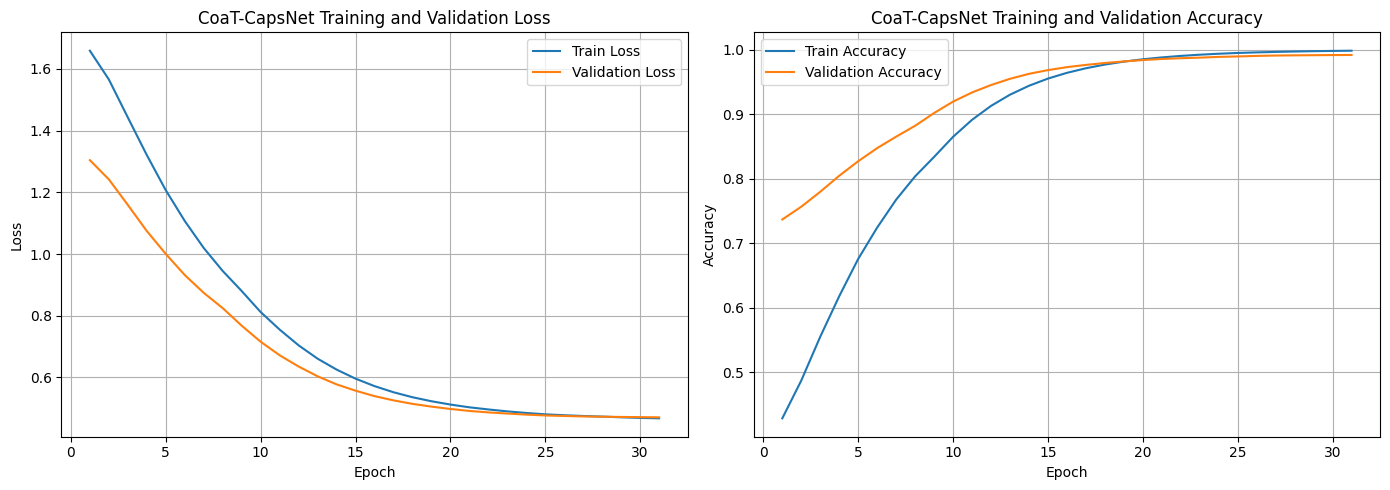

In [ ]:
# ================= CELL 10 — Plot Training Curves =================

def smooth(y, alpha=0.2):
    s = []

    for i, v in enumerate(y):
        if i == 0:
            s.append(v)
        else:
            s.append(alpha * v + (1 - alpha) * s[-1])

    return s


epochs_ran = range(1, len(train_loss_hist) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_ran, smooth(train_loss_hist), label="Train Loss")
plt.plot(epochs_ran, smooth(val_loss_hist), label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CoaT-CapsNet Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_ran, smooth(train_acc_hist), label="Train Accuracy")
plt.plot(epochs_ran, smooth(val_acc_hist), label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CoaT-CapsNet Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

CELL 11 — Extract Deep Features for ESTACK

In [ ]:
# ================= CELL 11 — Extract Deep Features for ESTACK: Train, Val, Test =================

def extract_deep_features(model, loader, split_name="data"):
    model.eval()

    X = []
    y_all = []

    with torch.no_grad():
        for x_rgb, x_hm, pose, y in tqdm(
            loader,
            desc=f"Extracting deep features from {split_name}",
            dynamic_ncols=True
        ):
            x_rgb = x_rgb.to(DEVICE, non_blocking=True)
            x_hm = x_hm.to(DEVICE, non_blocking=True)
            pose = pose.to(DEVICE, non_blocking=True)

            z = model.extract_features(
                x_rgb,
                x_hm,
                pose
            )

            X.append(z.cpu().numpy())
            y_all.append(y.numpy())

    X = np.concatenate(X, axis=0)
    y_all = np.concatenate(y_all, axis=0)

    return X, y_all


X_train, y_train_estack = extract_deep_features(
    model,
    train_feature_loader,
    split_name="train"
)

X_val, y_val_estack = extract_deep_features(
    model,
    val_loader,
    split_name="validation"
)

X_test, y_test_estack = extract_deep_features(
    model,
    test_loader,
    split_name="test"
)

print("ESTACK train features:", X_train.shape)
print("ESTACK val features  :", X_val.shape)
print("ESTACK test features :", X_test.shape)

print("Train labels:", y_train_estack.shape)
print("Val labels  :", y_val_estack.shape)
print("Test labels :", y_test_estack.shape)

Extracting deep features from train:   0%|          | 0/121 [00:00<?, ?it/s]

Extracting deep features from validation:   0%|          | 0/30 [00:00<?, ?it/s]

Extracting deep features from test:   0%|          | 0/18 [00:00<?, ?it/s]

ESTACK train features: (3843, 256)
ESTACK val features  : (958, 256)
ESTACK test features : (570, 256)
Train labels: (3843,)
Val labels  : (958,)
Test labels : (570,)


CELL 12 — Train ESTACK Classifier

In [ ]:
# ================= CELL 12 — Train ESTACK Classifier =================

base_learners = [
    (
        "lr",
        make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=SEED
            )
        )
    ),

    (
        "svm",
        make_pipeline(
            StandardScaler(),
            SVC(
                C=10,
                kernel="rbf",
                gamma="scale",
                probability=True,
                class_weight="balanced",
                random_state=SEED
            )
        )
    ),

    (
        "rf",
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1
        )
    ),

    (
        "et",
        ExtraTreesClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        )
    )
]

meta_classifier = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=SEED
)

estack = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_classifier,
    stack_method="predict_proba",
    cv=3,
    passthrough=True,
    n_jobs=-1
)

print("Training ESTACK classifier...")

estack.fit(X_train, y_train_estack)

estack_path = f"{CACHE_DIR}/estack_classifier.joblib"

joblib.dump(estack, estack_path)

print("ESTACK classifier saved at:", estack_path)

Training ESTACK classifier...
ESTACK classifier saved at: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /estack_classifier.joblib


CELL 13 — Final Evaluation: CoaT + CapsNet + ESTACK

In [ ]:
# ================= CELL 13 — Final Evaluation: Validation and Test =================

def evaluate_estack_split(X, y_true, split_name):
    y_pred = estack.predict(X)
    y_prob = estack.predict_proba(X)

    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("\n" + "=" * 80)
    print(f"CoaT + CapsNet + ESTACK RESULTS ON {split_name.upper()}")
    print("=" * 80)
    print(f"Accuracy : {acc * 100:.2f}%")
    print(f"Precision: {precision * 100:.2f}%")
    print(f"Recall   : {recall * 100:.2f}%")
    print(f"F1-score : {f1 * 100:.2f}%")

    try:
        auc = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )

        print(f"AUC-ROC  : {auc * 100:.2f}%")

    except Exception as e:
        auc = None
        print("AUC-ROC could not be computed.")
        print("Reason:", e)

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=classes,
            zero_division=0
        )
    )

    return {
        "split": split_name,
        "accuracy": acc * 100,
        "precision": precision * 100,
        "recall": recall * 100,
        "f1_score": f1 * 100,
        "auc_roc": None if auc is None else auc * 100,
        "y_pred": y_pred,
        "y_prob": y_prob
    }


val_results = evaluate_estack_split(
    X_val,
    y_val_estack,
    split_name="validation"
)

test_results = evaluate_estack_split(
    X_test,
    y_test_estack,
    split_name="test"
)

# For later cells
y_pred_val = val_results["y_pred"]
y_pred_test = test_results["y_pred"]

acc = val_results["accuracy"]
precision = val_results["precision"]
recall = val_results["recall"]
f1 = val_results["f1_score"]


CoaT + CapsNet + ESTACK RESULTS ON VALIDATION
Accuracy : 99.37%
Precision: 99.38%
Recall   : 99.37%
F1-score : 99.37%
AUC-ROC  : 99.94%

Classification Report:
                  precision    recall  f1-score   support

Bound_Angle_Pose       0.99      0.99      0.99       145
      Cobra_Pose       0.99      0.99      0.99       144
    Downdog_Pose       0.98      1.00      0.99       126
   Goddess_Pose        1.00      0.99      1.00       143
     Plank_Pose        0.99      0.99      0.99       127
       Tree_Pose       1.00      1.00      1.00       136
   Warrior2_Pose       1.00      0.99      1.00       137

        accuracy                           0.99       958
       macro avg       0.99      0.99      0.99       958
    weighted avg       0.99      0.99      0.99       958


CoaT + CapsNet + ESTACK RESULTS ON TEST
Accuracy : 97.02%
Precision: 97.04%
Recall   : 97.02%
F1-score : 97.00%
AUC-ROC  : 99.94%

Classification Report:
                  precision    recall  f1-s

In [ ]:
X_train, y_train_estack
X_val, y_val_estack
X_test, y_test_estack
estack
classes
CACHE_DIR

'/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split '

CELL 14 — Confusion Matrix

<Figure size 1200x1200 with 0 Axes>

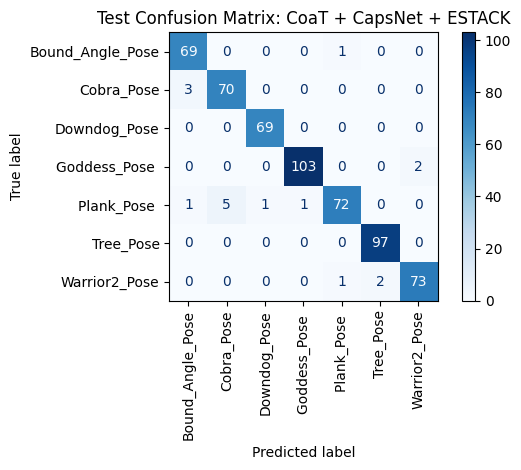

<Figure size 1200x1200 with 0 Axes>

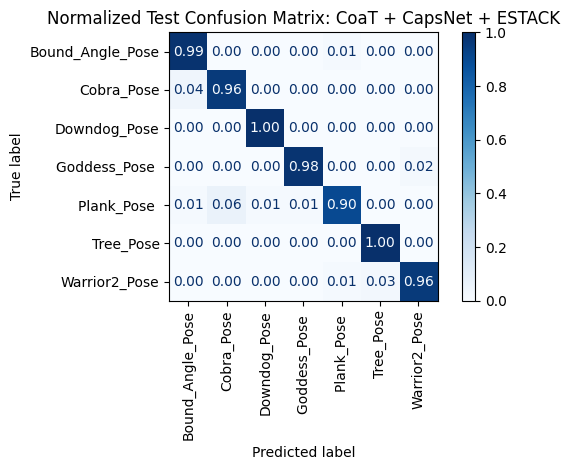

In [ ]:
# ================= CELL 14 — Confusion Matrix for Test Dataset =================

cm_test = confusion_matrix(
    y_test_estack,
    y_pred_test
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=classes
)

plt.figure(figsize=(12, 12))
disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

plt.title("Test Confusion Matrix: CoaT + CapsNet + ESTACK")
plt.tight_layout()
plt.show()


cm_test_norm = cm_test.astype("float") / np.maximum(
    cm_test.sum(axis=1, keepdims=True),
    1
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_norm,
    display_labels=classes
)

plt.figure(figsize=(12, 12))
disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format=".2f"
)

plt.title("Normalized Test Confusion Matrix: CoaT + CapsNet + ESTACK")
plt.tight_layout()
plt.show()

CELL 15 — Compare Deep Head vs ESTACK

In [ ]:
# ================= CELL 15 — Compare Deep Head vs ESTACK on Test Dataset =================

def evaluate_deep_head(model, loader, split_name):
    model.eval()

    deep_preds = []
    deep_labels = []

    with torch.no_grad():
        for x_rgb, x_hm, pose, y in tqdm(
            loader,
            desc=f"Evaluating Deep Head on {split_name}",
            dynamic_ncols=True
        ):
            x_rgb = x_rgb.to(DEVICE, non_blocking=True)
            x_hm = x_hm.to(DEVICE, non_blocking=True)
            pose = pose.to(DEVICE, non_blocking=True)

            logits = model(x_rgb, x_hm, pose)
            preds = logits.argmax(dim=1).cpu().numpy()

            deep_preds.extend(preds)
            deep_labels.extend(y.numpy())

    deep_preds = np.array(deep_preds)
    deep_labels = np.array(deep_labels)

    deep_acc = accuracy_score(deep_labels, deep_preds)

    deep_precision, deep_recall, deep_f1, _ = precision_recall_fscore_support(
        deep_labels,
        deep_preds,
        average="weighted",
        zero_division=0
    )

    return deep_acc * 100, deep_precision * 100, deep_recall * 100, deep_f1 * 100


deep_test_acc, deep_test_precision, deep_test_recall, deep_test_f1 = evaluate_deep_head(
    model,
    test_loader,
    split_name="test"
)

comparison_data = {
    "Model": [
        "CoaT + CapsNet + Deep Head",
        "CoaT + CapsNet + ESTACK"
    ],
    "Dataset": [
        "Test",
        "Test"
    ],
    "Accuracy": [
        deep_test_acc,
        test_results["accuracy"]
    ],
    "Precision": [
        deep_test_precision,
        test_results["precision"]
    ],
    "Recall": [
        deep_test_recall,
        test_results["recall"]
    ],
    "F1-score": [
        deep_test_f1,
        test_results["f1_score"]
    ]
}

comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

Evaluating Deep Head on test:   0%|          | 0/18 [00:00<?, ?it/s]

,Model,Dataset,Accuracy,Precision,Recall,F1-score
0,CoaT + CapsNet + Deep Head,Test,96.666667,96.710017,96.666667,96.645671
1,CoaT + CapsNet + ESTACK,Test,97.017544,97.044555,97.017544,97.000310


CELL 16 — Save Final Results to CSV

In [ ]:
# ================= CELL 16 — Save Final Validation and Test Results =================

results_path = f"{CACHE_DIR}/coat_capsnet_estack_validation_test_results.csv"

comparison_df.to_csv(results_path, index=False)

print("Comparison results saved at:", results_path)

# Save test classification report
test_report_dict = classification_report(
    y_test_estack,
    y_pred_test,
    target_names=classes,
    zero_division=0,
    output_dict=True
)

test_report_df = pd.DataFrame(test_report_dict).transpose()

test_report_path = f"{CACHE_DIR}/classification_report_test_coat_capsnet_estack.csv"

test_report_df.to_csv(test_report_path)

print("Test classification report saved at:", test_report_path)

# Save validation classification report
val_report_dict = classification_report(
    y_val_estack,
    y_pred_val,
    target_names=classes,
    zero_division=0,
    output_dict=True
)

val_report_df = pd.DataFrame(val_report_dict).transpose()

val_report_path = f"{CACHE_DIR}/classification_report_validation_coat_capsnet_estack.csv"

val_report_df.to_csv(val_report_path)

print("Validation classification report saved at:", val_report_path)

Comparison results saved at: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /coat_capsnet_estack_validation_test_results.csv
Test classification report saved at: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /classification_report_test_coat_capsnet_estack.csv
Validation classification report saved at: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /classification_report_validation_coat_capsnet_estack.csv


Cell 17 — Setup for 80:20 Component Comparison

In [ ]:
# ============================================================
# CELL 17 — Setup for 80:20 Component-wise Comparison
# CoaT, CapsNet, Heatmap, Softmax, ESTACK
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

EXPERIMENT_NAME = "80_20"

COMP_GRAPH_DIR = os.path.join(
    CACHE_DIR,
    "component_wise_comparison_80_20"
)

os.makedirs(COMP_GRAPH_DIR, exist_ok=True)

print("Experiment:", EXPERIMENT_NAME)
print("Component comparison output folder:")
print(COMP_GRAPH_DIR)

Experiment: 80_20
Component comparison output folder:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /component_wise_comparison_80_20


Cell 18 — Extract Component-wise Features

In [ ]:
# ============================================================
# CELL 18 — Extract Component-wise Features
# ============================================================

def extract_component_features(model, loader, split_name="data"):
    model.eval()

    feature_dict = {
        "coat": [],
        "capsnet": [],
        "heatmap": [],
        "coat_capsnet": [],
        "full_fused": []
    }

    y_all = []

    with torch.no_grad():
        for x_rgb, x_hm, pose, y in tqdm(
            loader,
            desc=f"Extracting component features from {split_name}",
            dynamic_ncols=True
        ):
            x_rgb = x_rgb.to(DEVICE, non_blocking=True)
            x_hm = x_hm.to(DEVICE, non_blocking=True)
            pose = pose.to(DEVICE, non_blocking=True)

            # CoaT RGB feature
            f_coat = model.coat_forward(x_rgb)

            # Heatmap branch feature
            f_hm = model.hm_branch(x_hm)
            f_hm = f_hm.flatten(1)

            # CapsNet pose feature
            f_caps = model.pose_caps(pose)

            # CoaT + CapsNet
            f_coat_caps = torch.cat(
                [f_coat, f_caps],
                dim=1
            )

            # Full raw feature: CoaT + Heatmap + CapsNet
            f_raw_full = torch.cat(
                [f_coat, f_hm, f_caps],
                dim=1
            )

            # Final fused feature after fusion block
            f_full_fused = model.fusion(f_raw_full)

            feature_dict["coat"].append(f_coat.cpu().numpy())
            feature_dict["capsnet"].append(f_caps.cpu().numpy())
            feature_dict["heatmap"].append(f_hm.cpu().numpy())
            feature_dict["coat_capsnet"].append(f_coat_caps.cpu().numpy())
            feature_dict["full_fused"].append(f_full_fused.cpu().numpy())

            y_all.append(y.numpy())

    for key in feature_dict:
        feature_dict[key] = np.concatenate(feature_dict[key], axis=0)

    y_all = np.concatenate(y_all, axis=0)

    print("\n" + "=" * 70)
    print(f"{split_name.upper()} FEATURE SHAPES")
    print("=" * 70)

    for key, value in feature_dict.items():
        print(f"{key:20s}: {value.shape}")

    print("Labels:", y_all.shape)

    return feature_dict, y_all


train_comp_features, y_train_comp = extract_component_features(
    model,
    train_feature_loader,
    split_name="train"
)

val_comp_features, y_val_comp = extract_component_features(
    model,
    val_loader,
    split_name="validation"
)

test_comp_features, y_test_comp = extract_component_features(
    model,
    test_loader,
    split_name="test"
)

Extracting component features from train:   0%|          | 0/121 [00:00<?, ?it/s]


TRAIN FEATURE SHAPES
coat                : (3843, 320)
capsnet             : (3843, 266)
heatmap             : (3843, 64)
coat_capsnet        : (3843, 586)
full_fused          : (3843, 256)
Labels: (3843,)


Extracting component features from validation:   0%|          | 0/30 [00:00<?, ?it/s]


VALIDATION FEATURE SHAPES
coat                : (958, 320)
capsnet             : (958, 266)
heatmap             : (958, 64)
coat_capsnet        : (958, 586)
full_fused          : (958, 256)
Labels: (958,)


Extracting component features from test:   0%|          | 0/18 [00:00<?, ?it/s]


TEST FEATURE SHAPES
coat                : (570, 320)
capsnet             : (570, 266)
heatmap             : (570, 64)
coat_capsnet        : (570, 586)
full_fused          : (570, 256)
Labels: (570,)


Cell 19 — Softmax and ESTACK Classifier Functions

In [ ]:
# ============================================================
# CELL 19 — Softmax and ESTACK Classifier Functions
# ============================================================

def make_softmax_classifier():
    """
    Logistic Regression works as Softmax classifier
    for multi-class classification on extracted features.
    """
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=SEED
        )
    )


def make_estack_classifier():
    """
    ESTACK classifier:
    LR + SVM + RF + ExtraTrees with Logistic Regression meta-classifier.
    """
    base_learners = [
        (
            "lr",
            make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=SEED
                )
            )
        ),

        (
            "svm",
            make_pipeline(
                StandardScaler(),
                SVC(
                    C=10,
                    kernel="rbf",
                    gamma="scale",
                    probability=True,
                    class_weight="balanced",
                    random_state=SEED
                )
            )
        ),

        (
            "rf",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced_subsample",
                random_state=SEED,
                n_jobs=-1
            )
        ),

        (
            "et",
            ExtraTreesClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=SEED,
                n_jobs=-1
            )
        )
    ]

    meta_classifier = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED
    )

    clf = StackingClassifier(
        estimators=base_learners,
        final_estimator=meta_classifier,
        stack_method="predict_proba",
        cv=3,
        passthrough=True,
        n_jobs=-1
    )

    return clf


def evaluate_classifier_model(clf, X, y_true):
    y_pred = clf.predict(X)

    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    auc = None

    try:
        y_prob = clf.predict_proba(X)

        auc = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )

    except Exception as e:
        auc = None

    return {
        "Accuracy (%)": acc * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1-score (%)": f1 * 100,
        "AUC-ROC (%)": None if auc is None else auc * 100
    }


print("Softmax and ESTACK functions are ready.")

Softmax and ESTACK functions are ready.


Cell 20 — Deep Head Evaluation Function

In [ ]:
# ============================================================
# CELL 20 — Deep Head Evaluation Function
# Full Model without ESTACK
# ============================================================

def evaluate_deep_head_full_model(model, loader, split_name="data"):
    model.eval()

    y_true_all = []
    y_pred_all = []
    y_prob_all = []

    with torch.no_grad():
        for x_rgb, x_hm, pose, y in tqdm(
            loader,
            desc=f"Evaluating Deep Head on {split_name}",
            dynamic_ncols=True
        ):
            x_rgb = x_rgb.to(DEVICE, non_blocking=True)
            x_hm = x_hm.to(DEVICE, non_blocking=True)
            pose = pose.to(DEVICE, non_blocking=True)

            logits = model(x_rgb, x_hm, pose)

            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()

            y_prob_all.append(probs)
            y_pred_all.extend(preds)
            y_true_all.extend(y.numpy())

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_prob_all = np.concatenate(y_prob_all, axis=0)

    acc = accuracy_score(y_true_all, y_pred_all)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_all,
        y_pred_all,
        average="weighted",
        zero_division=0
    )

    auc = None

    try:
        auc = roc_auc_score(
            y_true_all,
            y_prob_all,
            multi_class="ovr",
            average="weighted"
        )
    except Exception as e:
        auc = None

    return {
        "Accuracy (%)": acc * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1-score (%)": f1 * 100,
        "AUC-ROC (%)": None if auc is None else auc * 100
    }


print("Deep Head evaluation function is ready.")

Deep Head evaluation function is ready.


Cell 21 — Run Full Component Comparison for 80:20

In [ ]:
# ============================================================
# CELL 21 — Full Component-wise Comparison for 80:20
# Softmax + ESTACK for all important feature groups
# ============================================================

component_rows = []
trained_classifiers = {}


def add_result_row(
    rows,
    experiment_name,
    model_name,
    classifier_name,
    dataset_name,
    metrics,
    coat_status,
    capsnet_status,
    heatmap_status,
    estack_status
):
    rows.append({
        "Experiment": experiment_name,
        "Model Variant": model_name,
        "Classifier": classifier_name,
        "Dataset": dataset_name,
        "CoaT": coat_status,
        "CapsNet": capsnet_status,
        "Heatmap": heatmap_status,
        "ESTACK": estack_status,
        "Accuracy (%)": metrics["Accuracy (%)"],
        "Precision (%)": metrics["Precision (%)"],
        "Recall (%)": metrics["Recall (%)"],
        "F1-score (%)": metrics["F1-score (%)"],
        "AUC-ROC (%)": metrics["AUC-ROC (%)"]
    })


def run_feature_classifier_comparison(
    feature_key,
    model_variant_name,
    coat_status,
    capsnet_status,
    heatmap_status
):
    # ================= Softmax =================
    print("\n" + "=" * 80)
    print(f"Training Softmax for: {model_variant_name}")
    print("=" * 80)

    softmax_clf = make_softmax_classifier()

    softmax_clf.fit(
        train_comp_features[feature_key],
        y_train_comp
    )

    val_metrics = evaluate_classifier_model(
        softmax_clf,
        val_comp_features[feature_key],
        y_val_comp
    )

    test_metrics = evaluate_classifier_model(
        softmax_clf,
        test_comp_features[feature_key],
        y_test_comp
    )

    add_result_row(
        component_rows,
        EXPERIMENT_NAME,
        model_variant_name,
        "Softmax",
        "Validation",
        val_metrics,
        coat_status,
        capsnet_status,
        heatmap_status,
        "No"
    )

    add_result_row(
        component_rows,
        EXPERIMENT_NAME,
        model_variant_name,
        "Softmax",
        "Test",
        test_metrics,
        coat_status,
        capsnet_status,
        heatmap_status,
        "No"
    )

    trained_classifiers[f"{model_variant_name}_Softmax"] = softmax_clf

    # ================= ESTACK =================
    print("\n" + "=" * 80)
    print(f"Training ESTACK for: {model_variant_name}")
    print("=" * 80)

    estack_clf = make_estack_classifier()

    estack_clf.fit(
        train_comp_features[feature_key],
        y_train_comp
    )

    val_metrics = evaluate_classifier_model(
        estack_clf,
        val_comp_features[feature_key],
        y_val_comp
    )

    test_metrics = evaluate_classifier_model(
        estack_clf,
        test_comp_features[feature_key],
        y_test_comp
    )

    add_result_row(
        component_rows,
        EXPERIMENT_NAME,
        model_variant_name,
        "ESTACK",
        "Validation",
        val_metrics,
        coat_status,
        capsnet_status,
        heatmap_status,
        "Yes"
    )

    add_result_row(
        component_rows,
        EXPERIMENT_NAME,
        model_variant_name,
        "ESTACK",
        "Test",
        test_metrics,
        coat_status,
        capsnet_status,
        heatmap_status,
        "Yes"
    )

    trained_classifiers[f"{model_variant_name}_ESTACK"] = estack_clf


# ============================================================
# Run comparisons
# ============================================================

run_feature_classifier_comparison(
    feature_key="coat",
    model_variant_name="CoaT",
    coat_status="Yes",
    capsnet_status="No",
    heatmap_status="No"
)

run_feature_classifier_comparison(
    feature_key="capsnet",
    model_variant_name="CapsNet",
    coat_status="No",
    capsnet_status="Yes",
    heatmap_status="No"
)

run_feature_classifier_comparison(
    feature_key="heatmap",
    model_variant_name="Heatmap",
    coat_status="No",
    capsnet_status="No",
    heatmap_status="Yes"
)

run_feature_classifier_comparison(
    feature_key="coat_capsnet",
    model_variant_name="CoaT + CapsNet",
    coat_status="Yes",
    capsnet_status="Yes",
    heatmap_status="No"
)

run_feature_classifier_comparison(
    feature_key="full_fused",
    model_variant_name="CoaT + Heatmap + CapsNet",
    coat_status="Yes",
    capsnet_status="Yes",
    heatmap_status="Yes"
)


# ============================================================
# Deep Head Result: Full Model without ESTACK
# ============================================================

print("\n" + "=" * 80)
print("Evaluating Deep Head: CoaT + Heatmap + CapsNet")
print("=" * 80)

val_metrics = evaluate_deep_head_full_model(
    model,
    val_loader,
    split_name="validation"
)

test_metrics = evaluate_deep_head_full_model(
    model,
    test_loader,
    split_name="test"
)

add_result_row(
    component_rows,
    EXPERIMENT_NAME,
    "CoaT + Heatmap + CapsNet",
    "Deep Head",
    "Validation",
    val_metrics,
    "Yes",
    "Yes",
    "Yes",
    "No"
)

add_result_row(
    component_rows,
    EXPERIMENT_NAME,
    "CoaT + Heatmap + CapsNet",
    "Deep Head",
    "Test",
    test_metrics,
    "Yes",
    "Yes",
    "Yes",
    "No"
)


# ============================================================
# Proposed model from your main pipeline
# ============================================================

print("\n" + "=" * 80)
print("Adding Proposed Model Result from Main Pipeline")
print("=" * 80)

add_result_row(
    component_rows,
    EXPERIMENT_NAME,
    "Proposed CoaT-CapsNet-ESTACK",
    "ESTACK",
    "Validation",
    {
        "Accuracy (%)": val_results["accuracy"],
        "Precision (%)": val_results["precision"],
        "Recall (%)": val_results["recall"],
        "F1-score (%)": val_results["f1_score"],
        "AUC-ROC (%)": val_results["auc_roc"]
    },
    "Yes",
    "Yes",
    "Yes",
    "Yes"
)

add_result_row(
    component_rows,
    EXPERIMENT_NAME,
    "Proposed CoaT-CapsNet-ESTACK",
    "ESTACK",
    "Test",
    {
        "Accuracy (%)": test_results["accuracy"],
        "Precision (%)": test_results["precision"],
        "Recall (%)": test_results["recall"],
        "F1-score (%)": test_results["f1_score"],
        "AUC-ROC (%)": test_results["auc_roc"]
    },
    "Yes",
    "Yes",
    "Yes",
    "Yes"
)


# ============================================================
# Final dataframe
# ============================================================

df_component_comparison_8020 = pd.DataFrame(component_rows)

display(df_component_comparison_8020)

component_csv_path = os.path.join(
    COMP_GRAPH_DIR,
    "component_wise_softmax_estack_comparison_80_20.csv"
)

df_component_comparison_8020.to_csv(
    component_csv_path,
    index=False
)

print("Component-wise comparison CSV saved at:")
print(component_csv_path)


Training Softmax for: CoaT

Training ESTACK for: CoaT

Training Softmax for: CapsNet

Training ESTACK for: CapsNet

Training Softmax for: Heatmap

Training ESTACK for: Heatmap

Training Softmax for: CoaT + CapsNet

Training ESTACK for: CoaT + CapsNet


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Training Softmax for: CoaT + Heatmap + CapsNet

Training ESTACK for: CoaT + Heatmap + CapsNet

Evaluating Deep Head: CoaT + Heatmap + CapsNet


Evaluating Deep Head on validation:   0%|          | 0/30 [00:00<?, ?it/s]

Evaluating Deep Head on test:   0%|          | 0/18 [00:00<?, ?it/s]


Adding Proposed Model Result from Main Pipeline


,Experiment,Model Variant,Classifier,Dataset,CoaT,CapsNet,Heatmap,ESTACK,Accuracy (%),Precision (%),Recall (%),F1-score (%),AUC-ROC (%)
0,80_20,CoaT,Softmax,Validation,Yes,No,No,No,99.269311,99.274003,99.269311,99.269745,99.929418
1,80_20,CoaT,Softmax,Test,Yes,No,No,No,96.491228,96.527413,96.491228,96.471341,99.898520
2,80_20,CoaT,ESTACK,Validation,Yes,No,No,Yes,99.373695,99.377719,99.373695,99.374128,99.949017
3,80_20,CoaT,ESTACK,Test,Yes,No,No,Yes,96.491228,96.527413,96.491228,96.471341,99.906766
4,80_20,CapsNet,Softmax,Validation,No,Yes,No,No,77.348643,77.470639,77.348643,77.306294,95.632613
5,80_20,CapsNet,Softmax,Test,No,Yes,No,No,61.929825,64.442925,61.929825,60.934325,89.486059
6,80_20,CapsNet,ESTACK,Validation,No,Yes,No,Yes,91.962422,92.115548,91.962422,91.955712,99.492377
7,80_20,CapsNet,ESTACK,Test,No,Yes,No,Yes,75.087719,78.456279,75.087719,74.438056,96.340862
8,80_20,Heatmap,Softmax,Validation,No,No,Yes,No,70.041754,69.972636,70.041754,69.833958,93.443002
9,80_20,Heatmap,Softmax,Test,No,No,Yes,No,58.421053,59.303041,58.421053,57.096645,86.514300


Component-wise comparison CSV saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /component_wise_comparison_80_20/component_wise_softmax_estack_comparison_80_20.csv


Cell 22 — Save Trained Classifiers

In [ ]:
# ============================================================
# CELL 22 — Save Component-wise Classifiers
# ============================================================

classifiers_path = os.path.join(
    COMP_GRAPH_DIR,
    "component_wise_trained_classifiers_80_20.joblib"
)

joblib.dump(
    trained_classifiers,
    classifiers_path
)

print("Component-wise classifiers saved at:")
print(classifiers_path)

Component-wise classifiers saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /component_wise_comparison_80_20/component_wise_trained_classifiers_80_20.joblib


Cell 23 — Test Dataset Comparison Table

In [ ]:
# ============================================================
# CELL 23 — Test Dataset Component-wise Comparison Table
# 80:20 Split
# ============================================================

df_component_test_8020 = df_component_comparison_8020[
    df_component_comparison_8020["Dataset"] == "Test"
].copy()

df_component_test_8020 = df_component_test_8020.reset_index(drop=True)

display(df_component_test_8020)

test_component_csv_path = os.path.join(
    COMP_GRAPH_DIR,
    "component_wise_test_comparison_80_20.csv"
)

df_component_test_8020.to_csv(
    test_component_csv_path,
    index=False
)

print("Test component-wise comparison CSV saved at:")
print(test_component_csv_path)

,Experiment,Model Variant,Classifier,Dataset,CoaT,CapsNet,Heatmap,ESTACK,Accuracy (%),Precision (%),Recall (%),F1-score (%),AUC-ROC (%)
0,80_20,CoaT,Softmax,Test,Yes,No,No,No,96.491228,96.527413,96.491228,96.471341,99.898520
1,80_20,CoaT,ESTACK,Test,Yes,No,No,Yes,96.491228,96.527413,96.491228,96.471341,99.906766
2,80_20,CapsNet,Softmax,Test,No,Yes,No,No,61.929825,64.442925,61.929825,60.934325,89.486059
3,80_20,CapsNet,ESTACK,Test,No,Yes,No,Yes,75.087719,78.456279,75.087719,74.438056,96.340862
4,80_20,Heatmap,Softmax,Test,No,No,Yes,No,58.421053,59.303041,58.421053,57.096645,86.514300
5,80_20,Heatmap,ESTACK,Test,No,No,Yes,Yes,64.912281,69.977083,64.912281,64.282348,91.592673
6,80_20,CoaT + CapsNet,Softmax,Test,Yes,Yes,No,No,95.964912,96.030164,95.964912,95.935724,99.701487
7,80_20,CoaT + CapsNet,ESTACK,Test,Yes,Yes,No,Yes,96.491228,96.527413,96.491228,96.471341,99.907470
8,80_20,CoaT + Heatmap + CapsNet,Softmax,Test,Yes,Yes,Yes,No,96.842105,96.882497,96.842105,96.820320,99.936504
9,80_20,CoaT + Heatmap + CapsNet,ESTACK,Test,Yes,Yes,Yes,Yes,97.017544,97.044555,97.017544,97.000310,99.936905


Test component-wise comparison CSV saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /component_wise_comparison_80_20/component_wise_test_comparison_80_20.csv


Cell 24 — Accuracy Bar Graph for All Variants

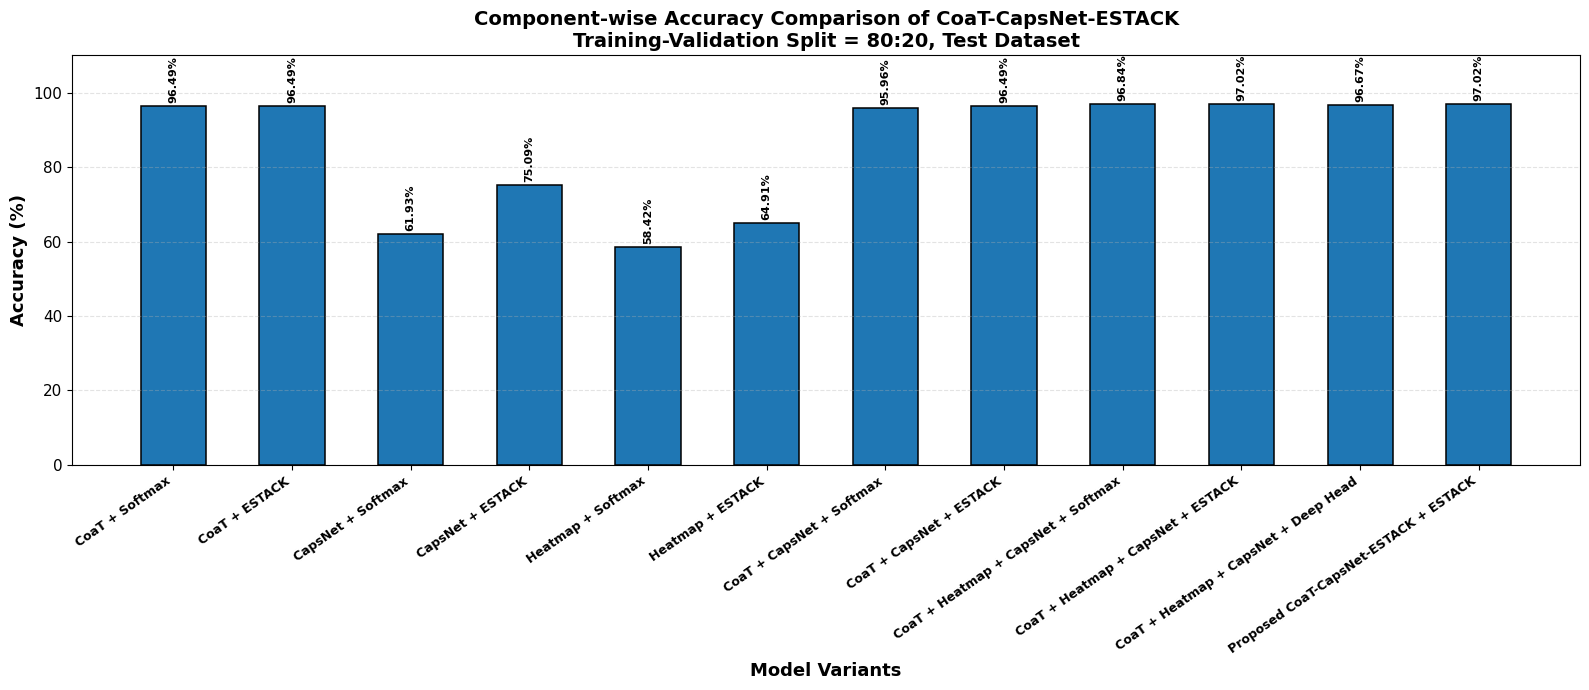

Accuracy bar graph saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /component_wise_comparison_80_20/component_wise_accuracy_all_variants_80_20_test_300dpi.png
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /component_wise_comparison_80_20/component_wise_accuracy_all_variants_80_20_test.pdf


In [ ]:
# ============================================================
# CELL 24 — Accuracy Bar Graph for All Component Variants
# 80:20 Split, Test Dataset
# ============================================================

df_plot = df_plot = df_component_test_8020.copy()

df_plot["Display Name"] = (
    df_plot["Model Variant"] + " + " + df_plot["Classifier"]
)

plt.figure(figsize=(16, 7))

bars = plt.bar(
    df_plot["Display Name"],
    df_plot["Accuracy (%)"],
    edgecolor="black",
    linewidth=1.1,
    width=0.55
)

for bar, value in zip(
    bars,
    df_plot["Accuracy (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.8,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        rotation=90
    )

plt.xlabel(
    "Model Variants",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "Component-wise Accuracy Comparison of CoaT-CapsNet-ESTACK\n"
    "Training-Validation Split = 80:20, Test Dataset",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    rotation=35,
    ha="right",
    fontsize=9,
    fontweight="bold"
)

plt.yticks(fontsize=11)
plt.ylim(0, 110)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

plt.tight_layout()

accuracy_bar_png = os.path.join(
    COMP_GRAPH_DIR,
    "component_wise_accuracy_all_variants_80_20_test_300dpi.png"
)

accuracy_bar_pdf = os.path.join(
    COMP_GRAPH_DIR,
    "component_wise_accuracy_all_variants_80_20_test.pdf"
)

plt.savefig(
    accuracy_bar_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    accuracy_bar_pdf,
    bbox_inches="tight"
)

plt.show()

print("Accuracy bar graph saved at:")
print(accuracy_bar_png)
print(accuracy_bar_pdf)

Cell 25 — Softmax vs ESTACK Grouped Bar Graph

Classifier,Model Variant,ESTACK,Softmax
0,CapsNet,75.087719,61.929825
1,CoaT,96.491228,96.491228
2,CoaT + CapsNet,96.491228,95.964912
3,CoaT + Heatmap + CapsNet,97.017544,96.842105
4,Heatmap,64.912281,58.421053
5,Proposed CoaT-CapsNet-ESTACK,97.017544,NaN


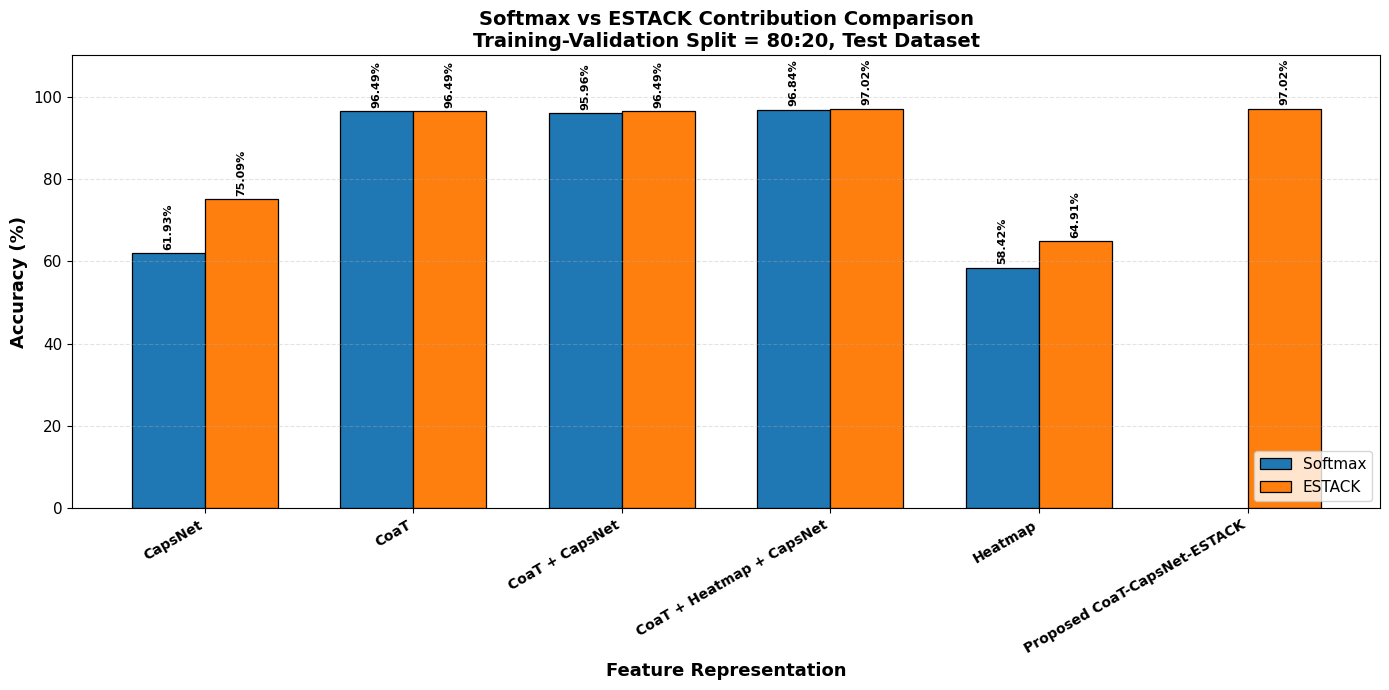

Softmax vs ESTACK graph saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /component_wise_comparison_80_20/softmax_vs_estack_accuracy_80_20_test_300dpi.png
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /component_wise_comparison_80_20/softmax_vs_estack_accuracy_80_20_test.pdf


In [ ]:
# ============================================================
# CELL 25 — Softmax vs ESTACK Grouped Bar Graph
# 80:20 Split, Test Dataset
# ============================================================

df_se = df_component_test_8020[
    df_component_test_8020["Classifier"].isin(["Softmax", "ESTACK"])
].copy()

pivot_acc = df_se.pivot_table(
    index="Model Variant",
    columns="Classifier",
    values="Accuracy (%)",
    aggfunc="mean"
).reset_index()

display(pivot_acc)

x = np.arange(len(pivot_acc))
width = 0.35

plt.figure(figsize=(14, 7))

bars1 = plt.bar(
    x - width / 2,
    pivot_acc["Softmax"],
    width,
    label="Softmax",
    edgecolor="black",
    linewidth=0.9
)

bars2 = plt.bar(
    x + width / 2,
    pivot_acc["ESTACK"],
    width,
    label="ESTACK",
    edgecolor="black",
    linewidth=0.9
)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.8,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
            rotation=90
        )

plt.xlabel(
    "Feature Representation",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "Softmax vs ESTACK Contribution Comparison\n"
    "Training-Validation Split = 80:20, Test Dataset",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    x,
    pivot_acc["Model Variant"],
    rotation=30,
    ha="right",
    fontsize=10,
    fontweight="bold"
)

plt.yticks(fontsize=11)
plt.ylim(0, 110)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

plt.legend(
    fontsize=11,
    loc="lower right",
    frameon=True
)

plt.tight_layout()

softmax_estack_png = os.path.join(
    COMP_GRAPH_DIR,
    "softmax_vs_estack_accuracy_80_20_test_300dpi.png"
)

softmax_estack_pdf = os.path.join(
    COMP_GRAPH_DIR,
    "softmax_vs_estack_accuracy_80_20_test.pdf"
)

plt.savefig(
    softmax_estack_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    softmax_estack_pdf,
    bbox_inches="tight"
)

plt.show()

print("Softmax vs ESTACK graph saved at:")
print(softmax_estack_png)
print(softmax_estack_pdf)

Cell 26 — Precision, Recall, F1-score Graph

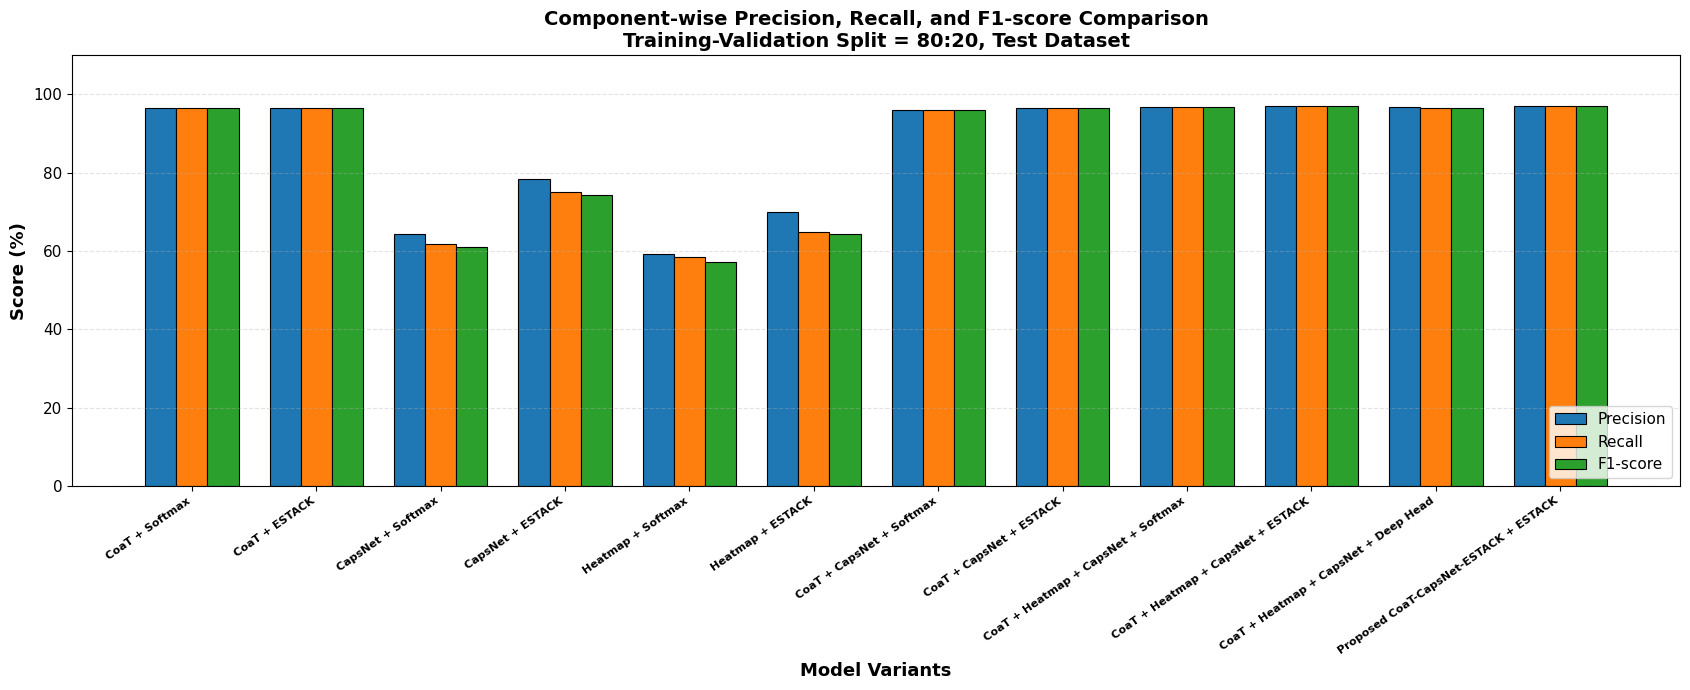

Precision Recall F1 graph saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /component_wise_comparison_80_20/component_wise_precision_recall_f1_80_20_test_300dpi.png
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /component_wise_comparison_80_20/component_wise_precision_recall_f1_80_20_test.pdf


In [ ]:
# ============================================================
# CELL 26 — Precision, Recall, F1-score Comparison
# 70:30 Split, Test Dataset
# ============================================================

df_metric_plot = df_component_comparison_8020.copy()

df_metric_plot["Display Name"] = (
    df_metric_plot["Model Variant"] + " + " + df_metric_plot["Classifier"]
)

x = np.arange(len(df_metric_plot))
width = 0.25

plt.figure(figsize=(17, 7))

bars1 = plt.bar(
    x - width,
    df_metric_plot["Precision (%)"],
    width,
    label="Precision",
    edgecolor="black",
    linewidth=0.8
)

bars2 = plt.bar(
    x,
    df_metric_plot["Recall (%)"],
    width,
    label="Recall",
    edgecolor="black",
    linewidth=0.8
)

bars3 = plt.bar(
    x + width,
    df_metric_plot["F1-score (%)"],
    width,
    label="F1-score",
    edgecolor="black",
    linewidth=0.8
)

plt.xlabel(
    "Model Variants",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Score (%)",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "Component-wise Precision, Recall, and F1-score Comparison\n"
    "Training-Validation Split = 80:20, Test Dataset",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    x,
    df_metric_plot["Display Name"],
    rotation=35,
    ha="right",
    fontsize=8,
    fontweight="bold"
)

plt.yticks(fontsize=11)
plt.ylim(0, 110)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

plt.legend(
    fontsize=11,
    loc="lower right",
    frameon=True
)

plt.tight_layout()

prf_png = os.path.join(
    COMP_GRAPH_DIR,
    "component_wise_precision_recall_f1_80_20_test_300dpi.png"
)

prf_pdf = os.path.join(
    COMP_GRAPH_DIR,
    "component_wise_precision_recall_f1_80_20_test.pdf"
)

plt.savefig(
    prf_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    prf_pdf,
    bbox_inches="tight"
)

plt.show()

print("Precision Recall F1 graph saved at:")
print(prf_png)
print(prf_pdf)

Cell 27 — Component Gain Table

In [ ]:
# ============================================================
# CELL 27 — Component-wise Gain Calculation
# 70:30 Split, Test Dataset
# ============================================================

df_gain_source = df_component_comparison_8020.copy()


def get_accuracy(model_variant, classifier):
    value = df_gain_source.loc[
        (df_gain_source["Model Variant"] == model_variant) &
        (df_gain_source["Classifier"] == classifier),
        "Accuracy (%)"
    ].values

    if len(value) == 0:
        return None

    return float(value[0])


coat_softmax = get_accuracy("CoaT", "Softmax")
coat_estack = get_accuracy("CoaT", "ESTACK")

caps_softmax = get_accuracy("CapsNet", "Softmax")
caps_estack = get_accuracy("CapsNet", "ESTACK")

heatmap_softmax = get_accuracy("Heatmap", "Softmax")
heatmap_estack = get_accuracy("Heatmap", "ESTACK")

coat_caps_softmax = get_accuracy("CoaT + CapsNet", "Softmax")
coat_caps_estack = get_accuracy("CoaT + CapsNet", "ESTACK")

full_softmax = get_accuracy("CoaT + Heatmap + CapsNet", "Softmax")
full_estack = get_accuracy("CoaT + Heatmap + CapsNet", "ESTACK")
full_deep_head = get_accuracy("CoaT + Heatmap + CapsNet", "Deep Head")
proposed_estack = get_accuracy("Proposed CoaT-CapsNet-ESTACK", "ESTACK")

gain_rows = []


def add_gain(name, before, after):
    if before is not None and after is not None:
        gain_rows.append([
            name,
            before,
            after,
            after - before
        ])


add_gain(
    "ESTACK gain over CoaT Softmax",
    coat_softmax,
    coat_estack
)

add_gain(
    "ESTACK gain over CapsNet Softmax",
    caps_softmax,
    caps_estack
)

add_gain(
    "ESTACK gain over CoaT + CapsNet Softmax",
    coat_caps_softmax,
    coat_caps_estack
)

add_gain(
    "CapsNet contribution with Softmax",
    coat_softmax,
    coat_caps_softmax
)

add_gain(
    "CapsNet contribution with ESTACK",
    coat_estack,
    coat_caps_estack
)

add_gain(
    "Heatmap contribution with Softmax",
    coat_caps_softmax,
    full_softmax
)

add_gain(
    "Heatmap contribution with ESTACK",
    coat_caps_estack,
    full_estack
)

add_gain(
    "ESTACK gain over Deep Head in Full Model",
    full_deep_head,
    proposed_estack
)

add_gain(
    "Total gain over CoaT baseline",
    coat_softmax,
    proposed_estack
)

add_gain(
    "Total gain over CapsNet baseline",
    caps_softmax,
    proposed_estack
)


df_component_comparison_8020 = pd.DataFrame(
    gain_rows,
    columns=[
        "Contribution",
        "Before Accuracy (%)",
        "After Accuracy (%)",
        "Improvement (%)"
    ]
)

display(df_component_comparison_8020)

gain_csv_path = os.path.join(
    COMP_GRAPH_DIR,
    "component_wise_accuracy_gain_80_20_test.csv"
)

df_component_comparison_8020.to_csv(
    gain_csv_path,
    index=False
)

print("Component-wise gain CSV saved at:")
print(gain_csv_path)

,Contribution,Before Accuracy (%),After Accuracy (%),Improvement (%)
0,ESTACK gain over CoaT Softmax,96.491228,96.491228,0.000000
1,ESTACK gain over CapsNet Softmax,61.929825,75.087719,13.157895
2,ESTACK gain over CoaT + CapsNet Softmax,95.964912,96.491228,0.526316
3,CapsNet contribution with Softmax,96.491228,95.964912,-0.526316
4,CapsNet contribution with ESTACK,96.491228,96.491228,0.000000
5,Heatmap contribution with Softmax,95.964912,96.842105,0.877193
6,Heatmap contribution with ESTACK,96.491228,97.017544,0.526316
7,ESTACK gain over Deep Head in Full Model,96.666667,97.017544,0.350877
8,Total gain over CoaT baseline,96.491228,97.017544,0.526316
9,Total gain over CapsNet baseline,61.929825,97.017544,35.087719


Component-wise gain CSV saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /component_wise_comparison_80_20/component_wise_accuracy_gain_80_20_test.csv


Cell 28 — Component Gain Graph

In [ ]:
# ============================================================
# CELL 28 — Component-wise Gain Graph
# 70:30 Split, Test Dataset
# ============================================================

plt.figure(figsize=(14, 6))

bars = plt.bar(
    df_component_gain_7030["Contribution"],
    df_component_gain_7030["Improvement (%)"],
    edgecolor="black",
    linewidth=1.1,
    width=0.55
)

for bar, value in zip(
    bars,
    df_component_gain_7030["Improvement (%)"]
):
    y_pos = value + 0.2 if value >= 0 else value - 0.8

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y_pos,
        f"{value:.2f}%",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=9,
        fontweight="bold",
        rotation=90
    )

plt.xlabel(
    "Component Contribution",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Accuracy Improvement (%)",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "Component-wise Accuracy Gain of CoaT-CapsNet-ESTACK\n"
    "Training-Validation Split = 80:20, Test Dataset",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    rotation=30,
    ha="right",
    fontsize=9,
    fontweight="bold"
)

plt.yticks(fontsize=11)

plt.axhline(
    y=0,
    color="black",
    linewidth=1.0
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

plt.tight_layout()

gain_png = os.path.join(
    COMP_GRAPH_DIR,
    "component_wise_accuracy_gain_80_20_test_300dpi.png"
)

gain_pdf = os.path.join(
    COMP_GRAPH_DIR,
    "component_wise_accuracy_gain_80_20_test.pdf"
)

plt.savefig(
    gain_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    gain_pdf,
    bbox_inches="tight"
)

plt.show()

print("Component-wise gain graph saved at:")
print(gain_png)
print(gain_pdf)

NameError: name 'df_component_gain_7030' is not defined

<Figure size 1400x600 with 0 Axes>

Cell 29 — Fetch Actual Metrics Automatically

In [ ]:
# ============================================================
# CELL 29 — Fetch Actual Metrics Automatically from Results
# No manual value assignment
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix
)

# ============================================================
# Output folder
# ============================================================

GRAPH_DIR = os.path.join(
    CACHE_DIR,
    "graphs_from_actual_results_80_20"
)

os.makedirs(GRAPH_DIR, exist_ok=True)

print("Graphs will be saved at:")
print(GRAPH_DIR)


# ============================================================
# Function to evaluate ESTACK dynamically
# ============================================================

def get_estack_metrics_from_result(estack_model, X, y_true, dataset_name):
    y_pred = estack_model.predict(X)
    y_prob = estack_model.predict_proba(X)

    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    try:
        auc = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )
    except Exception:
        auc = np.nan

    return {
        "Dataset": dataset_name,
        "Accuracy (%)": acc * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1-score (%)": f1 * 100,
        "AUC-ROC (%)": auc * 100 if not np.isnan(auc) else np.nan,
        "y_pred": y_pred,
        "y_prob": y_prob
    }


# ============================================================
# Fetch/recompute train, validation, and testing metrics
# ============================================================

train_actual_results = get_estack_metrics_from_result(
    estack,
    X_train,
    y_train_estack,
    "Training"
)

val_actual_results = get_estack_metrics_from_result(
    estack,
    X_val,
    y_val_estack,
    "Validation"
)

test_actual_results = get_estack_metrics_from_result(
    estack,
    X_test,
    y_test_estack,
    "Testing"
)


# ============================================================
# Create actual summary table
# ============================================================

df_actual_summary = pd.DataFrame([
    {
        "Dataset": train_actual_results["Dataset"],
        "Accuracy (%)": train_actual_results["Accuracy (%)"],
        "Precision (%)": train_actual_results["Precision (%)"],
        "Recall (%)": train_actual_results["Recall (%)"],
        "F1-score (%)": train_actual_results["F1-score (%)"],
        "AUC-ROC (%)": train_actual_results["AUC-ROC (%)"]
    },
    {
        "Dataset": val_actual_results["Dataset"],
        "Accuracy (%)": val_actual_results["Accuracy (%)"],
        "Precision (%)": val_actual_results["Precision (%)"],
        "Recall (%)": val_actual_results["Recall (%)"],
        "F1-score (%)": val_actual_results["F1-score (%)"],
        "AUC-ROC (%)": val_actual_results["AUC-ROC (%)"]
    },
    {
        "Dataset": test_actual_results["Dataset"],
        "Accuracy (%)": test_actual_results["Accuracy (%)"],
        "Precision (%)": test_actual_results["Precision (%)"],
        "Recall (%)": test_actual_results["Recall (%)"],
        "F1-score (%)": test_actual_results["F1-score (%)"],
        "AUC-ROC (%)": test_actual_results["AUC-ROC (%)"]
    }
])

display(df_actual_summary)

actual_summary_path = os.path.join(
    GRAPH_DIR,
    "actual_train_validation_testing_result_summary_80_20.csv"
)

df_actual_summary.to_csv(
    actual_summary_path,
    index=False
)

print("Actual summary saved at:")
print(actual_summary_path)

Graphs will be saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /graphs_from_actual_results_80_20


,Dataset,Accuracy (%),Precision (%),Recall (%),F1-score (%),AUC-ROC (%)
0,Training,100.000000,100.000000,100.000000,100.000000,100.000000
1,Validation,99.373695,99.376957,99.373695,99.374143,99.940185
2,Testing,97.017544,97.044555,97.017544,97.000310,99.936905


Actual summary saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /graphs_from_actual_results_80_20/actual_train_validation_testing_result_summary_80_20.csv


Cell 30 — Accuracy Trend Graph from Training History

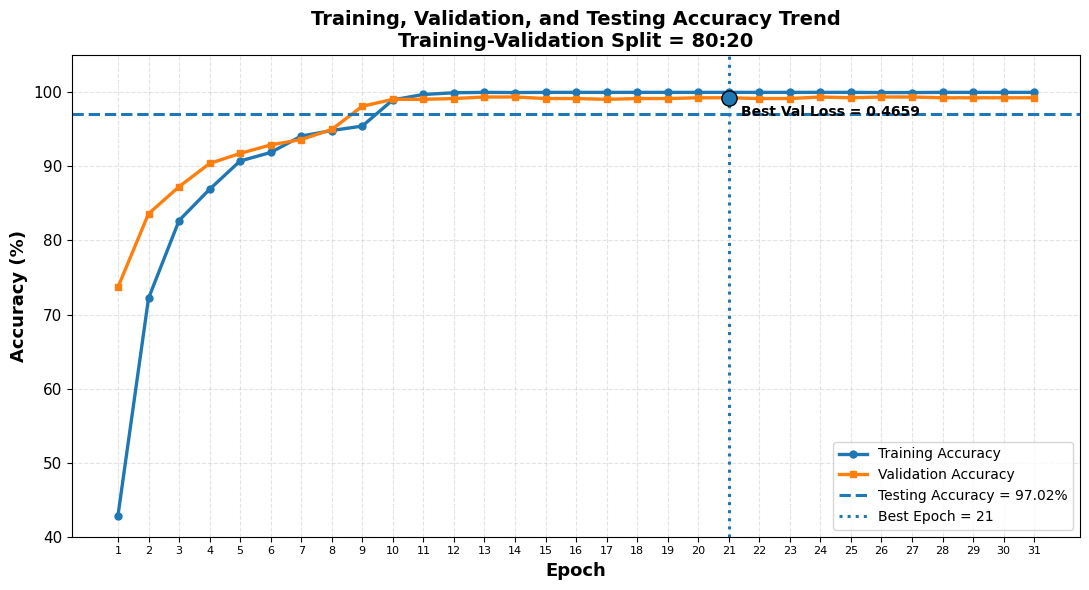

Accuracy line graph saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /graphs_from_actual_results_80_20/actual_accuracy_trend_line_graph_80_20_300dpi.png
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /graphs_from_actual_results_80_20/actual_accuracy_trend_line_graph_80_20.pdf


In [ ]:
# ============================================================
# CELL 30 — Accuracy Trend Graph from Actual train_acc_hist / val_acc_hist
# No manually written epoch values
# ============================================================

train_acc_values = np.array(train_acc_hist) * 100
val_acc_values = np.array(val_acc_hist) * 100

epochs = np.arange(1, len(train_acc_values) + 1)

# Fetch testing accuracy from actual summary
test_accuracy = float(
    df_actual_summary.loc[
        df_actual_summary["Dataset"] == "Testing",
        "Accuracy (%)"
    ].iloc[0]
)

# Fetch best epoch dynamically
try:
    best_epoch = int(checkpoint["epoch"])
except:
    best_epoch = int(np.argmin(val_loss_hist) + 1)

try:
    best_val_loss = float(checkpoint["val_loss"])
except:
    best_val_loss = float(np.min(val_loss_hist))


plt.figure(figsize=(11, 6))

plt.plot(
    epochs,
    train_acc_values,
    marker="o",
    linewidth=2.4,
    markersize=5,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_acc_values,
    marker="s",
    linewidth=2.4,
    markersize=5,
    label="Validation Accuracy"
)

plt.axhline(
    y=test_accuracy,
    linestyle="--",
    linewidth=2.2,
    label=f"Testing Accuracy = {test_accuracy:.2f}%"
)

plt.axvline(
    x=best_epoch,
    linestyle=":",
    linewidth=2.2,
    label=f"Best Epoch = {best_epoch}"
)

plt.scatter(
    best_epoch,
    val_acc_values[best_epoch - 1],
    s=120,
    edgecolor="black",
    zorder=5
)

plt.text(
    best_epoch + 0.4,
    val_acc_values[best_epoch - 1] - 2.5,
    f"Best Val Loss = {best_val_loss:.4f}",
    fontsize=10,
    fontweight="bold"
)

plt.xlabel("Epoch", fontsize=13, fontweight="bold")
plt.ylabel("Accuracy (%)", fontsize=13, fontweight="bold")

plt.title(
    "Training, Validation, and Testing Accuracy Trend\n"
    "Training-Validation Split = 80:20",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(epochs, fontsize=8)
plt.yticks(fontsize=11)
plt.ylim(40, 105)

plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(fontsize=10, loc="lower right", frameon=True)

plt.tight_layout()

line_png_path = os.path.join(
    GRAPH_DIR,
    "actual_accuracy_trend_line_graph_80_20_300dpi.png"
)

line_pdf_path = os.path.join(
    GRAPH_DIR,
    "actual_accuracy_trend_line_graph_80_20.pdf"
)

plt.savefig(line_png_path, dpi=300, bbox_inches="tight")
plt.savefig(line_pdf_path, bbox_inches="tight")

plt.show()

print("Accuracy line graph saved at:")
print(line_png_path)
print(line_pdf_path)

Cell 31 — Bar Graph from Actual Results

,Dataset,Accuracy (%)
0,Training,100.000000
1,Validation,99.373695
2,Testing,97.017544


Accuracy CSV saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /graphs_from_actual_results_80_20/actual_training_validation_testing_accuracy_80_20.csv


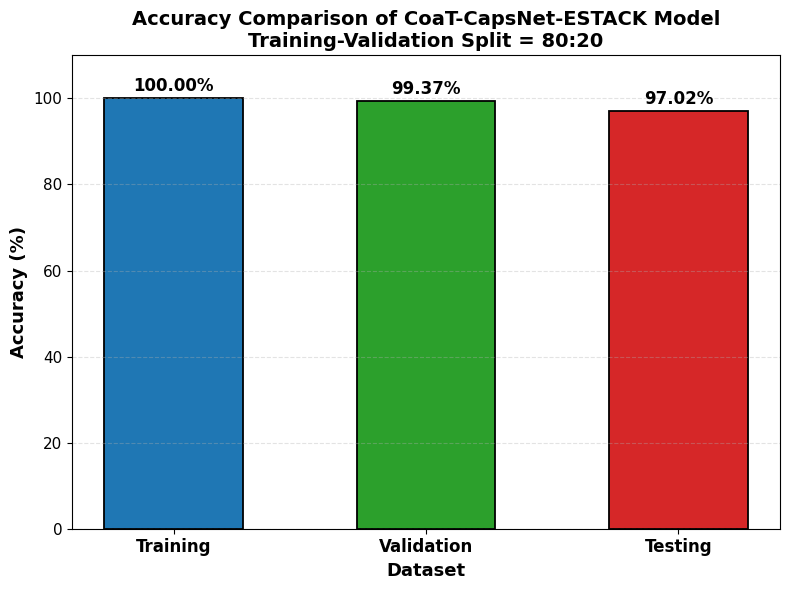

Bar graph saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /graphs_from_actual_results_80_20/actual_accuracy_comparison_bar_graph_80_20_300dpi.png
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /graphs_from_actual_results_80_20/actual_accuracy_comparison_bar_graph_80_20.pdf


In [ ]:
# ============================================================
# CELL 31 — Bar Graph from Actual Result Summary
# No manual accuracy values
# ============================================================

df_accuracy = df_actual_summary[
    ["Dataset", "Accuracy (%)"]
].copy()

display(df_accuracy)

accuracy_csv_path = os.path.join(
    GRAPH_DIR,
    "actual_training_validation_testing_accuracy_80_20.csv"
)

df_accuracy.to_csv(
    accuracy_csv_path,
    index=False
)

print("Accuracy CSV saved at:")
print(accuracy_csv_path)


plt.figure(figsize=(8, 6))

datasets = df_accuracy["Dataset"]
accuracies = df_accuracy["Accuracy (%)"]

colors = [
    "#1F77B4",
    "#2CA02C",
    "#D62728"
]

bars = plt.bar(
    datasets,
    accuracies,
    color=colors,
    edgecolor="black",
    linewidth=1.3,
    width=0.55
)

for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.7,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.ylim(0, 110)

plt.ylabel(
    "Accuracy (%)",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel(
    "Dataset",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "Accuracy Comparison of CoaT-CapsNet-ESTACK Model\n"
    "Training-Validation Split = 80:20",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=11)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

plt.tight_layout()

bar_png_path = os.path.join(
    GRAPH_DIR,
    "actual_accuracy_comparison_bar_graph_80_20_300dpi.png"
)

bar_pdf_path = os.path.join(
    GRAPH_DIR,
    "actual_accuracy_comparison_bar_graph_80_20.pdf"
)

plt.savefig(bar_png_path, dpi=300, bbox_inches="tight")
plt.savefig(bar_pdf_path, bbox_inches="tight")

plt.show()

print("Bar graph saved at:")
print(bar_png_path)
print(bar_pdf_path)

Cell 32 — Class-wise Accuracy from Actual Predictions

In [ ]:
# ============================================================
# CELL 32 — Class-wise Accuracy from Actual Predictions
# No direct/manual class-wise values
# ============================================================

def get_classwise_accuracy(y_true, y_pred, class_names):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(class_names))
    )

    class_accuracy = []

    for i in range(len(class_names)):
        total = cm[i, :].sum()
        correct = cm[i, i]

        if total == 0:
            acc = 0.0
        else:
            acc = correct / total

        class_accuracy.append(acc * 100)

    return np.array(class_accuracy)


train_class_acc = get_classwise_accuracy(
    y_train_estack,
    train_actual_results["y_pred"],
    classes
)

val_class_acc = get_classwise_accuracy(
    y_val_estack,
    val_actual_results["y_pred"],
    classes
)

test_class_acc = get_classwise_accuracy(
    y_test_estack,
    test_actual_results["y_pred"],
    classes
)


df_class_acc = pd.DataFrame({
    "Class": classes,
    "Training Accuracy (%)": train_class_acc,
    "Validation Accuracy (%)": val_class_acc,
    "Testing Accuracy (%)": test_class_acc
})

display(df_class_acc)

class_acc_csv_path = os.path.join(
    GRAPH_DIR,
    "actual_class_wise_train_val_test_accuracy_80_20.csv"
)

df_class_acc.to_csv(
    class_acc_csv_path,
    index=False
)

print("Class-wise accuracy CSV saved at:")
print(class_acc_csv_path)

,Class,Training Accuracy (%),Validation Accuracy (%),Testing Accuracy (%)
0,Bound_Angle_Pose,100.0,99.310345,98.571429
1,Cobra_Pose,100.0,98.611111,95.890411
2,Downdog_Pose,100.0,100.000000,100.000000
3,Goddess_Pose,100.0,99.300699,98.095238
4,Plank_Pose,100.0,99.212598,90.000000
5,Tree_Pose,100.0,100.000000,100.000000
6,Warrior2_Pose,100.0,99.270073,96.052632


Class-wise accuracy CSV saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /graphs_from_actual_results_80_20/actual_class_wise_train_val_test_accuracy_80_20.csv


Cell 33 — Class-wise Grouped Bar Graph from Actual Values

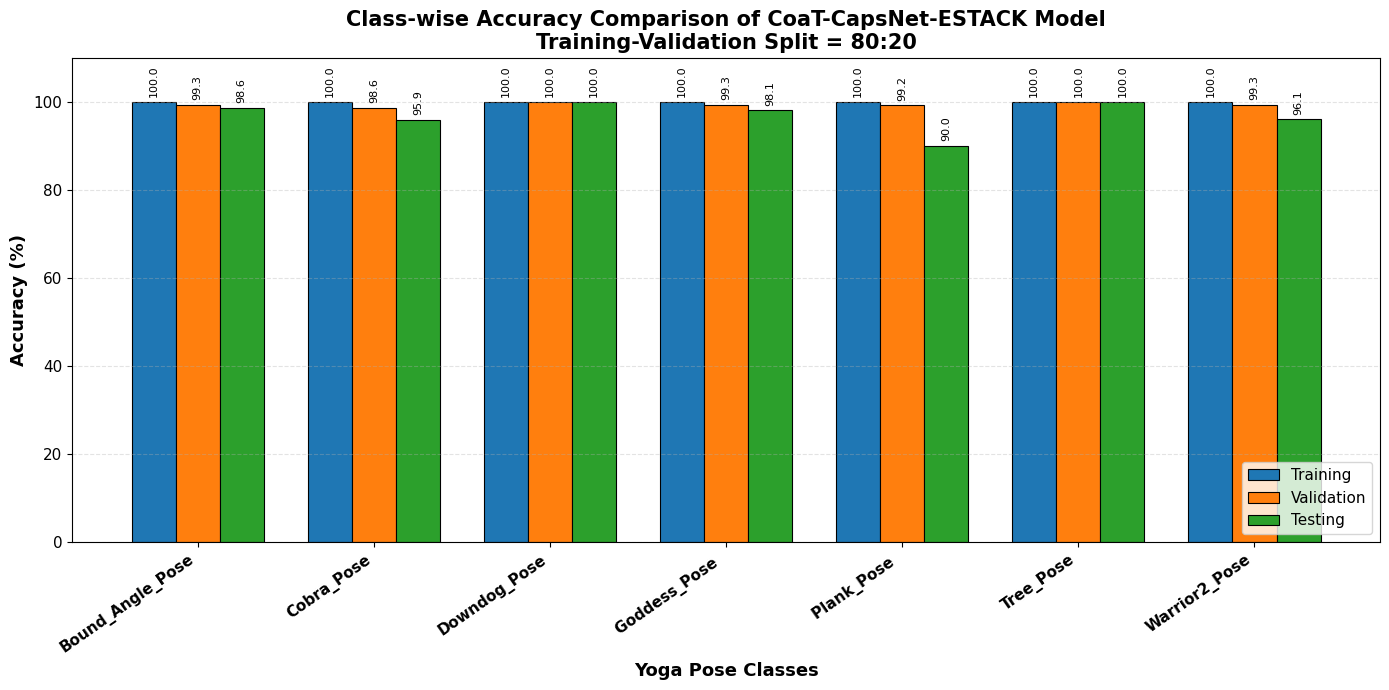

Class-wise bar graph saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /graphs_from_actual_results_80_20/actual_class_wise_train_val_test_accuracy_bar_graph_80_20_300dpi.png
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /graphs_from_actual_results_80_20/actual_class_wise_train_val_test_accuracy_bar_graph_80_20.pdf


In [ ]:
# ============================================================
# CELL 33 — Class-wise Grouped Bar Graph from Actual Values
# ============================================================

class_labels = df_class_acc["Class"].tolist()

x = np.arange(len(class_labels))
width = 0.25

plt.figure(figsize=(14, 7))

bars1 = plt.bar(
    x - width,
    df_class_acc["Training Accuracy (%)"],
    width,
    label="Training",
    edgecolor="black",
    linewidth=0.8
)

bars2 = plt.bar(
    x,
    df_class_acc["Validation Accuracy (%)"],
    width,
    label="Validation",
    edgecolor="black",
    linewidth=0.8
)

bars3 = plt.bar(
    x + width,
    df_class_acc["Testing Accuracy (%)"],
    width,
    label="Testing",
    edgecolor="black",
    linewidth=0.8
)

plt.xlabel("Yoga Pose Classes", fontsize=13, fontweight="bold")
plt.ylabel("Accuracy (%)", fontsize=13, fontweight="bold")

plt.title(
    "Class-wise Accuracy Comparison of CoaT-CapsNet-ESTACK Model\n"
    "Training-Validation Split = 80:20",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(
    x,
    class_labels,
    rotation=35,
    ha="right",
    fontsize=11,
    fontweight="bold"
)

plt.yticks(fontsize=11)
plt.ylim(0, 110)

plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend(fontsize=11, loc="lower right", frameon=True)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

plt.tight_layout()

class_bar_png_path = os.path.join(
    GRAPH_DIR,
    "actual_class_wise_train_val_test_accuracy_bar_graph_80_20_300dpi.png"
)

class_bar_pdf_path = os.path.join(
    GRAPH_DIR,
    "actual_class_wise_train_val_test_accuracy_bar_graph_80_20.pdf"
)

plt.savefig(class_bar_png_path, dpi=300, bbox_inches="tight")
plt.savefig(class_bar_pdf_path, bbox_inches="tight")

plt.show()

print("Class-wise bar graph saved at:")
print(class_bar_png_path)
print(class_bar_pdf_path)

Cell 34 — Class-wise Line Graph from Actual Values

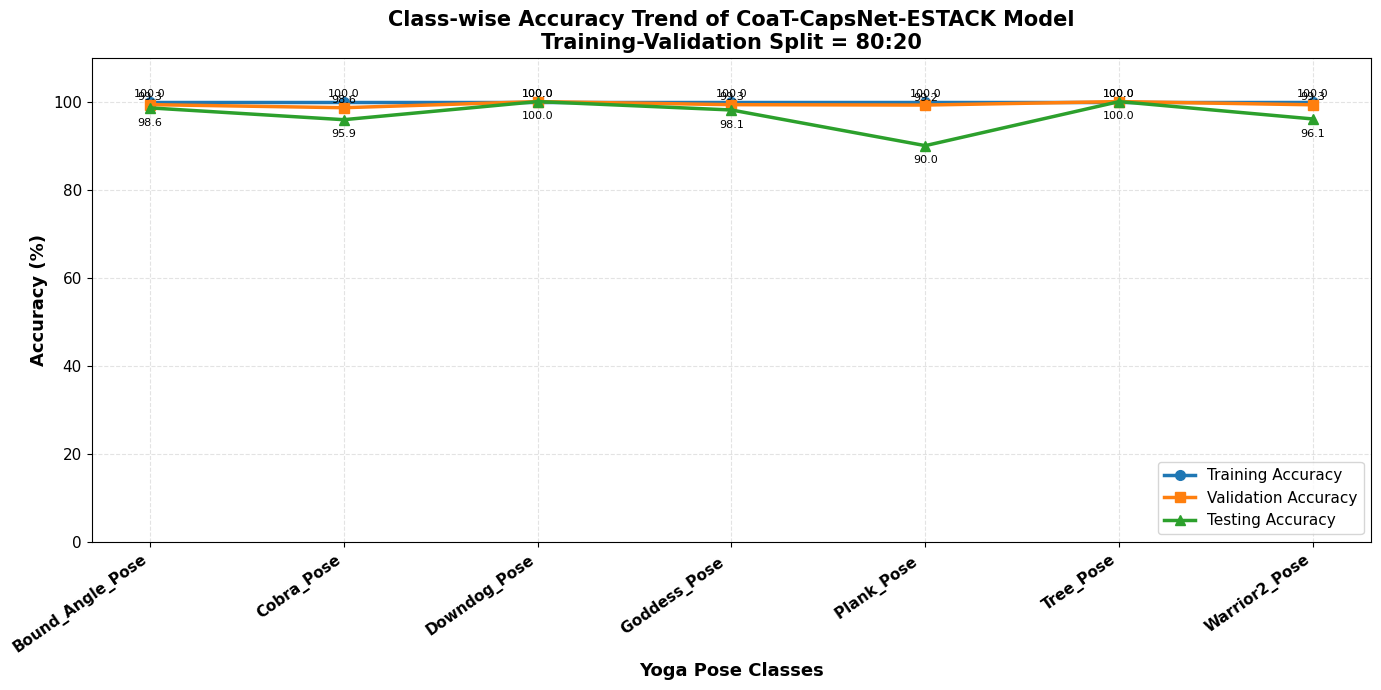

Class-wise line graph saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /graphs_from_actual_results_80_20/actual_class_wise_train_val_test_accuracy_line_graph_70_30_300dpi.png
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /graphs_from_actual_results_80_20/actual_class_wise_train_val_test_accuracy_line_graph_70_30.pdf


In [ ]:
# ============================================================
# CELL 34 — Class-wise Line Graph from Actual Values
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    class_labels,
    df_class_acc["Training Accuracy (%)"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Training Accuracy"
)

plt.plot(
    class_labels,
    df_class_acc["Validation Accuracy (%)"],
    marker="s",
    linewidth=2.5,
    markersize=7,
    label="Validation Accuracy"
)

plt.plot(
    class_labels,
    df_class_acc["Testing Accuracy (%)"],
    marker="^",
    linewidth=2.5,
    markersize=7,
    label="Testing Accuracy"
)

plt.xlabel("Yoga Pose Classes", fontsize=13, fontweight="bold")
plt.ylabel("Accuracy (%)", fontsize=13, fontweight="bold")

plt.title(
    "Class-wise Accuracy Trend of CoaT-CapsNet-ESTACK Model\n"
    "Training-Validation Split = 80:20",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(
    rotation=35,
    ha="right",
    fontsize=11,
    fontweight="bold"
)

plt.yticks(fontsize=11)
plt.ylim(0, 110)

plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(fontsize=11, loc="lower right", frameon=True)

for i, cls in enumerate(class_labels):
    plt.text(
        i,
        df_class_acc["Training Accuracy (%)"].iloc[i] + 1,
        f"{df_class_acc['Training Accuracy (%)'].iloc[i]:.1f}",
        ha="center",
        fontsize=8
    )

    plt.text(
        i,
        df_class_acc["Validation Accuracy (%)"].iloc[i] + 1,
        f"{df_class_acc['Validation Accuracy (%)'].iloc[i]:.1f}",
        ha="center",
        fontsize=8
    )

    plt.text(
        i,
        df_class_acc["Testing Accuracy (%)"].iloc[i] - 4,
        f"{df_class_acc['Testing Accuracy (%)'].iloc[i]:.1f}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()

class_line_png_path = os.path.join(
    GRAPH_DIR,
    "actual_class_wise_train_val_test_accuracy_line_graph_70_30_300dpi.png"
)

class_line_pdf_path = os.path.join(
    GRAPH_DIR,
    "actual_class_wise_train_val_test_accuracy_line_graph_70_30.pdf"
)

plt.savefig(class_line_png_path, dpi=300, bbox_inches="tight")
plt.savefig(class_line_pdf_path, bbox_inches="tight")

plt.show()

print("Class-wise line graph saved at:")
print(class_line_png_path)
print(class_line_pdf_path)

Cell 35 — Class-wise Accuracy Heatmap from Actual Values

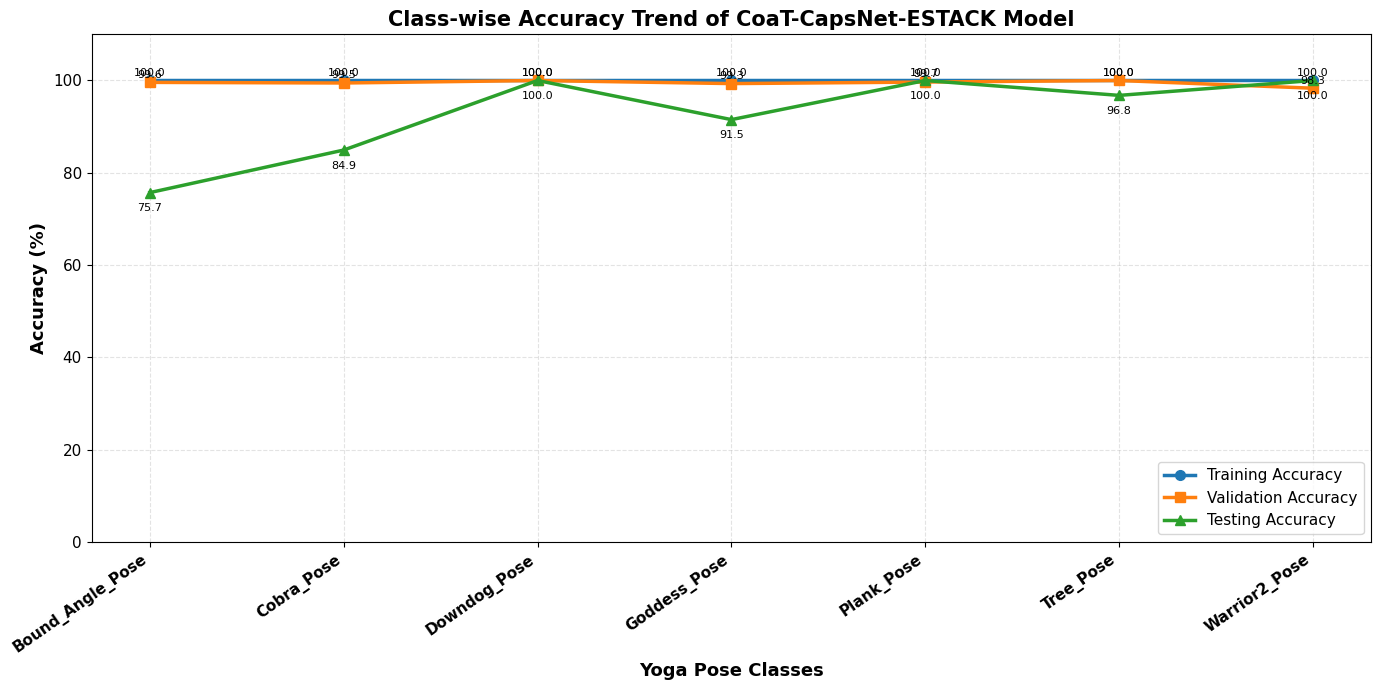

Combined class-wise line graph saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack_Final Version- journal 1/graphs_7030split/class_wise_accuracy/class_wise_train_val_test_accuracy_line_graph_300dpi.png
/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack_Final Version- journal 1/graphs_7030split/class_wise_accuracy/class_wise_train_val_test_accuracy_line_graph.pdf


In [ ]:
# ============================================================
# CELL 35 — Class-wise Accuracy Heatmap from Actual Values
# ============================================================

heatmap_data = df_class_acc[
    [
        "Training Accuracy (%)",
        "Validation Accuracy (%)",
        "Testing Accuracy (%)"
    ]
].values

class_labels = df_class_acc["Class"].tolist()
metric_labels = ["Training", "Validation", "Testing"]

vmin_value = max(0, np.floor(np.nanmin(heatmap_data) - 5))
vmax_value = 100

plt.figure(figsize=(10, 7))

im = plt.imshow(
    heatmap_data,
    cmap="YlOrRd",
    aspect="auto",
    vmin=vmin_value,
    vmax=vmax_value
)

cbar = plt.colorbar(im)
cbar.set_label("Accuracy (%)", fontsize=12, fontweight="bold")
cbar.ax.tick_params(labelsize=10)

plt.xticks(
    ticks=np.arange(len(metric_labels)),
    labels=metric_labels,
    fontsize=12,
    fontweight="bold"
)

plt.yticks(
    ticks=np.arange(len(class_labels)),
    labels=class_labels,
    fontsize=11,
    fontweight="bold"
)

for i in range(len(class_labels)):
    for j in range(len(metric_labels)):
        value = heatmap_data[i, j]

        text_color = "white" if value >= 92 else "black"

        plt.text(
            j,
            i,
            f"{value:.2f}%",
            ha="center",
            va="center",
            color=text_color,
            fontsize=10,
            fontweight="bold"
        )

plt.title(
    "Class-wise Accuracy Heatmap of CoaT-CapsNet-ESTACK\n"
    "Training-Validation Split = 80:20, Separate Test Dataset",
    fontsize=14,
    fontweight="bold",
    pad=18
)

plt.xlabel("Dataset", fontsize=13, fontweight="bold")
plt.ylabel("Yoga Pose Classes", fontsize=13, fontweight="bold")

plt.tight_layout()

heatmap_png = os.path.join(
    GRAPH_DIR,
    "actual_class_wise_accuracy_heatmap_80_20_300dpi.png"
)

heatmap_pdf = os.path.join(
    GRAPH_DIR,
    "actual_class_wise_accuracy_heatmap_80_20.pdf"
)

plt.savefig(heatmap_png, dpi=300, bbox_inches="tight")
plt.savefig(heatmap_pdf, bbox_inches="tight")

plt.show()

print("Class-wise heatmap saved at:")
print(heatmap_png)
print(heatmap_pdf)

Cell 36 — Combined Final Result Summary for Overleaf/Origin

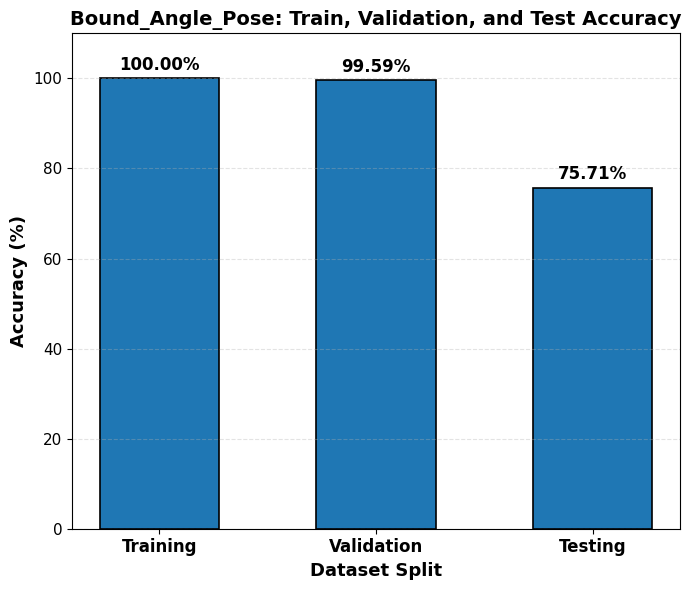

Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/70_30_Dataset Split /graphs_7030split/class_wise_accuracy/individual_class_graphs/Bound_Angle_Pose_train_val_test_accuracy_300dpi.png
Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/70_30_Dataset Split /graphs_7030split/class_wise_accuracy/individual_class_graphs/Bound_Angle_Pose_train_val_test_accuracy.pdf


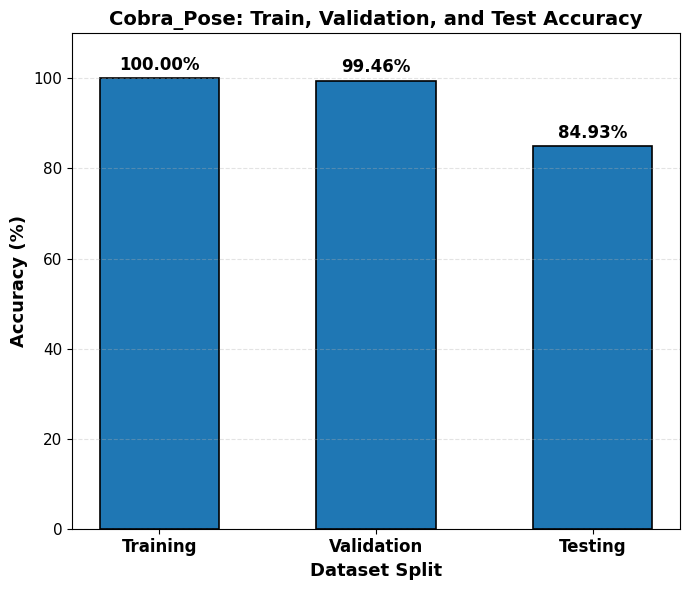

Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/70_30_Dataset Split /graphs_7030split/class_wise_accuracy/individual_class_graphs/Cobra_Pose_train_val_test_accuracy_300dpi.png
Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/70_30_Dataset Split /graphs_7030split/class_wise_accuracy/individual_class_graphs/Cobra_Pose_train_val_test_accuracy.pdf


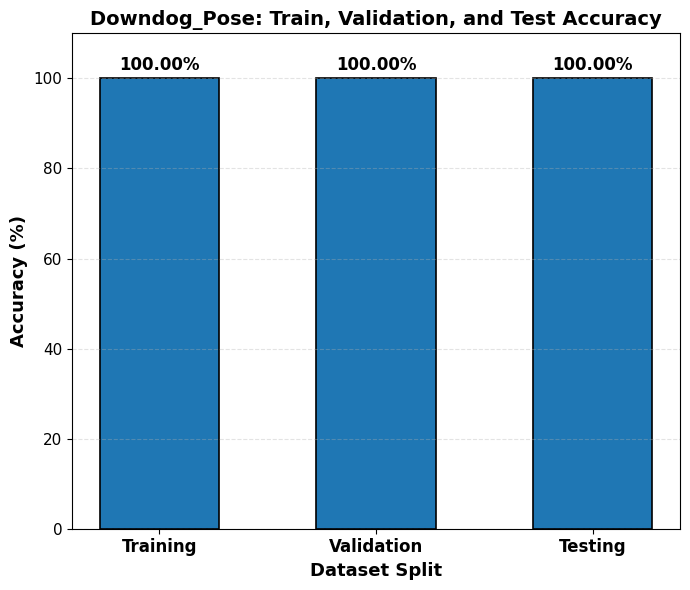

Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/70_30_Dataset Split /graphs_7030split/class_wise_accuracy/individual_class_graphs/Downdog_Pose_train_val_test_accuracy_300dpi.png
Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/70_30_Dataset Split /graphs_7030split/class_wise_accuracy/individual_class_graphs/Downdog_Pose_train_val_test_accuracy.pdf


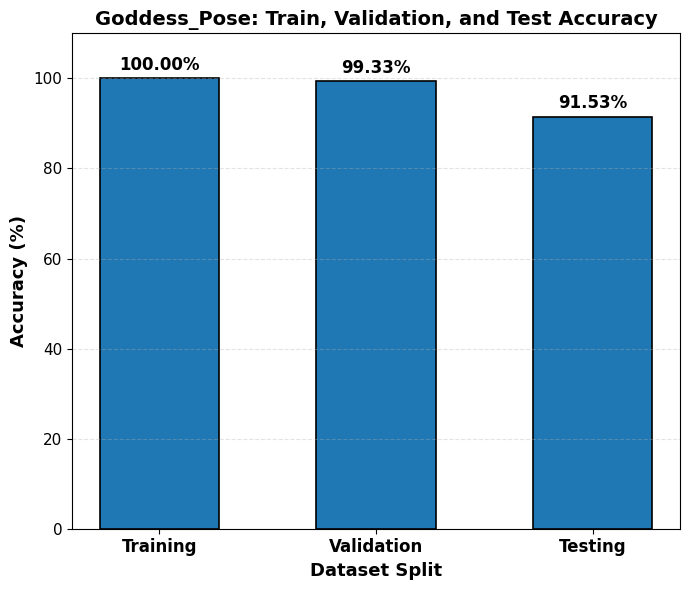

Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/70_30_Dataset Split /graphs_7030split/class_wise_accuracy/individual_class_graphs/Goddess_Pose_train_val_test_accuracy_300dpi.png
Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/70_30_Dataset Split /graphs_7030split/class_wise_accuracy/individual_class_graphs/Goddess_Pose_train_val_test_accuracy.pdf


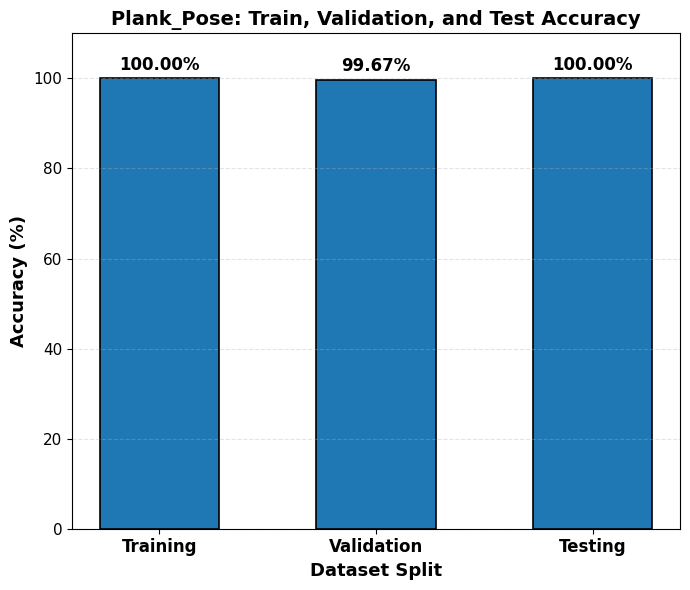

Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/70_30_Dataset Split /graphs_7030split/class_wise_accuracy/individual_class_graphs/Plank_Pose_train_val_test_accuracy_300dpi.png
Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/70_30_Dataset Split /graphs_7030split/class_wise_accuracy/individual_class_graphs/Plank_Pose_train_val_test_accuracy.pdf


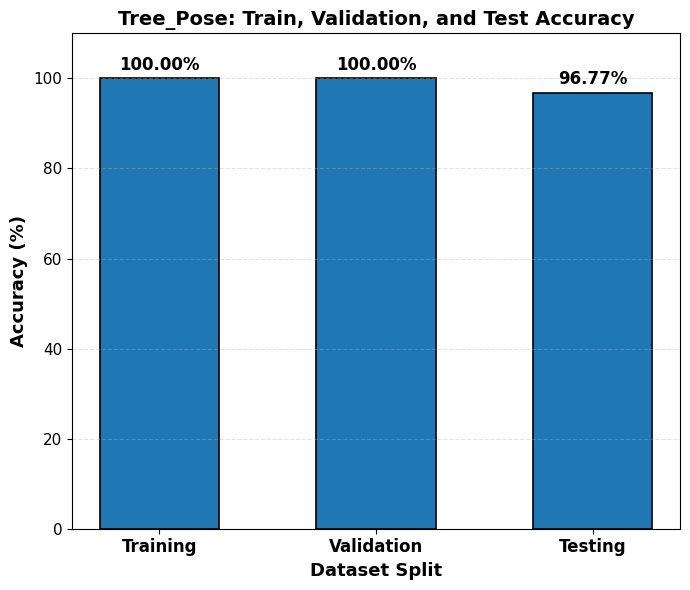

Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/70_30_Dataset Split /graphs_7030split/class_wise_accuracy/individual_class_graphs/Tree_Pose_train_val_test_accuracy_300dpi.png
Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/70_30_Dataset Split /graphs_7030split/class_wise_accuracy/individual_class_graphs/Tree_Pose_train_val_test_accuracy.pdf


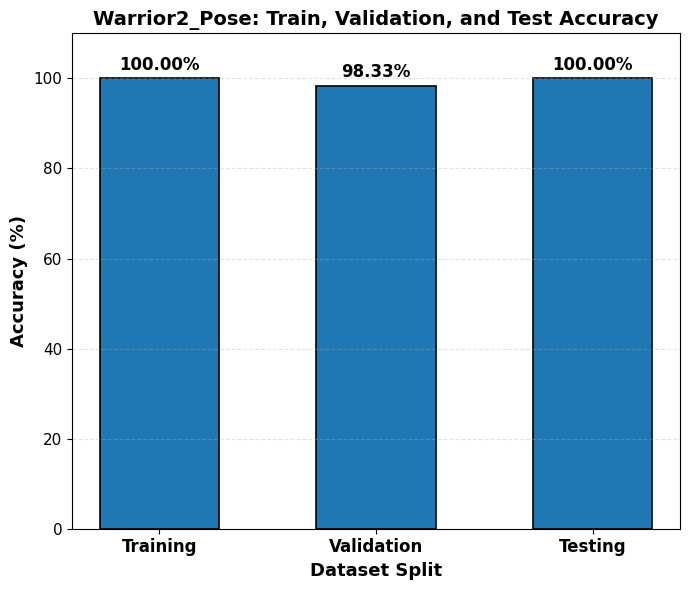

Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/70_30_Dataset Split /graphs_7030split/class_wise_accuracy/individual_class_graphs/Warrior2_Pose_train_val_test_accuracy_300dpi.png
Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/70_30_Dataset Split /graphs_7030split/class_wise_accuracy/individual_class_graphs/Warrior2_Pose_train_val_test_accuracy.pdf


In [ ]:
# ============================================================
# CELL 36 — Final Result Summary for Overleaf / Origin
# Fetched from actual computed results
# ============================================================

df_validation_testing_summary = df_actual_summary[
    df_actual_summary["Dataset"].isin(["Validation", "Testing"])
].copy()

df_validation_testing_summary = df_validation_testing_summary.reset_index(drop=True)

display(df_validation_testing_summary)

summary_csv_path = os.path.join(
    GRAPH_DIR,
    "final_validation_testing_summary_for_origin_overleaf_80_20.csv"
)

df_validation_testing_summary.to_csv(
    summary_csv_path,
    index=False
)

print("Final validation/testing summary saved at:")
print(summary_csv_path)

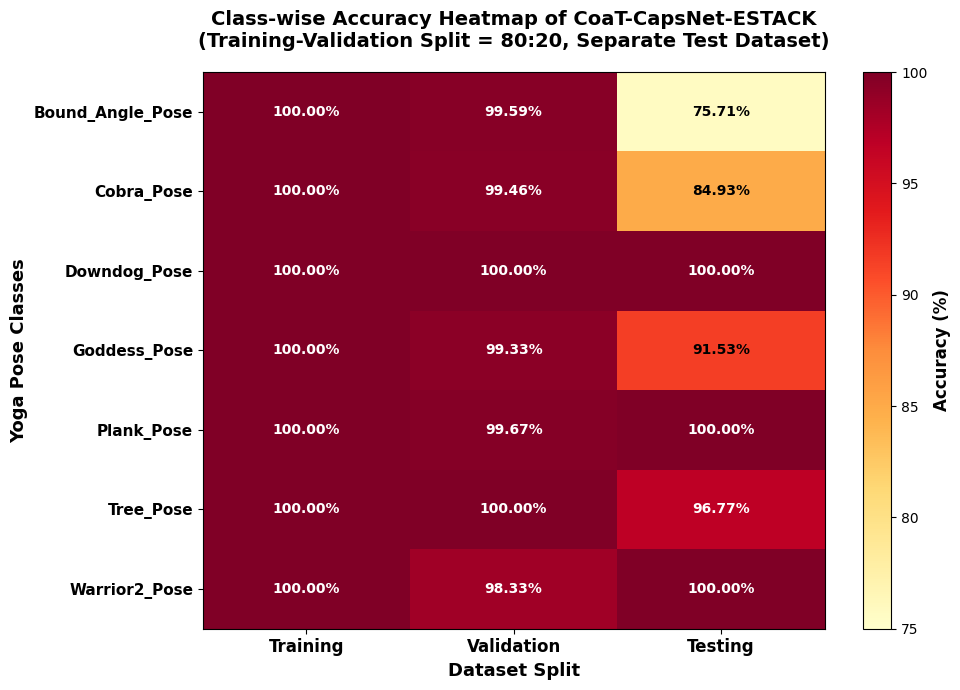

Saved:
/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack_Final Version- journal 1/final_graphs_ssci/class_wise_accuracy/class_wise_accuracy_heatmap_80_20_split_300dpi.png
/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack_Final Version- journal 1/final_graphs_ssci/class_wise_accuracy/class_wise_accuracy_heatmap_80_20_split.pdf


In [ ]:
# ============================================================
# Stylish Heatmap: Class-wise Train/Val/Test Accuracy
# 300 DPI Publication Quality
# Updated: mentions 80:20 split + improved colors/text visibility
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

GRAPH_DIR = "/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split/final_graphs_ssci/class_wise_accuracy"
os.makedirs(GRAPH_DIR, exist_ok=True)

# df_class_acc should already contain:
# Class, Training Accuracy (%), Validation Accuracy (%), Testing Accuracy (%)

heatmap_data = df_class_acc[
    [
        "Training Accuracy (%)",
        "Validation Accuracy (%)",
        "Testing Accuracy (%)"
    ]
].values

class_labels = df_class_acc["Class"].tolist()
metric_labels = ["Training", "Validation", "Testing"]

plt.figure(figsize=(10, 7))

# Better colormap for readability
im = plt.imshow(
    heatmap_data,
    cmap="YlOrRd",   # changed from YlGnBu
    aspect="auto",
    vmin=75,         # better contrast for high-accuracy values
    vmax=100
)

cbar = plt.colorbar(im)
cbar.set_label("Accuracy (%)", fontsize=12, fontweight="bold")
cbar.ax.tick_params(labelsize=10)

plt.xticks(
    ticks=np.arange(len(metric_labels)),
    labels=metric_labels,
    fontsize=12,
    fontweight="bold"
)

plt.yticks(
    ticks=np.arange(len(class_labels)),
    labels=class_labels,
    fontsize=11,
    fontweight="bold"
)

# Add accuracy values inside cells with dynamic text color
for i in range(len(class_labels)):
    for j in range(len(metric_labels)):
        value = heatmap_data[i, j]

        # White text for dark cells, black for light cells
        text_color = "white" if value >= 92 else "black"

        plt.text(
            j,
            i,
            f"{value:.2f}%",
            ha="center",
            va="center",
            color=text_color,
            fontsize=10,
            fontweight="bold"
        )

plt.title(
    "Class-wise Accuracy Heatmap of CoaT-CapsNet-ESTACK\n(Training-Validation Split = 80:20, Separate Test Dataset)",
    fontsize=14,
    fontweight="bold",
    pad=18
)

plt.xlabel("Dataset Split", fontsize=13, fontweight="bold")
plt.ylabel("Yoga Pose Classes", fontsize=13, fontweight="bold")

plt.tight_layout()

heatmap_png = os.path.join(GRAPH_DIR, "class_wise_accuracy_heatmap_80_20_split_300dpi.png")
heatmap_pdf = os.path.join(GRAPH_DIR, "class_wise_accuracy_heatmap_80_20_split.pdf")

plt.savefig(heatmap_png, dpi=300, bbox_inches="tight")
plt.savefig(heatmap_pdf, bbox_inches="tight")

plt.show()

print("Saved:")
print(heatmap_png)
print(heatmap_pdf)

In [ ]:
# Check current split distribution

import numpy as np
import pandas as pd

split_rows = []

for i, cls_name in enumerate(classes):
    train_count = int(np.sum(train_labels == i))
    val_count = int(np.sum(val_labels == i))
    test_count = int(np.sum(test_labels == i))

    total = train_count + val_count

    train_percent = (train_count / total) * 100 if total > 0 else 0
    val_percent = (val_count / total) * 100 if total > 0 else 0

    split_rows.append([
        cls_name,
        train_count,
        val_count,
        test_count,
        round(train_percent, 2),
        round(val_percent, 2)
    ])

df_split_check = pd.DataFrame(
    split_rows,
    columns=[
        "class_name",
        "train_images",
        "val_images",
        "test_images",
        "train_percent",
        "val_percent"
    ]
)

display(df_split_check)

NameError: name 'classes' is not defined

In [ ]:
# ============================================================
# Correct Final Result Summary from Actual val_results/test_results
# ============================================================

import pandas as pd
import os

summary_rows = [
    [
        "Validation",
        val_results["accuracy"],
        val_results["precision"],
        val_results["recall"],
        val_results["f1_score"],
        val_results["auc_roc"]
    ],
    [
        "Test",
        test_results["accuracy"],
        test_results["precision"],
        test_results["recall"],
        test_results["f1_score"],
        test_results["auc_roc"]
    ]
]

df_actual_summary = pd.DataFrame(
    summary_rows,
    columns=[
        "Dataset",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC-ROC"
    ]
)

display(df_actual_summary)

actual_summary_path = os.path.join(
    CACHE_DIR,
    "actual_validation_test_result_summary.csv"
)

df_actual_summary.to_csv(actual_summary_path, index=False)

print("Actual result summary saved at:")
print(actual_summary_path)

,Dataset,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Validation,99.373695,99.376957,99.373695,99.374143,99.940185
1,Test,97.017544,97.044555,97.017544,97.000310,99.936905


Actual result summary saved at:
/content/drive/MyDrive/PhD_Research_2025-2027 /Cocasnet-Journal Paper 1_140626/80_20_Dataset Split /actual_validation_test_result_summary.csv


# Date= 04th June 2026
Original dataset → Quality check → Full body check → Save good images → SDXL augmentation only from good images → Generated image recheck → Final 1000 images per class

# Best pipeline for high-quality yoga augmentation(yeh SDXL wala hai)
Recommended method

Real good image → SDXL image-to-image → optional IP-Adapter / Canny / Depth control → quality filter → save

Use your real good-quality yoga image as the starting image, not only an OpenPose skeleton. Keep denoising strength low/medium so the pose remains correct.

SDXL works best around 1024 × 1024 and has a two-stage base/refiner design for better details. Lower resolutions can produce blurry/simple images.

IP-Adapter is useful because it allows image prompting and can be combined with ControlNet-like controls, so the generated image stays closer to your real reference image.

ControlNet is still useful, but use it for Canny/Depth/Tile more than OpenPose-only, because ControlNet uses extra condition images such as pose, depth, sketch, or edge maps to control generation.

#Why your generated images were skipped during precompute cache

Most probably your cache code skipped them because generated images had one or more problems:

Problem in generated image	Why cache/precompute skipped it
Blurry body	Low image-quality score
Extra hands/legs	Pose detector failed
Cropped body	Full skeleton not detected
Wrong yoga pose	Class/prediction mismatch
Face/body distortion	Human landmark detector failed
Too dark/too bright	Quality filter rejected
Multiple humans	Pose pipeline expected one person

So first generate images, then run an automatic quality validation gate.

Cell 1 - Install Libraries

In [ ]:
# Cell 1 - Install Libraries Without Dependency Error

!pip -q uninstall -y pandas pillow

!pip -q install --no-cache-dir "pandas==2.2.2" "pillow==11.3.0"

!pip -q install --no-cache-dir \
diffusers \
transformers \
accelerate \
safetensors \
huggingface_hub \
opencv-python \
tqdm \
ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 270.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 286.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 135.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.0 MB/s eta 0:00:00


Cell 2 — Import Libraries

In [ ]:
import os
import cv2
import gc
import uuid
import time
import math
import random
import shutil
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image, ImageOps

import torch

from google.colab import drive
from ultralytics import YOLO
from diffusers import StableDiffusionXLImg2ImgPipeline

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Cell 3 — Mount Drive and Set Paths

In [ ]:
drive.mount("/content/drive", force_remount=True)

# =========================================================
# CHANGE PATHS IF REQUIRED
# =========================================================

INPUT_DIR = Path("/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_final_set")

GOOD_DIR = Path("/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_good_only")

GENERATED_DIR = Path("/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_generated_only")

REJECTED_GENERATED_DIR = Path("/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_rejected_generated")

FINAL_DIR = Path("/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_final_1000_each")

REPORT_DIR = Path("/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /augmentation_reports")

# Create folders
GOOD_DIR.mkdir(parents=True, exist_ok=True)
GENERATED_DIR.mkdir(parents=True, exist_ok=True)
REJECTED_GENERATED_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# Dataset settings
# =========================================================

VALID_EXTS = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]
TARGET_IMAGES_PER_CLASS = 1000

# SDXL size
TARGET_SIZE = 768

# If GPU memory issue, set TARGET_SIZE = 768
LOW_VRAM_MODE = True

# =========================================================
# Quality thresholds
# =========================================================

MIN_RESOLUTION = 256
MIN_BLUR_SCORE = 45
MIN_BRIGHTNESS = 35
MAX_BRIGHTNESS = 235
MIN_CONTRAST = 18

# =========================================================
# YOLO pose settings
# =========================================================

POSE_MODEL_NAME = "yolov8n-pose.pt"
YOLO_PERSON_CONF = 0.25
KEYPOINT_CONF_THRESHOLD = 0.30

# relaxed is recommended for yoga
FULL_BODY_MODE = "relaxed"

# =========================================================
# SDXL generation settings
# =========================================================

NUM_INFERENCE_STEPS = 25

# Low/medium strength keeps pose closer to original
MIN_STRENGTH = 0.25
MAX_STRENGTH = 0.45

MIN_GUIDANCE_SCALE = 5.0
MAX_GUIDANCE_SCALE = 7.5

MAX_ATTEMPTS_PER_REQUIRED_IMAGE = 8

print("INPUT_DIR:", INPUT_DIR)
print("GOOD_DIR:", GOOD_DIR)
print("GENERATED_DIR:", GENERATED_DIR)
print("REJECTED_GENERATED_DIR:", REJECTED_GENERATED_DIR)
print("FINAL_DIR:", FINAL_DIR)
print("REPORT_DIR:", REPORT_DIR)
print("TARGET_IMAGES_PER_CLASS:", TARGET_IMAGES_PER_CLASS)
print("TARGET_SIZE:", TARGET_SIZE)
print("LOW_VRAM_MODE:", LOW_VRAM_MODE)

Mounted at /content/drive
INPUT_DIR: /content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_final_set
GOOD_DIR: /content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_good_only
GENERATED_DIR: /content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_generated_only
REJECTED_GENERATED_DIR: /content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_rejected_generated
FINAL_DIR: /content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_final_1000_each
REPORT_DIR: /content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /augmentation_reports
TARGET_IMAGES_PER_CLASS: 1000
TARGET_SIZE: 768
LOW_VRAM_MODE: True


Cell 4 — Check Original Dataset

In [ ]:
if not INPUT_DIR.exists():
    raise FileNotFoundError(f"Input folder not found: {INPUT_DIR}")

class_folders = sorted([p for p in INPUT_DIR.iterdir() if p.is_dir()])

if len(class_folders) == 0:
    raise ValueError("No class folders found inside INPUT_DIR")

original_rows = []

print("Original Dataset Summary")
print("-" * 80)

for cls in class_folders:
    image_files = [
        f for f in cls.iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTS
    ]

    original_rows.append([cls.name, len(image_files)])
    print(f"{cls.name}: {len(image_files)} images")

df_original = pd.DataFrame(original_rows, columns=["class_name", "original_count"])

display(df_original)

original_report_path = REPORT_DIR / "original_dataset_summary.csv"
df_original.to_csv(original_report_path, index=False)

print("Saved:", original_report_path)

Original Dataset Summary
--------------------------------------------------------------------------------
Bound_Angle_Pose: 402 images
Cobra_Pose: 913 images
camatkarasana: 116 images
downdog: 573 images
goddess: 260 images
plank: 568 images
tree: 602 images
warrior2: 737 images


,class_name,original_count
0,Bound_Angle_Pose,402
1,Cobra_Pose,913
2,camatkarasana,116
3,downdog,573
4,goddess,260
5,plank,568
6,tree,602
7,warrior2,737


Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /augmentation_reports/original_dataset_summary.csv


Cell 5 se pehle ye new cell add karo:

In [ ]:
# ============================================================
# Cell 5: Load YOLOv8 Pose Model
# MediaPipe removed
# ============================================================

pose_model = YOLO(POSE_MODEL_NAME)

print("YOLO pose model loaded successfully.")
print("Model:", POSE_MODEL_NAME)

YOLO pose model loaded successfully.
Model: yolov8n-pose.pt


Cell 6 — Quality Check + YOLO Full Body Check Functions

In [ ]:
# ============================================================
# Cell 6: Quality Check + YOLO Full Body Check Functions
# ============================================================

def compute_image_quality_metrics(img_path):
    """
    Computes:
    - resolution
    - blur score
    - brightness
    - contrast
    """

    img = cv2.imread(str(img_path))

    if img is None:
        return None

    h, w = img.shape[:2]

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    brightness = gray.mean()
    contrast = gray.std()
    min_side = min(h, w)

    return {
        "width": w,
        "height": h,
        "min_side": min_side,
        "blur_score": float(blur_score),
        "brightness": float(brightness),
        "contrast": float(contrast)
    }


def is_good_image_quality(metrics):
    if metrics is None:
        return False, "read_error"

    if metrics["min_side"] < MIN_RESOLUTION:
        return False, "low_resolution"

    if metrics["blur_score"] < MIN_BLUR_SCORE:
        return False, "blurry"

    if metrics["brightness"] < MIN_BRIGHTNESS:
        return False, "too_dark"

    if metrics["brightness"] > MAX_BRIGHTNESS:
        return False, "too_bright"

    if metrics["contrast"] < MIN_CONTRAST:
        return False, "low_contrast"

    return True, "good_quality"


def yolo_pose_full_body_check(img_path):
    """
    YOLOv8-pose based full body check.

    COCO keypoint index:
    0 nose
    5 left shoulder
    6 right shoulder
    7 left elbow
    8 right elbow
    9 left wrist
    10 right wrist
    11 left hip
    12 right hip
    13 left knee
    14 right knee
    15 left ankle
    16 right ankle
    """

    try:
        img = Image.open(img_path)
        img = ImageOps.exif_transpose(img)
        img = img.convert("RGB")
        width, height = img.size

    except Exception:
        return {
            "full_body_status": False,
            "full_body_reason": "image_read_error",
            "pose_detected": False,
            "person_count": 0,
            "visible_main_points": 0,
            "visible_torso_points": 0,
            "visible_leg_points": 0,
            "visible_hand_points": 0,
            "visible_ankle_points": 0,
            "body_width_ratio": 0,
            "body_height_ratio": 0,
            "bbox_area_ratio": 0
        }

    try:
        results = pose_model.predict(
            source=str(img_path),
            imgsz=640,
            conf=YOLO_PERSON_CONF,
            verbose=False
        )

    except Exception as e:
        return {
            "full_body_status": False,
            "full_body_reason": f"yolo_error_{str(e)[:50]}",
            "pose_detected": False,
            "person_count": 0,
            "visible_main_points": 0,
            "visible_torso_points": 0,
            "visible_leg_points": 0,
            "visible_hand_points": 0,
            "visible_ankle_points": 0,
            "body_width_ratio": 0,
            "body_height_ratio": 0,
            "bbox_area_ratio": 0
        }

    if len(results) == 0:
        return {
            "full_body_status": False,
            "full_body_reason": "no_yolo_result",
            "pose_detected": False,
            "person_count": 0,
            "visible_main_points": 0,
            "visible_torso_points": 0,
            "visible_leg_points": 0,
            "visible_hand_points": 0,
            "visible_ankle_points": 0,
            "body_width_ratio": 0,
            "body_height_ratio": 0,
            "bbox_area_ratio": 0
        }

    r = results[0]

    if r.keypoints is None or r.boxes is None:
        return {
            "full_body_status": False,
            "full_body_reason": "no_pose_detected",
            "pose_detected": False,
            "person_count": 0,
            "visible_main_points": 0,
            "visible_torso_points": 0,
            "visible_leg_points": 0,
            "visible_hand_points": 0,
            "visible_ankle_points": 0,
            "body_width_ratio": 0,
            "body_height_ratio": 0,
            "bbox_area_ratio": 0
        }

    keypoints_data = r.keypoints.data

    if keypoints_data is None or len(keypoints_data) == 0:
        return {
            "full_body_status": False,
            "full_body_reason": "no_pose_keypoints",
            "pose_detected": False,
            "person_count": 0,
            "visible_main_points": 0,
            "visible_torso_points": 0,
            "visible_leg_points": 0,
            "visible_hand_points": 0,
            "visible_ankle_points": 0,
            "body_width_ratio": 0,
            "body_height_ratio": 0,
            "bbox_area_ratio": 0
        }

    person_count = len(keypoints_data)

    # Reject multiple humans because yoga classification expects single person
    if person_count > 1:
        return {
            "full_body_status": False,
            "full_body_reason": "multiple_persons_detected",
            "pose_detected": True,
            "person_count": int(person_count),
            "visible_main_points": 0,
            "visible_torso_points": 0,
            "visible_leg_points": 0,
            "visible_hand_points": 0,
            "visible_ankle_points": 0,
            "body_width_ratio": 0,
            "body_height_ratio": 0,
            "bbox_area_ratio": 0
        }

    # Single person
    kpts = keypoints_data[0].cpu().numpy()

    # kpts shape = 17 x 3
    # each keypoint = x, y, confidence

    main_landmarks = [0, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    torso_landmarks = [5, 6, 11, 12]
    leg_landmarks = [11, 12, 13, 14, 15, 16]
    hand_landmarks = [9, 10]
    ankle_landmarks = [15, 16]

    def visible_count(index_list):
        count = 0
        xs = []
        ys = []

        for idx in index_list:
            x, y, conf = kpts[idx]

            inside = (
                x >= 0 and x <= width and
                y >= 0 and y <= height
            )

            if conf >= KEYPOINT_CONF_THRESHOLD and inside:
                count += 1
                xs.append(x)
                ys.append(y)

        return count, xs, ys

    visible_main, main_xs, main_ys = visible_count(main_landmarks)
    visible_torso, _, _ = visible_count(torso_landmarks)
    visible_legs, _, _ = visible_count(leg_landmarks)
    visible_hands, _, _ = visible_count(hand_landmarks)
    visible_ankles, _, _ = visible_count(ankle_landmarks)

    if len(main_xs) == 0:
        return {
            "full_body_status": False,
            "full_body_reason": "landmarks_not_visible",
            "pose_detected": True,
            "person_count": int(person_count),
            "visible_main_points": int(visible_main),
            "visible_torso_points": int(visible_torso),
            "visible_leg_points": int(visible_legs),
            "visible_hand_points": int(visible_hands),
            "visible_ankle_points": int(visible_ankles),
            "body_width_ratio": 0,
            "body_height_ratio": 0,
            "bbox_area_ratio": 0
        }

    # Bounding box
    box = r.boxes.xyxy[0].cpu().numpy()
    x1, y1, x2, y2 = box

    body_width_ratio = float((x2 - x1) / width)
    body_height_ratio = float((y2 - y1) / height)
    bbox_area_ratio = float(((x2 - x1) * (y2 - y1)) / (width * height))

    # ========================================================
    # Relaxed Mode for Yoga
    # ========================================================

    if FULL_BODY_MODE == "relaxed":

        if visible_main < 9:
            status = False
            reason = "too_few_body_keypoints"

        elif visible_torso < 3:
            status = False
            reason = "torso_not_clear"

        elif visible_legs < 4:
            status = False
            reason = "legs_not_clear"

        elif visible_ankles < 1:
            status = False
            reason = "ankle_not_visible"

        elif body_width_ratio > 0.98 or body_height_ratio > 0.98:
            status = False
            reason = "body_too_close_to_border_possible_crop"

        elif bbox_area_ratio < 0.04:
            status = False
            reason = "person_too_small"

        else:
            status = True
            reason = "full_body_visible"

    # ========================================================
    # Strict Mode
    # ========================================================

    else:

        if visible_main < 11:
            status = False
            reason = "too_few_body_keypoints_strict"

        elif visible_torso < 4:
            status = False
            reason = "torso_not_fully_visible_strict"

        elif visible_legs < 5:
            status = False
            reason = "legs_not_fully_visible_strict"

        elif visible_hands < 1:
            status = False
            reason = "hands_not_visible_strict"

        elif visible_ankles < 2:
            status = False
            reason = "ankles_not_visible_strict"

        elif body_width_ratio > 0.95 or body_height_ratio > 0.95:
            status = False
            reason = "body_near_border_strict"

        elif bbox_area_ratio < 0.05:
            status = False
            reason = "person_too_small_strict"

        else:
            status = True
            reason = "full_body_visible_strict"

    return {
        "full_body_status": status,
        "full_body_reason": reason,
        "pose_detected": True,
        "person_count": int(person_count),
        "visible_main_points": int(visible_main),
        "visible_torso_points": int(visible_torso),
        "visible_leg_points": int(visible_legs),
        "visible_hand_points": int(visible_hands),
        "visible_ankle_points": int(visible_ankles),
        "body_width_ratio": body_width_ratio,
        "body_height_ratio": body_height_ratio,
        "bbox_area_ratio": bbox_area_ratio
    }


def final_good_image_check(img_path):
    """
    Final image decision:
    1. Basic image quality should be good
    2. YOLO pose should detect single full body
    """

    quality_metrics = compute_image_quality_metrics(img_path)

    quality_status, quality_reason = is_good_image_quality(quality_metrics)

    if not quality_status:
        return False, quality_reason, quality_metrics, None

    full_body_result = yolo_pose_full_body_check(img_path)

    if not full_body_result["full_body_status"]:
        return False, full_body_result["full_body_reason"], quality_metrics, full_body_result

    return True, "good_quality_full_body", quality_metrics, full_body_result


print("Cell 6 executed successfully.")
print("Quality check + YOLO full body check functions are ready.")

Cell 6 executed successfully.
Quality check + YOLO full body check functions are ready.


Cell 7 — Run Quality + Full Body Check and Save Good Images yolo wala

In [ ]:
quality_rows = []

for cls in tqdm(class_folders, desc="Checking classes"):

    cls_output_dir = GOOD_DIR / cls.name
    cls_output_dir.mkdir(parents=True, exist_ok=True)

    image_files = [
        f for f in cls.iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTS
    ]

    for img_path in tqdm(image_files, desc=f"Checking {cls.name}", leave=False):

        is_good, final_reason, quality_metrics, full_body_result = final_good_image_check(img_path)

        if quality_metrics is None:
            width = height = min_side = blur_score = brightness = contrast = 0
        else:
            width = quality_metrics["width"]
            height = quality_metrics["height"]
            min_side = quality_metrics["min_side"]
            blur_score = quality_metrics["blur_score"]
            brightness = quality_metrics["brightness"]
            contrast = quality_metrics["contrast"]

        if full_body_result is None:
            pose_detected = False
            person_count = 0
            visible_main_points = 0
            visible_torso_points = 0
            visible_leg_points = 0
            visible_hand_points = 0
            visible_ankle_points = 0
            body_width_ratio = 0
            body_height_ratio = 0
            bbox_area_ratio = 0
        else:
            pose_detected = full_body_result.get("pose_detected", False)
            person_count = full_body_result.get("person_count", 0)
            visible_main_points = full_body_result.get("visible_main_points", 0)
            visible_torso_points = full_body_result.get("visible_torso_points", 0)
            visible_leg_points = full_body_result.get("visible_leg_points", 0)
            visible_hand_points = full_body_result.get("visible_hand_points", 0)
            visible_ankle_points = full_body_result.get("visible_ankle_points", 0)
            body_width_ratio = full_body_result.get("body_width_ratio", 0)
            body_height_ratio = full_body_result.get("body_height_ratio", 0)
            bbox_area_ratio = full_body_result.get("bbox_area_ratio", 0)

        status = "good" if is_good else "bad"

        quality_rows.append([
            cls.name,
            img_path.name,
            str(img_path),
            width,
            height,
            min_side,
            blur_score,
            brightness,
            contrast,
            pose_detected,
            person_count,
            visible_main_points,
            visible_torso_points,
            visible_leg_points,
            visible_hand_points,
            visible_ankle_points,
            body_width_ratio,
            body_height_ratio,
            bbox_area_ratio,
            status,
            final_reason
        ])

        if is_good:
            dst_path = cls_output_dir / img_path.name

            if not dst_path.exists():
                shutil.copy2(img_path, dst_path)

columns = [
    "class_name",
    "file_name",
    "file_path",
    "width",
    "height",
    "min_side",
    "blur_score",
    "brightness",
    "contrast",
    "pose_detected",
    "person_count",
    "visible_main_points",
    "visible_torso_points",
    "visible_leg_points",
    "visible_hand_points",
    "visible_ankle_points",
    "body_width_ratio",
    "body_height_ratio",
    "bbox_area_ratio",
    "status",
    "reason"
]

df_quality = pd.DataFrame(quality_rows, columns=columns)

quality_csv_path = REPORT_DIR / "quality_yolo_full_body_report.csv"
df_quality.to_csv(quality_csv_path, index=False)

print("Quality + YOLO full body report saved to:")
print(quality_csv_path)

display(df_quality.head())

Checking classes:   0%|          | 0/8 [00:00<?, ?it/s]

Checking Bound_Angle_Pose:   0%|          | 0/402 [00:00<?, ?it/s]

Checking Cobra_Pose:   0%|          | 0/913 [00:00<?, ?it/s]

Checking camatkarasana:   0%|          | 0/116 [00:00<?, ?it/s]

Checking downdog:   0%|          | 0/573 [00:00<?, ?it/s]

...

Checking plank:   0%|          | 0/568 [00:00<?, ?it/s]

Checking tree:   0%|          | 0/602 [00:00<?, ?it/s]

Checking warrior2:   0%|          | 0/737 [00:00<?, ?it/s]

Quality + YOLO full body report saved to:
/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /augmentation_reports/quality_yolo_full_body_report.csv


,class_name,file_name,file_path,width,height,min_side,blur_score,brightness,contrast,pose_detected,...,visible_main_points,visible_torso_points,visible_leg_points,visible_hand_points,visible_ankle_points,body_width_ratio,body_height_ratio,bbox_area_ratio,status,reason
0,Bound_Angle_Pose,1_651.jpg,/content/drive/MyDrive/PhD_Research_2025-2027 ...,5184,3456,3456,266.917717,181.470903,65.560031,True,...,13,4,6,2,2,0.360611,0.678171,0.244556,good,good_quality_full_body
1,Bound_Angle_Pose,1_646.jpg,/content/drive/MyDrive/PhD_Research_2025-2027 ...,450,500,450,1439.958146,200.461982,62.229547,True,...,13,4,6,2,2,0.571839,0.507832,0.290398,good,good_quality_full_body
2,Bound_Angle_Pose,1_641.jpg,/content/drive/MyDrive/PhD_Research_2025-2027 ...,301,470,301,1311.355842,110.498289,69.885014,True,...,13,4,6,2,2,0.621888,0.657131,0.408662,good,good_quality_full_body
3,Bound_Angle_Pose,1_632.jpg,/content/drive/MyDrive/PhD_Research_2025-2027 ...,700,450,450,1971.369387,142.332968,64.148847,True,...,13,4,6,2,2,0.373093,0.727375,0.271378,good,good_quality_full_body
4,Bound_Angle_Pose,1_631.jpg,/content/drive/MyDrive/PhD_Research_2025-2027 ...,699,1081,699,1251.842389,216.727484,75.176885,True,...,13,4,6,2,2,0.847609,0.538566,0.456493,good,good_quality_full_body


Cell 8 — Good Image Summary and Rejection Analysis

In [ ]:
good_summary_rows = []

for cls in sorted([p for p in GOOD_DIR.iterdir() if p.is_dir()]):

    good_files = [
        f for f in cls.iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTS
    ]

    good_summary_rows.append([
        cls.name,
        len(good_files)
    ])

df_good_summary = pd.DataFrame(
    good_summary_rows,
    columns=["class_name", "good_quality_full_body_count"]
)

display(df_good_summary)

good_summary_path = REPORT_DIR / "good_quality_full_body_summary.csv"
df_good_summary.to_csv(good_summary_path, index=False)

print("Saved:", good_summary_path)

print("\nRejection Reason Summary")
print("-" * 80)

reason_summary = df_quality.groupby(["class_name", "reason"]).size().reset_index(name="count")
display(reason_summary)

reason_summary_path = REPORT_DIR / "rejection_reason_summary.csv"
reason_summary.to_csv(reason_summary_path, index=False)

print("Saved:", reason_summary_path)

,class_name,good_quality_full_body_count
0,Bound_Angle_Pose,179
1,Cobra_Pose,382
2,camatkarasana,12
3,downdog,299
4,goddess,193
5,plank,290
6,tree,259
7,warrior2,433


Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /augmentation_reports/good_quality_full_body_summary.csv

Rejection Reason Summary
--------------------------------------------------------------------------------


,class_name,reason,count
0,Bound_Angle_Pose,ankle_not_visible,39
1,Bound_Angle_Pose,blurry,12
2,Bound_Angle_Pose,body_too_close_to_border_possible_crop,8
3,Bound_Angle_Pose,good_quality_full_body,179
4,Bound_Angle_Pose,landmarks_not_visible,1
...,...,...,...
88,warrior2,no_pose_keypoints,15
89,warrior2,read_error,85
90,warrior2,too_bright,53
91,warrior2,too_dark,6


Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /augmentation_reports/rejection_reason_summary.csv


Cell 9 — Build Augmentation Plan for 1000 Images per Class

In [ ]:
class_augmentation_plan = {}
plan_rows = []

good_class_folders = sorted([p for p in GOOD_DIR.iterdir() if p.is_dir()])

for cls in good_class_folders:

    good_files = [
        f for f in cls.iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTS
    ]

    good_count = len(good_files)
    images_to_generate = max(0, TARGET_IMAGES_PER_CLASS - good_count)

    class_augmentation_plan[cls.name] = {
        "good_dir": cls,
        "good_files": good_files,
        "good_count": good_count,
        "images_to_generate": images_to_generate,
        "target": TARGET_IMAGES_PER_CLASS
    }

    plan_rows.append([
        cls.name,
        good_count,
        images_to_generate,
        TARGET_IMAGES_PER_CLASS
    ])

df_plan = pd.DataFrame(
    plan_rows,
    columns=[
        "class_name",
        "good_quality_full_body_count",
        "images_to_generate_by_sdxl",
        "target_final_count"
    ]
)

display(df_plan)

plan_path = REPORT_DIR / "augmentation_plan_1000_per_class.csv"
df_plan.to_csv(plan_path, index=False)

print("Saved:", plan_path)

,class_name,good_quality_full_body_count,images_to_generate_by_sdxl,target_final_count
0,Bound_Angle_Pose,179,821,1000
1,Cobra_Pose,382,618,1000
2,camatkarasana,12,988,1000
3,downdog,299,701,1000
4,goddess,193,807,1000
5,plank,290,710,1000
6,tree,259,741,1000
7,warrior2,433,567,1000


Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /augmentation_reports/augmentation_plan_1000_per_class.csv


Cell 10 — Copy Good Images to Final Dataset

In [ ]:
copy_log_rows = []

for cls_name, info in class_augmentation_plan.items():

    final_cls_dir = FINAL_DIR / cls_name
    final_cls_dir.mkdir(parents=True, exist_ok=True)

    good_files = info["good_files"]

    if len(good_files) > TARGET_IMAGES_PER_CLASS:
        selected_good_files = random.sample(good_files, TARGET_IMAGES_PER_CLASS)
    else:
        selected_good_files = good_files

    for src_path in selected_good_files:

        dst_path = final_cls_dir / src_path.name

        if not dst_path.exists():
            shutil.copy2(src_path, dst_path)

        copy_log_rows.append([
            cls_name,
            str(src_path),
            str(dst_path),
            "good_original"
        ])

df_copy_log = pd.DataFrame(
    copy_log_rows,
    columns=["class_name", "source_path", "final_path", "type"]
)

copy_log_path = REPORT_DIR / "good_images_copied_to_final_log.csv"
df_copy_log.to_csv(copy_log_path, index=False)

print("Good images copied to FINAL_DIR.")
print("Saved:", copy_log_path)

Good images copied to FINAL_DIR.
Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /augmentation_reports/good_images_copied_to_final_log.csv


Cell 11 — GPU Check

In [ ]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "No GPU found. Please go to Runtime -> Change runtime type -> GPU"
    )

CUDA available: True
GPU Name: Tesla T4


Cell 12 — Load SDXL Img2Img Pipeline Without Hugging Face Login

In [ ]:
# ============================================================
# Cell 12: Load SDXL Img2Img Pipeline Without Hugging Face Login
# ============================================================

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU found. SDXL image generation needs GPU.\n"
        "Please go to Runtime -> Change runtime type -> Hardware accelerator -> GPU"
    )

print("GPU found:", torch.cuda.get_device_name(0))

base_model_id = "segmind/SSD-1B"

gc.collect()
torch.cuda.empty_cache()

pipe = StableDiffusionXLImg2ImgPipeline.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16,
    use_safetensors=True
)

if LOW_VRAM_MODE:
    print("Using LOW_VRAM_MODE with CPU offload.")
    pipe.enable_model_cpu_offload()
else:
    print("Moving full model to CUDA.")
    pipe = pipe.to("cuda")

pipe.enable_attention_slicing()
pipe.enable_vae_slicing()

try:
    pipe.enable_xformers_memory_efficient_attention()
    print("xFormers memory efficient attention enabled.")
except Exception as e:
    print("xFormers not enabled. Continuing without xFormers.")
    print(e)

print("No-login SDXL Img2Img pipeline loaded successfully.")
print("Model used:", base_model_id)

GPU found: Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--segmind--SSD-1B/snapshots/60987f37e94cd59c36b1cba832b9f97b57395a10/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--segmind--SSD-1B/snapshots/60987f37e94cd59c36b1cba832b9f97b57395a10/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using LOW_VRAM_MODE with CPU offload.
xFormers not enabled. Continuing without xFormers.
Refer to https://github.com/facebookresearch/xformers for more information on how to install xformers
No-login SDXL Img2Img pipeline loaded successfully.
Model used: segmind/SSD-1B


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLImg2ImgPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  Enable sliced VAE decoding. When this option is enabled, the VAE will split the input tensor in slices to


Cell 13 — SDXL Helper Functions

In [ ]:
# ============================================================
# Cell 13: SDXL Helper Functions
# ============================================================

POSE_PROMPT_HINTS = {
    "plank": (
        "a realistic full-body photograph of a person performing plank yoga pose, "
        "straight body line, arms extended, toes on floor, complete body visible, "
        "side view, single person, correct plank posture"
    ),
    "tree": (
        "a realistic full-body photograph of a person performing tree yoga pose, "
        "one foot placed on inner thigh, hands joined above head, complete body visible, "
        "single person, balanced posture"
    ),
    "warrior": (
        "a realistic full-body photograph of a person performing warrior yoga pose, "
        "wide stance, one knee bent, arms extended, complete body visible, single person"
    ),
    "downdog": (
        "a realistic full-body photograph of a person performing downward dog yoga pose, "
        "inverted V body shape, hands and feet on floor, complete body visible, single person"
    ),
    "cobra": (
        "a realistic full-body photograph of a person performing cobra yoga pose, "
        "lying on stomach, chest lifted, hands near shoulders, complete body visible, single person"
    ),
    "triangle": (
        "a realistic full-body photograph of a person performing triangle yoga pose, "
        "legs wide apart, one hand touching floor, other hand raised, complete body visible"
    )
}


NEGATIVE_PROMPT = (
    "blurry, low quality, cropped body, cut hands, cut feet, missing feet, missing hands, "
    "extra arms, extra legs, duplicate limbs, deformed anatomy, distorted body, bad posture, "
    "incorrect yoga pose, multiple persons, text, watermark, logo, out of frame, "
    "cartoon, painting, unrealistic body, bad face, bad hands, fused limbs"
)


def count_images(folder):
    if not folder.exists():
        return 0

    return len([
        f for f in folder.iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTS
    ])


def prepare_square_image(image_path, target_size=1024, background_color=(255, 255, 255)):
    """
    Makes square image with padding.
    It avoids body cropping.
    """

    img = Image.open(image_path)
    img = ImageOps.exif_transpose(img)
    img = img.convert("RGB")

    img.thumbnail((target_size, target_size), Image.Resampling.LANCZOS)

    canvas = Image.new("RGB", (target_size, target_size), background_color)

    x = (target_size - img.width) // 2
    y = (target_size - img.height) // 2

    canvas.paste(img, (x, y))

    return canvas


def build_prompt_from_class_name(class_name):
    clean_name = class_name.replace("_", " ").replace("-", " ").strip()
    clean_lower = clean_name.lower()

    for key, prompt in POSE_PROMPT_HINTS.items():
        if key in clean_lower:
            return prompt

    prompt = (
        f"a realistic full-body photograph of a person performing {clean_name} yoga pose, "
        f"complete body visible from head to feet, centered composition, single person, "
        f"correct yoga posture, anatomically correct body, natural indoor yoga studio, "
        f"clean background, natural lighting, high detail, realistic skin texture, "
        f"sharp image, professional photography"
    )

    return prompt


def generate_sdxl_img2img(source_path, class_name, seed=None):

    init_image = prepare_square_image(
        source_path,
        target_size=TARGET_SIZE,
        background_color=(255, 255, 255)
    )

    prompt = build_prompt_from_class_name(class_name)

    if seed is None:
        seed = random.randint(1, 10_000_000)

    if torch.cuda.is_available():
        generator = torch.Generator(device="cuda").manual_seed(seed)
    else:
        generator = torch.Generator().manual_seed(seed)

    strength = random.uniform(MIN_STRENGTH, MAX_STRENGTH)
    guidance_scale = random.uniform(MIN_GUIDANCE_SCALE, MAX_GUIDANCE_SCALE)

    result = pipe(
        prompt=prompt,
        negative_prompt=NEGATIVE_PROMPT,
        image=init_image,
        strength=strength,
        guidance_scale=guidance_scale,
        num_inference_steps=NUM_INFERENCE_STEPS,
        generator=generator
    ).images[0]

    return result, seed, strength, guidance_scale


def clean_reason_text(reason):
    return "".join(
        ch if ch.isalnum() or ch in ["_", "-"] else "_"
        for ch in str(reason)
    )


print("SDXL helper functions ready.")

SDXL helper functions ready.


Cell 14 — Resume-Safe SDXL Augmentation with Generated Image Recheck

In [ ]:
generation_log_rows = []

for cls_name, info in class_augmentation_plan.items():

    good_files = info["good_files"]

    if len(good_files) == 0:
        print(f"\nSkipping {cls_name}: no good source images found.")
        continue

    gen_cls_dir = GENERATED_DIR / cls_name
    final_cls_dir = FINAL_DIR / cls_name
    rejected_cls_dir = REJECTED_GENERATED_DIR / cls_name

    gen_cls_dir.mkdir(parents=True, exist_ok=True)
    final_cls_dir.mkdir(parents=True, exist_ok=True)
    rejected_cls_dir.mkdir(parents=True, exist_ok=True)

    current_final_count = count_images(final_cls_dir)
    remaining_needed = max(0, TARGET_IMAGES_PER_CLASS - current_final_count)

    print("\n" + "=" * 90)
    print(f"Class: {cls_name}")
    print(f"Good source images       : {len(good_files)}")
    print(f"Current final images     : {current_final_count}")
    print(f"Remaining images needed  : {remaining_needed}")
    print("=" * 90)

    if remaining_needed == 0:
        print(f"{cls_name} already has {TARGET_IMAGES_PER_CLASS} images. Skipping.")
        continue

    existing_generated_count = count_images(gen_cls_dir)
    next_aug_index = existing_generated_count + 1

    max_attempts = remaining_needed * MAX_ATTEMPTS_PER_REQUIRED_IMAGE

    accepted_count = 0
    attempt_count = 0

    pbar = tqdm(total=remaining_needed, desc=f"Generating {cls_name}")

    while count_images(final_cls_dir) < TARGET_IMAGES_PER_CLASS and attempt_count < max_attempts:

        attempt_count += 1

        source_path = random.choice(good_files)

        temp_name = f"{cls_name}_temp_{uuid.uuid4().hex}.png"
        temp_path = gen_cls_dir / temp_name

        seed = ""
        strength = ""
        guidance_scale = ""

        try:
            generated_img, seed, strength, guidance_scale = generate_sdxl_img2img(
                source_path=source_path,
                class_name=cls_name,
                seed=random.randint(1, 10_000_000)
            )

            generated_img.save(temp_path)

            # Recheck generated image quality + YOLO full body
            is_good_generated, reason, quality_metrics, full_body_result = final_good_image_check(temp_path)

            if is_good_generated:

                final_aug_name = f"{cls_name}_sdxl_aug_{next_aug_index:05d}.png"

                gen_save_path = gen_cls_dir / final_aug_name
                final_save_path = final_cls_dir / final_aug_name

                temp_path.rename(gen_save_path)
                shutil.copy2(gen_save_path, final_save_path)

                next_aug_index += 1
                accepted_count += 1
                pbar.update(1)

                generation_log_rows.append([
                    cls_name,
                    str(source_path),
                    str(gen_save_path),
                    str(final_save_path),
                    "accepted",
                    reason,
                    seed,
                    strength,
                    guidance_scale
                ])

            else:

                rejected_reason = clean_reason_text(reason)
                rejected_name = f"{cls_name}_rejected_{attempt_count:05d}_{rejected_reason}.png"
                rejected_path = rejected_cls_dir / rejected_name

                shutil.move(str(temp_path), str(rejected_path))

                generation_log_rows.append([
                    cls_name,
                    str(source_path),
                    str(rejected_path),
                    "",
                    "rejected",
                    reason,
                    seed,
                    strength,
                    guidance_scale
                ])

        except Exception as e:

            generation_log_rows.append([
                cls_name,
                str(source_path),
                str(temp_path),
                "",
                "failed",
                str(e),
                seed,
                strength,
                guidance_scale
            ])

            if temp_path.exists():
                temp_path.unlink()

            print(f"Error in {cls_name}, attempt {attempt_count}: {e}")

        finally:
            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    pbar.close()

    final_count_after = count_images(final_cls_dir)

    print(f"Completed class: {cls_name}")
    print(f"Accepted generated images: {accepted_count}")
    print(f"Final count after generation: {final_count_after}")

    if final_count_after < TARGET_IMAGES_PER_CLASS:
        print(f"WARNING: {cls_name} is still incomplete.")
        print(f"Required: {TARGET_IMAGES_PER_CLASS}, Current: {final_count_after}")
        print("Fix options:")
        print("1. KEYPOINT_CONF_THRESHOLD = 0.25")
        print("2. MIN_BLUR_SCORE = 30")
        print("3. MAX_ATTEMPTS_PER_REQUIRED_IMAGE = 12")
        print("4. MIN_STRENGTH = 0.20 and MAX_STRENGTH = 0.35")


df_generation_log = pd.DataFrame(
    generation_log_rows,
    columns=[
        "class_name",
        "source_image",
        "generated_or_rejected_path",
        "final_path",
        "status",
        "reason",
        "seed",
        "strength",
        "guidance_scale"
    ]
)

generation_log_path = REPORT_DIR / "sdxl_generation_log.csv"
df_generation_log.to_csv(generation_log_path, index=False)

print("\nSDXL generation completed.")
print("Saved:", generation_log_path)

display(df_generation_log.head())


Class: Bound_Angle_Pose
Good source images       : 179
Current final images     : 179
Remaining images needed  : 821


Generating Bound_Angle_Pose:   0%|          | 0/821 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl_img2img.py:896: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

Cell 15 — Final Dataset Verification

In [ ]:
final_rows = []

for cls_name in sorted(class_augmentation_plan.keys()):

    final_cls_dir = FINAL_DIR / cls_name
    good_cls_dir = GOOD_DIR / cls_name
    gen_cls_dir = GENERATED_DIR / cls_name
    rejected_cls_dir = REJECTED_GENERATED_DIR / cls_name

    final_count = count_images(final_cls_dir)
    good_count = count_images(good_cls_dir)
    generated_count = count_images(gen_cls_dir)
    rejected_generated_count = count_images(rejected_cls_dir)

    if final_count == TARGET_IMAGES_PER_CLASS:
        status = "OK"
    elif final_count < TARGET_IMAGES_PER_CLASS:
        status = "INCOMPLETE"
    else:
        status = "MORE_THAN_TARGET"

    final_rows.append([
        cls_name,
        good_count,
        generated_count,
        rejected_generated_count,
        final_count,
        TARGET_IMAGES_PER_CLASS,
        status
    ])

df_final = pd.DataFrame(
    final_rows,
    columns=[
        "class_name",
        "good_quality_full_body_images",
        "accepted_generated_images",
        "rejected_generated_images",
        "final_total_images",
        "target_images",
        "status"
    ]
)

display(df_final)

final_summary_path = REPORT_DIR / "final_dataset_1000_each_summary.csv"
df_final.to_csv(final_summary_path, index=False)

print("Saved:", final_summary_path)

Cell 16 — Check Incomplete Classes

In [ ]:
incomplete_df = df_final[df_final["status"] != "OK"]

if len(incomplete_df) == 0:
    print("All classes successfully reached target count.")
else:
    print("Some classes are still incomplete:")
    display(incomplete_df)

    print("\nRecommended fixes:")
    print("1. Set KEYPOINT_CONF_THRESHOLD = 0.25")
    print("2. Keep FULL_BODY_MODE = 'relaxed'")
    print("3. Set MIN_BLUR_SCORE = 30")
    print("4. Increase MAX_ATTEMPTS_PER_REQUIRED_IMAGE = 12")
    print("5. For plank class, keep MIN_STRENGTH = 0.20 and MAX_STRENGTH = 0.35")

Cell 17 — Preview Samples from Final Dataset

In [ ]:
import matplotlib.pyplot as plt

def show_random_samples_from_final(class_name, n=6):

    cls_dir = FINAL_DIR / class_name

    image_files = [
        f for f in cls_dir.iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTS
    ]

    if len(image_files) == 0:
        print("No images found for class:", class_name)
        return

    selected = random.sample(image_files, min(n, len(image_files)))

    plt.figure(figsize=(15, 5))

    for i, img_path in enumerate(selected):

        img = Image.open(img_path).convert("RGB")

        plt.subplot(1, len(selected), i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name[:18])

    plt.show()


print("Available classes:")
for cls_name in class_augmentation_plan.keys():
    print(cls_name)

# Example:
# show_random_samples_from_final("plank", n=6)

Cell 18 — Optional Zip Final Dataset

In [ ]:
zip_base_path = str(FINAL_DIR)
shutil.make_archive(zip_base_path, "zip", FINAL_DIR)

print("ZIP created:")
print(zip_base_path + ".zip")

Is ke neeche wale cell sirf tab run karna jab runtime disconnect ho jaye beech me

Best Resume Method
Aapko ab kya karna hai
Dobara ye full old pipeline starting se mat chalao

Instead, resume-only cells run karo.

Neeche main aapko resume ke liye direct cells de raha hoon.

Resume Cells for Only Remaining Classes

Cell R1 — Imports

In [ ]:
import os
import cv2
import gc
import uuid
import random
import shutil
import numpy as np
import pandas as pd

from pathlib import Path
from PIL import Image, ImageOps
from tqdm.auto import tqdm

import torch
from ultralytics import YOLO
from diffusers import StableDiffusionXLImg2ImgPipeline

Cell R2 — Mount Drive + Paths + Settings

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# =========================================================
# SAME PATHS AS BEFORE
# =========================================================

INPUT_DIR = Path("/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_final_set")

GOOD_DIR = Path("/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_good_only")

GENERATED_DIR = Path("/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_generated_only")

REJECTED_GENERATED_DIR = Path("/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_rejected_generated")

FINAL_DIR = Path("/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /yoga_dataset_8_pose_final_1000_each")

REPORT_DIR = Path("/content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /augmentation_reports")

VALID_EXTS = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]
TARGET_IMAGES_PER_CLASS = 1000

TARGET_SIZE = 768
LOW_VRAM_MODE = False

MIN_RESOLUTION = 256
MIN_BLUR_SCORE = 45
MIN_BRIGHTNESS = 35
MAX_BRIGHTNESS = 235
MIN_CONTRAST = 18

POSE_MODEL_NAME = "yolov8n-pose.pt"
YOLO_PERSON_CONF = 0.25
KEYPOINT_CONF_THRESHOLD = 0.30
FULL_BODY_MODE = "relaxed"

NUM_INFERENCE_STEPS = 20
MIN_STRENGTH = 0.25
MAX_STRENGTH = 0.45
MIN_GUIDANCE_SCALE = 5.0
MAX_GUIDANCE_SCALE = 7.5
MAX_ATTEMPTS_PER_REQUIRED_IMAGE = 8

print("Paths loaded successfully.")

Mounted at /content/drive
Paths loaded successfully.


Cell R3 — Utility Functions

In [ ]:
def count_images(folder):
    if not folder.exists():
        return 0
    return len([
        f for f in folder.iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTS
    ])


def clean_reason_text(reason):
    return "".join(
        ch if ch.isalnum() or ch in ["_", "-"] else "_"
        for ch in str(reason)
    )

Cell R4 — Rebuild Plan from GOOD_DIR and FINAL_DIR

Yeh cell important hai
Yeh automatically check karega kaunsi classes complete ho chuki hain aur kaunsi pending hain.

In [ ]:
class_augmentation_plan = {}
plan_rows = []

good_class_folders = sorted([p for p in GOOD_DIR.iterdir() if p.is_dir()])

for cls in good_class_folders:
    good_files = [
        f for f in cls.iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTS
    ]

    final_cls_dir = FINAL_DIR / cls.name
    current_final_count = count_images(final_cls_dir)

    images_to_generate = max(0, TARGET_IMAGES_PER_CLASS - current_final_count)

    class_augmentation_plan[cls.name] = {
        "good_dir": cls,
        "good_files": good_files,
        "good_count": len(good_files),
        "current_final_count": current_final_count,
        "images_to_generate": images_to_generate,
        "target": TARGET_IMAGES_PER_CLASS
    }

    plan_rows.append([
        cls.name,
        len(good_files),
        current_final_count,
        images_to_generate,
        TARGET_IMAGES_PER_CLASS
    ])

df_resume_plan = pd.DataFrame(
    plan_rows,
    columns=[
        "class_name",
        "good_images",
        "current_final_count",
        "remaining_to_generate",
        "target"
    ]
)

display(df_resume_plan.sort_values("class_name"))

resume_plan_path = REPORT_DIR / "resume_plan_remaining_classes.csv"
df_resume_plan.to_csv(resume_plan_path, index=False)

print("Saved:", resume_plan_path)

,class_name,good_images,current_final_count,remaining_to_generate,target
0,Bound_Angle_Pose,179,1000,0,1000
1,Cobra_Pose,382,1000,0,1000
2,camatkarasana,12,156,844,1000
3,downdog,299,299,701,1000
4,goddess,193,193,807,1000
5,plank,290,290,710,1000
6,tree,259,259,741,1000
7,warrior2,433,433,567,1000


Saved: /content/drive/MyDrive/PhD_Research_2025-2027 /Coat Capsnet Estack - journal 1 /augmentation_reports/resume_plan_remaining_classes.csv


Cell R5 — Show Only Pending Classes

In [ ]:
pending_classes = [
    cls_name
    for cls_name, info in class_augmentation_plan.items()
    if info["images_to_generate"] > 0
]

completed_classes = [
    cls_name
    for cls_name, info in class_augmentation_plan.items()
    if info["images_to_generate"] == 0
]

print("Completed classes:")
for x in completed_classes:
    print(" -", x)

print("\nPending classes:")
for x in pending_classes:
    print(" -", x)

Completed classes:
 - Bound_Angle_Pose
 - Cobra_Pose

Pending classes:
 - camatkarasana
 - downdog
 - goddess
 - plank
 - tree
 - warrior2


Cell R6 — Force Skip These Two Classes (Optional but Recommended)

Agar aap 100% sure ho ki ye 2 classes dobara nahi chalni chahiye, to yeh cell add kar do:

camatkarasana	12	156	844	1000 main neeche aad kar ke is image ko hataya hai

## camatkarasana nahi chalana hai - final classification sirf 7 class ka hoga

In [ ]:
FORCE_SKIP_CLASSES = [
    "Bound_Angle_Pose",
    "Cobra_Pose"
]

print("These classes will be skipped even if found in pending list:")
print(FORCE_SKIP_CLASSES)

These classes will be skipped even if found in pending list:
['Bound_Angle_Pose', 'Cobra_Pose']


Cell R7 — Load YOLO Pose Model

In [ ]:
pose_model = YOLO(POSE_MODEL_NAME)
print("YOLO pose model loaded.")

YOLO pose model loaded.


Cell R8 — Quality + Pose Check Functions

In [ ]:
def compute_image_quality_metrics(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None

    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    brightness = gray.mean()
    contrast = gray.std()
    min_side = min(h, w)

    return {
        "width": w,
        "height": h,
        "min_side": min_side,
        "blur_score": float(blur_score),
        "brightness": float(brightness),
        "contrast": float(contrast)
    }


def is_good_image_quality(metrics):
    if metrics is None:
        return False, "read_error"

    if metrics["min_side"] < MIN_RESOLUTION:
        return False, "low_resolution"
    if metrics["blur_score"] < MIN_BLUR_SCORE:
        return False, "blurry"
    if metrics["brightness"] < MIN_BRIGHTNESS:
        return False, "too_dark"
    if metrics["brightness"] > MAX_BRIGHTNESS:
        return False, "too_bright"
    if metrics["contrast"] < MIN_CONTRAST:
        return False, "low_contrast"

    return True, "good_quality"


def yolo_pose_full_body_check(img_path):
    try:
        img = Image.open(img_path)
        img = ImageOps.exif_transpose(img)
        img = img.convert("RGB")
        width, height = img.size
    except Exception:
        return {
            "full_body_status": False,
            "full_body_reason": "image_read_error",
            "pose_detected": False,
            "person_count": 0,
            "visible_main_points": 0,
            "visible_torso_points": 0,
            "visible_leg_points": 0,
            "visible_hand_points": 0,
            "visible_ankle_points": 0,
            "body_width_ratio": 0,
            "body_height_ratio": 0,
            "bbox_area_ratio": 0
        }

    results = pose_model.predict(
        source=str(img_path),
        imgsz=640,
        conf=YOLO_PERSON_CONF,
        verbose=False
    )

    if len(results) == 0:
        return {
            "full_body_status": False,
            "full_body_reason": "no_yolo_result",
            "pose_detected": False,
            "person_count": 0,
            "visible_main_points": 0,
            "visible_torso_points": 0,
            "visible_leg_points": 0,
            "visible_hand_points": 0,
            "visible_ankle_points": 0,
            "body_width_ratio": 0,
            "body_height_ratio": 0,
            "bbox_area_ratio": 0
        }

    r = results[0]

    if r.keypoints is None or r.boxes is None or len(r.keypoints.data) == 0:
        return {
            "full_body_status": False,
            "full_body_reason": "no_pose_detected",
            "pose_detected": False,
            "person_count": 0,
            "visible_main_points": 0,
            "visible_torso_points": 0,
            "visible_leg_points": 0,
            "visible_hand_points": 0,
            "visible_ankle_points": 0,
            "body_width_ratio": 0,
            "body_height_ratio": 0,
            "bbox_area_ratio": 0
        }

    keypoints_data = r.keypoints.data
    person_count = len(keypoints_data)

    if person_count > 1:
        return {
            "full_body_status": False,
            "full_body_reason": "multiple_persons_detected",
            "pose_detected": True,
            "person_count": int(person_count),
            "visible_main_points": 0,
            "visible_torso_points": 0,
            "visible_leg_points": 0,
            "visible_hand_points": 0,
            "visible_ankle_points": 0,
            "body_width_ratio": 0,
            "body_height_ratio": 0,
            "bbox_area_ratio": 0
        }

    kpts = keypoints_data[0].cpu().numpy()

    main_landmarks = [0, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    torso_landmarks = [5, 6, 11, 12]
    leg_landmarks = [11, 12, 13, 14, 15, 16]
    hand_landmarks = [9, 10]
    ankle_landmarks = [15, 16]

    def visible_count(index_list):
        count = 0
        xs = []
        ys = []
        for idx in index_list:
            x, y, conf = kpts[idx]
            inside = (x >= 0 and x <= width and y >= 0 and y <= height)
            if conf >= KEYPOINT_CONF_THRESHOLD and inside:
                count += 1
                xs.append(x)
                ys.append(y)
        return count, xs, ys

    visible_main, main_xs, main_ys = visible_count(main_landmarks)
    visible_torso, _, _ = visible_count(torso_landmarks)
    visible_legs, _, _ = visible_count(leg_landmarks)
    visible_hands, _, _ = visible_count(hand_landmarks)
    visible_ankles, _, _ = visible_count(ankle_landmarks)

    if len(main_xs) == 0:
        return {
            "full_body_status": False,
            "full_body_reason": "landmarks_not_visible",
            "pose_detected": True,
            "person_count": int(person_count),
            "visible_main_points": int(visible_main),
            "visible_torso_points": int(visible_torso),
            "visible_leg_points": int(visible_legs),
            "visible_hand_points": int(visible_hands),
            "visible_ankle_points": int(visible_ankles),
            "body_width_ratio": 0,
            "body_height_ratio": 0,
            "bbox_area_ratio": 0
        }

    box = r.boxes.xyxy[0].cpu().numpy()
    x1, y1, x2, y2 = box

    body_width_ratio = float((x2 - x1) / width)
    body_height_ratio = float((y2 - y1) / height)
    bbox_area_ratio = float(((x2 - x1) * (y2 - y1)) / (width * height))

    if FULL_BODY_MODE == "relaxed":
        if visible_main < 9:
            status, reason = False, "too_few_body_keypoints"
        elif visible_torso < 3:
            status, reason = False, "torso_not_clear"
        elif visible_legs < 4:
            status, reason = False, "legs_not_clear"
        elif visible_ankles < 1:
            status, reason = False, "ankle_not_visible"
        elif body_width_ratio > 0.98 or body_height_ratio > 0.98:
            status, reason = False, "body_too_close_to_border_possible_crop"
        elif bbox_area_ratio < 0.04:
            status, reason = False, "person_too_small"
        else:
            status, reason = True, "full_body_visible"
    else:
        if visible_main < 11:
            status, reason = False, "too_few_body_keypoints_strict"
        elif visible_torso < 4:
            status, reason = False, "torso_not_fully_visible_strict"
        elif visible_legs < 5:
            status, reason = False, "legs_not_fully_visible_strict"
        elif visible_hands < 1:
            status, reason = False, "hands_not_visible_strict"
        elif visible_ankles < 2:
            status, reason = False, "ankles_not_visible_strict"
        elif body_width_ratio > 0.95 or body_height_ratio > 0.95:
            status, reason = False, "body_near_border_strict"
        elif bbox_area_ratio < 0.05:
            status, reason = False, "person_too_small_strict"
        else:
            status, reason = True, "full_body_visible_strict"

    return {
        "full_body_status": status,
        "full_body_reason": reason,
        "pose_detected": True,
        "person_count": int(person_count),
        "visible_main_points": int(visible_main),
        "visible_torso_points": int(visible_torso),
        "visible_leg_points": int(visible_legs),
        "visible_hand_points": int(visible_hands),
        "visible_ankle_points": int(visible_ankles),
        "body_width_ratio": body_width_ratio,
        "body_height_ratio": body_height_ratio,
        "bbox_area_ratio": bbox_area_ratio
    }


def final_good_image_check(img_path):
    quality_metrics = compute_image_quality_metrics(img_path)
    quality_status, quality_reason = is_good_image_quality(quality_metrics)

    if not quality_status:
        return False, quality_reason, quality_metrics, None

    full_body_result = yolo_pose_full_body_check(img_path)

    if not full_body_result["full_body_status"]:
        return False, full_body_result["full_body_reason"], quality_metrics, full_body_result

    return True, "good_quality_full_body", quality_metrics, full_body_result

Cell R9 — Load SDXL Pipeline

In [ ]:
if not torch.cuda.is_available():
    raise RuntimeError("GPU not found. Please enable GPU runtime.")

print("GPU:", torch.cuda.get_device_name(0))

base_model_id = "segmind/SSD-1B"

gc.collect()
torch.cuda.empty_cache()

pipe = StableDiffusionXLImg2ImgPipeline.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16,
    use_safetensors=True
)

if LOW_VRAM_MODE:
    pipe.enable_model_cpu_offload()
else:
    pipe = pipe.to("cuda")

pipe.enable_attention_slicing()
pipe.enable_vae_slicing()

try:
    pipe.enable_xformers_memory_efficient_attention()
except Exception as e:
    print("xformers not enabled:", e)

print("SDXL pipeline loaded.")

GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--segmind--SSD-1B/snapshots/60987f37e94cd59c36b1cba832b9f97b57395a10/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--segmind--SSD-1B/snapshots/60987f37e94cd59c36b1cba832b9f97b57395a10/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


xformers not enabled: Refer to https://github.com/facebookresearch/xformers for more information on how to install xformers
SDXL pipeline loaded.


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLImg2ImgPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


Cell R10 — Prompt + Helper Functions

In [ ]:
POSE_PROMPT_HINTS = {
    "plank": "a realistic full-body photograph of a person performing plank yoga pose, straight body line, arms extended, toes on floor, complete body visible, side view, single person, correct plank posture",
    "tree": "a realistic full-body photograph of a person performing tree yoga pose, one foot placed on inner thigh, hands joined above head, complete body visible, single person, balanced posture",
    "warrior": "a realistic full-body photograph of a person performing warrior yoga pose, wide stance, one knee bent, arms extended, complete body visible, single person",
    "downdog": "a realistic full-body photograph of a person performing downward dog yoga pose, inverted V body shape, hands and feet on floor, complete body visible, single person",
    "cobra": "a realistic full-body photograph of a person performing cobra yoga pose, lying on stomach, chest lifted, hands near shoulders, complete body visible, single person",
    "bound angle": "a realistic full-body photograph of a person performing bound angle yoga pose, seated posture, soles of the feet together, knees bent outward, complete body visible, single person"
}

NEGATIVE_PROMPT = (
    "blurry, low quality, cropped body, cut hands, cut feet, missing feet, missing hands, "
    "extra arms, extra legs, duplicate limbs, deformed anatomy, distorted body, bad posture, "
    "incorrect yoga pose, multiple persons, text, watermark, logo, out of frame, "
    "cartoon, painting, unrealistic body, bad face, bad hands, fused limbs"
)

def prepare_square_image(image_path, target_size=1024, background_color=(255, 255, 255)):
    img = Image.open(image_path)
    img = ImageOps.exif_transpose(img)
    img = img.convert("RGB")

    img.thumbnail((target_size, target_size), Image.Resampling.LANCZOS)

    canvas = Image.new("RGB", (target_size, target_size), background_color)
    x = (target_size - img.width) // 2
    y = (target_size - img.height) // 2
    canvas.paste(img, (x, y))
    return canvas


def build_prompt_from_class_name(class_name):
    clean_name = class_name.replace("_", " ").replace("-", " ").strip().lower()

    for key, value in POSE_PROMPT_HINTS.items():
        if key in clean_name:
            return value

    return (
        f"a realistic full-body photograph of a person performing {clean_name} yoga pose, "
        f"complete body visible from head to feet, centered composition, single person, "
        f"correct yoga posture, anatomically correct body, natural indoor yoga studio, "
        f"clean background, natural lighting, high detail, realistic skin texture, "
        f"sharp image, professional photography"
    )


def generate_sdxl_img2img(source_path, class_name, seed=None):
    init_image = prepare_square_image(
        source_path,
        target_size=TARGET_SIZE,
        background_color=(255, 255, 255)
    )

    prompt = build_prompt_from_class_name(class_name)

    if seed is None:
        seed = random.randint(1, 10_000_000)

    generator = torch.Generator(device="cuda").manual_seed(seed)

    strength = random.uniform(MIN_STRENGTH, MAX_STRENGTH)
    guidance_scale = random.uniform(MIN_GUIDANCE_SCALE, MAX_GUIDANCE_SCALE)

    result = pipe(
        prompt=prompt,
        negative_prompt=NEGATIVE_PROMPT,
        image=init_image,
        strength=strength,
        guidance_scale=guidance_scale,
        num_inference_steps=NUM_INFERENCE_STEPS,
        generator=generator
    ).images[0]

    return result, seed, strength, guidance_scale

In [ ]:
generation_log_rows = []

for cls_name, info in class_augmentation_plan.items():

    # Force skip completed known classes
    if cls_name in FORCE_SKIP_CLASSES:
        print(f"Skipping {cls_name}: present in FORCE_SKIP_CLASSES.")
        continue

    # Skip fully completed classes automatically
    if info["images_to_generate"] <= 0:
        print(f"Skipping {cls_name}: already complete.")
        continue

    good_files = info["good_files"]

    if len(good_files) == 0:
        print(f"Skipping {cls_name}: no good source images found.")
        continue

    gen_cls_dir = GENERATED_DIR / cls_name
    final_cls_dir = FINAL_DIR / cls_name
    rejected_cls_dir = REJECTED_GENERATED_DIR / cls_name

    gen_cls_dir.mkdir(parents=True, exist_ok=True)
    final_cls_dir.mkdir(parents=True, exist_ok=True)
    rejected_cls_dir.mkdir(parents=True, exist_ok=True)

    current_final_count = count_images(final_cls_dir)
    remaining_needed = max(0, TARGET_IMAGES_PER_CLASS - current_final_count)

    print("\n" + "=" * 90)
    print(f"Class: {cls_name}")
    print(f"Good source images      : {len(good_files)}")
    print(f"Current final images    : {current_final_count}")
    print(f"Remaining needed        : {remaining_needed}")
    print("=" * 90)

    if remaining_needed == 0:
        print(f"Skipping {cls_name}: already has {TARGET_IMAGES_PER_CLASS}.")
        continue

    existing_generated_count = count_images(gen_cls_dir)
    next_aug_index = existing_generated_count + 1

    max_attempts = remaining_needed * MAX_ATTEMPTS_PER_REQUIRED_IMAGE

    accepted_count = 0
    attempt_count = 0

    pbar = tqdm(total=remaining_needed, desc=f"Generating {cls_name}")

    while count_images(final_cls_dir) < TARGET_IMAGES_PER_CLASS and attempt_count < max_attempts:
        attempt_count += 1
        source_path = random.choice(good_files)

        temp_name = f"{cls_name}_temp_{uuid.uuid4().hex}.png"
        temp_path = gen_cls_dir / temp_name

        seed = ""
        strength = ""
        guidance_scale = ""

        try:
            generated_img, seed, strength, guidance_scale = generate_sdxl_img2img(
                source_path=source_path,
                class_name=cls_name,
                seed=random.randint(1, 10_000_000)
            )

            generated_img.save(temp_path)

            is_good_generated, reason, quality_metrics, full_body_result = final_good_image_check(temp_path)

            if is_good_generated:
                final_aug_name = f"{cls_name}_sdxl_aug_{next_aug_index:05d}.png"

                gen_save_path = gen_cls_dir / final_aug_name
                final_save_path = final_cls_dir / final_aug_name

                temp_path.rename(gen_save_path)
                shutil.copy2(gen_save_path, final_save_path)

                next_aug_index += 1
                accepted_count += 1
                pbar.update(1)

                generation_log_rows.append([
                    cls_name,
                    str(source_path),
                    str(gen_save_path),
                    str(final_save_path),
                    "accepted",
                    reason,
                    seed,
                    strength,
                    guidance_scale
                ])

            else:
                rejected_reason = clean_reason_text(reason)
                rejected_name = f"{cls_name}_rejected_{attempt_count:05d}_{rejected_reason}.png"
                rejected_path = rejected_cls_dir / rejected_name

                shutil.move(str(temp_path), str(rejected_path))

                generation_log_rows.append([
                    cls_name,
                    str(source_path),
                    str(rejected_path),
                    "",
                    "rejected",
                    reason,
                    seed,
                    strength,
                    guidance_scale
                ])

        except Exception as e:
            generation_log_rows.append([
                cls_name,
                str(source_path),
                str(temp_path),
                "",
                "failed",
                str(e),
                seed,
                strength,
                guidance_scale
            ])

            if temp_path.exists():
                temp_path.unlink()

            print(f"Error in {cls_name}, attempt {attempt_count}: {e}")

        finally:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    pbar.close()

    final_count_after = count_images(final_cls_dir)

    print(f"Completed class: {cls_name}")
    print(f"Accepted generated images: {accepted_count}")
    print(f"Final count after generation: {final_count_after}")

df_generation_log = pd.DataFrame(
    generation_log_rows,
    columns=[
        "class_name",
        "source_image",
        "generated_or_rejected_path",
        "final_path",
        "status",
        "reason",
        "seed",
        "strength",
        "guidance_scale"
    ]
)

generation_log_path = REPORT_DIR / "sdxl_generation_log_remaining_classes.csv"
df_generation_log.to_csv(generation_log_path, index=False)

print("\nRemaining classes generation completed.")
print("Saved:", generation_log_path)

display(df_generation_log.head())

NameError: name 'class_augmentation_plan' is not defined